### Versioning

#### Version 3 change logs from V1 and V2

##### Mixture-of-Experts (MoE) Experimentation Framework for Hierarchical Clinical Transformer

#### Version History

##### Version 5.0 (`moe_flashattn_5.py` — Two-Stage Decoupled Training)

**Motivation:** Experiments v3–v4 (ASL, focal loss, pos_weight scaling, capacity increases) all failed to break the 0% tail_top10_acc floor. Root cause analysis identified that occurrence-frequency-driven gradient aggregation creates a ~850:1 gradient signal ratio (common vs tail), and no per-element loss reweighting can overcome this because tail codes are physically absent from most batches (~0.064 appearances per batch). Solution: decouple representation learning from classifier learning.

**New Capabilities — Phase 1 (Two-Stage Decoupled Training):**
- **`Stage2Config` dataclass** — Dedicated configuration for Stage 2 decoder re-training (LR, optimizer, sampling, decoder re-init)
- **`freeze_encoder()` utility** — Freezes all encoder parameters (embeddings, daily encoder, temporal layers, norm), leaving only `decoder_cd` trainable
- **`reinit_decoder_rows()` utility** — Re-initializes rare/tail decoder weight rows with Xavier init to remove learned suppression bias (w_j^T h ≈ -8.5)
- **`CodeBalancedBatchSampler`** — Code-aware batch construction that guarantees positive examples for target codes per batch, addressing the fundamental information bottleneck. Uses inverse-frequency weighted code sampling + per-code patient indexing
- **`train_stage2()` function** — Dedicated Stage 2 training loop with SGD optimizer (avoids AdamW second-moment suppression of sporadic tail gradients), cosine schedule with warmup, and code-balanced batching
- **`compute_stage2_diagnostics()`** — Measures per-tier logit distributions (positive logit mean, margin) to track whether tail positive logits move from -14.69 toward equilibrium (-6.2)
- **Stage 2 integration in `run_single_experiment`** — Automatic Stage 2 execution after Stage 1 with pre/post logit diagnostics

**New Capabilities — Phase 2 (Co-occurrence Embedding Pre-training):**
- **`compute_cooccurrence_embeddings()`** — PPMI + SVD on code co-occurrence matrix to produce distinctive embeddings for all codes (including tail). Breaks embedding homogenization (tail std=0.03 → >0.10)
- **Pre-trained embedding initialization** — All three model classes (Baseline, Flash, FlashMoE) support `config.pretrained_code_embeddings` for initialization from pre-computed embeddings
- **Staged embedding unfreezing** — Freeze embeddings for first N% of training, then unfreeze with reduced LR (0.1×). Controlled via `OptimizeConfig.use_pretrained_embeddings`

**Key Design Decisions:**
- SGD for Stage 2 (not AdamW) — AdamW's second-moment denominator suppresses sporadic tail gradient spikes
- Code-specific batching (not tier-level) — V5 experiments proved tier-level sampling insufficient
- Decoder row re-initialization for rare/tail — removes learned suppression bias from Stage 1

**References:**
- Kang et al., "Decoupling Representation and Classifier for Long-Tailed Recognition" (ICLR 2020, Meta AI)
- Choi et al., "Multi-layer Representation Learning for Medical Concepts" (2016, Google Health)
- Levy & Goldberg, "Neural Word Embedding as Implicit Matrix Factorization" (NIPS 2014)

---

##### Version 1 & 2 (`moe_flashattn_2.py`)
- Initial implementation of 5-experiment MoE ablation study
- Base framework with Flash Attention and MoE integration
- Single GPU training support
- Pre-training focused evaluation metrics

##### Version 3.0 (`moe_flashattn_3.py` - Initial Release)
- **Distributed Data Parallel (DDP) support** for multi-GPU training (NOT USED FOR DEV)
- **Line of Business (LOB) feature** added as input embedding
- **Medicaid IP Risk downstream task evaluation** using linear probe methodology
- **Refactored experiment running** with modular helper functions
- **Model saving/loading utilities** for inference and deployment

##### Version 3.1 (`moe_flashattn_3.py` - Current)
**New Features:**
- **Multi-LOB downstream evaluation** - Run downstream evaluation across Commercial, Medicare, Medicaid in one pipeline
- **XGBoost/LightGBM probe classifiers** - Gradient boosting alternatives to logistic regression
- **Probability calibration** - Isotonic regression calibration for better probability estimates
- **Top-percentile metrics** - Lift@K%, Precision@K%, Recall@K%, F1@K%, etc.
- **Standalone downstream evaluation** - Run downstream eval from saved model without retraining
- **DataParallelWrapper** - Efficient multi-GPU training with distributed loss computation

**GPU & Memory Optimizations:**
- **DataLoader workers limit** - Reduced from 32 to 4-8 to prevent kernel death from memory exhaustion
- **Gradient accumulation configuration** - Proper `accumulation_steps` parameter with default=1 for DataParallel
- **Learning rate scaling** - Linear scaling with `num_gpus` (was sqrt) for proper multi-GPU convergence
- **Scheduler T_max fix** - Correct total steps calculation for CosineAnnealingLR
- **Enhanced collate function** - Pre-computes multi-hot targets as tensors for DataParallel efficiency
- **Persistent workers** - `persistent_workers=True` for reduced DataLoader overhead
- **Memory leak prevention** - Explicit tensor deletion and gc.collect() in training loop

**Intrinsic Metrics Enhancements:**
- **MRR bug fix** - Uses best-ranked true code (was: arbitrary first code in list)
- **Micro-Recall@K** - Per-code hit rate: `sum(hits) / sum(true_labels)` across all samples
- **NDCG@K** - Normalized Discounted Cumulative Gain for ranking quality
- **Positive-Only Brier** - Calibration metric focused on positive labels (not dominated by TNs)
- **Macro AUROC/AUPRC** - Threshold-agnostic discriminative metrics
- **Renamed top_K_acc → recall@K** - Consistent naming throughout codebase
- **Removed mAP@K** - Problematic metric that excluded samples with no hits

---

#### Experiment Overview

| Experiment | Model | Head Config | Activation | Load Balance | Precision | Daily Encoder |
|------------|-------|-------------|------------|--------------|-----------|---------------|
| **Exp 1: Dense Baseline** | BaselineTransformer | nhead=16, head_dim=16 | GELU only | N/A | FP32 | Standard transformer |
| **Exp 2: Dense Flash** | FlashAttentionTransformer | nhead=8, head_dim=32 | SwiGLU | N/A | FP16 | Flash Attention |
| **Exp 3: Standard Top-K MoE** | FlashMoETransformer | nhead=8, head_dim=32 | SwiGLU + GELU experts | Switch | FP16 | Flash Attention |
| **Exp 4: Shared Expert MoE** | FlashMoETransformer | nhead=8, head_dim=32 | SwiGLU + GELU experts | Switch | FP16 | Flash Attention |
| **Exp 5: Fine-Grained MoE** | FlashMoETransformer | nhead=8, head_dim=32 | SwiGLU + GELU experts | Switch | FP16 | Flash Attention |
| **Exp 6: Auxiliary-Free MoE** | FlashMoETransformer | nhead=8, head_dim=32 | SwiGLU + GELU experts | DeepSeek | FP16 | Flash Attention |

#### Experiment Variants

| Experiment Name | Type | Key Features | Rationale|
|----------------|------|--------------|-----------------|
| **Baselines** ||||
| `exp1_dense_baseline` | Dense | Standard Transformer, FP32 | Reference baseline |
| `exp2_dense_flash` | Dense | Flash Attention, Max-Pool | Flash attention baseline |
| `exp2b_flash_learned_pool` | Dense | Flash Attention, Learned Pooling | Best dense model |
| **Standard MoE** ||||
| `exp3_standard_moe` | MoE | 8 experts, top-2, GELU | Basic MoE test |
| `exp3a_moe_swiglu` | MoE | 8 experts, top-2, SwiGLU | SwiGLU vs GELU |
| `exp3b_moe_swiglu_learned_pool` | MoE | + Learned pooling | Best MoE variant |
| `exp3c_moe_swiglu_learned_pool_layer4` | MoE | MoE from layer 4 | Later MoE layers |
| `exp3d_moe_swiglu_learned_pool_layer4_aux001` | MoE | aux_loss=0.001, layer 4 | Lower aux loss |
| `exp3e_moe_swiglu_learned_pool_layer2_aux001` | MoE | aux_loss=0.001, layer 2 | Lower aux loss |
| **Shared Expert MoE** ||||
| `exp4_shared_expert` | MoE | 1 shared + 7 routed | Shared expert test |
| **Fine-grained MoE** ||||
| `exp5_fine_grained` | MoE | 16 experts, top-5, smaller | Fine-grained routing |
| **Auxiliary-free MoE (DeepSeek)** ||||
| `exp6_auxiliary_free` | MoE | DeepSeek balancing, no aux loss | Aux-free MoE |
| `exp6a_auxiliary_free_layer4` | MoE | DeepSeek, MoE from layer 4 | Later DeepSeek |
| `exp6b_auxiliary_free_no-share-exp` | MoE | DeepSeek, no shared experts | Pure DeepSeek |

#### Downstream Task Evaluation (Medicaid IP Risk)

**Configuration** (`DownstreamConfig`):
```python
@dataclass
class DownstreamConfig:
    task_name: str = "medicaid_ip_risk"
    test_size: float = 0.1          # 10% for test
    val_size: float = 0.1           # 10% for validation
    random_state: int = 42
    n_cv_folds: int = 5             # Cross-validation folds
    max_iter: int = 1000            # Max LogReg iterations
    class_weight: str = 'balanced'  # Handle class imbalance
```

**DownstreamEvaluator Class**:

| Method | Description |
|--------|-------------|
| `extract_embeddings()` | Extract member-level embeddings from trained transformer |
| `prepare_downstream_data()` | Join features with outcomes, create stratified splits |
| `train_linear_probe()` | Train logistic regression on frozen embeddings |
| `evaluate_probe()` | Compute comprehensive metrics on a data split |
| `evaluate()` | Full pipeline: extract → prepare → train → evaluate |

**Evaluation Metrics**:
- Standard: Accuracy, AUC-ROC, AUC-PR, F1, Precision, Recall, Brier Score
- Top-percentile: Lift@1%, True Positives@1%, Precision@1%, Recall@1%, F1@1%
- Dataset stats: Prevalence, sample counts

- [IP model tech report](https://aetnao365.sharepoint.com/:p:/r/sites/ClinicalEvaluationsTeam/Shared%20Documents/General/07%20Medicaid%20Projects/Predictive%20Models/Medicaid%20Inpatient%20Predictive%20Model/_Presentations/IP_model_refresh_2024_technical.pptx?d=w694afa0fbc6a440ab16928fa1092d9ca&csf=1&web=1&e=kv7eJJ) [Embedding presentation](https://aetnao365.sharepoint.com/:p:/r/sites/ClinicalEvaluationsTeam/_layouts/15/Doc.aspx?sourcedoc=%7B8427C238-2B55-4C46-908E-E5B55F58309D%7D&file=CLOB_embeddings_future_directions_20240430.pptx&action=edit&mobileredirect=true) and [Chiara PSS](https://teams.microsoft.com/l/message/19:meeting_ZjcwNWZkNzEtZTA0Mi00N2MyLTk1MWQtZGYzZGVhZWZiZWY4@thread.v2/1766165538582?context=%7B%22contextType%22%3A%22chat%22%7D)
---


#### Data Changes

| Version | Training Data | Validation Data |
|---------|--------------|-----------------|
| v2 | `sample_data/mdcd_train_1m.feather` | `sample_data/mdcd_val_10k.feather` |
| v3 | `sample_data/extrinsic_mdcd_ip/te_pretrain_train.feather` | `sample_data/extrinsic_mdcd_ip/te_pretrain_val_mdcd_ip_probe.feather` |

**Required Columns** (v3):
- Existing: `age_in_months`, `gender_cd`, `cd`, `target_cd`, `dt_cnt`
- New: `lob` (Line of Business)
- For downstream: `individual_id`, `index_dt`, `acute_ip_flag`


### Import

In [1]:
# ============================================================================
# CONFLICT #1: Head Configuration
# ============================================================================
# flash_attention.py uses: nhead=8, head_dim=32 (256/8)
# moe_1.py uses: nhead=16, head_dim=16 (256/16)
# 
# REASON FOR CONFLICT:
# - Flash Attention (xFormers) performs optimally with head_dim=32, 64, or 128
# - Original min_transformer uses nhead=16 which gives head_dim=16 (suboptimal)
#
# QUESTION: Which configuration should we use?
# Option A: nhead=8, head_dim=32 (optimal for Flash Attention)
# Option B: nhead=16, head_dim=16 (matches original, but slower)
# ============================================================================
# CONFLICT #2: Data Preparation - Target Format
# ============================================================================
# flash_attention.py: Parses targets as nested lists (multi-label per day)
# moe_1.py: Same approach but different implementation details
# min_transformer_finetune.py: Original implementation
#
# Key difference: How to handle multi-label targets
# - Each day can have multiple target codes
# - Need to create multi-hot encoding
# ============================================================================
# ============================================================================
# CONFLICT #3: Activation Functions
# ============================================================================
# flash_attention.py: Uses SwiGLU activation
# moe_1.py: Uses standard GELU
# 
# SwiGLU advantages:
# - Better performance in LLMs (used in LLaMA, PaLM)
# - Gating mechanism for selective information flow
# - Requires parameter adjustment for fairness
# 
# Resolution
# - Baseline model: Uses GELU (can't change, matches original)
# - Flash Attention models: Defaults to SwiGLU (use_swiglu=True)
# - MoE experts: Defaults to SwiGELU (use_swiglu=True in ExpertLayer)
# ============================================================================
# ============================================================================
# CONFLICT #6: Mixed Precision Training
# ============================================================================
# flash_attention.py uses mixed precision with GradScaler
# moe_1.py doesn't use mixed precision
# 
# Mixed precision benefits:
# - 2x speedup from FP16 operations
# - 2x memory reduction
# - Maintained accuracy with loss scaling
# ============================================================================


In [1]:
import pandas as pd
# df_train = pd.read_feather("sample_data/extrinsic_mdcd_ip/te_pretrain_train.feather")
# df_val = pd.read_feather("sample_data/extrinsic_mdcd_ip/te_pretrain_val_mdcd_ip_probe.feather")

# df_test = pd.read_feather("sample_data/mdcd_test_10k.feather")

In [9]:
df_train.columns

Index(['individual_id', 'index_dt', 'gender_cd', 'age_in_months', 'cd',
       'target', 'dt_cnt', 'lob', 'acute_ip_flag'],
      dtype='object')

In [1]:
"""
Unified Flash Attention + MoE Clinical Transformer Implementation
================================================================

This module provides a complete implementation integrating:
- Baseline transformer (replicating min_transformer_finetune.py)
- Flash Attention with xFormers
- Mixture of Experts (MoE) with multiple configurations
- 5 experiments as planned

Author: Clinical Transformer Team
Date: 2024
"""
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch import optim
from torch.utils.checkpoint import checkpoint
from torch.nn import TransformerEncoder, TransformerEncoderLayer
import pandas as pd
import numpy as np
from dataclasses import dataclass
from typing import Dict, Optional, Tuple, List, Any, Union
from collections import Counter
import time
from datetime import datetime
import math
import gc
from google.cloud import storage
import concurrent.futures
from datetime import datetime
import warnings
from scipy import stats
from torch.cuda.amp import GradScaler
import logging
from contextlib import nullcontext
warnings.filterwarnings("ignore")
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# import for downstream evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, 
    f1_score, 
    precision_score, 
    recall_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.exceptions import ConvergenceWarning
import warnings
import json
from datetime import datetime

### Configurations

In [3]:
# ============================================================================
# LOGGING CONFIGURATION
# ============================================================================

import logging
from pathlib import Path
import json

def setup_experiment_logging(
    exp_name: str,
    log_dir: str = "logs",
    resume: bool = False
) -> logging.Logger:
    """
    Set up comprehensive logging for experiment tracking.
    
    Creates:
    1. Console logger (INFO level)
    2. File logger (DEBUG level) - saves to logs/{exp_name}/training.log
    3. Metrics JSON logger - saves metrics to logs/{exp_name}/metrics.json
    
    Returns:
        Logger instance
    """
    # Create log directory
    log_path = Path(log_dir) / exp_name
    log_path.mkdir(parents=True, exist_ok=True)
    
    # Setup logger
    logger = logging.getLogger(exp_name)
    logger.setLevel(logging.DEBUG)
    logger.handlers = []  # Clear existing handlers
    
    # Console handler (INFO level)
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)
    console_formatter = logging.Formatter(
        '%(asctime)s - %(name)s - %(levelname)s - %(message)s',
        datefmt='%H:%M:%S'
    )
    console_handler.setFormatter(console_formatter)
    logger.addHandler(console_handler)
    
    # File handler (DEBUG level)
    file_mode = 'a' if resume else 'w'  # ← KEY CHANGE
    file_handler = logging.FileHandler(log_path / 'training.log', mode=file_mode)
    file_handler.setLevel(logging.DEBUG)
    file_formatter = logging.Formatter(
        '%(asctime)s - %(name)s - %(levelname)s - %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    )
    file_handler.setFormatter(file_formatter)
    logger.addHandler(file_handler)
    
    # Log resume marker
    if resume:
        logger.info(f"\n{'='*80}")
        logger.info(f" TRAINING RESUMED")
        logger.info(f"Resume time: {datetime.now()}")
        logger.info(f"{'='*80}\n")
    
    return logger

In [4]:
@dataclass
class BaseConfig:
    """
    Base configuration shared across all experiments.
    V5: Added pretrained_code_embeddings for Phase 2 co-occurrence embedding support.
    
    Parameters match your updated specifications:
    - len_dy: 200 days (sequence length)
    - len_cd: 80 codes per day
    - cd_cnt:
        - derive from 
            SELECT COUNT(*) AS cd_cnt
            FROM `edp-prod-storage.edp_ent_sdoheir_cns.a834793_member_w2ind`;
    - target_cd_cnt: 8850 target codes
        - derive from the following target_cd_cnt = total_codes = max(ind) + 1
            -- SELECT 
            --     'w2ind_target (OUTPUT)' AS vocabulary,
            --     COUNT(*) AS total_codes
            -- FROM `edp-prod-storage.edp_ent_sdoheir_cns.a834793_member_w2ind_target`
    - Multi-label loss (BCEWithLogitsLoss)
    """
    # Data dimensions (from your specifications)
    len_dy: int = 200          # Days in sequence
    len_cd: int = 80           # Codes per day
    cd_cnt: int = 75516        # Input vocabulary size
    target_cd_cnt: int = 6297  # Target vocabulary (updated from 2767, 8850(medicaid experiment))

    # Model architecture
    embedding_size: int = 256  # Embedding dimension
    nhid: int = 512           # FFN hidden dimension
    nlayers: int = 6          # Number of temporal encoder layers
    dropout: float = 0.05      # Dropout rate (updated from 0.05)
    
    # Embeddings
    gender_vocab: int = 4     # Gender categories
    age_vocab: int = 1440     # Age in months (120 years)
    lob_vocab: int = 4        # LOB categories (0=padding, 1=Commercial, 2=Medicare, 3=Medicaid)
    
    # Training
    batch_size: int = 32     # For min's replication using 16 while others using 32; Batch size per GPU (change from 16 to 32, 64 is a aggressive and generate oom error 
    learning_rate: float = 2e-4 # 1e-4 is a little conservative
    weight_decay: float = 0.01
    gradient_clip: float = 1.0  # Gradient clipping norm
    
    # Device
    device: str = 'cuda'
    
    # Loss function
    criterion: str = 'BCEWithLogitsLoss'  # Multi-label loss
    
    # Phase 2: Pre-computed code embeddings (PPMI+SVD from co-occurrence)
    pretrained_code_embeddings: Optional[Any] = None  # np.ndarray or None

    
@dataclass
class BaseExpDenseConfig(BaseConfig):
    """
    Base configuration shared across all experiments.
    
    Parameters match your updated specifications:
    - len_dy: 200 days (sequence length)
    - len_cd: 80 codes per day
    - target_cd_cnt: 8850 target codes
    - Multi-label loss (BCEWithLogitsLoss)
    """
    embedding_size: int = 256
    nhid: int = 2048              # ← Standard 4x for GELU (512 * 4)
    
@dataclass
class FlashAttentionConfig(BaseConfig):
    """
    Configuration for Flash Attention experiments.
    
    Key differences from baseline:
    - Uses xFormers memory-efficient attention
    - Requires specific head dimensions
    - Mixed precision training (FP16)
    """
    # Flash Attention specific
    use_flash: bool = True
    use_rope: bool = True      # Rotary position embeddings
    use_swiglu: bool = True    # SwiGLU activation
    use_prenorm: bool = True   # Pre-normalization
    dtype: torch.dtype = torch.float16  # FP16 for T4 GPU
    use_learnt_att_pool: bool = False # Use learned attention pooling instead of transformer for daily code level encoder
    # CHOICE REQUIRED: Head configuration
    nhead: int = 8            # Option A: 8 heads (head_dim=32)
    # nhead: int = 16         # Option B: 16 heads (head_dim=16)
    use_gradient_checkpointing: bool = True  # Enable by default for batch_size >= 32
    checkpoint_every_n_layers: int = 2  # Checkpoint every 2 layers (balance speed/memory)    
    
    

@dataclass
class MoEConfig:
    """
    Configuration for Mixture of Experts layer.
    
    Supports all 5 experimental configurations:
    1. Dense (no MoE)
    2. Standard MoE (8 experts, top-2)
    3. Shared Expert MoE (1 shared + 7 routed)
    4. Fine-grained MoE (1 shared + 15 routed, smaller)
    5. Auxiliary-free MoE (DeepSeek balancing)
    """
    # Model dimensions
    d_model: int = 256
    d_ff: int = 512

    # Expert configuration
    num_experts: int = 8
    num_shared_experts: int = 0
    top_k: int = 2
    expert_dropout: float = 0.1 # increase the expert dropout rate 
    
    # Load balancing
    load_balance_strategy: str = 'switch'  # 'switch' or 'deepseek'
    aux_loss_weight: float = 0.01
    bias_lr: float = 5e-4 # increase the bais_lr to keep up with router learning
    bias_momentum: float = 0.9
    
    # Optional
    z_loss_weight: float = 0.0
    use_moe_from_layer: int = 2  # Start MoE from layer 2  by default
    use_swiglu_experts: bool = False
    router_warmup_steps: int = 500 # First 500 batches use balanced routing for warmup
@dataclass
class OptimizeConfig:
    """
    - Higher learning rate (2e-4 vs 1e-4)
    - OneCycleLR scheduler (default)
    - BCE with pos_weight for rare code handling
    """
    # ============================================================
    # SCHEDULER
    # options include linear, cosine and onecycle; choose onecycle first
    # ============================================================
    scheduler_type: str = 'onecycle'  # 'onecycle' | 'linear' | 'cosine'
    warmup_pct: float = 0.15          # Warmup as fraction of total steps, for the first 15% of total steps, LR ramps linearly from ~0 to peak.
    min_lr_ratio: float = 0.01        # End LR = peak * min_lr_ratio, the LR decays down to 20%
    
    # OneCycle specific
    onecycle_pct_start: float = 0.30  # Fraction of training to ramp up
    onecycle_div_factor: float = 25   # start_lr = max_lr / div_factor
    onecycle_final_div: float = 1000  # end_lr = max_lr / final_div
    
    # Linear specific
    plateau_pct: float = 0.30         # Stay at peak for this fraction after warmup, after warmup, LR stays at peak for 35% of total steps.
    
    # ============================================================
    # LOSS FUNCTION
    # ============================================================
    use_pos_weight: bool = True       # Enable frequency-based BCE weighting
    pos_weight_max: float = 35         # Cap weight to avoid instability, too large value like 50 can increase gradeitns largely and unstablize the MOE router
    pos_weight_method: str = 'log_scaled'     # Options: 'inverse', 'log_scaled', 'ens', 'tiered'
    
    # Tiered weighting configuration (when pos_weight_method='tiered')
    tier_weights: dict = None  # Will use default if None
    enable_gradient_tier_analysis: bool = False
    # Effective Number of Samples (when pos_weight_method='ens') optional, need tune on beta
    ens_beta: float = 0.9999              # Higher = more aggressive reweighting
    
    # ============================================================
    # FOCAL LOSS; consider add weights to hard classified cases (too much maybe, not compatible with MOE) 
    # ============================================================
    use_focal_loss: bool = False          # Set True to enable focal loss
    focal_gamma: float = 2.0              # Focusing parameter (0=BCE, 2=standard, 3=aggressive)
    focal_alpha: float = 0.25             # Balance factor for positive class   
    
    # ============================================================
    # OPTIMIZER CONFIGURATION
    # Options: 'adamw' (default) | 'sgd'
    # ============================================================
    optimizer_type: str = 'adamw'     # 'adamw' | 'sgd'
    
    # SGD-specific parameters (only used when optimizer_type='sgd')
    sgd_momentum: float = 0.9         # Momentum for SGD (legacy uses 0.9)
    sgd_nesterov: bool = False        # Use Nesterov momentum
    
    # Override defaults (optional - None means use BaseConfig defaults)
    override_lr: Optional[float] = None           # Override learning rate
    override_weight_decay: Optional[float] = None # Override weight_decay (0 for legacy SGD)
    override_gradient_clip: Optional[float] = None # Override gradient clip (0.25 for legacy)    
    
    # ============================================================
    # TIER-AWARE BATCHING
    # Purpose: Guarantee minimum medium/rare/tail samples per batch
    # to prevent gradient starvation for rare codes.
    # ============================================================
    use_tier_aware_batching: bool = False   # Enable tier-aware batch sampler
    tier_medium_quota: int = 0              # Min members with medium codes per batch
    tier_rare_quota: int = 8                # Min members with rare codes per batch
    tier_tail_quota: int = 10               # Min members with tail codes per batch    

    # ============================================================
    # DENSITY-AWARE TIER BATCHING (Priority 1 - Feb 2026)
    # Replaces binary "has any tail code" with density-based selection.
    # Members in the tail pool must be in the top-N% by tail occurrence density.
    # ============================================================
    use_density_aware_batching: bool = False  # By default do not use density aware batching
    density_tail_percentile: float = 80.0     # Top 20% of members by tail density
    density_rare_percentile: float = 70.0     # Top 30% of members by rare density
    density_medium_percentile: float = 70.0   # Top 30% of members by medium density
    
    
    # ============================================================
    # ASYMMETRIC LOSS (Priority 2 - Feb 2026)
    # Ridnik et al. 2021 - different gamma for pos vs neg
    # Designed for multi-label with long-tail distributions
    # ============================================================
    use_asl: bool = False
    asl_gamma_pos: float = 0.0    # 0 = keep ALL positive gradients
    asl_gamma_neg: float = 4.0    # 4 = aggressively down-weight easy negatives
    asl_clip: float = 0.05        # Probability margin for negatives
    
    # ============================================================
    # PHASE 2: EMBEDDING STAGED UNFREEZING (V5)
    # Pre-computed embeddings frozen for first N% of training,
    # then unfrozen with reduced LR to prevent re-homogenization
    # ============================================================
    use_pretrained_embeddings: bool = False
    freeze_embeddings_fraction: float = 0.5    # Freeze for first 50% of training
    embedding_lr_multiplier: float = 0.1       # 0.1x of global LR when unfrozen


@dataclass
class Stage2Config:
    """
    Configuration for Stage 2: Decoupled decoder re-training (V5).
    
    Stage 2 freezes the encoder and re-trains the decoder with
    code-balanced sampling to break the tail_top10_acc = 0% floor.
    
    Based on Kang et al. (ICLR 2020): representation quality is largely 
    invariant to training distribution imbalance; the classifier is the bottleneck.
    """
    enabled: bool = False
    
    # Training
    learning_rate: float = 5e-5
    epochs: int = 3
    optimizer: str = 'sgd'          # SGD avoids AdamW second-moment suppression of sporadic tail gradients
    momentum: float = 0.9
    weight_decay: float = 1e-4
    gradient_clip: float = 1.0
    
    # Decoder re-initialization
    reinit_rare_decoder: bool = True   # Re-init rare+tail decoder rows (remove learned suppression bias)
    reinit_tiers: tuple = ('rare', 'tail')  # Which tiers to re-initialize
    reinit_method: str = 'xavier'      # 'xavier' or 'kaiming'
    
    # Code-balanced sampling
    codes_per_batch: int = 16          # Number of target codes to enrich per batch
    positives_per_code: int = 8        # Min positive examples per target code
    batch_size: int = 128              # Total batch size (positives + random negatives)
    
    # Scheduler
    scheduler: str = 'cosine'
    warmup_fraction: float = 0.1
    
    # Monitoring
    log_interval: int = 100
    eval_every_n_batches: int = 500    # Evaluate more frequently than Stage 1
    
    # Decoder architecture (Option A/B/C from proposal)
    decoder_type: str = 'linear'       # 'linear' (Option A), 'per_tier' (B), 'mlp' (C)
    
    # V5b: Focused loss — compute loss ONLY on target codes per batch
    # instead of all 6,297 codes. This eliminates the gradient dilution that
    # caused Stage 2 v1 to fail (loss averaged over 6,281 irrelevant codes
    # drowned out the signal from 16 target codes per batch).
    use_focused_loss: bool = True
    

In [5]:
def get_legacy_optimize_config() -> OptimizeConfig:
    """
    Returns an OptimizeConfig matching min_transformer_train.py settings.
    
    Legacy configuration:
    - SGD optimizer with lr=1e-2, momentum=0.9
    - CosineAnnealingLR scheduler (using 'cosine' type)
    - No BCE weighting (use_pos_weight=False)
    - Gradient clip = 0.25
    - No focal loss
    """
    return OptimizeConfig(
        # Optimizer: SGD
        optimizer_type='sgd',
        sgd_momentum=0.9,
        sgd_nesterov=False,
        
        # Override defaults to match legacy
        override_lr=1e-2,           # Legacy uses 1e-2
        override_weight_decay=0.0,  # Legacy has no weight decay
        override_gradient_clip=0.25, # Legacy uses 0.25
        
        # Scheduler: Cosine (closest to CosineAnnealingLR)
        scheduler_type='cosine',
        warmup_pct=0.0,             # No warmup in legacy
        min_lr_ratio=0.0,           # Decay to zero like CosineAnnealingLR
        
        # No loss weighting (naive baseline)
        use_pos_weight=False,
        use_focal_loss=False
    )

In [6]:
def get_experiment_configs() -> Dict[str, Tuple[Optional[MoEConfig], bool]]:
    """
    Define all experiment configurations.
    
    Returns:
        Dict mapping experiment_name to (moe_config, use_learnt_att_pool)
        
    Each experiment is a tuple:
        - moe_config: MoEConfig or None
        - use_learnt_att_pool: bool (True for learned pooling, False for transformer)
    """
    configs = {}
    
    # ============================================================
    # BASELINE EXPERIMENTS (No MoE)
    # ============================================================
    
    # Exp 1: Pure baseline for experimentation (standard everything)
    configs['exp1_dense_baseline'] = (
        None,   # No MoE
        False   # Standard transformer (not Flash, so pooling flag ignored)
    )
    
    # Exp 2: Flash Attention with standard pooling
    configs['exp2_dense_flash'] = (
        None,   # No MoE
        False   # Flash Attention + Max-Pool (baseline for pooling comparison)
    )
    
    # Exp 2b: Flash Attention with learned pooling
    configs['exp2b_flash_learned_pool'] = (
        None,   # No MoE
        True    # Learned Attention Pooling (test pooling improvement)
    )
    
    # ============================================================
    # MOE EXPERIMENTS (All use Flash Attention)
    # ============================================================
    
    # Exp 3: Standard MoE with standard pooling
    configs['exp3_standard_moe'] = (
        MoEConfig(
            d_model=256,
            d_ff=512,
            num_experts=8,
            num_shared_experts=0,
            top_k=2,
            load_balance_strategy='switch',
            aux_loss_weight=0.01,
            expert_dropout=0.05,
            use_moe_from_layer=2,
            use_swiglu_experts = False
        ),
        False  # Flash Attention + Max-Pool (baseline)
    )
    configs['exp3a_moe_swiglu'] = (
        MoEConfig(
            d_model=256,
            d_ff=512,
            num_experts=8,
            num_shared_experts=0,
            top_k=2,
            load_balance_strategy='switch',
            aux_loss_weight=0.01,
            expert_dropout=0.05,
            use_moe_from_layer=2,
            use_swiglu_experts = True
        ),   
        False  # Flash Attention + Max-Pool (Baseline GELU vs. Swiglu)
    )
    # Exp 3b: Standard MoE with learned pooling and Swiglu
    configs['exp3b_moe_swiglu_learned_pool'] = (
        MoEConfig(
            d_model=256,
            d_ff=512,
            num_experts=8,
            num_shared_experts=0,
            top_k=2,
            load_balance_strategy='switch',
            aux_loss_weight=0.01,
            expert_dropout=0.05,
            use_moe_from_layer=2,
            use_swiglu_experts = True
        ),
        True  # Learned Attention Pooling (test with standard MoE)
    )
    # Exp 3c: Standard MoE with learned pooling and Swiglu but set MOE from the 4th layer, not the 2nd
    # Reason being that the first 0-3 layers may still learning new stuff and the last two layers are 
    # Starting to pick up specialized knowledge
    configs['exp3c_moe_swiglu_learned_pool_layer4'] = (
        MoEConfig(
            d_model=256,
            d_ff=512,
            num_experts=8,
            num_shared_experts=0,
            top_k=2,
            load_balance_strategy='switch',
            aux_loss_weight=0.01,
            expert_dropout=0.05,
            use_moe_from_layer=4,
            use_swiglu_experts = True
        ),
        True  # Learned Attention Pooling (test with standard MoE)
    )    
    # Exp 3d: lower the aux_loss to 0.001 not 0.01 to reduce the impact of the auxilary loss 
    configs['exp3d_moe_swiglu_learned_pool_layer4_aux001'] = (
        MoEConfig(
            d_model=256,
            d_ff=512,
            num_experts=8,
            num_shared_experts=0,
            top_k=2,
            load_balance_strategy='switch',
            aux_loss_weight=0.001,
            expert_dropout=0.05,
            use_moe_from_layer=2,
            use_swiglu_experts = True
        ),
        True  # Learned Attention Pooling (test with standard MoE)
    )  
    # Exp 3e: lower the aux_loss to 0.001 not 0.01 to reduce the impact of the auxilary loss 
    configs['exp3e_moe_swiglu_learned_pool_layer2_aux001'] = (
        MoEConfig(
            d_model=256,
            d_ff=512,
            num_experts=8,
            num_shared_experts=0,
            top_k=2,
            load_balance_strategy='switch',
            aux_loss_weight=0.001,
            expert_dropout=0.05,
            use_moe_from_layer=2,
            use_swiglu_experts = True
        ),
        True  # Learned Attention Pooling (test with standard MoE)
    )  
    
    # Exp 4: Shared Expert MoE (with learned pooling)
    configs['exp4_shared_expert'] = (
        MoEConfig(
            d_model=256,
            d_ff=512,
            num_experts=8,
            num_shared_experts=1,
            top_k=2,
            load_balance_strategy='switch',
            aux_loss_weight=0.001, # Change to 0.001 based on the experiment 3d
            expert_dropout=0.05,
            use_moe_from_layer=2,
            use_swiglu_experts = True
        ),
        True  # Use learned pooling (recommended for MoE)
    )
    
    # Exp 5: Fine-grained MoE (with learned pooling)
    configs['exp5_fine_grained'] = (
        MoEConfig(
            d_model=256,
            d_ff=238,  # Smaller experts
            num_experts=16,
            num_shared_experts=1,
            top_k=5,
            load_balance_strategy='switch',
            aux_loss_weight=0.001,
            expert_dropout=0.05,
            use_moe_from_layer=2,
            use_swiglu_experts = True
        ),
        True  # Use learned pooling
    )
    
    # Exp 6: Auxiliary-free MoE with DeepSeek balancing (with learned pooling)
    configs['exp6_auxiliary_free'] = (
        MoEConfig(
            d_model=256,
            d_ff=512,
            num_experts=8,
            num_shared_experts=1,
            top_k=2,
            load_balance_strategy='deepseek',  # DeepSeek bias correction
            aux_loss_weight=0.001,  # add a little auxiliary loss
            bias_lr=3e-3,          # 100× increase from 1e-5
            bias_momentum=0.6,     # Lower momentum for faster adaptation
            expert_dropout=0,    # Increase from 0.05
            use_moe_from_layer=2,
            use_swiglu_experts = True,
            router_warmup_steps = 0, # v2 add a router warmup; v3 remove it 
            z_loss_weight=0.005 # add z-loss to 0.01
        ),
        True  # Use learned pooling
    )
    # Exp 6a: Auxiliary-free MoE with DeepSeek balancing (with learned pooling)
    configs['exp6a_auxiliary_free_layer4'] = (
        MoEConfig(
            d_model=256,
            d_ff=512,
            num_experts=8,
            num_shared_experts=1,
            top_k=2,
            load_balance_strategy='deepseek',  # DeepSeek bias correction
            aux_loss_weight=0.0,  # No auxiliary loss
            bias_lr=3e-3,          # 100× increase from 1e-5
            bias_momentum=0.7,     # Lower momentum for faster adaptation
            expert_dropout=0.1,    # Increase from 0.05
            use_moe_from_layer=4,
            use_swiglu_experts = True
        ),
        True  # Use learned pooling
    )
    configs['exp6a_auxiliary_free_layer4'] = (
        MoEConfig(
            d_model=256,
            d_ff=512,
            num_experts=8,
            num_shared_experts=1,
            top_k=2,
            load_balance_strategy='deepseek',  # DeepSeek bias correction
            aux_loss_weight=0.0,  # No auxiliary loss
            bias_lr=3e-3,          # 100× increase from 1e-5
            bias_momentum=0.7,     # Lower momentum for faster adaptation
            expert_dropout=0.1,    # Increase from 0.05
            use_moe_from_layer=4,
            use_swiglu_experts = True
        ),
        True  # Use learned pooling
    )
    configs['exp6b_auxiliary_free_no-share-exp'] = (
        MoEConfig(
            d_model=256,
            d_ff=512,
            num_experts=8,
            num_shared_experts=0,
            top_k=2,
            load_balance_strategy='deepseek',  # DeepSeek bias correction
            aux_loss_weight=0.0,  # No auxiliary loss
            bias_lr=3e-3,          # 100× increase from 1e-5
            bias_momentum=0.6,     # Lower momentum for faster adaptation
            expert_dropout=0.1,    # Increase from 0.05
            use_moe_from_layer=2,
            use_swiglu_experts = True,
            router_warmup_steps = 500,
            z_loss_weight=0.001
        ),
        True  # Use learned pooling
    )    
    configs['exp6c_auxiliary_free_fine-grained16'] = (
        MoEConfig(
            d_model=256,
            d_ff=512,
            num_experts=16,
            num_shared_experts=1,
            top_k=2,
            load_balance_strategy='deepseek',  # DeepSeek bias correction
            aux_loss_weight=0.0,  # No auxiliary loss
            bias_lr=3e-3,          # 100× increase from 1e-5
            bias_momentum=0.6,     # Lower momentum for faster adaptation
            expert_dropout=0.1,    # Increase from 0.05
            use_moe_from_layer=2,
            use_swiglu_experts = True,
            z_loss_weight=0.001
        ),
        True  # Use learned pooling
    ) 
    configs['exp6d_auxiliary_free_fine-grained16_shared2'] = (
        MoEConfig(
            d_model=256,
            d_ff=512,
            num_experts=16,
            num_shared_experts=2,
            top_k=2,
            load_balance_strategy='deepseek',  # DeepSeek bias correction
            aux_loss_weight=0.0,  # No auxiliary loss
            bias_lr=5e-3,          # 100× increase from 1e-5
            bias_momentum=0.6,     # Lower momentum for faster adaptation
            expert_dropout=0.1,    # Increase from 0.05
            use_moe_from_layer=2,
            use_swiglu_experts = True
        ),
        True  # Use learned pooling
    )    
    configs['exp6e_auxiliary_free_fine-grained32-shared2'] = (
        MoEConfig(
            d_model=256,
            d_ff=512,
            num_experts=32,
            num_shared_experts=2,
            top_k=2,
            load_balance_strategy='deepseek',  # DeepSeek bias correction
            aux_loss_weight=0.0,  # No auxiliary loss
            bias_lr=5e-3,          # 100× increase from 1e-5
            bias_momentum=0.7,     # Lower momentum for faster adaptation
            expert_dropout=0.1,    # Increase from 0.05
            use_moe_from_layer=2,
            use_swiglu_experts = True
        ),
        True  # Use learned pooling
    ) 
    return configs

### DDP Utilitiy

In [6]:
# ============================================================================
# DDP (Distributed Data Parallel) UTILITIES
# ============================================================================

import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
from typing import Tuple

def setup_ddp() -> Tuple[int, int, bool]:
    """
    Initialize Distributed Data Parallel.
    
    Returns:
        local_rank: GPU index on this machine
        world_size: Total number of processes
        is_main: True if this is rank 0 (main process)
    """
    # Check if we're in a distributed environment
    if 'LOCAL_RANK' not in os.environ:
        # Not running with torchrun - single GPU mode
        return 0, 1, True
    
    # Initialize process group
    dist.init_process_group(backend='nccl')
    
    local_rank = int(os.environ['LOCAL_RANK'])
    world_size = dist.get_world_size()
    
    # Set device for this process
    torch.cuda.set_device(local_rank)
    
    # Set seeds for reproducibility (different per rank for data, same for model init)
    seed = 42
    torch.manual_seed(seed)
    np.random.seed(seed + local_rank)  # Different random data per rank
    
    is_main = (local_rank == 0)
    
    if is_main:
        print(f"\n{'='*60}")
        print(f"DDP INITIALIZED")
        print(f"{'='*60}")
        print(f"World size: {world_size}")
        print(f"Backend: NCCL (GPU-optimized)")
        print(f"{'='*60}\n")
    
    # Synchronize all processes
    dist.barrier()
    
    return local_rank, world_size, is_main


def cleanup_ddp():
    """Clean up distributed process group."""
    if dist.is_initialized():
        dist.destroy_process_group()


def is_dist_initialized() -> bool:
    """Check if DDP is initialized."""
    return dist.is_initialized()


def get_world_size() -> int:
    """Get number of processes (1 if not distributed)."""
    if dist.is_initialized():
        return dist.get_world_size()
    return 1


def get_rank() -> int:
    """Get current process rank (0 if not distributed)."""
    if dist.is_initialized():
        return dist.get_rank()
    return 0


def is_main_process() -> bool:
    """Check if this is the main process (rank 0)."""
    return get_rank() == 0


def reduce_tensor(tensor: torch.Tensor, op: str = 'mean') -> torch.Tensor:
    """
    Reduce tensor across all processes.
    
    Args:
        tensor: Tensor to reduce
        op: 'mean' or 'sum'
    
    Returns:
        Reduced tensor (only meaningful on rank 0, but returned on all ranks)
    """
    if not dist.is_initialized():
        return tensor
    
    world_size = dist.get_world_size()
    
    # Clone to avoid modifying original
    rt = tensor.clone()
    
    # All-reduce
    dist.all_reduce(rt, op=dist.ReduceOp.SUM)
    
    if op == 'mean':
        rt = rt / world_size
    
    return rt


def sync_metrics(metrics: Dict[str, float], device: torch.device) -> Dict[str, float]:
    """
    Synchronize metrics across all processes.
    
    Args:
        metrics: Dictionary of metric names to values
        device: Current device
    
    Returns:
        Synchronized metrics (averaged across processes)
    """
    if not dist.is_initialized():
        return metrics
    
    synced = {}
    for key, value in metrics.items():
        if isinstance(value, (int, float)):
            tensor = torch.tensor(value, device=device)
            dist.all_reduce(tensor, op=dist.ReduceOp.SUM)
            synced[key] = tensor.item() / dist.get_world_size()
        else:
            synced[key] = value  # Non-numeric, keep as is
    
    return synced

### Data parellelism

In [7]:
class DataParallelWrapper(nn.Module):
    """
    Wrapper that integrates loss computation into the forward pass.
    
    PURPOSE:
    Standard DataParallel gathers outputs to GPU 0, then loss runs on GPU 0 only.
    This wrapper computes loss on EACH GPU, then DataParallel averages the losses.
    
    MECHANISM:
    1. Forward pass runs on each GPU
    2. Loss computation runs on each GPU
    3. DataParallel gathers LOSS values (scalars) to GPU0
    4. Losses are automatically averaged across GPUs
    
    RESULT:
    - GPU 0 no longer bottlenecked by loss computation
    - All GPUs contribute equally to training
    - ~3-4x speedup with 4 GPUs
    
    Compatible with:
    - BaselineTransformer
    - FlashAttentionTransformer  
    - FlashMoETransformer
    """
    
    def __init__(
        self, 
        model: nn.Module, 
        config: 'BaseConfig', 
        criterion: nn.Module,
        moe_config: Optional['MoEConfig'] = None
    ):
        super().__init__()
        self.model = model
        self.config = config
        self.criterion = criterion
        self.moe_config = moe_config
        self.target_cd_cnt = config.target_cd_cnt
        
        # Detect model type for proper forward handling
        self._is_moe = _model_has_moe(model)
    
    def forward(
        self, 
        x: torch.Tensor,           # [batch, len_dy, features]
        dt_cnt: torch.Tensor,      # [batch] - valid days per sample
        targets: torch.Tensor,     # [batch, len_dy, target_cd_cnt] multi-hot
        return_predictions: bool = False
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, Dict]]:
        """
        Forward pass with integrated loss computation.
        
        Args:
            x: Input tensor [batch, len_dy, features]
            dt_cnt: Valid day counts [batch]
            targets: Pre-computed multi-hot targets [batch, len_dy, target_cd_cnt]
            return_predictions: If True, also return predictions for metrics
        
        Returns:
            If return_predictions=False: loss tensor (scalar per GPU, averaged by DP)
            If return_predictions=True: (loss, {'predictions': output, 'moe_losses': ...})
        """
        batch_size = x.shape[0]
        actual_len_dy = x.shape[1]
        device = x.device
        
        # ====================================================================
        # STEP 1: MODEL FORWARD (handles both dense and MoE)
        # ====================================================================
        if self._is_moe:
            # MoE models return (output, moe_losses)
            output, moe_losses = self.model(x, return_moe_losses=True)
        else:
            # Dense models return just output
            output = self.model(x)
            moe_losses = {}
        
        # ====================================================================
        # STEP 2: LOSS COMPUTATION (same for all models)
        # ====================================================================
        output_flat = output.view(batch_size * actual_len_dy, self.target_cd_cnt)
        if targets.dtype != output_flat.dtype:
            targets_flat = targets.view(batch_size * actual_len_dy, self.target_cd_cnt).to(output_flat.dtype)
        else:
            targets_flat = targets.view(batch_size * actual_len_dy, self.target_cd_cnt)
        
        # Create valid day mask
        valid_mask = torch.zeros(
            batch_size * actual_len_dy, 
            dtype=torch.bool, 
            device=device
        )
        
        for i in range(batch_size):
            valid_days = min(int(dt_cnt[i].item()), actual_len_dy)
            if valid_days > 0:
                start_idx = i * actual_len_dy
                valid_mask[start_idx:start_idx + valid_days] = True
                
        # Compute loss only on valid positions
        if valid_mask.any():
            valid_output = output_flat[valid_mask]
            valid_targets = targets_flat[valid_mask]
            if valid_targets.dtype != valid_output.dtype:
                valid_targets = valid_targets.to(valid_output.dtype)
            pred_loss = self.criterion(valid_output, valid_targets)
        else:
            pred_loss = torch.tensor(0.0, device=device, requires_grad=True)
        
        # ====================================================================
        # STEP 3: HANDLE MOE AUXILIARY LOSS
        # ====================================================================
        aux_loss = moe_losses.get('aux_loss', torch.tensor(0.0, device=device))
        z_loss = moe_losses.get('z_loss', torch.tensor(0.0, device=device))
        
        # Handle potential multi-element tensor from layer accumulation
        if isinstance(aux_loss, torch.Tensor) and aux_loss.numel() > 1:
            aux_loss = aux_loss.mean()
        if isinstance(z_loss, torch.Tensor) and z_loss.numel() > 1:
            z_loss = z_loss.mean()
            
        # Combine losses based on MoE config
        if self.moe_config is not None:
            if self.moe_config.load_balance_strategy == 'switch':
                # Switch loss: add weighted auxiliary loss
                total_loss = (pred_loss 
                              + self.moe_config.aux_loss_weight * aux_loss
                              + self.moe_config.z_loss_weight * z_loss)
            else:
                # DeepSeek or other: no auxiliary loss in total
                # add z-loss for better stable
                # (bias correction happens inside model forward)
                total_loss = pred_loss + self.moe_config.z_loss_weight * z_loss
        else:
            # Dense model: just prediction loss
            total_loss = pred_loss
        
        # ====================================================================
        # STEP 4: RETURN (with optional extras for monitoring)
        # ====================================================================
        if return_predictions:
            extras = {
                'predictions': output,
                'pred_loss': pred_loss,
                'aux_loss': aux_loss,
                'z_loss': z_loss,
                'moe_losses': moe_losses  # includes expert_usage for monitoring
            }
            return total_loss, extras
        else:
            return total_loss
    
    # ========================================================================
    # CHECKPOINT COMPATIBILITY METHODS
    # ========================================================================
    
    def get_inner_model(self) -> nn.Module:
        """Get the wrapped model for direct access."""
        return self.model
    
    def state_dict(self, *args, **kwargs):
        """Return inner model state dict (not wrapper state)."""
        return self.model.state_dict(*args, **kwargs)
    
    def load_state_dict(self, state_dict, *args, **kwargs):
        """Load state dict to inner model."""
        return self.model.load_state_dict(state_dict, *args, **kwargs)


# Model type detection (used elsewhere)
def _model_has_moe(model: nn.Module) -> bool:
    """
    Check if model is MoE variant.
    
    Handles:
    - Direct model
    - nn.DataParallel wrapped
    - DataParallelWrapper wrapped
    - Double-wrapped (DataParallel + DataParallelWrapper)
    """
    # Unwrap DataParallel
    if isinstance(model, nn.DataParallel):
        model = model.module
    
    # Unwrap DataParallelWrapper
    if isinstance(model, DataParallelWrapper):
        model = model.model
    
    # Check for MoE layers
    if hasattr(model, 'temporal_layers'):
        for layer in model.temporal_layers:
            if isinstance(layer, nn.ModuleDict) and 'ffn' in layer:
                if isinstance(layer['ffn'], MoELayer):
                    return True
    
    return False

In [8]:
# ============================================================================
# V5: ENCODER FREEZING, DECODER RE-INIT, & EMBEDDING INIT UTILITIES
# ============================================================================

def _init_pretrained_embeddings(embedding_layer: nn.Embedding, config):
    """Initialize embedding layer from pre-computed embeddings if available."""
    if not hasattr(config, 'pretrained_code_embeddings'):
        return
    if config.pretrained_code_embeddings is None:
        return
    pretrained = config.pretrained_code_embeddings
    if isinstance(pretrained, np.ndarray):
        pretrained = torch.from_numpy(pretrained)
    expected_shape = tuple(embedding_layer.weight.shape)
    if pretrained.shape != expected_shape:
        raise ValueError(
            f"pretrained_code_embeddings shape {tuple(pretrained.shape)} "
            f"doesn't match embedding shape {expected_shape}")
    with torch.no_grad():
        embedding_layer.weight.data.copy_(pretrained)
    print(f"  Initialized embedding_cd from pre-computed embeddings "
          f"(std={embedding_layer.weight.data.std():.4f})")

def freeze_encoder(model: nn.Module) -> Tuple[int, int]:
    """
    Freeze all encoder parameters, leaving only decoder_cd trainable.
    
    For Stage 2 decoupled training: the encoder representation h is fixed,
    and only the decoder learns to extract signal from h for each code.
    
    Returns: (frozen_count, trainable_count) parameter counts
    """
    actual_model = model
    if isinstance(model, nn.DataParallel):
        actual_model = model.module
    if isinstance(actual_model, DataParallelWrapper):
        actual_model = actual_model.model
    
    frozen_count = 0
    trainable_count = 0
    
    for name, param in actual_model.named_parameters():
        if 'decoder_cd' in name:
            param.requires_grad = True
            trainable_count += param.numel()
        else:
            param.requires_grad = False
            frozen_count += param.numel()
    
    return frozen_count, trainable_count


def reinit_decoder_rows(
    model: nn.Module,
    code_frequencies: np.ndarray,
    tiers_to_reinit: Tuple[str, ...] = ('rare', 'tail'),
    method: str = 'xavier'
):
    """
    Re-initialize decoder_cd weight rows for specified frequency tiers.
    
    Current tail decoder rows have learned actively harmful weights
    (w_j^T h ~ -8.5 suppression). Re-initialization with balanced
    gradient gives the best chance of learning useful weights.
    
    Common/medium rows are left unchanged (already well-trained).
    """
    actual_model = model
    if isinstance(model, nn.DataParallel):
        actual_model = model.module
    if isinstance(actual_model, DataParallelWrapper):
        actual_model = actual_model.model
    
    decoder = actual_model.decoder_cd
    
    freq_nz = code_frequencies[code_frequencies > 0]
    percentiles = np.percentile(freq_nz, [20, 50, 80])
    
    tier_masks = {
        'tail': (code_frequencies <= percentiles[0]) & (code_frequencies > 0),
        'rare': (code_frequencies <= percentiles[1]) & (code_frequencies > percentiles[0]),
        'medium': (code_frequencies <= percentiles[2]) & (code_frequencies > percentiles[1]),
        'common': code_frequencies > percentiles[2],
    }
    
    total_reinit = 0
    with torch.no_grad():
        for tier_name in tiers_to_reinit:
            if tier_name not in tier_masks:
                continue
            mask = tier_masks[tier_name]
            indices = np.where(mask)[0]
            
            fan_in = decoder.weight.shape[1]
            if method == 'xavier':
                std = (2.0 / (fan_in + 1)) ** 0.5
            elif method == 'kaiming':
                std = (2.0 / fan_in) ** 0.5
            else:
                std = 0.1
            
            decoder.weight.data[indices] = torch.randn_like(
                decoder.weight.data[indices]
            ) * std
            decoder.bias.data[indices] = 0.0
            total_reinit += len(indices)
            
            print(f"  Re-initialized {len(indices)} decoder rows for tier '{tier_name}' "
                  f"(method={method}, std={std:.4f})")
    
    print(f"  Total re-initialized: {total_reinit} / {decoder.weight.shape[0]} decoder rows")
    print(f"  Kept unchanged: {decoder.weight.shape[0] - total_reinit} rows (common/medium)")

#### Test

In [36]:
config = BaseConfig()
model = BaselineTransformer(config)
criterion = nn.BCEWithLogitsLoss()
wrapped = DataParallelWrapper(model, config, criterion)

# Test detection
is_wrapped = isinstance(wrapped, DataParallelWrapper) or (
    isinstance(wrapped, nn.DataParallel) and isinstance(wrapped.module, DataParallelWrapper)
)
print(f"Single GPU detection: {is_wrapped}")  # Should be True

# Test with DataParallel
dp_wrapped = nn.DataParallel(wrapped)
is_wrapped_dp = isinstance(dp_wrapped, DataParallelWrapper) or (
    isinstance(dp_wrapped, nn.DataParallel) and isinstance(dp_wrapped.module, DataParallelWrapper)
)
print(f"Multi-GPU detection: {is_wrapped_dp}")  # Should be True

Single GPU detection: True
Multi-GPU detection: True


In [50]:
import torch
# Force cleanup
gc.collect()
torch.cuda.empty_cache()

# Check if CUDA is in error state
try:
    torch.cuda.synchronize()
    print("CUDA state is clean")
except Exception as e:
    print(f"CUDA error detected: {e}")
    print("Please restart the kernel!")
config = BaseConfig()
wrapped = DataParallelWrapper(model.cuda(), config, criterion)

# Dummy data
x = torch.randn(4, 200, 83).cuda()
dt_cnt = torch.tensor([100, 150, 200, 50]).cuda()
targets = torch.zeros(4, 200, config.target_cd_cnt).cuda()

loss, extras = wrapped(x, dt_cnt, targets, return_predictions=True)
print(f"Loss: {loss.item():.4f}")
print(f"Predictions shape: {extras['predictions'].shape}")

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


### RPE and Swiglu

In [9]:
class RotaryPositionEmbedding(nn.Module):
    """
    Rotary Position Embedding (RoPE) for better temporal modeling.
    
    Why use RoPE?
    1. Captures relative positions naturally (important for medical sequences)
    2. Extrapolates to longer sequences than training
    3. No additional parameters to learn
    4. Used in modern LLMs (LLaMA, Mistral)
    
    Mathematical formulation:
    - For position m and dimension i: θ_i = base^(-2i/d)
    - Rotation in complex plane preserves relative distances
    """
    
    def __init__(self, dim: int, max_seq_len: int = 512, base: float = 10000.0):
        """
        Initialize RoPE.
        
        Args:
            dim: Dimension per attention head (head_dim)
            max_seq_len: Maximum sequence length (200 for your data)
            base: Base for frequency computation
        """
        super().__init__()
        self.dim = dim
        self.max_seq_len = max_seq_len
        self.base = base
        
        # Precompute frequencies for efficiency
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq, persistent=False)
        
        # Cache rotations for all positions
        self._build_cache(max_seq_len)
    
    def _build_cache(self, max_seq_len: int):
        """Precompute cos/sin values for all positions."""
        # Position indices
        t = torch.arange(max_seq_len, dtype=self.inv_freq.dtype)
        
        # Compute frequencies
        freqs = torch.einsum('i,j->ij', t, self.inv_freq)
        
        # Duplicate for complex representation
        emb = torch.cat([freqs, freqs], dim=-1)
        
        # Cache cos and sin
        cos_cached = emb.cos()[None, None, :, :]  # [1, 1, seq_len, dim]
        sin_cached = emb.sin()[None, None, :, :]
        
        self.register_buffer('cos_cached', cos_cached, persistent=False)
        self.register_buffer('sin_cached', sin_cached, persistent=False)
    
    @staticmethod
    def rotate_half(x: torch.Tensor) -> torch.Tensor:
        """Rotate half the hidden dimensions."""
        x1, x2 = x[..., : x.shape[-1] // 2], x[..., x.shape[-1] // 2 :]
        return torch.cat([-x2, x1], dim=-1)
    
    def forward(self, q: torch.Tensor, k: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Apply rotary embeddings to queries and keys.
        
        Args:
            q, k: [batch, nhead, seq_len, head_dim]
        
        Returns:
            q_rot, k_rot: Rotated queries and keys
        """
        seq_len = q.shape[2]
        
        # Get cached values
        cos = self.cos_cached[:, :, :seq_len, :]
        sin = self.sin_cached[:, :, :seq_len, :]
        
        # Apply rotation
        q_rot = (q * cos) + (self.rotate_half(q) * sin)
        k_rot = (k * cos) + (self.rotate_half(k) * sin)
        
        return q_rot, k_rot



class SwiGLU(nn.Module):
    """
    Swish-Gated Linear Unit activation.
    
    Why SwiGLU over GELU?
    1. Empirically better performance in transformers
    2. Gating allows selective information flow
    3. Used in state-of-the-art models (LLaMA, PaLM)
    
    Note: To maintain parameter count equivalence with standard FFN,
    we adjust hidden dimension: d_ff_adjusted = (2/3) * d_ff
    """
    
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.0):
        super().__init__()
        
        # Adjust dimension for parameter equivalence
        # Standard FFN: 2 * (d_model * d_ff) parameters
        # SwiGLU: 3 * (d_model * d_ff_adjusted) parameters
        d_ff_adjusted = int((2 * d_ff) / 3)
        
        self.w_gate = nn.Linear(d_model, d_ff_adjusted, bias=False)
        self.w_up = nn.Linear(d_model, d_ff_adjusted, bias=False)
        self.w_down = nn.Linear(d_ff_adjusted, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Apply SwiGLU: gate * up_projection."""
        gate = F.silu(self.w_gate(x))  # Swish activation
        up = self.w_up(x)
        hidden = gate * up  # Gating
        output = self.w_down(hidden)
        output = self.dropout(output)
        return output

#### Test

In [7]:
def test_rotary_position_embedding():
    rope = RotaryPositionEmbedding(dim=32, max_seq_len=16).to(device)
    q = torch.randn(2, 4, 16, 32, device=device)
    k = torch.randn(2, 4, 16, 32, device=device)
    q_rot, k_rot = rope(q, k)

    assert q_rot.shape == q.shape, "q not equal"
    assert k_rot.shape == k.shape, "k not equal"
    assert torch.allclose(q_rot.norm(dim=-1), q.norm(dim=-1), atol=1e-4), "q close failed"
    assert torch.allclose(k_rot.norm(dim=-1), k.norm(dim=-1), atol=1e-4), "k close failed"
    print("RoPE forward ✔️")
test_rotary_position_embedding()

RoPE forward ✔️


In [8]:
def test_swiglu_forward():
    layer = SwiGLU(d_model=256, d_ff=512, dropout=0.1).to(device)
    x = torch.randn(6, 256, device=device)
    y = layer(x)

    assert y.shape == x.shape
    assert torch.isfinite(y).all()
    print("SwiGLU forward ✔️")
test_swiglu_forward()

SwiGLU forward ✔️


### Flash attention

In [10]:
class FlashAttentionLayer(nn.Module):
    """
    Multi-head attention with Flash Attention (xFormers) support.
    
    This layer can be used in both standard and MoE transformers.
    
    Key features:
    1. xFormers memory-efficient attention for long sequences
    2. Rotary position embeddings for temporal modeling
    3. Pre-normalization for training stability
    4. Mixed precision (FP16) support
    
    Architecture choice explanations:
    - Pre-norm: Better gradient flow in deep networks
    - No bias in projections: Following modern practices
    - Separate Q,K,V projections: More flexibility than single projection
    """
    
    def __init__(
        self,
        d_model: int = 256,
        nhead: int = 8,
        dropout: float = 0.1,
        use_rope: bool = True,
        use_flash: bool = True,
        max_seq_len: int = 200,
        dtype: torch.dtype = torch.float16
    ):
        """
        Initialize Flash Attention layer.
        
        Args:
            d_model: Model dimension (256)
            nhead: Number of heads (8 for head_dim=32, or 16 for head_dim=16)
            dropout: Dropout rate
            use_rope: Whether to use rotary embeddings
            use_flash: Whether to use Flash Attention
            max_seq_len: Maximum sequence length (200 days)
            dtype: Data type for mixed precision
        """
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead
        self.use_rope = use_rope
        self.use_flash = use_flash
        self.dtype = dtype
        
        # Validate head dimension for Flash Attention
        if use_flash and self.head_dim not in [32, 64, 128]:
            print(f"⚠️ Warning: head_dim={self.head_dim} not optimal for xFormers.")
            print(f"   Recommended: 32, 64, or 128. Current: {self.head_dim}")
        
        # Query, Key, Value projections (no bias following modern practices)
        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        
        # Rotary position embeddings
        if use_rope:
            self.rope = RotaryPositionEmbedding(
                dim=self.head_dim,
                max_seq_len=max_seq_len,
                base=10000.0
            )
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Check xFormers availability
        self.xformers_available = False
        if use_flash:
            try:
                from xformers.ops import memory_efficient_attention
                self.xformers_attention = memory_efficient_attention
                self.xformers_available = True
                print(f"✓ xFormers available for Flash Attention")
            except ImportError:
                print("xFormers not available - will use standard attention")
        
        self._init_weights()
            
    def _init_weights(self):
        """Initialize weights for stable training."""
        # Small initialization for attention weights
        for proj in [self.q_proj, self.k_proj, self.v_proj]:
            nn.init.xavier_uniform_(proj.weight, gain=1.0 / math.sqrt(2))
        
        # Zero initialization for output (residual starts at identity)
        nn.init.zeros_(self.out_proj.weight)
    
    def forward(
        self,
        x: torch.Tensor,
        mask: Optional[torch.Tensor] = None,
        is_causal: bool = True,
        seq_first: Optional[bool] = None
    ) -> torch.Tensor:
        """
        Forward pass with Flash Attention.
        
        Args:
            x: Input tensor [seq_len, batch_size, d_model] or [batch, seq, d_model]
            mask: Attention mask (optional)
            is_causal: Whether to apply causal masking (for temporal encoder)
            seq_first: Explicitly specify layout. True = [seq, batch, d_model],
                       False = [batch, seq, d_model]. None = auto-detect (legacy).
        
        Returns:
            Output tensor same shape as input
        """
        if seq_first is None:
            seq_first = (x.dim() == 3 and x.shape[0] > x.shape[1])

        if seq_first:
            seq_len, batch_size, d_model = x.shape
        else:
            batch_size, seq_len, d_model = x.shape
            x = x.transpose(0, 1)
        
        # Project to Q, K, V
        q = self.q_proj(x)  # [seq_len, batch, d_model]
        k = self.k_proj(x)
        v = self.v_proj(x)
        
        # Reshape for multi-head attention
        # [seq_len, batch, d_model] -> [batch, nhead, seq_len, head_dim]
        q = q.view(seq_len, batch_size, self.nhead, self.head_dim)
        q = q.permute(1, 2, 0, 3)
        
        k = k.view(seq_len, batch_size, self.nhead, self.head_dim)
        k = k.permute(1, 2, 0, 3)
        
        v = v.view(seq_len, batch_size, self.nhead, self.head_dim)
        v = v.permute(1, 2, 0, 3)
        
        # Apply RoPE if enabled
        if self.use_rope:
            q, k = self.rope(q, k)
        
        # Apply attention
        if self.use_flash and self.xformers_available:
            attn_output = self._xformers_attention(q, k, v, is_causal)
        else:
            attn_output = self._standard_attention(q, k, v, mask, is_causal)
        
        # Reshape back
        # [batch, nhead, seq_len, head_dim] -> [seq_len, batch, d_model]
        attn_output = attn_output.permute(2, 0, 1, 3)
        attn_output = attn_output.contiguous().view(seq_len, batch_size, d_model)
        
        # Output projection
        output = self.out_proj(attn_output)
        output = self.dropout(output)
        
        # Convert back to original format if needed
        if not seq_first:
            output = output.transpose(0, 1)
        
        return output
    
    def _xformers_attention(
        self,
        q: torch.Tensor,
        k: torch.Tensor, 
        v: torch.Tensor,
        is_causal: bool
    ) -> torch.Tensor:
        """
        Apply xFormers memory-efficient attention.
        
        This is the key optimization that enables:
        1. Linear memory complexity (vs quadratic)
        2. 2-3x speedup on long sequences
        3. Larger batch sizes
        """
        # Convert to xFormers format and dtype
        q = q.to(dtype=self.dtype)
        k = k.to(dtype=self.dtype)
        v = v.to(dtype=self.dtype)
        
        # xFormers expects [batch, seq_len, nhead, head_dim]
        q = q.transpose(1, 2).contiguous()
        k = k.transpose(1, 2).contiguous()
        v = v.transpose(1, 2).contiguous()
        
        # Create causal mask if needed
        attn_bias = None
        if is_causal:
            from xformers.ops import LowerTriangularMask
            attn_bias = LowerTriangularMask()
        
        # Apply memory-efficient attention
        output = self.xformers_attention(
            q, k, v,
            attn_bias=attn_bias,
            p=self.dropout.p if self.training else 0.0,
            scale=1.0 / math.sqrt(self.head_dim)
        )
        
        # Convert back to [batch, nhead, seq_len, head_dim]
        output = output.transpose(1, 2).contiguous()
        
        return output
    
    def _standard_attention(
        self,
        q: torch.Tensor,
        k: torch.Tensor,
        v: torch.Tensor,
        mask: Optional[torch.Tensor],
        is_causal: bool
    ) -> torch.Tensor:
        """Fallback to standard attention if Flash not available."""
        scale = 1.0 / math.sqrt(self.head_dim)
        scores = torch.matmul(q, k.transpose(-2, -1)) * scale
        
        if is_causal:
            # Create causal mask
            seq_len = q.size(2)
            causal_mask = torch.triu(
                torch.ones(seq_len, seq_len, device=q.device),
                diagonal=1
            ).bool()
            scores.masked_fill_(causal_mask, float('-inf'))
        
        if mask is not None:
            scores += mask
        
        attn = F.softmax(scores, dim=-1)
        attn = F.dropout(attn, p=self.dropout.p, training=self.training)
        output = torch.matmul(attn, v)
        
        return output

#### Test

In [10]:
def test_flash_attention_layer_fallback():
    layer = FlashAttentionLayer(
        d_model=256,
        nhead=8,
        dropout=0.1,
        use_rope=True,
        use_flash=False,  # ensures no xFormers dependency for the smoke test
        max_seq_len=32,
        dtype=torch.float32
    ).to(device)

    x = torch.randn(32, 3, 256, device=device)  # [seq, batch, dim]
    out = layer(x, is_causal=True)

    assert out.shape == x.shape
    assert torch.isfinite(out).all()
    print("FlashAttentionLayer fallback path ✔️")
test_flash_attention_layer_fallback()

FlashAttentionLayer fallback path ✔️


### Learned Attention Pooling for daily encoder (Optional and only apply to MOE experimentation set up)

In [11]:
class LearnedAttentionPooling(nn.Module):
    """
    Learned attention pooling for daily code aggregation.
    
    Instead of:
        codes → Transformer(80 tokens) → Max-Pool → vector
    
    We do:
        codes → Attention(learned query) → vector
    
    Benefits:
    - 3-5× faster than full transformer
    - Learnable soft aggregation (better than hard max)
    - No position encoding needed (codes are unordered)
    - Same memory footprint as mean/max pooling
    
    Architecture:
        Query: Learnable [1, d_model] vector
        Keys/Values: Code embeddings [N, d_model]
        Output: Attention-weighted sum [d_model]
    """
    
    def __init__(self, d_model: int, dropout: float = 0.0):
        super().__init__()
        self.d_model = d_model
        
        # Learnable query (what to look for in codes)
        self.query = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        
        # Attention projections
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        
        # Optional: Multi-head version (use 2-4 heads)
        # For simplicity, we use single-head here
        
        self.dropout = nn.Dropout(dropout)
        
        # Initialize
        nn.init.xavier_uniform_(self.k_proj.weight)
        nn.init.xavier_uniform_(self.v_proj.weight)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Pool sequence using learned attention.
        
        Args:
            x: [seq_len, batch, d_model] - code embeddings
        
        Returns:
            pooled: [batch, d_model] - aggregated representation
        """
        seq_len, batch_size, d_model = x.shape
        
        # Expand query for batch
        q = self.query.expand(-1, batch_size, -1)  # [1, batch, d_model]
        
        # Project keys and values
        k = self.k_proj(x)  # [seq_len, batch, d_model]
        v = self.v_proj(x)  # [seq_len, batch, d_model]
        
        # Compute attention scores
        # q: [1, batch, d_model]
        # k: [seq_len, batch, d_model]
        # scores: [batch, 1, seq_len]
        q = q.transpose(0, 1)  # [batch, 1, d_model]
        k = k.permute(1, 2, 0)  # [batch, d_model, seq_len]
        
        scores = torch.bmm(q, k) / math.sqrt(d_model)  # [batch, 1, seq_len]
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Apply attention to values
        v = v.permute(1, 0, 2)  # [batch, seq_len, d_model]
        pooled = torch.bmm(attn_weights, v)  # [batch, 1, d_model]
        pooled = pooled.squeeze(1)  # [batch, d_model]
        
        return pooled

#### Test

In [12]:
def test_learned_attention_pooling():
    pooling = LearnedAttentionPooling(d_model=256, dropout=0.0).to(device)
    x = torch.randn(80, 5, 256, device=device)  # [seq, batch, dim]
    pooled = pooling(x)

    assert pooled.shape == (5, 256)
    assert torch.isfinite(pooled).all()
    print("LearnedAttentionPooling ✔️")
test_learned_attention_pooling()

LearnedAttentionPooling ✔️


### MOE components

In [12]:
# ============================================================================
# CONFLICT #4: Load Balancing Strategy
# ============================================================================
# moe_1.py implements both Switch and DeepSeek strategies
# flash_attention.py doesn't have MoE
#
# Question: Should we keep both strategies or focus on one?
# Option A: Keep both (more flexible, as in moe_1.py)
# Option B: Use only Switch (simpler, well-tested)
# Option C: Use only DeepSeek (no aux loss, newer)
# ============================================================================

class SwitchAuxiliaryLoss(nn.Module):
    """
    Switch Transformer load balancing loss.
    
    Encourages uniform expert usage by minimizing:
    L_aux = N × Σ_i (importance_i × load_i)
    
    Where:
    - importance_i = average router probability for expert i
    - load_i = fraction of tokens actually routed to expert i
    """
    
    def __init__(self, num_experts: int):
        super().__init__()
        self.num_experts = num_experts
    
    def forward(
        self,
        router_probs: torch.Tensor,
        expert_indices: torch.Tensor
    ) -> torch.Tensor:
        """
        Compute auxiliary loss.
        
        Args:
            router_probs: [num_tokens, num_experts] softmax probabilities
            expert_indices: [num_tokens, top_k] selected expert indices
        
        Returns:
            Scalar loss value
        """
        # Importance: mean probability per expert
        importance = router_probs.mean(dim=0)  # [num_experts]
        
        # Load: actual usage per expert
        batch_size = expert_indices.shape[0]
        top_k = expert_indices.shape[1]
        load = torch.zeros(self.num_experts, device=expert_indices.device)
        
        for k in range(top_k):
            load.scatter_add_(
                0,
                expert_indices[:, k],
                torch.ones(batch_size, device=expert_indices.device)
            )
        
        load = load / (batch_size * top_k)
        
        # Switch loss encourages importance ≈ load ≈ 1/N
        aux_loss = self.num_experts * torch.sum(importance * load)
        
        return aux_loss

class DeepSeekBiasCorrection(nn.Module):
    """
    DeepSeek auxiliary-free load balancing.
    
    Instead of adding loss term, directly adjust router bias:
    bias_i -= α × (load_i - 1/N)
    
    This avoids gradient conflicts between task loss and balancing loss.
    """
    
    def __init__(self, num_experts: int, bias_lr: float = 1e-5, momentum: float = 0.9):
        super().__init__()
        self.num_experts = num_experts
        self.bias_lr = bias_lr
        self.momentum = momentum
        
        # Learnable bias (updated outside gradient computation)
        self.register_buffer('expert_bias', torch.zeros(num_experts))
        
        # Exponential moving average of loads
        self.register_buffer('expert_load_ema', torch.ones(num_experts) / num_experts)
    
    def get_bias(self) -> torch.Tensor:
        """Get current bias to add to router logits."""
        return self.expert_bias
    
    def update_bias(self, expert_indices: torch.Tensor) -> None:
        """
        Update bias based on current batch usage.
        
        Called AFTER backward pass to avoid interfering with gradients.
        """
        with torch.no_grad():
            batch_size = expert_indices.shape[0]
            top_k = expert_indices.shape[1]
            
            # Compute current load
            current_load = torch.zeros(self.num_experts, device=expert_indices.device)
            for k in range(top_k):
                current_load.scatter_add_(
                    0,
                    expert_indices[:, k],
                    torch.ones(batch_size, device=expert_indices.device)
                )
            current_load = current_load / (batch_size * top_k)
            
            # Update EMA
            self.expert_load_ema = (
                self.momentum * self.expert_load_ema + 
                (1 - self.momentum) * current_load
            )
            
            # Update bias: reduce probability for overused experts
            target_load = 1.0 / self.num_experts
            bias_gradient = self.expert_load_ema - target_load
            self.expert_bias -= self.bias_lr * bias_gradient

class ExpertLayer(nn.Module):
    """
    Single expert: 2-layer FFN.
    
    Can use either standard GELU or SwiGLU activation.
    """
    
    def __init__(
        self,
        d_model: int,
        d_ff: int,
        dropout: float = 0.05,
        use_swiglu: bool = False # Stability, efficiency, fair comparison
    ):
        super().__init__()
        
        if use_swiglu:
            self.ffn = SwiGLU(d_model, d_ff, dropout)
        else:
            # Standard 2-layer FFN
            self.ffn = nn.Sequential(
                nn.Linear(d_model, d_ff),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_ff, d_model),
                nn.Dropout(dropout)
            )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.ffn(x)

class MoELayer(nn.Module):
    """
    Mixture of Experts layer.
    
    Supports:
    1. Variable number of experts
    2. Shared experts (always active)
    3. Top-K routing
    4. Multiple load balancing strategies
    
    Architecture:
    - Router selects K experts per token
    - Each token processed by selected experts
    - Outputs combined with router weights
    - Shared experts (if any) always contribute
    """
    
    def __init__(self, config: MoEConfig):
        super().__init__()
        self.config = config
        self.num_experts = config.num_experts
        self.num_shared_experts = config.num_shared_experts
        self.num_routed_experts = config.num_experts - config.num_shared_experts
        self.top_k = config.top_k
        self.router_warmup_steps = config.router_warmup_steps
        self.register_buffer('_warmup_step', torch.tensor(0, dtype=torch.long))
        
        # Router network
        self.router = nn.Linear(config.d_model, self.num_routed_experts, bias=False)
        # Kaiming initialization for better routing diversity at startup
        # Formula: std = sqrt(2 / fan_in), where fan_in = d_model
        # For d_model=256: std ≈ 0.088 (9x larger than previous 0.01)
        # For d_model=512: std ≈ 0.063 (6x larger than previous 0.01)
        fan_in = config.d_model
        std = math.sqrt(2.0 / fan_in)
        nn.init.normal_(self.router.weight, mean=0.0, std=std)
        
        # Routed experts
        self.experts = nn.ModuleList([
            ExpertLayer(
                config.d_model,
                config.d_ff,
                config.expert_dropout,
                use_swiglu=config.use_swiglu_experts
            )
            for _ in range(self.num_routed_experts)
        ])
        
        # Shared experts (always active)
        if self.num_shared_experts > 0:
            self.shared_experts = nn.ModuleList([
                ExpertLayer(
                    config.d_model,
                    config.d_ff,
                    config.expert_dropout,
                    use_swiglu=config.use_swiglu_experts
                )
                for _ in range(self.num_shared_experts)
            ])
        
        # Load balancing
        if config.load_balance_strategy == 'switch':
            self.aux_loss_fn = SwitchAuxiliaryLoss(self.num_routed_experts)
        elif config.load_balance_strategy == 'deepseek':
            self.bias_correction = DeepSeekBiasCorrection(
                self.num_routed_experts,
                config.bias_lr,
                config.bias_momentum
            )
    def set_warmup_step(self, step: int) -> None:
        """Update current warmup step. Called from training loop."""
        self._warmup_step.fill_(step)

    def reset_warmup(self) -> None:
        """Reset warmup counter to 0."""
        self._warmup_step.zero_()

    @property
    def is_in_warmup(self) -> bool:
        """Check if currently in warmup phase."""
        return self._warmup_step.item() < self.router_warmup_steps    
    
    def forward(
        self,
        x: torch.Tensor,
        train: bool = True
    ) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        """
        Forward pass through MoE layer.
        
        Process:
        1. Sort tokens by expert assignment
        2. Batch process all tokens for same expert
        3. Vectorized scatter-add for output combination
        4. Add shared expert outputs (if any)
        
        Args:
            x: [seq_len, batch_size, d_model] input
            train: Whether in training mode
        
        Returns:
            output: Same shape as input
            losses: Dictionary with 'aux_loss' and 'expert_usage'
        """
        seq_len, batch_size, d_model = x.shape
        x_flat = x.reshape(-1, d_model)  # [num_tokens, d_model]
        num_tokens = x_flat.shape[0]

        # ========================================================================
        # STEP 1: Router computation
        # ========================================================================
        router_logits = self.router(x_flat)  # [num_tokens, num_experts] 
            
        # Add router balance warmup for stability
        if train and self.is_in_warmup:
            # Blend router logits with uniform distribution
            # blend_factor: 0 at start (uniform) → 1 at end (learned)
            blend_factor = float(self._warmup_step.item()) / float(self.router_warmup_steps)
            uniform_logits = torch.zeros_like(router_logits)
            router_logits = blend_factor * router_logits + (1.0 - blend_factor) * uniform_logits
        
        if self.config.load_balance_strategy == 'deepseek':
            bias = self.bias_correction.get_bias()
            router_logits = router_logits + bias.unsqueeze(0)

        # Z-loss = mean(log(sum(exp(logits))))^2
        # Penalizes large logit magnitudes to prevent softmax saturation
        if train and self.config.z_loss_weight > 0:
            z_loss = torch.logsumexp(router_logits, dim=-1).mean() ** 2
        else:
            z_loss = torch.tensor(0.0, device=x.device, requires_grad=False) 
            
        router_probs = F.softmax(router_logits, dim=-1)
        top_k_probs, top_k_indices = torch.topk(router_probs, self.top_k, dim=-1)
        top_k_gates = top_k_probs / top_k_probs.sum(dim=-1, keepdim=True)

        # ========================================================================
        # STEP 2: Create dispatch mask (vectorized approach)
        # ========================================================================
        # Build a [num_tokens, num_experts] mask with gate values
        dispatch_mask = torch.zeros(
            num_tokens, self.num_routed_experts,
            dtype=x.dtype, device=x.device
        )

        # Scatter gate values into dispatch mask
        for k in range(self.top_k):
            dispatch_mask.scatter_add_(
                1,  # dim: experts
                top_k_indices[:, k:k+1],  # indices
                top_k_gates[:, k:k+1]  # values
            )

        # ========================================================================
        # STEP 3: Process each expert with its assigned tokens
        # ========================================================================
        output = torch.zeros_like(x_flat)

        for expert_idx in range(self.num_routed_experts):
            # Get gate weights for this expert
            gates = dispatch_mask[:, expert_idx]  # [num_tokens]

            # Find tokens with non-zero gates (assigned to this expert)
            expert_mask = gates > 0

            if not expert_mask.any():
                continue  # Skip if no tokens for this expert

            # Get tokens and gates for this expert
            expert_tokens = x_flat[expert_mask]  # [num_expert_tokens, d_model]
            expert_gates = gates[expert_mask]  # [num_expert_tokens]

            # Forward through expert (BATCHED!)
            expert_output = self.experts[expert_idx](expert_tokens)

            # Weighted scatter back (VECTORIZED!)
            output[expert_mask] += expert_output * expert_gates.unsqueeze(-1)

        # ========================================================================
        # STEP 4: Add shared experts
        # ========================================================================
        if self.num_shared_experts > 0:
            for shared_expert in self.shared_experts:
                shared_output = shared_expert(x_flat)
                output += shared_output / self.num_shared_experts

        # Reshape back to sequence format
        output = output.reshape(seq_len, batch_size, d_model)

        # ========================================================================
        # STEP 5: Compute losses (same as before)
        # ========================================================================
        losses = {}
        if train:
            if self.config.load_balance_strategy == 'switch':
                losses['aux_loss'] = self.aux_loss_fn(router_probs, top_k_indices)
            else:
                losses['aux_loss'] = torch.tensor(0.0, device=x.device)
            
            # Inclue z-loss for MOE stability
            losses['z_loss'] = z_loss if self.config.z_loss_weight > 0 else torch.tensor(0.0, device=x.device)
            
            if self.config.load_balance_strategy == 'deepseek':
                self.bias_correction.update_bias(top_k_indices)
            

            # Track expert usage (vectorized)
            with torch.no_grad():
                expert_usage = torch.zeros(self.num_routed_experts, device=x.device)
                for k in range(self.top_k):
                    expert_usage.scatter_add_(0, top_k_indices[:, k], torch.ones(num_tokens, device=x.device))
                losses['expert_usage'] = expert_usage / (num_tokens * self.top_k)

        return output, losses

#### Test

In [15]:
def test_switch_auxiliary_loss():
    loss_fn = SwitchAuxiliaryLoss(num_experts=4).to(device)
    router_probs = torch.softmax(torch.randn(20, 4, device=device), dim=-1)
    expert_indices = torch.randint(0, 4, (20, 2), device=device)
    loss = loss_fn(router_probs, expert_indices)

    assert loss.ndim == 0
    assert torch.isfinite(loss)
    print("SwitchAuxiliaryLoss ✔️")
test_switch_auxiliary_loss()

SwitchAuxiliaryLoss ✔️


In [16]:
def test_deepseek_bias_correction():
    correction = DeepSeekBiasCorrection(num_experts=4, bias_lr=0.1, momentum=0.5)
    before = correction.get_bias().clone()
    expert_indices = torch.randint(0, 4, (16, 2))
    correction.update_bias(expert_indices)
    after = correction.get_bias()

    assert not torch.equal(before, after)
    print("DeepSeekBiasCorrection ✔️")
test_deepseek_bias_correction()

DeepSeekBiasCorrection ✔️


In [17]:
def test_expert_layer_forward():
    expert = ExpertLayer(d_model=256, d_ff=128, dropout=0.1, use_swiglu=False).to(device)
    x = torch.randn(10, 256, device=device)
    y = expert(x)

    assert y.shape == x.shape
    print("ExpertLayer ✔️")
test_expert_layer_forward()

ExpertLayer ✔️


In [18]:
def test_moe_layer_forward():
    moe_config = MoEConfig(
        d_model=256,
        d_ff=128,
        num_experts=4,
        num_shared_experts=1,
        top_k=2,
        load_balance_strategy='switch',
        aux_loss_weight=0.1,
        expert_dropout=0.0,
        use_moe_from_layer=0
    )
    moe = MoELayer(moe_config).to(device)
    x = torch.randn(12, 3, 256, device=device)  # [seq, batch, dim]
    out, losses = moe(x, train=True)

    assert out.shape == x.shape
    assert 'aux_loss' in losses
    assert torch.isfinite(losses['aux_loss'])
    print("MoELayer ✔️")
test_moe_layer_forward()

MoELayer ✔️


### Model architecture

#### Baseline transformer

In [13]:
# ============================================================================
# MODEL 1: BASELINE TRANSFORMER (Replicating min_transformer_finetune.py)
# ============================================================================

class BaselineTransformer(nn.Module):
    """
    Baseline hierarchical clinical transformer.
    
    This replicates min_transformer_finetune.py with corrections:
    1. Updated parameters (200 days, 80 codes, 8850 targets)
    2. Fixed multi-label loss handling
    3. Cleaner implementation
    
    Architecture:
    - Daily encoder: 1 layer, 4 heads (encodes codes within each day)
    - Temporal encoder: 6 layers, 16 heads (models patterns across days)
    - No Flash Attention, no MoE
    """
    
    def __init__(self, config: BaseConfig):
        super().__init__()
        self.config = config
        
        # ============================================================
        # EMBEDDINGS
        # ============================================================
        # Medical code embeddings
        self.embedding_cd = nn.Embedding(config.cd_cnt, config.embedding_size)
        _init_pretrained_embeddings(self.embedding_cd, config)
        
        # Demographics embeddings
        self.embedding_gender_cd = nn.Embedding(config.gender_vocab, config.embedding_size)
        self.embedding_age_in_months = nn.Embedding(config.age_vocab, config.embedding_size)
        self.embedding_lob = nn.Embedding(config.lob_vocab, config.embedding_size)
        
        # ============================================================
        # DAILY CODE ENCODER
        # ============================================================
        # Encodes co-occurring codes within same day
        # Uses 4 heads as in original
        encoder_layers_cd = TransformerEncoderLayer(
            d_model=config.embedding_size,
            nhead=4,  # Fixed at 4 heads for daily encoder
            dim_feedforward=config.embedding_size,
            dropout=0.0,  # No dropout in daily encoder (as original)
            batch_first=False  # PyTorch default
        )
        self.transformer_encoder_cd = TransformerEncoder(encoder_layers_cd, num_layers=1)
        
        # ============================================================
        # TEMPORAL ENCODER
        # ============================================================
        # Models patterns across days
        encoder_layers_dy = TransformerEncoderLayer(
            d_model=config.embedding_size,
            nhead=16,  # 16 heads as original in min's transformer (head_dim=16)
            dim_feedforward=config.nhid,
            dropout=config.dropout,
            batch_first=False
        )
        self.transformer_encoder_dy = TransformerEncoder(encoder_layers_dy, num_layers=config.nlayers)
        
        # ============================================================
        # OUTPUT LAYERS
        # ============================================================
        self.mm = nn.GELU()  # Activation before temporal encoder
        self.decoder_cd = nn.Linear(config.embedding_size, config.target_cd_cnt)
        self.dropout = nn.Dropout(config.dropout)
        self.norm = nn.LayerNorm(config.embedding_size)
        
        # Initialize weights
        self.init_weights()
    
    def _generate_square_subsequent_mask(self, sz: int) -> torch.Tensor:
        """Generate causal mask for temporal attention."""
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask
    
    def init_weights(self):
        """Initialize output layer weights."""
        initrange = 0.1
        nn.init.zeros_(self.decoder_cd.bias)
        nn.init.uniform_(self.decoder_cd.weight, -initrange, initrange)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through hierarchical transformer.
        
        Args:
            x: [batch, len_dy, 82] where 82 = [age, gender, 80 codes]
        
        Returns:
            output: [batch, len_dy, target_cd_cnt] logits for multi-label prediction
        
        Process:
        1. Extract age, gender, medical codes
        2. Embed each component
        3. Encode codes within each day
        4. Combine with demographics
        5. Encode temporal patterns across days
        6. Project to target vocabulary
        """
        gpu_batchsize = x.shape[0]
        actual_len_dy = x.shape[1]
        actual_len_cd = x.shape[2] - 3 # demographics (age, gender, lob)
        
        # ============================================================
        # STEP 1: EXTRACT COMPONENTS
        # ============================================================
        age_in_months = x[:, :, 0].long()  # [batch, len_dy]
        gender_cd = x[:, :, 1].long()       # [batch, len_dy]
        lob = x[:, :, 2].long()
        cd = x[:, :, 3:].long()             # [batch, len_dy, len_cd]
        
        # ============================================================
        # STEP 2: EMBED
        # ============================================================
        gender_cd = self.embedding_gender_cd(gender_cd)      # [batch, len_dy, embedding_size]
        age_in_months = self.embedding_age_in_months(age_in_months)  # [batch, len_dy, embedding_size]
        lob_emb = self.embedding_lob(lob)      # [batch, len_dy, embedding_size]
        cd = self.embedding_cd(cd)                           # [batch, len_dy, len_cd, embedding_size]
        
        # Residual connection: sum of all code embeddings
        cd_res = cd.sum(-2)  # [batch, len_dy, embedding_size]
        
        # ============================================================
        # STEP 3: DAILY CODE ENCODING
        # ============================================================
        # Reshape to process all days in parallel
        cd = cd.reshape(gpu_batchsize * actual_len_dy, actual_len_cd, self.config.embedding_size)
        cd = torch.swapaxes(cd, 0, 1)  # [len_cd, batch*len_dy, embedding_size]
        
        # Apply daily transformer
        cd = self.transformer_encoder_cd(cd)
        
        # Max pooling across codes dimension
        cd = cd.permute(1, 2, 0)  # [batch*len_dy, embedding_size, len_cd]
        cd = nn.MaxPool1d(actual_len_cd)(cd)  # [batch*len_dy, embedding_size, 1]
        cd = cd.reshape(gpu_batchsize, actual_len_dy, self.config.embedding_size)
        
        # ============================================================
        # STEP 4: COMBINE REPRESENTATIONS
        # ============================================================
        # Add all embeddings: residual codes + encoded codes + demographics
        cd = cd_res + cd + gender_cd + age_in_months + lob_emb
        cd = self.mm(cd)  # GELU activation
        cd = self.norm(cd)
        
        # ============================================================
        # STEP 5: TEMPORAL ENCODING
        # ============================================================
        # Convert to sequence-first format
        cd = torch.swapaxes(cd, 0, 1)  # [len_dy, batch, embedding_size]
        
        # Generate causal mask
        mth_mask = self._generate_square_subsequent_mask(actual_len_dy).to(x.device)
        
        # Apply temporal transformer
        cd = self.transformer_encoder_dy(cd, mth_mask)
        
        # Convert back to batch-first
        cd = torch.swapaxes(cd, 0, 1)  # [batch, len_dy, embedding_size]
        
        # ============================================================
        # STEP 6: OUTPUT PROJECTION
        # ============================================================
        cd = self.norm(cd)
        cd = self.dropout(cd)
        cd = self.decoder_cd(cd)  # [batch, len_dy, target_cd_cnt]
        
        # NOTE: For BCEWithLogitsLoss, we return raw logits (no softmax)
        # Original used log_softmax which is incorrect for multi-label
        
        return cd

#### Flash attention transformer

In [14]:
# ============================================================================
# MODEL 2: FLASH ATTENTION TRANSFORMER
# ============================================================================

class FlashAttentionTransformer(nn.Module):
    """
    Hierarchical transformer with Flash Attention.
    
    Improvements over baseline:
    1. Flash Attention for memory efficiency
    2. RoPE for better temporal modeling
    3. Pre-normalization for stability
    4. Optional SwiGLU activation
    5. Mixed precision support
    """
    
    def __init__(self, config: FlashAttentionConfig):
        super().__init__()
        self.config = config
        
        # Embeddings (same as baseline)
        self.embedding_cd = nn.Embedding(config.cd_cnt, config.embedding_size)
        _init_pretrained_embeddings(self.embedding_cd, config)
        
        self.embedding_gender_cd = nn.Embedding(config.gender_vocab, config.embedding_size)
        self.embedding_age_in_months = nn.Embedding(config.age_vocab, config.embedding_size)
        self.embedding_lob = nn.Embedding(config.lob_vocab, config.embedding_size)
        
        # ============================================================
        # DAILY ENCODER (can use Flash or standard)
        # ============================================================
        if config.use_flash:
            if config.use_learnt_att_pool:
                self.daily_pooling = LearnedAttentionPooling(
                    d_model=config.embedding_size,
                    dropout=0.0
                )
                # Add optional MLP for extra capacity
                self.daily_mlp = nn.Sequential(
                    nn.Linear(config.embedding_size, config.embedding_size),
                    nn.GELU(),
                    nn.Linear(config.embedding_size, config.embedding_size)
                )
                self.daily_norm = nn.LayerNorm(config.embedding_size)
            else: 
                # Custom Flash Attention layer for daily encoding
                self.daily_attention = FlashAttentionLayer(
                    d_model=config.embedding_size,
                    nhead=4,  # Keep 4 heads for daily encoder
                    dropout=0.0,
                    use_rope=False,  # No position encoding needed within day
                    use_flash=True,
                    max_seq_len=config.len_cd,
                    dtype=config.dtype
                )
                # Add FFN for daily encoder
                self.daily_ffn = nn.Sequential(
                    nn.Linear(config.embedding_size, config.embedding_size),
                    nn.GELU(),
                    nn.Linear(config.embedding_size, config.embedding_size)
                )
                self.daily_norm1 = nn.LayerNorm(config.embedding_size)
                self.daily_norm2 = nn.LayerNorm(config.embedding_size)
        else:
            # Standard transformer encoder
            encoder_layers_cd = TransformerEncoderLayer(
                d_model=config.embedding_size,
                nhead=4,
                dim_feedforward=config.embedding_size,
                dropout=0.0,
                batch_first=False
            )
            self.transformer_encoder_cd = TransformerEncoder(encoder_layers_cd, num_layers=1)
        
        # ============================================================
        # TEMPORAL ENCODER WITH FLASH ATTENTION
        # ============================================================
        self.temporal_layers = nn.ModuleList()
        
        for i in range(config.nlayers):
            # Flash Attention layer
            attn = FlashAttentionLayer(
                d_model=config.embedding_size,
                nhead=config.nhead,  # 8 or 16 depending on choice
                dropout=config.dropout,
                use_rope=config.use_rope,
                use_flash=config.use_flash,
                max_seq_len=config.len_dy,
                dtype=config.dtype
            )
            
            # Feed-forward network
            if config.use_swiglu:
                ffn = SwiGLU(config.embedding_size, config.nhid, config.dropout)
            else:
                ffn = nn.Sequential(
                    nn.Linear(config.embedding_size, config.nhid),
                    nn.GELU(),
                    nn.Dropout(config.dropout),
                    nn.Linear(config.nhid, config.embedding_size),
                    nn.Dropout(config.dropout)
                )
            
            # Layer norms (pre-norm architecture)
            norm1 = nn.LayerNorm(config.embedding_size)
            norm2 = nn.LayerNorm(config.embedding_size)
            
            self.temporal_layers.append(nn.ModuleDict({
                'attention': attn,
                'ffn': ffn,
                'norm1': norm1,
                'norm2': norm2
            }))
        
        # Output layers
        self.mm = nn.GELU()
        self.decoder_cd = nn.Linear(config.embedding_size, config.target_cd_cnt)
        self.dropout = nn.Dropout(config.dropout)
        self.norm = nn.LayerNorm(config.embedding_size)
        
        self.init_weights()
            
    def init_weights(self):
        """Initialize weights."""
        initrange = 0.1
        nn.init.zeros_(self.decoder_cd.bias)
        nn.init.uniform_(self.decoder_cd.weight, -initrange, initrange)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass with Flash Attention.
        
        Same structure as baseline but with:
        - Flash Attention for efficiency
        - Pre-normalization
        - Optional RoPE and SwiGLU
        """
        gpu_batchsize = x.shape[0]
        actual_len_dy = x.shape[1]
        actual_len_cd = x.shape[2] - 3 # demographics age, gender, lob
        
        # Extract and embed (same as baseline)
        age_in_months = self.embedding_age_in_months(x[:, :, 0].long())
        gender_cd = self.embedding_gender_cd(x[:, :, 1].long())
        lob_emb = self.embedding_lob(x[:, :, 2].long()) 
        cd = self.embedding_cd(x[:, :, 3:].long())
        cd_res = cd.sum(-2)
        
        # Daily encoding
        cd = cd.reshape(gpu_batchsize * actual_len_dy, actual_len_cd, self.config.embedding_size)
        cd = torch.swapaxes(cd, 0, 1)  # [len_cd, batch*len_dy, embedding_size]
        # Flash Attention version
        if self.config.use_flash:
            if self.config.use_learnt_att_pool:
                # Learned attention pooling (replaces transformer + max-pool)
                cd = self.daily_pooling(cd)  # [batch*len_dy, embedding_size]

                # Optional MLP for capacity
                cd = self.daily_mlp(cd)
                cd = self.daily_norm(cd)   
                # Regular transformer + max-pool
            else: 
                # Pre-norm attention
                residual = cd
                cd = self.daily_norm1(cd)
                cd = self.daily_attention(cd, is_causal=False)  # No causal mask within day
                cd = residual + cd

                # Pre-norm FFN
                residual = cd
                cd = self.daily_norm2(cd)
                cd = self.daily_ffn(cd)
                cd = residual + cd

                # Max pooling
                cd = cd.permute(1, 2, 0)  # [batch*len_dy, embedding_size, len_cd]
                cd = nn.MaxPool1d(actual_len_cd)(cd)  # [batch*len_dy, embedding_size, 1]
                cd = cd.squeeze(-1)  # [batch*len_dy, embedding_size]
            
            
        else:
            # Standard encoding
            cd = self.transformer_encoder_cd(cd)
            cd = cd.permute(1, 2, 0)
            cd = nn.MaxPool1d(actual_len_cd)(cd)
        
        # Reshape back
        cd = cd.reshape(gpu_batchsize, actual_len_dy, self.config.embedding_size)
        
        # Combine representations
        cd = cd_res + cd + gender_cd + age_in_months + lob_emb
        cd = self.mm(cd)
        cd = self.norm(cd)
        cd = torch.swapaxes(cd, 0, 1)  # [len_dy, batch, embedding_size]
        
        # Temporal encoding with Flash Attention
        # cd is [len_dy, batch, d_model] here — explicitly pass seq_first=True
        # to avoid the shape heuristic breaking when batch >= len_dy
        for layer in self.temporal_layers:
            # Pre-norm attention block
            residual = cd
            cd_norm = layer['norm1'](cd)
            cd_attn = layer['attention'](cd_norm, is_causal=True, seq_first=True)
            cd = residual + cd_attn
            
            # Pre-norm FFN block
            residual = cd
            cd_norm = layer['norm2'](cd)
            cd_ffn = layer['ffn'](cd_norm)
            cd = residual + cd_ffn
        
        # Output projection
        cd = torch.swapaxes(cd, 0, 1)
        
        cd = self.norm(cd)
        cd = self.dropout(cd)
        cd = self.decoder_cd(cd)
        
        return cd



#### Flash attention + MOE transformer

In [15]:
# ============================================================================
# MODEL 3: FLASH ATTENTION + MOE TRANSFORMER
# ============================================================================

class FlashMoETransformer(nn.Module):
    """
    Hierarchical transformer with Flash Attention + MoE.
    
    Combines:
    1. Flash Attention for memory efficiency
    2. MoE for conditional computation
    3. Flexible configuration for 5 experiments
    
    MoE placement: layers 2-5 (after learning basic patterns); may change to 4-5
    """
    
    def __init__(self, config: FlashAttentionConfig, moe_config: Optional[MoEConfig] = None):
        super().__init__()
        self.config = config
        self.moe_config = moe_config
        self.use_moe_from_layer = moe_config.use_moe_from_layer if moe_config else 999

        self.use_gradient_checkpointing = getattr(config, 'use_gradient_checkpointing', False)
        self.checkpoint_every_n_layers = getattr(config, 'checkpoint_every_n_layers', 2)
        
        # Embeddings
        self.embedding_cd = nn.Embedding(config.cd_cnt, config.embedding_size)
        _init_pretrained_embeddings(self.embedding_cd, config)
        
        self.embedding_gender_cd = nn.Embedding(config.gender_vocab, config.embedding_size)
        self.embedding_age_in_months = nn.Embedding(config.age_vocab, config.embedding_size)
        self.embedding_lob = nn.Embedding(config.lob_vocab, config.embedding_size)
        
        # Daily encoder (Flash Attention, no MoE)
        if self.config.use_learnt_att_pool:
            self.daily_pooling = LearnedAttentionPooling(
                d_model=config.embedding_size,
                dropout=0.0
            )
            self.daily_mlp = nn.Sequential(
                nn.Linear(config.embedding_size, config.embedding_size),
                nn.GELU(),
                nn.Linear(config.embedding_size, config.embedding_size)
            )
            self.daily_norm = nn.LayerNorm(config.embedding_size)            
        else:
            self.daily_attention = FlashAttentionLayer(
                d_model=config.embedding_size,
                nhead=4,
                dropout=0.0,
                use_rope=False,
                use_flash=config.use_flash,
                max_seq_len=config.len_cd,
                dtype=config.dtype
            )
            self.daily_ffn = nn.Sequential(
                nn.Linear(config.embedding_size, config.embedding_size),
                nn.GELU(),
                nn.Linear(config.embedding_size, config.embedding_size)
            )
            self.daily_norm1 = nn.LayerNorm(config.embedding_size)
            self.daily_norm2 = nn.LayerNorm(config.embedding_size)
        
        # Temporal encoder with Flash + MoE
        self.temporal_layers = nn.ModuleList()
        
        for i in range(config.nlayers):
            # Always use Flash Attention
            attn = FlashAttentionLayer(
                d_model=config.embedding_size,
                nhead=config.nhead,
                dropout=config.dropout,
                use_rope=config.use_rope,
                use_flash=config.use_flash,
                max_seq_len=config.len_dy,
                dtype=config.dtype
            )
            
            # FFN: MoE or standard depending on layer
            if moe_config and i >= self.use_moe_from_layer:
                ffn = MoELayer(moe_config)
                is_moe = True
            else:
                if config.use_swiglu:
                    ffn = SwiGLU(config.embedding_size, config.nhid, config.dropout)
                else:
                    ffn = nn.Sequential(
                        nn.Linear(config.embedding_size, config.nhid),
                        nn.GELU(),
                        nn.Dropout(config.dropout),
                        nn.Linear(config.nhid, config.embedding_size),
                        nn.Dropout(config.dropout)
                    )
                is_moe = False
            
            # Layer norms
            norm1 = nn.LayerNorm(config.embedding_size)
            norm2 = nn.LayerNorm(config.embedding_size)
            self.temporal_layers.append(nn.ModuleDict({
                'attention': attn,
                'ffn': ffn,
                'norm1': norm1,
                'norm2': norm2,
            }))
            
            
        # Output layers
        self.mm = nn.GELU()
        self.decoder_cd = nn.Linear(config.embedding_size, config.target_cd_cnt)
        self.dropout = nn.Dropout(config.dropout)
        self.norm = nn.LayerNorm(config.embedding_size)
        
        self.init_weights()
            
    def init_weights(self):
        initrange = 0.1
        nn.init.zeros_(self.decoder_cd.bias)
        nn.init.uniform_(self.decoder_cd.weight, -initrange, initrange)

    def _checkpointed_layer_forward(
        self, 
        layer_dict: nn.ModuleDict, 
        cd_input: torch.Tensor, 
        layer_idx: int
    ) -> Tuple[torch.Tensor, Dict]:
        """
        Wrapper for gradient checkpointing.
        Must be a separate function that doesn't capture state (for checkpoint compatibility).
        """
        def layer_fn(x):
            residual = x
            x_norm = layer_dict['norm1'](x)
            x_attn = layer_dict['attention'](x_norm, is_causal=True)
            x = residual + x_attn
            
            residual = x
            x_norm = layer_dict['norm2'](x)
            
            if isinstance(layer_dict['ffn'], MoELayer):
                x_ffn, moe_losses = layer_dict['ffn'](x_norm, train=self.training)
                # Note: moe_losses returned separately since checkpoint doesn't handle dicts
                return residual + x_ffn
            else:
                x_ffn = layer_dict['ffn'](x_norm)
                return residual + x_ffn
        
        return layer_fn
    
    def set_moe_warmup_step(self, step: int) -> None:
        """Propagate warmup step to all MoE layers."""
        for layer in self.temporal_layers:
            if isinstance(layer['ffn'], MoELayer):
                layer['ffn'].set_warmup_step(step)

    def reset_moe_warmup(self) -> None:
        """Reset warmup for all MoE layers."""
        for layer in self.temporal_layers:
            if isinstance(layer['ffn'], MoELayer):
                layer['ffn'].reset_warmup()  
                
    def forward(self, 
                x: torch.Tensor, 
                return_moe_losses: bool = True
               ) -> Tuple[torch.Tensor, Dict]:
        """
        Forward pass with Flash Attention + MoE.
        
        Returns:
            output: [batch, len_dy, target_cd_cnt]
            moe_losses: Dictionary with auxiliary losses
        """
        gpu_batchsize = x.shape[0]
        actual_len_dy = x.shape[1]  
        actual_len_cd = x.shape[2] - 3
        device = x.device
        
        # Extract and embed
        age_in_months = self.embedding_age_in_months(x[:, :, 0].long())
        gender_cd = self.embedding_gender_cd(x[:, :, 1].long())
        lob_emb = self.embedding_lob(x[:, :, 2].long()) 
        cd = self.embedding_cd(x[:, :, 3:].long())
        cd_res = cd.sum(-2)
        
        # Daily encoding with Flash Attention
        cd = cd.reshape(gpu_batchsize * actual_len_dy, actual_len_cd, self.config.embedding_size)
        cd = torch.swapaxes(cd, 0, 1)

        if self.config.use_learnt_att_pool:
            cd_pooled = self.daily_pooling(cd)
            cd_pooled = self.daily_mlp(cd_pooled) # Optional
            cd = self.daily_norm(cd_pooled)   
        else: 
            # Pre-norm attention
            residual = cd
            cd = self.daily_norm1(cd)
            cd = self.daily_attention(cd, is_causal=False)
            cd = residual + cd

            # Pre-norm FFN
            residual = cd
            cd = self.daily_norm2(cd)
            cd = self.daily_ffn(cd)
            cd = residual + cd

            # Max pooling
            cd = cd.permute(1, 2, 0)  # [batch*len_dy, embedding_size, len_cd]
            cd = nn.MaxPool1d(actual_len_cd)(cd)  # [batch*len_dy, embedding_size, 1]
            cd = cd.squeeze(-1)  # [batch*len_dy, embedding_size]
        
        # Reshape it back
        cd = cd.reshape(gpu_batchsize, actual_len_dy, self.config.embedding_size)
        
        # Combine
        cd = cd_res + cd + gender_cd + age_in_months + lob_emb
        cd = self.mm(cd)
        cd = self.norm(cd)
        cd = torch.swapaxes(cd, 0, 1)
        
        # Temporal encoding with Flash + MoE
        total_aux_loss = torch.tensor(0.0, device=device)
        total_z_loss = torch.tensor(0.0, device=device)
        expert_usage_list = []
        
        for i, layer in enumerate(self.temporal_layers):

            # Determine if this layer should be checkpointed
            should_checkpoint = (
                self.training and 
                self.use_gradient_checkpointing and
                (i % self.checkpoint_every_n_layers == 0)
            )
            
            if should_checkpoint and not isinstance(layer['ffn'], MoELayer):
                # Use gradient checkpointing for non-MoE layers
                # (MoE layers have auxiliary losses that complicate checkpointing)
                def create_custom_forward(layer_module):
                    def custom_forward(x):
                        residual = x
                        x_norm = layer_module['norm1'](x)
                        x_attn = layer_module['attention'](x_norm, is_causal=True, seq_first=True)
                        x = residual + x_attn
                        
                        residual = x
                        x_norm = layer_module['norm2'](x)
                        x_ffn = layer_module['ffn'](x_norm)
                        return residual + x_ffn
                    return custom_forward
                
                cd = checkpoint(
                    create_custom_forward(layer),
                    cd,
                    use_reentrant=False
                )
            else:
                # Standard forward (MoE layers or non-checkpointed)
                # Flash Attention block
                residual = cd
                cd_norm = layer['norm1'](cd)
                cd_attn = layer['attention'](cd_norm, is_causal=True, seq_first=True)
                cd = residual + cd_attn

                # FFN block (MoE or standard)
                residual = cd
                cd_norm = layer['norm2'](cd)

                # determine if the ffn is MOE or standard FFN
                if isinstance(layer['ffn'], MoELayer):
                    cd_ffn, moe_losses = layer['ffn'](cd_norm, train=self.training)
                    if self.training and return_moe_losses:
                        total_aux_loss += moe_losses['aux_loss']
                        if 'z_loss' in moe_losses:
                            total_z_loss += moe_losses['z_loss']
                        if 'expert_usage' in moe_losses:
                            expert_usage_list.append(moe_losses['expert_usage'].detach())
                else:
                    cd_ffn = layer['ffn'](cd_norm)

                cd = residual + cd_ffn
        
        # Output
        cd = torch.swapaxes(cd, 0, 1)
        
        cd = self.norm(cd)
        cd = self.dropout(cd)
        cd = self.decoder_cd(cd)
        
        # Prepare losses
        moe_losses = {}
        if return_moe_losses and self.training:
            moe_losses['aux_loss'] = total_aux_loss
            moe_losses['z_loss'] = total_z_loss
            if expert_usage_list:
                moe_losses['expert_usage'] = torch.stack(expert_usage_list).mean(dim=0).unsqueeze(0)
        
        return cd, moe_losses

#### Test

In [27]:
def test_baseline_transformer_forward():
    config = BaseConfig(len_dy=200, len_cd=80, batch_size=4, device=device.type)
    dataset = ClinicalDataset(df_train.head(config.batch_size), config)
    loader = DataLoader(dataset, batch_size=config.batch_size, collate_fn=create_collate_fn(config))
    batch = next(iter(loader))
    
    age = batch['age'].to(device).unsqueeze(-1)
    gender = batch['gender'].to(device).unsqueeze(-1)
    codes = batch['codes'].to(device)
    x = torch.cat([age, gender, codes], dim=-1)

    model = BaselineTransformer(config).to(device)
    with torch.no_grad():
        out = model(x)

    assert out.shape == (config.batch_size, config.len_dy, config.target_cd_cnt)
    print("BaselineTransformer forward ✔️")
test_baseline_transformer_forward()

Pre-processing 4 samples into tensors (one-time cost)...
Pre-processing complete.
BaselineTransformer forward ✔️


In [28]:
def test_flash_attention_transformer_forward():
    config = FlashAttentionConfig(
        len_dy=32,
        len_cd=40,
        batch_size=4,
        device=device.type,
        use_flash=False,          # fallback path for portability
        use_learnt_att_pool=False,
        dtype=torch.float32,
        nhead=8
    )
    batch = df_train.head(config.batch_size).copy()
    dt_cnt, x, y = prepare_tensor(batch, config, device)

    model = FlashAttentionTransformer(config).to(device)
    with torch.no_grad():
        out = model(x.to(device))

    assert out.shape == (config.batch_size, config.len_dy, config.target_cd_cnt)
    print("FlashAttentionTransformer forward ✔️")
test_flash_attention_transformer_forward()

FlashAttentionTransformer forward ✔️


In [31]:
def test_flash_moe_transformer_forward():
    config = FlashAttentionConfig(
        len_dy=32,
        len_cd=40,
        batch_size=4,
        device=device.type,
        use_flash=False,
        use_learnt_att_pool=True,
        dtype=torch.float32,
        nhead=8
    )
    moe_config = MoEConfig(
        d_model=config.embedding_size,
        d_ff=128,
        num_experts=4,
        num_shared_experts=1,
        top_k=2,
        load_balance_strategy='switch',
        aux_loss_weight=0.1,
        expert_dropout=0.0,
        use_moe_from_layer=0
    )
    batch = df_train.head(config.batch_size).copy()
    dt_cnt, x, y = prepare_tensor(batch, config, device)

    model = FlashMoETransformer(config, moe_config).to(device)
    with torch.no_grad():
        out, moe_losses = model(x.to(device), return_moe_losses=True)

    assert out.shape == (config.batch_size, config.len_dy, config.target_cd_cnt)
    assert 'aux_loss' in moe_losses
    print("FlashMoETransformer forward ✔️")
test_flash_moe_transformer_forward()

FlashMoETransformer forward ✔️


In [97]:
def test_model_forward_with_lob():
    """
    Test all model types handle LOB correctly in forward pass.
    
    Validates:
    - Input tensor shape: [batch, len_dy, 3 + len_cd]
    - All models accept LOB embedding
    - Output shape is correct
    """
    
    cleanup_gpu_memory()
    
    config = BaseConfig(len_dy=50, len_cd=20, batch_size=4)
    batch_size = 4
    len_dy = 50
    len_cd = 20
    
    # Build input tensor with LOB (age, gender, lob, codes)
    age = torch.randint(0, 1400, (batch_size, len_dy), device=device)
    gender = torch.randint(0, 4, (batch_size, len_dy), device=device)
    lob = torch.randint(0, 4, (batch_size, len_dy), device=device)  # NEW: LOB
    codes = torch.randint(0, 1000, (batch_size, len_dy, len_cd), device=device)
    
    x = torch.cat([
        age.unsqueeze(-1),
        gender.unsqueeze(-1),
        lob.unsqueeze(-1),  # NEW: Include LOB
        codes
    ], dim=-1)
    
    expected_input_dim = 3 + len_cd  # age + gender + lob + codes
    assert x.shape == (batch_size, len_dy, expected_input_dim), \
        f"Input shape wrong: {x.shape}, expected ({batch_size}, {len_dy}, {expected_input_dim})"
    print(f"  Input tensor shape: {x.shape} ✅")
    
    # Test BaselineTransformer
    print("  Testing BaselineTransformer with LOB...")
    model = BaselineTransformer(config).to(device)
    model.eval()
    
    with torch.no_grad():
        output = model(x)
    
    assert output.shape == (batch_size, len_dy, config.target_cd_cnt), \
        f"Baseline output shape wrong: {output.shape}"
    print(f"    Output shape: {output.shape} ✅")
    del model
    
    # Test FlashAttentionTransformer
    print("  Testing FlashAttentionTransformer with LOB...")
    flash_config = FlashAttentionConfig(len_dy=50, len_cd=20, batch_size=4)
    model = FlashAttentionTransformer(flash_config).to(device)
    model.eval()
    
    with torch.no_grad():
        with torch.cuda.amp.autocast(dtype=torch.float16):
            output = model(x)
    
    assert output.shape == (batch_size, len_dy, flash_config.target_cd_cnt), \
        f"Flash output shape wrong: {output.shape}"
    print(f"    Output shape: {output.shape} ✅")
    del model
    
    # Test FlashMoETransformer
    print("  Testing FlashMoETransformer with LOB...")
    moe_config = MoEConfig(d_model=flash_config.embedding_size, d_ff=flash_config.nhid, 
                        num_experts=4, top_k=2, use_moe_from_layer=0)
    model = FlashMoETransformer(flash_config, moe_config).to(device)
    model.eval()
    
    with torch.no_grad():
        with torch.cuda.amp.autocast(dtype=torch.float16):
            output, moe_losses = model(x, return_moe_losses=True)
    
    assert output.shape == (batch_size, len_dy, flash_config.target_cd_cnt), \
        f"MoE output shape wrong: {output.shape}"
    print(f"    Output shape: {output.shape} ✅")
    del model
    
    gc.collect()
    torch.cuda.empty_cache()
    
    print("\n✅ TEST 18 PASSED: All models handle LOB correctly\n")
test_model_forward_with_lob()


GPU MEMORY STATUS (4 GPUs)
GPU 0:
  Allocated:     0.00 GB
  Reserved:      0.00 GB
  Peak Allocated: 0.00 GB

GPU 1:
  Allocated:     0.00 GB
  Reserved:      0.00 GB
  Peak Allocated: 0.00 GB

GPU 2:
  Allocated:     0.00 GB
  Reserved:      0.00 GB
  Peak Allocated: 0.00 GB

GPU 3:
  Allocated:     0.00 GB
  Reserved:      0.00 GB
  Peak Allocated: 0.00 GB


  Input tensor shape: torch.Size([4, 50, 23]) ✅
  Testing BaselineTransformer with LOB...
    Output shape: torch.Size([4, 50, 8850]) ✅
  Testing FlashAttentionTransformer with LOB...
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
    Output shape: torch.Size([4, 50, 8850]) ✅
  Testing FlashMoETransformer with LOB...
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Atte

### Training session

#### Preprocess data with data loader

In [16]:
from torch.utils.data import Dataset, DataLoader

class ClinicalDataset(Dataset):
    """
    PyTorch Dataset for clinical transformer.
    Pre-processes all string parsing once during initialization for high performance.
    """
    def __init__(self, df: pd.DataFrame, config: BaseConfig):
        self.config = config
        print(f"Pre-processing {len(df)} samples into tensors (one-time cost)...")
        
        # Extract series for faster processing
        age_strs = df['age_in_months'].tolist()
        gender_strs = df['gender_cd'].tolist()
        cd_strs = df['cd'].tolist()
        target_strs = df['target'].tolist()
        self.dt_cnt = df['dt_cnt'].tolist()
        lob_strs = df['lob'].tolist()
        
        # Pre-allocate tensors
        # ages: max 1439 months -> int16 (max 32,767) is sufficient
        # genders: max 3 -> int8 (max 127) is sufficient  
        # lobs: max 3 -> int8 is sufficient
        # codes: max 75,516 -> int32 (max 2.1B) is required, int16 insufficient
        self.ages = torch.zeros(len(df), config.len_dy, dtype=torch.int16)
        self.genders = torch.zeros(len(df), config.len_dy, dtype=torch.int8)
        self.codes = torch.zeros(len(df), config.len_dy, config.len_cd, dtype=torch.int32)
        self.lobs = torch.zeros(len(df), config.len_dy, dtype=torch.int8)
        self.targets = []

        # Process all samples
        for i in range(len(df)):
            if i > 0 and i % 50000 == 0:
                print(f"  Processed {i}/{len(df)} samples...")
                if i % 500000 == 0:
                    gc.collect()
            age_list = conv_age_gender(age_strs[i], config.len_dy)
            gender_list = conv_age_gender(gender_strs[i], config.len_dy, max_val=3)
            cd_list = conv_cd(cd_strs[i], config.len_dy, config.len_cd)
            lob_list = conv_lob(lob_strs[i], config.len_dy) 
            target_list = conv_target(target_strs[i], config.len_dy, config.target_cd_cnt)

            self.ages[i] = torch.tensor(age_list, dtype=torch.int16)
            self.genders[i] = torch.tensor(gender_list, dtype=torch.int8)
            self.codes[i] = torch.tensor(cd_list, dtype=torch.int32)
            self.lobs[i] = torch.tensor(lob_list, dtype=torch.int8)
            self.targets.append(target_list)
            
        del age_strs, gender_strs, cd_strs, target_strs, lob_strs
        gc.collect()        
        tensor_bytes = (
            self.ages.element_size() * self.ages.numel() +
            self.genders.element_size() * self.genders.numel() +
            self.codes.element_size() * self.codes.numel() +
            self.lobs.element_size() * self.lobs.numel()
        )
        print(f"Pre-processing complete. Tensor memory: {tensor_bytes / 1e9:.2f} GB")

    def __len__(self):
        return len(self.dt_cnt)

    def __getitem__(self, idx):
        return {
            'age': self.ages[idx],
            'gender': self.genders[idx],
            'lob': self.lobs[idx], 
            'codes': self.codes[idx],
            'dt_cnt': self.dt_cnt[idx],
            'target': self.targets[idx]
        }

@dataclass
class PreparedData:
    """
    Container for pre-computed expensive data artifacts.
    Reuse across multiple experiment runs to avoid redundant computation.
    """
    train_dataset: ClinicalDataset
    val_dataset: ClinicalDataset
    code_frequencies: np.ndarray
    config: BaseConfig  # The config used for dataset creation
    
    def __repr__(self):
        return (f"PreparedData(train_samples={len(self.train_dataset)}, "
                f"val_samples={len(self.val_dataset)}, "
                f"code_frequencies_shape={self.code_frequencies.shape})")

In [17]:
from functools import partial
def clinical_collate_fn(batch: List[Dict], config: 'BaseConfig') -> Dict[str, Any]:
    """
    Custom collate function for clinical data.
    
    Handles the special case of 'target' which is a nested list with variable-length sublists.
    PyTorch's default_collate cannot handle this, so keep it as a Python list.
    v2: Enhanced collate function that pre-computes multi-hot targets as tensors.
    
    Args:
        batch: List of dictionaries from ClinicalDataset.__getitem__
    
    Returns:
        Batched dictionary with:
        - age, gender, codes: Stacked tensors
        - dt_cnt: List of integers
        - target: List of nested lists (NOT converted to tensor)
    """
    batch_size = len(batch)
    len_dy = config.len_dy
    target_cd_cnt = config.target_cd_cnt
    
    # Extract each field
    ages = torch.stack([item['age'] for item in batch])
    genders = torch.stack([item['gender'] for item in batch])
    lobs = torch.stack([item['lob'] for item in batch])
    codes = torch.stack([item['codes'] for item in batch])
    dt_cnts = torch.tensor([item['dt_cnt'] for item in batch], dtype=torch.long)
    # Pre-compute multi-hot targets: [batch, len_dy, target_cd_cnt]
    targets_multihot = torch.zeros(batch_size, len_dy, target_cd_cnt, dtype=torch.float16)
    
    for i, item in enumerate(batch):
        target_list = item['target']  # List[List[int]] - len_dy x variable
        for day_idx, day_codes in enumerate(target_list):
            if day_idx < len_dy and day_codes:  # Check bounds and non-empty
                for code_idx in day_codes:
                    if 0 <= code_idx < target_cd_cnt:
                        targets_multihot[i, day_idx, code_idx] = 1.0
    
    # Keep original targets for metrics computation (backward compat)
    targets_list = [item['target'] for item in batch]
    
    return {
        'age': ages,
        'gender': genders,
        'lob': lobs,
        'codes': codes,
        'dt_cnt': dt_cnts,
        'target_multihot': targets_multihot,  # [batch, len_dy, target_cd_cnt]
        'target': targets_list          # List[List[List[int]]] - kept for metrics
    }
def create_collate_fn(config: 'BaseConfig'):
    #     Factory to create collate function with config bound.

    #     Usage:
    #         collate_fn = create_collate_fn(config)
    #         DataLoader(..., collate_fn=collate_fn)
    return partial(clinical_collate_fn, config=config)

##### Test

In [34]:
def test_clinical_dataset_with_lob():
    """
    Test ClinicalDataset properly handles LOB column.
    
    Validates:
    - LOB tensor is created
    - LOB values are correct
    - Batch collation includes LOB
    - Works with missing LOB column (default to Medicaid)
    """
    print("\n" + "="*80)
    print("TEST 17: ClinicalDataset with LOB")
    print("="*80)
    
    config = BaseConfig(len_dy=50, len_cd=20, batch_size=4)
    
    # Create test data WITH LOB column
    print("  Testing with LOB column present...")
    test_data = df_train.head(10).copy()
    
    # Add LOB column if not present
    if 'lob' not in test_data.columns:
        test_data['lob'] = 'Medicaid'
    
    dataset = ClinicalDataset(test_data, config)
    collate_fn = create_collate_fn(config)
    # Check LOB tensor exists
    assert hasattr(dataset, 'lobs'), "Dataset missing 'lobs' tensor"
    assert dataset.lobs.shape == (len(test_data), config.len_dy), f"LOB shape wrong: {dataset.lobs.shape}"
    print(f"    LOB tensor shape: {dataset.lobs.shape} ✅")
    
    # Check values are in valid range [0, 3]
    assert dataset.lobs.min() >= 0 and dataset.lobs.max() <= 3, "LOB values out of range"
    print(f"    LOB value range: [{dataset.lobs.min()}, {dataset.lobs.max()}] ✅")
    
    # Test dataloader and collation
    print("  Testing DataLoader and collation...")
    dataloader = DataLoader(
        dataset,
        batch_size=4,
        shuffle=False,
        collate_fn=collate_fn
    )
    
    batch = next(iter(dataloader))
    assert 'lob' in batch, "Batch missing 'lob' key"
    assert batch['lob'].shape == (4, config.len_dy), f"Batch LOB shape wrong: {batch['lob'].shape}"
    print(f"    Batch LOB shape: {batch['lob'].shape} ✅")
    
    print("\n✅ TEST 17 PASSED: ClinicalDataset handles LOB correctly\n")
test_clinical_dataset_with_lob()


TEST 17: ClinicalDataset with LOB
  Testing with LOB column present...
Pre-processing 10 samples into tensors (one-time cost)...
Pre-processing complete.
    LOB tensor shape: torch.Size([10, 50]) ✅
    LOB value range: [3, 3] ✅
  Testing DataLoader and collation...
    Batch LOB shape: torch.Size([4, 50]) ✅

✅ TEST 17 PASSED: ClinicalDataset handles LOB correctly



In [46]:
config = BaseConfig(batch_size=4)
dataset = ClinicalDataset(df_train.head(10), config)
collate_fn = create_collate_fn(config)
loader = DataLoader(dataset, batch_size=4, collate_fn=collate_fn)

batch = next(iter(loader))
print(f"Keys in batch: {batch.keys()}")
print(f"target_multihot shape: {batch['target_multihot'].shape}")  # Should be [4, 200, 6297]
print(f"dt_cnt type: {type(batch['dt_cnt'])}")  # Should be torch.Tensor

Pre-processing 10 samples into tensors (one-time cost)...
Pre-processing complete.
Keys in batch: dict_keys(['age', 'gender', 'lob', 'codes', 'dt_cnt', 'target_multihot', 'target'])
target_multihot shape: torch.Size([4, 200, 6297])
dt_cnt type: <class 'torch.Tensor'>


#### Process data with lazy dataloader (scaled to 11M)

In [18]:
class ClinicalDatasetLazy(Dataset):
    """
    Memory-efficient Dataset: stores raw strings, parses on-the-fly in __getitem__.
    
    For 11M samples:
      - ClinicalDataset:     ~888 GB RAM (pre-allocated tensors + targets lists)
      - ClinicalDatasetLazy: ~130 GB RAM (raw strings only)
    
    Interface contract: __getitem__ returns identical dict as ClinicalDataset,
    so collate_fn, DataLoader, and training loop require zero changes.
    """
    def __init__(self, df: pd.DataFrame, config: BaseConfig):
        self.config = config
        self.n = len(df)
        
        print(f"ClinicalDatasetLazy: Storing {self.n:,} samples as raw strings (lazy parsing)...")
        start = time.time()
        
        self.age_strs = df['age_in_months'].tolist()
        self.gender_strs = df['gender_cd'].tolist()
        self.cd_strs = df['cd'].tolist()
        self.target_strs = df['target'].tolist()
        self.dt_cnt = df['dt_cnt'].tolist()
        self.lob_strs = df['lob'].tolist()
        
        sample_size = min(1000, self.n)
        avg_cd_len = sum(
            len(str(s)) if s and not pd.isna(s) else 0
            for s in self.cd_strs[:sample_size]
        ) / max(sample_size, 1)
        est_gb = (avg_cd_len * self.n * 1.5) / 1e9
        
        elapsed = time.time() - start
        print(f"  Done in {elapsed:.1f}s. Estimated string memory: ~{est_gb:.1f} GB")
        print(f"  Parsing will happen on-the-fly in __getitem__ (parallelized by DataLoader workers)")
    
    def __len__(self):
        return self.n
    
    def __getitem__(self, idx):
        config = self.config
        return {
            'age': torch.tensor(
                conv_age_gender(self.age_strs[idx], config.len_dy), dtype=torch.int16
            ),
            'gender': torch.tensor(
                conv_age_gender(self.gender_strs[idx], config.len_dy, max_val=3), dtype=torch.int8
            ),
            'lob': torch.tensor(
                conv_lob(self.lob_strs[idx], config.len_dy), dtype=torch.int8
            ),
            'codes': torch.tensor(
                conv_cd(self.cd_strs[idx], config.len_dy, config.len_cd), dtype=torch.int32
            ),
            'dt_cnt': self.dt_cnt[idx],
            'target': conv_target(
                self.target_strs[idx], config.len_dy, config.target_cd_cnt
            )
        }
    
    def get_target_codes_for_member(self, idx: int) -> set:
        """
        Parse target string for a single member and return the set of unique
        positive target code indices (0-based, excluding index 0 for consistency
        with existing code that uses `if code != 0` to skip padding).
        
        Used by streaming tier computation to avoid materializing full targets list.
        """
        target_str = self.target_strs[idx]
        if not target_str or pd.isna(target_str):
            return set()
        
        codes = set()
        for day_str in target_str.split('*')[:self.config.len_dy]:
            if not day_str:
                continue
            for code_str in day_str.split(','):
                try:
                    code_val = int(code_str) if code_str else 0
                    if 0 < code_val <= self.config.target_cd_cnt:
                        code_idx = code_val - 1
                        if code_idx == 0:
                            continue
                        codes.add(code_idx)
                except ValueError:
                    pass
        return codes

#### Data preparation

In [19]:
def conv_cd(ipt: str, len_dy: int, len_cd: int) -> List[List[int]]:
    """
    Convert code string to 2D list.
    
    Format: "code1,code2*code3,code4*..." 
    where * separates days, , separates codes within day
    
    Corrected from original to handle edge cases better.
    """
    if not ipt or pd.isna(ipt):
        return [[0] * len_cd for _ in range(len_dy)]
    
    days = ipt.split('*')
    days = days[:len_dy]  # Truncate to max days
    
    result = []
    for day_str in days:
        if not day_str:
            day_codes = [0] * len_cd
        else:
            codes = day_str.split(',')
            day_codes = []
            for code in codes[:len_cd]:  # Truncate to max codes
                try:
                    day_codes.append(int(code) if code else 0)
                except ValueError:
                    day_codes.append(0)
            # Pad to len_cd
            day_codes.extend([0] * (len_cd - len(day_codes)))
        result.append(day_codes)
    
    # Pad to len_dy days
    while len(result) < len_dy:
        result.append([0] * len_cd)
    
    return result

def conv_age_gender(ipt: str, len_dy: int, max_val: int = 1439) -> List[int]:
    """
    Convert age/gender string to list.
    
    Format: "value1*value2*..."
    Clips age to max_val (1439 months = 120 years)
    """
    if not ipt or pd.isna(ipt):
        return [0] * len_dy
    
    values = ipt.split('*')
    values = values[:len_dy]
    
    result = []
    for val in values:
        try:
            result.append(min(int(val), max_val) if val else 0)
        except ValueError:
            result.append(0)
    
    # Pad or forward-fill
    if result:
        last_val = result[-1]
        while len(result) < len_dy:
            result.append(last_val)
    else:
        result = [0] * len_dy
    
    return result

def conv_lob(ipt: str, len_dy: int) -> List[int]:
    """
    Convert LOB (Line of Business) string to list.
    
    Format: "value1*value2*..." (same format as age/gender, but with string values)
    Maps: Commercial=1, Medicare=2, Medicaid=3, padding/unknown=0
    
    Args:
        ipt: LOB string from data (e.g., "Medicaid*Medicaid*..." or single value "Medicaid")
        len_dy: Target sequence length (200)
    
    Returns:
        List of LOB indices [len_dy]
    """
    # LOB mapping (case-insensitive)
    lob_map = {
        'commercial': 1,
        'medicare': 2,
        'medicaid': 3
    }
    
    if not ipt or pd.isna(ipt):
        return [0] * len_dy
    
    # Handle both single value and asterisk-separated formats
    if '*' in str(ipt):
        values = str(ipt).split('*')
    else:
        # Single value - repeat for all days
        values = [str(ipt)] * len_dy
    
    values = values[:len_dy]  # Truncate to max days
    
    result = []
    for val in values:
        val_clean = val.strip().lower() if val else ''
        if val_clean in lob_map:
            result.append(lob_map[val_clean])
        else:
            result.append(0)  # Unknown LOB
    
    # Forward-fill with last valid value (LOB typically doesn't change within sequence)
    if result:
        last_val = result[-1] if result[-1] != 0 else 3  # Default to Medicaid if all zeros
        while len(result) < len_dy:
            result.append(last_val)
    else:
        result = [3] * len_dy  # Default to Medicaid (since this is Medicaid data)
    
    return result

def conv_target(target: str, len_dy: int, target_cd_cnt: int) -> List[List[int]]:
    """
    Convert target string to nested list (multi-label).
    
    CRITICAL: Each day can have multiple target codes!
    Format: "code1,code2*code3*code4,code5,code6*..."
    
    Returns: List[List[int]] where each inner list contains all codes for that day
    """
    if not target or pd.isna(target):
        return [[0] for _ in range(len_dy)]
    
    days = target.split('*')
    days = days[:len_dy]
    
    result = []
    for day_str in days:
        if not day_str:
            day_codes = [0]
        else:
            codes = day_str.split(',')
            day_codes = []
            for code in codes:
                try:
                    code_val = int(code) if code else 0
                    # Validate code is in vocabulary
                    if 0 < code_val <= target_cd_cnt:
                        # Convert to 0-based index before appending
                        day_codes.append(code_val-1)
                    elif code_val > target_cd_cnt:
                        print(f"Warning: Target code {code_val} >= vocab size {target_cd_cnt}")
                except ValueError:
                    pass
            if not day_codes:
                day_codes = [0]
        result.append(day_codes)
    
    # Pad to len_dy
    while len(result) < len_dy:
        result.append([0])
    
    return result

def prepare_tensor(
    batch: pd.DataFrame,
    config: BaseConfig,
    device: torch.device
) -> Tuple[List[int], torch.Tensor, List[List[List[int]]]]:
    """
    Prepare batch for model input.
    1. Pre-allocate tensors instead of building lists
    2. Batch conversion operations
    3. Minimize list comprehensions    
    Returns:
        dt_cnt: List of actual day counts per sample
        x: Input tensor [batch_size, len_dy, 2 + len_cd]
        y: Target codes List[List[List[int]]] - nested list for multi-label
    """
    batch_size = len(batch)
    
    # Extract all columns at once (faster than row iteration)
    age_strs = batch['age_in_months'].tolist()
    gender_strs = batch['gender_cd'].tolist()
    cd_strs = batch['cd'].tolist()
    target_strs = batch['target'].tolist() # In raw feature table, this is target column
    dt_cnt = batch['dt_cnt'].tolist()
    
    # Pre-allocate output tensors
    age_tensor = torch.zeros(batch_size, config.len_dy, dtype=torch.long, device=device)
    gender_tensor = torch.zeros(batch_size, config.len_dy, dtype=torch.long, device=device)
    cd_tensor = torch.zeros(batch_size, config.len_dy, config.len_cd, dtype=torch.long, device=device)
    
    # Parallel parsing (can be further optimized with numba/cython if needed)
    for i in range(batch_size):
        age_list = conv_age_gender(age_strs[i], config.len_dy)
        gender_list = conv_age_gender(gender_strs[i], config.len_dy, max_val=3)
        cd_list = conv_cd(cd_strs[i], config.len_dy, config.len_cd)
        
        age_tensor[i] = torch.tensor(age_list, dtype=torch.long)
        gender_tensor[i] = torch.tensor(gender_list, dtype=torch.long)
        cd_tensor[i] = torch.tensor(cd_list, dtype=torch.long)
    
    # Concatenate
    x = torch.cat([
        age_tensor.unsqueeze(-1),
        gender_tensor.unsqueeze(-1),
        cd_tensor
    ], dim=-1)
    
    # Parse targets (keep as list for multi-label)
    y = [conv_target(target_strs[i], config.len_dy, config.target_cd_cnt) 
         for i in range(batch_size)]
    
    return dt_cnt, x, y


def create_multihot_targets_vectorized(
    y_flat: List[List[int]],
    num_samples: int,
    vocab_size: int,
    device: torch.device
) -> torch.Tensor:
    """
    Vectorized multi-hot target construction.
    
    Instead of:
        for j in range(num_samples):
            for k in y_flat[j]:
                y_cd[j, k] = 1
    
    We build index tensors once and scatter:
        y_cd.scatter_(1, indices, 1.0)
    
    Speedup: ~20-50× faster than nested loops for large vocab.
    
    Args:
        y_flat: List[List[int]] - target codes per sample
        num_samples: Number of samples
        vocab_size: Target vocabulary size
        device: Target device
    
    Returns:
        y_cd: [num_samples, vocab_size] multi-hot tensor
    """
    # Pre-allocate output
    y_cd = torch.zeros(num_samples, vocab_size, device=device)
    
    # Build index lists
    row_indices = []
    col_indices = []
    
    for j in range(num_samples):
        for k in y_flat[j]:
            if k != 0 and k < vocab_size:
                row_indices.append(j)
                col_indices.append(k)
    
    # Early exit if no valid targets
    if len(row_indices) == 0:
        return y_cd
    
    # Convert to tensors (single GPU transfer)
    row_idx = torch.tensor(row_indices, dtype=torch.long, device=device)
    col_idx = torch.tensor(col_indices, dtype=torch.long, device=device)
    
    # Vectorized scatter (single kernel call)
    y_cd[row_idx, col_idx] = 1.0
    
    return y_cd





#### Loss function (Legacy, used only in test)

In [20]:
def compute_loss(
    output: torch.Tensor,
    y: List[List[List[int]]],
    dt_cnt,
    config: BaseConfig,
    criterion: nn.Module,
    device: torch.device
) -> torch.Tensor:
    """
    Compute multi-label loss.
    
    Process:
    1. Flatten predictions by valid days
    2. Create multi-hot encoding for targets
    3. Apply BCEWithLogitsLoss
    """
    batch_size = len(dt_cnt)
    
    actual_len_dy = output.shape[1]
    # Reshape output
    output = output.reshape(batch_size * actual_len_dy, config.target_cd_cnt)
    
    # Flatten targets
    y_flat = [item for sublist in y for item in sublist]
    dt_cnt_list = dt_cnt.cpu().tolist() if isinstance(dt_cnt, torch.Tensor) else dt_cnt
    # Filter by valid days
    valid_outputs = []
    valid_y = []
    
    for j in range(batch_size):
        
        valid_days = min(int(dt_cnt_list[j]), actual_len_dy)
        if valid_days <= 0:
            continue
        # For predictions: Slice outputs using the actual_len_dy stride
        output_start = actual_len_dy * j
        output_end = output_start + valid_days
        valid_outputs.append(output[output_start:output_end])
        
        # For targets: Slice targets using the config.len_dy stride
        y_start = config.len_dy * j
        y_end = y_start + valid_days
        valid_y.extend(y_flat[y_start:y_end]) 
    if not valid_outputs:
        return torch.tensor(0.0, device=device, requires_grad=True)
    
    output = torch.cat(valid_outputs, dim=0)
    
    # Extract valid targets
    # y_valid = [y_flat[i] for i in valid_y]
    
    # VECTORIZED: Create multi-hot encoding
    y_cd = create_multihot_targets_vectorized(
        valid_y,
        len(output),
        config.target_cd_cnt,
        device
    )
    
    # Compute loss
    loss = criterion(output, y_cd)
    
    return loss


##### Test

In [19]:
def diagnose_loss_discrepancy_v2(train_loader, val_loader, model, criterion, config, device):
    """
    CORRECTED VERSION: Tests loss in training mode vs eval mode.
    This diagnoses the ACTUAL discrepancy you're seeing.
    """
    import numpy as np
    
    print("="*80)
    print("LOSS DISCREPANCY DIAGNOSIS V2 (Training vs Eval Mode)")
    print("="*80)
    
    # ============================================================
    # TEST 1: Training Mode Loss (with dropout)
    # ============================================================
    print("\n=== TEST 1: TRAINING MODE (dropout ON) ===")
    model.train()  # ← KEY: Training mode
    
    train_losses_training_mode = []
    train_predictions_count = []
    train_dt_cnts = []
    
    with torch.no_grad():  # No gradients for speed
        for i, batch in enumerate(train_loader):
            if i >= 20:
                break
            
            age = batch['age'].to(device, non_blocking=True)
            gender = batch['gender'].to(device, non_blocking=True)
            codes = batch['codes'].to(device, non_blocking=True)
            dt_cnt = batch['dt_cnt']
            y = batch['target']
            
            x = torch.cat([age.unsqueeze(-1), gender.unsqueeze(-1), codes], dim=-1)
            
            # Forward in TRAINING mode
            if _model_has_moe(model):
                output, _ = model(x, return_moe_losses=False)
            else:
                output = model(x)
            
            # Compute loss
            loss = compute_loss(output, y, dt_cnt, config, criterion, device)
            train_losses_training_mode.append(loss.item())
            
            # Count predictions
            batch_size = len(dt_cnt)
            actual_len_dy = output.shape[1]
            num_valid_days = sum(min(dt_cnt[j].item(), actual_len_dy) for j in range(batch_size))
            train_predictions_count.append(num_valid_days * config.target_cd_cnt)
            train_dt_cnts.extend([min(dt_cnt[j].item(), actual_len_dy) for j in range(batch_size)])
    
    train_loss_training = np.mean(train_losses_training_mode)
    
    # ============================================================
    # TEST 2: Eval Mode Loss (dropout OFF)
    # ============================================================
    print("=== TEST 2: EVAL MODE (dropout OFF) ===")
    model.eval()  # ← KEY: Eval mode
    
    train_losses_eval_mode = []
    val_losses_eval_mode = []
    val_predictions_count = []
    val_dt_cnts = []
    
    with torch.no_grad():
        # Test on SAME training batches in eval mode
        for i, batch in enumerate(train_loader):
            if i >= 20:
                break
            
            age = batch['age'].to(device, non_blocking=True)
            gender = batch['gender'].to(device, non_blocking=True)
            codes = batch['codes'].to(device, non_blocking=True)
            dt_cnt = batch['dt_cnt']
            y = batch['target']
            
            x = torch.cat([age.unsqueeze(-1), gender.unsqueeze(-1), codes], dim=-1)
            
            if _model_has_moe(model):
                output, _ = model(x, return_moe_losses=False)
            else:
                output = model(x)
            
            loss = compute_loss(output, y, dt_cnt, config, criterion, device)
            train_losses_eval_mode.append(loss.item())
        
        # Test on validation batches
        for i, batch in enumerate(val_loader):
            if i >= 20:
                break
            
            age = batch['age'].to(device, non_blocking=True)
            gender = batch['gender'].to(device, non_blocking=True)
            codes = batch['codes'].to(device, non_blocking=True)
            dt_cnt = batch['dt_cnt']
            y = batch['target']
            
            x = torch.cat([age.unsqueeze(-1), gender.unsqueeze(-1), codes], dim=-1)
            
            if _model_has_moe(model):
                output, _ = model(x, return_moe_losses=False)
            else:
                output = model(x)
            
            loss = compute_loss(output, y, dt_cnt, config, criterion, device)
            val_losses_eval_mode.append(loss.item())
            
            # Count predictions
            batch_size = len(dt_cnt)
            actual_len_dy = output.shape[1]
            num_valid_days = sum(min(dt_cnt[j].item(), actual_len_dy) for j in range(batch_size))
            val_predictions_count.append(num_valid_days * config.target_cd_cnt)
            val_dt_cnts.extend([min(dt_cnt[j].item(), actual_len_dy) for j in range(batch_size)])
    
    train_loss_eval = np.mean(train_losses_eval_mode)
    val_loss_eval = np.mean(val_losses_eval_mode)
    
    # ============================================================
    # SUMMARY
    # ============================================================
    print("\n" + "="*80)
    print("SUMMARY: Training Mode vs Eval Mode")
    print("="*80)
    
    print(f"\n📊 SAME DATA, DIFFERENT MODE:")
    print(f"  Train data (train mode): {train_loss_training:.6f}")
    print(f"  Train data (eval mode):  {train_loss_eval:.6f}")
    print(f"  Difference: {abs(train_loss_training - train_loss_eval):.6f}")
    
    print(f"\n📊 EVAL MODE (standard validation):")
    print(f"  Train data: {train_loss_eval:.6f}")
    print(f"  Val data:   {val_loss_eval:.6f}")
    print(f"  Ratio:      {train_loss_eval / val_loss_eval:.2f}x")
    
    print(f"\n📈 PREDICTION STATISTICS:")
    print(f"  Train avg predictions/batch: {np.mean(train_predictions_count):,.0f}")
    print(f"  Val avg predictions/batch:   {np.mean(val_predictions_count):,.0f}")
    print(f"  Ratio: {np.mean(train_predictions_count) / np.mean(val_predictions_count):.2f}x")
    
    print(f"\n📏 SEQUENCE LENGTH COMPARISON:")
    print(f"  Train dt_cnt: mean={np.mean(train_dt_cnts):.1f}, min={min(train_dt_cnts)}, max={max(train_dt_cnts)}")
    print(f"  Val dt_cnt:   mean={np.mean(val_dt_cnts):.1f}, min={min(val_dt_cnts)}, max={max(val_dt_cnts)}")
    
    # ============================================================
    # CRITICAL DIAGNOSTIC
    # ============================================================
    print("\n" + "="*80)
    print("🔍 ROOT CAUSE ANALYSIS")
    print("="*80)
    
    if abs(train_loss_training - train_loss_eval) > 0.01:
        print("  🔴 ISSUE FOUND: Training mode produces different loss than eval mode")
        print("     Likely cause: Dropout or BatchNorm affecting loss calculation")
        print(f"     Difference: {train_loss_training - train_loss_eval:.6f}")
    else:
        print("  ✅ Training mode and eval mode produce same loss")
    
    if abs(train_loss_eval / val_loss_eval - 1.0) > 0.1:
        print(f"  🔴 ISSUE FOUND: Train and val data have different loss characteristics")
        print(f"     Ratio: {train_loss_eval / val_loss_eval:.2f}x")
        print("     Likely cause: Different data distributions or sample characteristics")
    else:
        print("  ✅ Train and val data have similar loss (calculation is consistent)")
    
    print("\n" + "="*80)
    print("🎯 NEXT STEPS")
    print("="*80)
    print("\nSince untrained losses are similar (0.789), but trained losses differ (0.060 vs 0.0056),")
    print("the issue is NOT in loss calculation. Instead, check:")
    print("\n1. Are you reporting the CORRECT metrics?")
    print("   - Check where 'train_loss' comes from in your results")
    print("   - Check where 'val_loss' comes from")
    print("\n2. Are train_loss and val_loss computed on different data?")
    print("   - train_loss might be from BATCH metrics, not EPOCH metrics")
    print("   - val_loss might be from full validation set")
    
    return {
        'train_loss_training_mode': train_loss_training,
        'train_loss_eval_mode': train_loss_eval,
        'val_loss_eval_mode': val_loss_eval
    }

In [20]:
config = BaseConfig()
model = BaselineTransformer(config).to(device)
criterion = nn.BCEWithLogitsLoss()

# Create datasets and loaders
train_data = df_train.sample(3200)
val_data = df_val.sample(320)
train_dataset = ClinicalDataset(train_data, config)
val_dataset = ClinicalDataset(val_data, config)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=False,  # Don't shuffle for consistent testing
    num_workers=0,  # Set to 0 for debugging
    collate_fn=create_collate_fn(config)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=create_collate_fn(config)
)

# Run diagnosis
diagnose_loss_discrepancy_v2(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    criterion=criterion,
    config=config,
    device=device
)

NameError: name 'df_train' is not defined

In [ ]:
def diagnose_with_trained_checkpoint():
    """
    Test using the ACTUAL trained model from your experiment.
    This will show if the 10x discrepancy is real or a reporting bug.
    """
    import torch
    import torch.nn as nn
    import numpy as np
    from torch.utils.data import DataLoader
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load your TRAINED model
    checkpoint_path = 'logs/exp1_dense_baseline/checkpoints/checkpoint_epoch0.pt'
    
    config = BaseConfig()
    model = BaselineTransformer(config).to(device)
    
    # Load trained weights
    checkpoint_data = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint_data['model_state_dict'])
    print(f"✅ Loaded trained model from epoch {checkpoint_data['epoch']}")
    print(f"   Checkpoint metrics: {checkpoint_data['metrics'][-1] if checkpoint_data['metrics'] else 'None'}")
    
    # Create loaders
    train_subset = df_train.head(320)
    val_subset = df_val.head(320)
    
    train_dataset = ClinicalDataset(train_subset, config)
    val_dataset = ClinicalDataset(val_subset, config)
    
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False, 
                              collate_fn=create_collate_fn(config), num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False,
                            collate_fn=create_collate_fn(config), num_workers=0)
    
    criterion = nn.BCEWithLogitsLoss()
    
    # ============================================================
    # TEST: Compute losses exactly as train_epoch and evaluate do
    # ============================================================
    print("\n" + "="*80)
    print("TESTING TRAINED MODEL")
    print("="*80)
    
    # Training data in TRAINING mode (replicates train_epoch)
    print("\n=== TRAIN DATA, TRAIN MODE (dropout ON) ===")
    model.train()
    total_pred_loss = 0.0
    nbatch = 0
    
    with torch.no_grad():
        for batch in train_loader:
            age = batch['age'].to(device, non_blocking=True)
            gender = batch['gender'].to(device, non_blocking=True)
            codes = batch['codes'].to(device, non_blocking=True)
            dt_cnt = batch['dt_cnt']
            y = batch['target']
            x = torch.cat([age.unsqueeze(-1), gender.unsqueeze(-1), codes], dim=-1)
            
            output = model(x)
            pred_loss = compute_loss(output, y, dt_cnt, config, criterion, device)
            total_pred_loss += pred_loss.item()
            nbatch += 1
    
    train_loss_train_mode = total_pred_loss / nbatch
    print(f"  Loss: {train_loss_train_mode:.6f}")
    
    # Validation data in EVAL mode (replicates evaluate)
    print("\n=== VAL DATA, EVAL MODE (dropout OFF) ===")
    model.eval()
    total_loss = 0.0
    nbatch = len(val_loader)
    
    with torch.no_grad():
        for batch in val_loader:
            age = batch['age'].to(device, non_blocking=True)
            gender = batch['gender'].to(device, non_blocking=True)
            codes = batch['codes'].to(device, non_blocking=True)
            dt_cnt = batch['dt_cnt']
            y = batch['target']
            x = torch.cat([age.unsqueeze(-1), gender.unsqueeze(-1), codes], dim=-1)
            
            output = model(x)
            loss = compute_loss(output, y, dt_cnt, config, criterion, device)
            total_loss += loss.item()
    
    val_loss_eval_mode = total_loss / nbatch
    print(f"  Loss: {val_loss_eval_mode:.6f}")
    
    # Also test train data in EVAL mode for comparison
    print("\n=== TRAIN DATA, EVAL MODE (dropout OFF) ===")
    model.eval()
    total_loss_train_eval = 0.0
    nbatch_train = len(train_loader)
    
    with torch.no_grad():
        for batch in train_loader:
            age = batch['age'].to(device, non_blocking=True)
            gender = batch['gender'].to(device, non_blocking=True)
            codes = batch['codes'].to(device, non_blocking=True)
            dt_cnt = batch['dt_cnt']
            y = batch['target']
            x = torch.cat([age.unsqueeze(-1), gender.unsqueeze(-1), codes], dim=-1)
            
            output = model(x)
            loss = compute_loss(output, y, dt_cnt, config, criterion, device)
            total_loss_train_eval += loss.item()
    
    train_loss_eval_mode = total_loss_train_eval / nbatch_train
    print(f"  Loss: {train_loss_eval_mode:.6f}")
    
    # ============================================================
    # ANALYSIS
    # ============================================================
    print("\n" + "="*80)
    print("🔍 ANALYSIS OF TRAINED MODEL")
    print("="*80)
    
    print(f"\nExpected from your results:")
    print(f"  Train loss: 0.0599")
    print(f"  Val loss:   0.0056")
    print(f"  Ratio:      10.7x")
    
    print(f"\nActual from trained checkpoint:")
    print(f"  Train loss (train mode): {train_loss_train_mode:.6f}")
    print(f"  Train loss (eval mode):  {train_loss_eval_mode:.6f}")
    print(f"  Val loss (eval mode):    {val_loss_eval_mode:.6f}")
    print(f"  Ratio (train mode):      {train_loss_train_mode / val_loss_eval_mode:.2f}x")
    print(f"  Ratio (eval mode):       {train_loss_eval_mode / val_loss_eval_mode:.2f}x")
    
    print(f"\n🔍 DIAGNOSIS:")
    if abs(train_loss_train_mode - 0.0599) < 0.01:
        print("  ✅ Train loss matches reported (0.0599)")
    else:
        print(f"  ⚠️  Train loss DOES NOT match reported")
        print(f"      Expected: 0.0599, Got: {train_loss_train_mode:.6f}")
        print(f"      Difference: {abs(train_loss_train_mode - 0.0599):.6f}")
    
    if abs(val_loss_eval_mode - 0.0056) < 0.01:
        print("  ✅ Val loss matches reported (0.0056)")
    else:
        print(f"  ⚠️  Val loss DOES NOT match reported")
        print(f"      Expected: 0.0056, Got: {val_loss_eval_mode:.6f}")
        print(f"      Difference: {abs(val_loss_eval_mode - 0.0056):.6f}")
    
    if train_loss_train_mode / val_loss_eval_mode > 5.0:
        print("\n🔴 10x DISCREPANCY CONFIRMED on trained model!")
        print("   This is a REAL issue, not a calculation bug.")
    elif abs(train_loss_train_mode - val_loss_eval_mode) < 0.01:
        print("\n✅ No discrepancy found with trained model")
        print("   The reported metrics might be from a different source!")
    
    return {
        'train_loss_train_mode': train_loss_train_mode,
        'train_loss_eval_mode': train_loss_eval_mode,
        'val_loss_eval_mode': val_loss_eval_mode
    }

# RUN THIS:
results = diagnose_with_trained_checkpoint()

In [ ]:
def test_conv_lob():
    """
    Test LOB (Line of Business) parsing function.
    
    Validates:
    - Single value format: "Medicaid"
    - Asterisk-separated format: "Medicaid*Medicaid*..."
    - Case insensitivity
    - Unknown values default to 0
    - Forward-fill behavior
    """
    print("\n" + "="*80)
    print("TEST 16: LOB Parsing Function")
    print("="*80)
    
    # Test 1: Single value format
    print("  Testing single value format...")
    result = conv_lob("Medicaid", 5)
    assert result == [3, 3, 3, 3, 3], f"Single value failed: {result}"
    print(f"    'Medicaid' -> {result} ✅")
    
    result = conv_lob("Commercial", 5)
    assert result == [1, 1, 1, 1, 1], f"Commercial failed: {result}"
    print(f"    'Commercial' -> {result} ✅")
    
    result = conv_lob("Medicare", 5)
    assert result == [2, 2, 2, 2, 2], f"Medicare failed: {result}"
    print(f"    'Medicare' -> {result} ✅")
    
    # Test 2: Asterisk-separated format
    print("  Testing asterisk-separated format...")
    result = conv_lob("Medicaid*Medicaid*Commercial", 5)
    assert result == [3, 3, 1, 1, 1], f"Asterisk format failed: {result}"
    print(f"    'Medicaid*Medicaid*Commercial' (len=5) -> {result} ✅")
    
    # Test 3: Case insensitivity
    print("  Testing case insensitivity...")
    result = conv_lob("MEDICAID", 3)
    assert result == [3, 3, 3], f"Case insensitivity failed: {result}"
    print(f"    'MEDICAID' -> {result} ✅")
    
    result = conv_lob("medicare", 3)
    assert result == [2, 2, 2], f"Lowercase failed: {result}"
    print(f"    'medicare' -> {result} ✅")
    
    
    # Test 5: None/empty values
    print("  Testing None/empty values...")
    result = conv_lob(None, 3)
    assert result == [0, 0, 0], f"None failed: {result}"
    print(f"    None -> {result} ✅")
    
    result = conv_lob("", 3)
    assert result == [0, 0, 0], f"Empty string failed: {result}"
    print(f"    '' -> {result} ✅")
    
    print("\n✅ TEST 16 PASSED: conv_lob function works correctly\n")

In [75]:
test_conv_lob()


TEST 16: LOB Parsing Function
  Testing single value format...
    'Medicaid' -> [3, 3, 3, 3, 3] ✅
    'Commercial' -> [1, 1, 1, 1, 1] ✅
    'Medicare' -> [2, 2, 2, 2, 2] ✅
  Testing asterisk-separated format...
    'Medicaid*Medicaid*Commercial' (len=5) -> [3, 3, 1, 1, 1] ✅
  Testing case insensitivity...
    'MEDICAID' -> [3, 3, 3] ✅
    'medicare' -> [2, 2, 2] ✅
  Testing None/empty values...
    None -> [0, 0, 0] ✅
    '' -> [0, 0, 0] ✅

✅ TEST 16 PASSED: conv_lob function works correctly



#### AsymmetricLoss

In [23]:
class AsymmetricLoss(nn.Module):
    """
    Asymmetric Loss for Multi-Label Classification (Ridnik et al., 2021).
    
    Designed specifically for multi-label problems with long-tail distributions.
    Uses different focusing parameters for positives vs negatives:
    
    L_+ = (1 - p)^γ+ × BCE(p, 1)      [positives]
    L_- = (p_m)^γ-   × BCE(p_m, 0)     [negatives, with margin]
    
    where p_m = max(p - m, 0) is the probability shifted by margin m.
    
    Key advantages over standard Focal Loss:
    - γ+ = 0: Preserves ALL positive gradients (critical for tail codes)
    - γ- = 4: Aggressively down-weights easy negatives (common codes already learned)
    - Margin m: Hard-thresholds very easy negatives to zero contribution
    
    Reference:
        "Asymmetric Loss For Multi-Label Classification" (Ridnik et al., ICCV 2021)
    """
    
    def __init__(
        self,
        gamma_pos: float = 0.0,
        gamma_neg: float = 4.0,
        clip: float = 0.05,
        pos_weight: Optional[torch.Tensor] = None,
        reduction: str = 'mean'
    ):
        """
        Args:
            gamma_pos: Focusing parameter for positive examples.
                0.0 = no down-weighting (preserve all positive gradients)
                1.0+ = down-weight easy positives
            gamma_neg: Focusing parameter for negative examples.
                4.0 = strong down-weighting of easy negatives (recommended)
                2.0 = moderate
            clip: Probability margin for negatives. Shifts p down by this amount 
                before computing loss. Effectively zeros out contribution from 
                negatives with p < clip. Set 0.0 to disable.
            pos_weight: Optional per-class weights [num_classes] for additional
                frequency-based reweighting (can combine with ASL)
            reduction: 'mean', 'sum', or 'none'
        """
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip
        if pos_weight is not None:
            self.register_buffer('pos_weight', pos_weight)
        else:
            self.pos_weight = None
        self.reduction = reduction
    
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Compute asymmetric loss.
        
        Args:
            logits: [batch, ..., num_classes] raw model outputs (before sigmoid)
            targets: [batch, ..., num_classes] binary targets (0 or 1)
        
        Returns:
            ASL loss (scalar if reduction='mean' or 'sum')
        """
        if targets.dtype != logits.dtype:
            targets = targets.to(logits.dtype)
        
        # Compute probabilities
        p = torch.sigmoid(logits)
        
        # Numerically stable BCE per-element (handles float16 safely)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        # For negatives: apply probability margin (clipping)
        p_neg = p
        if self.clip > 0:
            p_neg = (p - self.clip).clamp(min=0.0)
        
        # Asymmetric focusing weights
        # Positives: (1-p)^γ+  (when γ+=0, this is 1.0 — no modulation)
        # Negatives: (p_m)^γ-  (when γ-=4, easy negatives get strongly down-weighted)
        pos_weight_factor = (1.0 - p) ** self.gamma_pos if self.gamma_pos > 0 else 1.0
        neg_weight_factor = p_neg ** self.gamma_neg if self.gamma_neg > 0 else 1.0
        
        # Combine: apply pos weights where target=1, neg weights where target=0
        modulation = targets * pos_weight_factor + (1 - targets) * neg_weight_factor
        
        loss = modulation * bce
        
        # Apply per-class pos_weight if provided
        if self.pos_weight is not None:
            loss = loss * self.pos_weight
        
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

#### Focal loss

In [24]:
class FocalLoss(nn.Module):
    """
    Focal Loss for multi-label classification with extreme class imbalance.
    
    Focal Loss down-weights easy examples to focus training on hard ones.
    Can be combined with pos_weight for class-balanced focal loss.
    
    Formula:
        FL(p, y) = -α × (1-p)^γ × log(p) × y  
                 - (1-α) × p^γ × log(1-p) × (1-y)
    
    When combined with pos_weight:
        Combined = pos_weight[class] × FL(p, y)
    
    Args:
        gamma: Focusing parameter
               - gamma=0: Equivalent to BCE
               - gamma=2: Standard (recommended)
               - gamma=3+: Aggressive (for extreme imbalance)
        alpha: Balance between positive/negative
               - alpha=0.25: Typical for many negatives
               - alpha=0.5: Balanced
        pos_weight: Optional per-class weights [num_classes]
        reduction: 'mean', 'sum', or 'none'
    
    Reference:
        "Focal Loss for Dense Object Detection" (Lin et al., ICCV 2017)
    """
    
    def __init__(
        self,
        gamma: float = 2.0,
        alpha: float = 0.25,
        pos_weight: Optional[torch.Tensor] = None,
        reduction: str = 'mean'
    ):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        if pos_weight is not None:
            self.register_buffer('pos_weight', pos_weight)
        else:
            self.pos_weight = None
        self.reduction = reduction
        
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Compute focal loss.
        
        Args:
            logits: [batch, ..., num_classes] raw model outputs (before sigmoid)
            targets: [batch, ..., num_classes] binary targets (0 or 1)
        
        Returns:
            Focal loss (scalar if reduction='mean' or 'sum')
        """
        # Ensure same dtype
        if targets.dtype != logits.dtype:
            targets = targets.to(logits.dtype)
        
        # Compute probabilities (numerically stable)
        p = torch.sigmoid(logits)
        
        # Compute focal modulation weights
        # For positives (y=1): weight = (1-p)^γ  → down-weight when p is high (easy)
        # For negatives (y=0): weight = p^γ     → down-weight when p is low (easy)
        p_t = p * targets + (1 - p) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        
        # Compute alpha weights (balance positive/negative contribution)
        alpha_weight = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        
        # Compute BCE component (numerically stable)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        # Apply focal modulation and alpha
        focal_loss = alpha_weight * focal_weight * bce
        
        # Apply per-class pos_weight if provided (for class imbalance)
        if self.pos_weight is not None:
            # Ensure pos_weight is on same device
            if self.pos_weight.device != focal_loss.device:
                self.pos_weight = self.pos_weight.to(focal_loss.device)
            
            # pos_weight shape: [num_classes]
            # focal_loss shape: [batch, ..., num_classes]
            # Broadcast and multiply
            focal_loss = focal_loss * self.pos_weight
        
        # Reduction
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

#### Weighted loss function(weighted + Focal loss)

In [21]:
# ============================================================
# Pos weighting methods 
# Log-Scaled	Smooth gradients	Continuous, no sudden jumps	Hard to interpret exact boosts
# ENS	Theoretical rigor	Single β parameter, principled	Sensitive to β choice
# Tiered	Explicit control	Interpretable, tunable	Discrete (may miss nuance)
# ============================================================
def compute_pos_weights(
    code_frequencies: np.ndarray,
    device: torch.device,
    max_weight: float = 100.0
) -> torch.Tensor:
    """
    Original inverse frequency weighting with capping.
    
    Formula: weight = max_freq / freq, capped at max_weight.
    
    Note: This method suffers from extreme capping when imbalance is severe
    (e.g., 16M:1 means 95%+ codes get capped to max_weight).
    Consider using 'log_scaled', 'ens', or 'tiered' methods instead.
    """
    # Add smoothing to avoid division by zero
    freq_safe = code_frequencies.astype(np.float64) + 1.0
    max_freq = freq_safe.max()
    
    # Inverse frequency weighting
    weights = max_freq / freq_safe
    
    # Cap weights
    weights = np.clip(weights, 1.0, max_weight)
    
    print(f"  Inverse freq weights: min={weights.min():.2f}, max={weights.max():.2f}, "
          f"mean={weights.mean():.2f}, median={np.median(weights):.2f}")
    
    return torch.tensor(weights, dtype=torch.float32, device=device)

def compute_log_scaled_weights(
    code_frequencies: np.ndarray,
    device: torch.device,
    max_weight: float = 100.0,
    min_weight: float = 1.0
) -> torch.Tensor:
    """
    Log-scaled inverse frequency weighting.
    
    Compresses extreme imbalance ratios (e.g., 16M:1) to manageable range
    while preserving relative ordering.
    
    Formula: weight = log(max_freq + 1) / log(freq + 1), then scaled to [min, max]
    
    Example for 16M:1 imbalance:
        - Freq=1 → weight ≈ 100 (not 16M!)
        - Freq=479 → weight ≈ 38
        - Freq=16.9M → weight ≈ 1
    """
    # Add 1 to handle zero frequencies
    freq_safe = code_frequencies.astype(np.float64) + 1.0
    
    # Log-transform
    log_freq = np.log(freq_safe)
    log_max = np.log(freq_safe.max())
    
    # Inverse log ratio
    weights = log_max / np.maximum(log_freq, 1e-8)
    
    # Scale to desired range [min_weight, max_weight]
    weights_norm = (weights - weights.min()) / (weights.max() - weights.min() + 1e-8)
    weights_scaled = min_weight + weights_norm * (max_weight - min_weight)
    
    # Final clipping for safety
    weights_final = np.clip(weights_scaled, min_weight, max_weight)
    
    print(f"  Log-scaled weights: min={weights_final.min():.2f}, max={weights_final.max():.2f}, "
          f"mean={weights_final.mean():.2f}, median={np.median(weights_final):.2f}")
    
    return torch.tensor(weights_final, dtype=torch.float32, device=device)


def compute_effective_number_weights(
    code_frequencies: np.ndarray,
    device: torch.device,
    beta: float = 0.9999,
    max_weight: float = 100.0,
    min_weight: float = 1.0
) -> torch.Tensor:
    """
    Class-balanced loss using Effective Number of Samples (ENS).
    
    From: "Class-Balanced Loss Based on Effective Number of Samples" (Cui et al., CVPR 2019)
    
    Formula: 
        E_n = (1 - β^n) / (1 - β)
        weight = 1 / E_n
    
    Args:
        beta: Controls how fast returns diminish
              - beta=0.9:    Mild reweighting
              - beta=0.999:  Moderate
              - beta=0.9999: Aggressive (for extreme imbalance like yours)
    """
    freq_safe = code_frequencies.astype(np.float64)
    freq_safe[freq_safe == 0] = 1  # Handle zero frequencies
    
    # Effective number: E_n = (1 - β^n) / (1 - β)
    effective_n = (1.0 - np.power(beta, freq_safe)) / (1.0 - beta)
    
    # Weight inversely proportional to effective number
    weights = 1.0 / effective_n
    
    # Normalize to [min_weight, max_weight]
    weights_norm = (weights - weights.min()) / (weights.max() - weights.min() + 1e-8)
    weights_scaled = min_weight + weights_norm * (max_weight - min_weight)
    
    weights_final = np.clip(weights_scaled, min_weight, max_weight)
    
    print(f"  ENS weights (beta={beta}): min={weights_final.min():.2f}, max={weights_final.max():.2f}, "
          f"mean={weights_final.mean():.2f}, median={np.median(weights_final):.2f}")
    
    return torch.tensor(weights_final, dtype=torch.float32, device=device)


def compute_tiered_weights(
    code_frequencies: np.ndarray,
    device: torch.device,
    tier_config: Optional[dict] = None
) -> torch.Tensor:
    """
    Quantile-based tiered weighting with explicit control.
    
    Assigns discrete weights to frequency tiers, giving explicit,
    interpretable control over the boost for each tier.
    
    Default tiers (based on percentiles of non-zero frequencies):
        - Ultra-rare (0-5th percentile):   weight = 100
        - Tail (5-25th percentile):        weight = 50
        - Rare (25-50th percentile):       weight = 25
        - Medium (50-75th percentile):     weight = 10
        - Common (75-90th percentile):     weight = 3
        - Very common (>90th percentile):  weight = 1
    
    Args:
        code_frequencies: Array of code frequencies
        device: Torch device
        tier_config: Optional dict to override default tier weights
    """
    # better specify the tier config ourselves otherwise variance can results in unstabilization 
    # in token routing (with deepseek bias) Don't do very large
    if tier_config is None:
        tier_config = {
            'ultra_rare':  {'percentile': (0, 5),    'weight': 100},
            'tail':        {'percentile': (5, 25),   'weight': 50},
            'rare':        {'percentile': (25, 50),  'weight': 25},
            'medium':      {'percentile': (50, 75),  'weight': 10},
            'common':      {'percentile': (75, 90),  'weight': 3},
            'very_common': {'percentile': (90, 100), 'weight': 1},
        }
    
    # Get non-zero frequencies for percentile calculation
    freq_nz = code_frequencies[code_frequencies > 0]
    
    # Initialize all weights to 1
    weights = np.ones(len(code_frequencies), dtype=np.float32)
    
    print("  Tiered weights distribution:")
    for tier_name, config in tier_config.items():
        p_low, p_high = config['percentile']
        weight = config['weight']
        
        # Calculate frequency thresholds
        thresh_low = np.percentile(freq_nz, p_low) if p_low > 0 else 0
        thresh_high = np.percentile(freq_nz, p_high) if p_high < 100 else np.inf
        
        # Create mask for this tier
        if p_low == 0:
            # Include zero-frequency codes in the lowest tier
            mask = (code_frequencies >= thresh_low) & (code_frequencies < thresh_high)
            mask = mask | (code_frequencies == 0)
        else:
            mask = (code_frequencies >= thresh_low) & (code_frequencies < thresh_high)
        
        weights[mask] = weight
        
        count = mask.sum()
        print(f"    {tier_name:<12}: {count:>5} codes (freq {thresh_low:.0f}-{thresh_high:.0f}), weight={weight}")
    
    print(f"  Final: min={weights.min():.2f}, max={weights.max():.2f}, "
          f"mean={weights.mean():.2f}, median={np.median(weights):.2f}")
    
    return torch.tensor(weights, dtype=torch.float32, device=device)

def create_criterion(
    code_frequencies: np.ndarray,
    device: torch.device,
    optimize_config: 'OptimizeConfig'
) -> nn.Module:
    """
    Factory function to create the appropriate loss criterion.
    
    Handles:
    1. Weight computation method (inverse, log_scaled, ens, tiered)
    2. BCE vs Focal Loss selection
    3. Combining pos_weight with loss function
    
    Args:
        code_frequencies: Array of code frequencies
        device: Torch device
        optimize_config: Configuration with loss settings
    
    Returns:
        Configured loss criterion (BCEWithLogitsLoss or FocalLoss)
    """
    pos_weight = None
    if optimize_config.use_asl and optimize_config.use_focal_loss:
        print("  ⚠️ Warning: Both use_asl and use_focal_loss are True. Using ASL (takes priority).")    
    # Step 1: Compute pos_weight if enabled
    if optimize_config.use_pos_weight:
        method = optimize_config.pos_weight_method
        max_weight = optimize_config.pos_weight_max
        
        print(f"  Computing pos_weight using method: '{method}'")
        
        if method == 'log_scaled':
            pos_weight = compute_log_scaled_weights(
                code_frequencies, device, max_weight=max_weight
            )
        elif method == 'ens':
            pos_weight = compute_effective_number_weights(
                code_frequencies, device, 
                beta=optimize_config.ens_beta,
                max_weight=max_weight
            )
        elif method == 'tiered':
            pos_weight = compute_tiered_weights(
                code_frequencies, device,
                tier_config=optimize_config.tier_weights
            )
        else:  # Default: 'inverse' - original method
            pos_weight = compute_pos_weights(
                code_frequencies, device, max_weight=max_weight
            )
    
    # Step 2: Create criterion (ASL > Focal > BCE priority)

    if optimize_config.use_asl:
        criterion = AsymmetricLoss(
            gamma_pos=optimize_config.asl_gamma_pos,
            gamma_neg=optimize_config.asl_gamma_neg,
            clip=optimize_config.asl_clip,
            pos_weight=pos_weight,
            reduction='mean'
        )
        loss_name = (f"AsymmetricLoss(γ+={optimize_config.asl_gamma_pos}, "
                     f"γ-={optimize_config.asl_gamma_neg}, "
                     f"clip={optimize_config.asl_clip})")
    elif optimize_config.use_focal_loss:
        criterion = FocalLoss(
            gamma=optimize_config.focal_gamma,
            alpha=optimize_config.focal_alpha,
            pos_weight=pos_weight,
            reduction='mean'
        )
        loss_name = f"FocalLoss(gamma={optimize_config.focal_gamma}, alpha={optimize_config.focal_alpha})"
    else:
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        loss_name = "BCEWithLogitsLoss"
        
    # Log what was created
    if pos_weight is not None:
        print(f"  Created: {loss_name} with pos_weight ({optimize_config.pos_weight_method})")
    else:
        print(f"  Created: {loss_name} without pos_weight")
    
    return criterion

#### Loss logger

In [22]:
class LossTracker:
    """
    Track training loss trajectory for learning curve analysis.
    
    Similar to HuggingFace TrainerState - tracks:
    1. Per-batch losses (for learning curves)
    2. Per-epoch statistics (mean, std, min, max)
    3. Convergence diagnostics
    
    Design:
    - Lightweight: Only stores statistics, not all values
    - Efficient: Rolling statistics for large epochs
    - Compatible: Works with existing metrics system
    """
    
    def __init__(self, window_size: int = 100):
        """
        Args:
            window_size: How many recent batches to keep for rolling stats
        """
        self.window_size = window_size
        self.reset_epoch()
        
        # Cross-epoch tracking
        self.epoch_summaries = []  # Summary per epoch
    
    def reset_epoch(self):
        """Reset for new epoch"""
        self.batch_losses = []        # All batch losses this epoch
        self.batch_steps = []         # Global step for each batch
        self.running_sum = 0.0        # For efficient mean calculation
        self.running_count = 0
    
    def log_batch(self, loss: float, step: int):
        """
        Log a single batch loss.
        
        Args:
            loss: Loss value from this batch
            step: Global training step
        """
        self.batch_losses.append(loss)
        self.batch_steps.append(step)
        self.running_sum += loss
        self.running_count += 1
    
    def get_recent_losses(self, n: int = None) -> List[float]:
        """Get last N losses (for smoothing)"""
        if n is None:
            n = self.window_size
        return self.batch_losses[-n:] if len(self.batch_losses) >= n else self.batch_losses
    
    def get_epoch_summary(self) -> Dict[str, float]:
        """
        Get statistical summary of this epoch.
        
        Returns comprehensive statistics for monitoring:
        - Mean, std, min, max
        - First batch vs last batch (learning delta)
        - Convergence indicators
        """
        if len(self.batch_losses) == 0:
            return {}
        
        losses_array = np.array(self.batch_losses)
        
        summary = {
            'train_loss_mean': float(np.mean(losses_array)),      # Average over epoch
            'train_loss_std': float(np.std(losses_array)),        # Variance (stability)
            'train_loss_min': float(np.min(losses_array)),        # Best batch
            'train_loss_max': float(np.max(losses_array)),        # Worst batch
            'train_loss_first': float(losses_array[0]),           # Epoch start
            'train_loss_last': float(losses_array[-1]),           # Epoch end (final model)
            'train_loss_improvement': float(losses_array[0] - losses_array[-1]),  # Learning delta
        }
        
        # Smoothed loss (last 100 batches)
        if len(losses_array) >= 100:
            smoothed = np.convolve(losses_array, np.ones(100)/100, mode='valid')
            summary['train_loss_smoothed'] = float(smoothed[-1])
        
        # Store for cross-epoch analysis
        self.epoch_summaries.append(summary)
        
        return summary
    
    def save_trajectory(self, filepath: str):
        """Save full loss trajectory for plotting"""
        trajectory = {
            'steps': self.batch_steps,
            'losses': self.batch_losses,
            'epoch_summaries': self.epoch_summaries
        }
        
        import json
        with open(filepath, 'w') as f:
            json.dump(trajectory, f, indent=2)
    
    def should_stop_early(self, patience: int = 3) -> bool:
        """
        Check if training should stop (loss not improving).
        
        Args:
            patience: Number of epochs without improvement
        
        Returns:
            True if should stop early
        """
        if len(self.epoch_summaries) < patience + 1:
            return False
        
        # Check if loss increased for 'patience' consecutive epochs
        recent_means = [s['train_loss_mean'] for s in self.epoch_summaries[-patience-1:]]
        
        # If all recent epochs have higher loss than the best, stop
        best_loss = min(s['train_loss_mean'] for s in self.epoch_summaries)
        recent_worse = all(loss > best_loss * 1.05 for loss in recent_means[-patience:])
        
        return recent_worse

In [23]:
class ValidationTracker:
    """
    Track validation metrics at regular intervals during training.
    
    Industry standard for long training runs where epoch-end validation
    is insufficient.
    """
    
    def __init__(self):
        self.val_steps = []      # Global steps where validation was run
        self.val_losses = []     # Validation loss at each step
        self.val_metrics = []    # Full metrics dict at each step
    
    def log_validation(self, step: int, val_loss: float, metrics: Optional[Dict] = None):
        """Log a validation checkpoint."""
        self.val_steps.append(step)
        self.val_losses.append(val_loss)
        if metrics:
            self.val_metrics.append(metrics)
    
    def save_trajectory(self, filepath: str):
        """Save validation trajectory for plotting alongside training loss."""
        trajectory = {
            'steps': self.val_steps,
            'losses': self.val_losses,
            'metrics': self.val_metrics
        }
        with open(filepath, 'w') as f:
            json.dump(trajectory, f, indent=2)

#### Optimizer

In [24]:
import math
import logging
from typing import Tuple, Optional
import torch
import torch.optim as optim

def get_linear_warmup_plateau_decay(
    optimizer: optim.Optimizer,
    num_warmup_steps: int,
    num_training_steps: int,
    plateau_ratio: float = 0.3,
    min_lr_ratio: float = 0.1
) -> optim.lr_scheduler.LambdaLR:
    """
    Linear warmup → Plateau at peak → Linear decay.
    
    Better for single-epoch training where you want maximum learning early.
    
    Args:
        optimizer: Optimizer to schedule
        num_warmup_steps: Steps for linear warmup
        num_training_steps: Total training steps
        plateau_ratio: Fraction of training to stay at peak LR (after warmup)
        min_lr_ratio: Minimum LR as ratio of peak (0.1 = decay to 10% of peak)
    
    Returns:
        LambdaLR scheduler
    """
    plateau_end = num_warmup_steps + int(plateau_ratio * num_training_steps)
    
    def lr_lambda(current_step: int) -> float:
        if current_step < num_warmup_steps:
            # Linear warmup
            return float(current_step) / float(max(1, num_warmup_steps))
        elif current_step < plateau_end:
            # Plateau at peak LR
            return 1.0
        else:
            # Linear decay from plateau_end to end
            decay_steps = num_training_steps - plateau_end
            progress = float(current_step - plateau_end) / float(max(1, decay_steps))
            return max(min_lr_ratio, 1.0 - progress * (1.0 - min_lr_ratio))
    
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def get_cosine_schedule_with_warmup(
    optimizer: optim.Optimizer,
    num_warmup_steps: int,
    num_training_steps: int,
    min_lr_ratio: float = 0.0
) -> optim.lr_scheduler.LambdaLR:
    """
    Create a cosine annealing scheduler with linear warmup.
    
    Industry-standard for transformer pretraining (GPT, BERT, etc.)
    
    Args:
        optimizer: Optimizer to schedule
        num_warmup_steps: Steps for linear warmup phase
        num_training_steps: Total training steps
        min_lr_ratio: Minimum LR as ratio of initial (0.0 = decay to 0)
    
    Returns:
        LambdaLR scheduler
    """
    def lr_lambda(current_step: int) -> float:
        if current_step < num_warmup_steps:
            # Warmup phase
            return float(current_step) / float(max(1, num_warmup_steps))
        
        # Cosine decay phase
        progress = float(current_step - num_warmup_steps)
        progress /= float(max(1, num_training_steps - num_warmup_steps))
        cosine_decay = 0.5 * (1.0 + math.cos(math.pi * progress))
        
        return max(min_lr_ratio, cosine_decay)
    
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def create_scheduler(
    optimizer: optim.Optimizer,
    optimize_config: Optional[OptimizeConfig], 
    total_steps: int,
    scaled_lr: float,
    logger: Optional[logging.Logger] = None
) -> Tuple[optim.lr_scheduler._LRScheduler, str]:
    """
    Unified scheduler factory supporting multiple LR schedule types.
    
    Args:
        optimizer: The optimizer to schedule
        config: Config object (OptimizedConfig)
        total_steps: Total training steps
        scaled_lr: The peak learning rate (after multi-GPU scaling)
        logger: Optional logger for info messages
    
    Returns:
        Tuple of (scheduler, description_string)
    
    Supported scheduler_type values:
        - 'onecycle': OneCycleLR (default, best for 1-2 epochs)
        - 'linear': Linear warmup → plateau → linear decay
        - 'cosine': Linear warmup → cosine decay (original)
    """
    scheduler_type = getattr(optimize_config, 'scheduler_type', 'onecycle')
    warmup_pct = getattr(optimize_config, 'warmup_pct', 0.15)
    min_lr_ratio = getattr(optimize_config, 'min_lr_ratio', 0.01)
    
    if scheduler_type == 'onecycle':
        # OneCycleLR: ramp up → ramp down (best for single epoch)
        pct_start = getattr(optimize_config, 'onecycle_pct_start', 0.30)
        div_factor = getattr(optimize_config, 'onecycle_div_factor', 25)
        final_div = getattr(optimize_config, 'onecycle_final_div', 1000)
        
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=scaled_lr,
            total_steps=total_steps,
            pct_start=pct_start,
            anneal_strategy='cos',
            div_factor=div_factor,
            final_div_factor=final_div,
            three_phase=False
        )
        
        start_lr = scaled_lr / div_factor
        end_lr = scaled_lr / final_div
        desc = f"OneCycleLR: {start_lr:.2e} → {scaled_lr:.2e} → {end_lr:.2e} (pct_start={pct_start})"
    
    elif scheduler_type == 'linear':
        # Linear warmup → plateau → linear decay
        plateau_ratio = getattr(optimize_config, 'plateau_pct', 0.30)  # Read from config
        warmup_steps = int(warmup_pct * total_steps)
        
        # Create scheduler using the helper function
        scheduler = get_linear_warmup_plateau_decay(
            optimizer=optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps,
            plateau_ratio=plateau_ratio,
            min_lr_ratio=min_lr_ratio
        )
        
        end_lr = scaled_lr * min_lr_ratio
        plateau_end_pct = warmup_pct + plateau_ratio  # For description
        desc = (f"LinearPlateau: warmup={warmup_steps} steps ({warmup_pct*100:.0f}%), "
                f"plateau until {plateau_end_pct*100:.0f}%, "
                f"decay to {end_lr:.2e}")
    
    else:  # 'cosine' or default fallback
        # Cosine with warmup (original scheduler)
        if warmup_pct == 0.0:
            warmup_steps = 0  # True legacy mode: no warmup
        else:
            warmup_steps = max(100, min(2000, int(warmup_pct * total_steps)))
        
        scheduler = get_cosine_schedule_with_warmup(
            optimizer=optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps,
            min_lr_ratio=min_lr_ratio
        )
        
        end_lr = scaled_lr * min_lr_ratio
        desc = f"CosineWarmup: warmup={warmup_steps}, peak={scaled_lr:.2e}, end={end_lr:.2e}"
    
    if logger:
        logger.info(f"Scheduler: {desc}")
    
    return scheduler, desc

In [25]:
def create_optimizer(
    model: nn.Module,
    base_config: 'BaseConfig',
    optimize_config: Optional['OptimizeConfig'],
    scaled_lr: float,
    logger: Optional[logging.Logger] = None
) -> Tuple[optim.Optimizer, str]:
    """
    Unified optimizer factory supporting AdamW and SGD.
    
    Args:
        model: The model to optimize
        base_config: BaseConfig with default weight_decay
        optimize_config: OptimizeConfig with optimizer settings
        scaled_lr: Learning rate (potentially scaled for multi-GPU)
        logger: Optional logger for info messages
    
    Returns:
        Tuple of (optimizer, description_string)
    
    Supported optimizer_type values:
        - 'adamw': AdamW (default, standard for transformer training)
        - 'sgd': SGD with momentum (legacy compatibility, good for baselines)
    """
    # Determine optimizer type (default to AdamW)
    optimizer_type = getattr(optimize_config, 'optimizer_type', 'adamw').lower()
    
    # Determine learning rate (allow override)
    override_lr = getattr(optimize_config, 'override_lr', None)
    lr = override_lr if override_lr is not None else scaled_lr
    
    # Determine weight decay (allow override)
    override_wd = getattr(optimize_config, 'override_weight_decay', None)
    weight_decay = override_wd if override_wd is not None else base_config.weight_decay
    
    if optimizer_type == 'sgd':
        # SGD with momentum
        momentum = getattr(optimize_config, 'sgd_momentum', 0.9)
        nesterov = getattr(optimize_config, 'sgd_nesterov', False)
        
        optimizer = optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay,
            nesterov=nesterov
        )
        
        desc = (f"SGD: lr={lr:.2e}, momentum={momentum}, "
                f"weight_decay={weight_decay}, nesterov={nesterov}")
        
        if logger:
            logger.info(f"Optimizer: {desc}")
            
    else:  # 'adamw' (default)
        # AdamW - default for transformer training
        optimizer = optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )
        
        desc = f"AdamW: lr={lr:.2e}, weight_decay={weight_decay}"
        
        if logger:
            logger.info(f"Optimizer: {desc}")
    
    return optimizer, desc

#### Gradient tier inspection

In [76]:
# ============================================================
# GRADIENT TIER ANALYSIS
# Follows same pattern as MoE metrics and router gradient logging
# ============================================================
class GradientTierAnalyzer:
    """
    Analyzes gradient contribution per code frequency tier.
    
    Purpose: Diagnose if rare/tail codes receive insufficient gradient signal
    
    Follows the same pattern as MoE metrics and router gradient tracking:
    - log_batch() returns metrics dict (added to batch_entry)
    - aggregate_epoch() returns summary (added to epoch_metrics)
    - get_summary_for_results() returns data for final_results.json
    
    Usage in train_epoch:
        analyzer = GradientTierAnalyzer(code_frequencies, device)
        # After backward():
        tier_metrics = analyzer.log_batch(model, batch_idx)
        batch_entry.update(tier_metrics)  # Goes to batch_metrics.json
        # At epoch end:
        epoch_metrics.update(analyzer.aggregate_epoch())
    """
    
    def __init__(
        self,
        code_frequencies: np.ndarray,
        device: torch.device,
        log_interval: int = 500
    ):
        self.device = device
        self.log_interval = log_interval
        self.num_codes = len(code_frequencies)
        
        # Build tier indices (same logic as compute_stratified_metrics)
        freq_nz = code_frequencies[code_frequencies > 0]
        if len(freq_nz) == 0:
            raise ValueError("No non-zero frequencies found")
        
        percentiles = np.percentile(freq_nz, [20, 50, 80])
        
        # Create tier masks
        self.tier_indices = {}
        self.tier_sizes = {}
        
        # Common: above 80th percentile
        common_mask = code_frequencies > percentiles[2]
        self.tier_indices['common'] = torch.tensor(
            np.where(common_mask)[0], dtype=torch.long
        )
        self.tier_sizes['common'] = int(common_mask.sum())
        
        # Medium: 50th to 80th percentile
        medium_mask = (code_frequencies <= percentiles[2]) & (code_frequencies > percentiles[1])
        self.tier_indices['medium'] = torch.tensor(
            np.where(medium_mask)[0], dtype=torch.long
        )
        self.tier_sizes['medium'] = int(medium_mask.sum())
        
        # Rare: 20th to 50th percentile
        rare_mask = (code_frequencies <= percentiles[1]) & (code_frequencies > percentiles[0])
        self.tier_indices['rare'] = torch.tensor(
            np.where(rare_mask)[0], dtype=torch.long
        )
        self.tier_sizes['rare'] = int(rare_mask.sum())
        
        # Tail: below 20th percentile (but > 0)
        tail_mask = (code_frequencies <= percentiles[0]) & (code_frequencies > 0)
        self.tier_indices['tail'] = torch.tensor(
            np.where(tail_mask)[0], dtype=torch.long
        )
        self.tier_sizes['tail'] = int(tail_mask.sum())
        
        # Buffer for epoch aggregation (same pattern as moe_metrics_buffer)
        self.batch_buffer = []
        self.epoch_summaries = []
        
        print(f"  GradientTierAnalyzer initialized:")
        print(f"    Common: {self.tier_sizes['common']} codes")
        print(f"    Medium: {self.tier_sizes['medium']} codes")
        print(f"    Rare:   {self.tier_sizes['rare']} codes")
        print(f"    Tail:   {self.tier_sizes['tail']} codes")
    
    def _get_decoder_gradients(self, model: nn.Module) -> Optional[torch.Tensor]:
        """Extract decoder_cd.weight gradients, handling DataParallel wrapping."""
        actual_model = model
        
        # Unwrap DataParallel
        if isinstance(model, nn.DataParallel):
            actual_model = model.module
        # Unwrap DataParallelWrapper
        if hasattr(actual_model, 'model'):
            actual_model = actual_model.model
        
        # Find decoder_cd
        decoder = None
        if hasattr(actual_model, 'decoder_cd'):
            decoder = actual_model.decoder_cd
        else:
            for name, module in actual_model.named_modules():
                if 'decoder_cd' in name and isinstance(module, nn.Linear):
                    decoder = module
                    break
        
        if decoder is None or decoder.weight.grad is None:
            return None
        
        return decoder.weight.grad.detach()
    
    def log_batch(
        self,
        model: nn.Module,
        batch_idx: int
    ) -> Dict[str, float]:
        """
        Compute and return gradient tier metrics for this batch.
        
        Call AFTER backward() but BEFORE optimizer.step().
        Returns dict with keys like 'grad_tier_common_frac', etc.
        These can be added to batch_entry for batch_metrics.json.
        
        Returns empty dict if not at log interval or no gradients available.
        """
        if batch_idx % self.log_interval != 0:
            return {}
        
        grad = self._get_decoder_gradients(model)
        if grad is None:
            return {}
        
        # Move to CPU for computation
        grad_cpu = grad.cpu()
        
        # Per-code gradient norms: [num_codes]
        per_code_norm = torch.norm(grad_cpu, dim=1)
        total_norm = per_code_norm.sum().item()
        
        if total_norm < 1e-12:
            return {}
        
        # Compute per-tier statistics
        metrics = {}
        for tier_name, indices in self.tier_indices.items():
            if len(indices) == 0:
                metrics[f'grad_tier_{tier_name}_frac'] = 0.0
                metrics[f'grad_tier_{tier_name}_norm'] = 0.0
                continue
            
            tier_norms = per_code_norm[indices]
            tier_total = tier_norms.sum().item()
            
            metrics[f'grad_tier_{tier_name}_frac'] = tier_total / total_norm
            metrics[f'grad_tier_{tier_name}_norm'] = tier_norms.mean().item()
        
        metrics['grad_tier_total_norm'] = total_norm
        
        # Add to buffer for epoch aggregation
        self.batch_buffer.append(metrics)
        
        return metrics
    
    def aggregate_epoch(self) -> Dict[str, float]:
        """
        Aggregate batch metrics into epoch-level summary.
        Call at end of epoch, returns dict for epoch_metrics.
        Same pattern as MoE/router gradient aggregation.
        """
        if not self.batch_buffer:
            return {}
        
        epoch_summary = {
            'train_grad_tier_samples': len(self.batch_buffer)
        }
        
        # Aggregate all numeric metrics
        for key in self.batch_buffer[0].keys():
            values = [m[key] for m in self.batch_buffer]
            epoch_summary[f'train_{key}'] = np.mean(values)
            epoch_summary[f'train_{key}_std'] = np.std(values)
        
        # Store for final results
        self.epoch_summaries.append(epoch_summary)
        
        return epoch_summary
    
    def get_diagnosis(self) -> Dict[str, Any]:
        """
        Generate diagnosis dict for comprehensive_evaluation results.
        """
        if not self.epoch_summaries:
            return {}
        
        latest = self.epoch_summaries[-1]
        common_frac = latest.get('train_grad_tier_common_frac', 0.0)
        tail_frac = latest.get('train_grad_tier_tail_frac', 0.0)
        
        diagnosis = {
            'tier_sizes': self.tier_sizes,
            'final_epoch_summary': latest,
            'all_epoch_summaries': self.epoch_summaries,
            'gradient_imbalance_ratio': common_frac / max(tail_frac, 1e-8),
            'diagnosis': 'balanced'
        }
        
        if common_frac > 0.8:
            diagnosis['diagnosis'] = 'severe_starvation'
            diagnosis['recommendation'] = 'Increase pos_weight_max significantly (200-500)'
        elif common_frac > 0.6:
            diagnosis['diagnosis'] = 'moderate_imbalance'
            diagnosis['recommendation'] = 'Consider increasing pos_weight_max or using focal loss'
        else:
            diagnosis['diagnosis'] = 'balanced'
            diagnosis['recommendation'] = 'Gradient distribution is healthy'
        
        return diagnosis
    
    def reset_epoch(self):
        """Clear batch buffer for new epoch."""
        self.batch_buffer = []
    
    def print_summary(self, epoch: int = 0, logger: Optional[logging.Logger] = None):
        """Print formatted summary (same pattern as MoE health logging)."""
        if not self.batch_buffer:
            return
        
        # Compute current averages
        common_frac = np.mean([m.get('grad_tier_common_frac', 0) for m in self.batch_buffer])
        medium_frac = np.mean([m.get('grad_tier_medium_frac', 0) for m in self.batch_buffer])
        rare_frac = np.mean([m.get('grad_tier_rare_frac', 0) for m in self.batch_buffer])
        tail_frac = np.mean([m.get('grad_tier_tail_frac', 0) for m in self.batch_buffer])

        zero_frac = 1.0 - (common_frac + medium_frac + rare_frac + tail_frac)
        zero_codes = self.num_codes - sum(self.tier_sizes.values())        
        
        summary_msg = (
            f"\n  📊 GRADIENT TIER ANALYSIS (Epoch {epoch + 1})\n"
            f"  {'─' * 60}\n"
            f"  {'Tier':<12} {'Codes':>8} {'Gradient Fraction':>20}\n"
            f"  {'─' * 60}\n"
            f"  {'Common':<12} {self.tier_sizes['common']:>8} {common_frac * 100:>19.1f}%\n"
            f"  {'Medium':<12} {self.tier_sizes['medium']:>8} {medium_frac * 100:>19.1f}%\n"
            f"  {'Rare':<12} {self.tier_sizes['rare']:>8} {rare_frac * 100:>19.1f}%\n"
            f"  {'Tail':<12} {self.tier_sizes['tail']:>8} {tail_frac * 100:>19.1f}%\n"
            f"  {'Zero-freq':<12} {zero_codes:>8} {zero_frac * 100:>19.1f}%\n"
            f"  {'─' * 60}\n"
            f"  {'TOTAL':<12} {self.num_codes:>8} {'100.0%':>20}\n"
        )
        
        # Diagnosis
        positive_frac = common_frac + medium_frac + rare_frac + tail_frac
        common_of_positive = common_frac / max(positive_frac, 1e-8)

        if zero_frac > 0.5:
            summary_msg += f"\n  ⚠️  WARNING: {zero_frac*100:.1f}% of gradient goes to ZERO-FREQUENCY codes\n"
            summary_msg += f"       These are codes that never appear in training - consider reducing target vocabulary\n"

        if common_of_positive > 0.6:
            summary_msg += f"  ⚠️  Among POSITIVE codes: Common receives {common_of_positive*100:.1f}% of positive-tier gradient\n"
            summary_msg += f"       Tail receives only {tail_frac/max(positive_frac, 1e-8)*100:.1f}% - gradient starvation likely\n"
        elif common_of_positive > 0.4:
            summary_msg += f"  ⚡ MODERATE IMBALANCE among positive codes\n"
        else:
            summary_msg += f"  ✅ Gradient distribution among positive codes appears balanced\n"

        print(summary_msg)
        if logger:
            logger.info(summary_msg)

#### Train epoch

In [77]:
def _model_has_moe(model):
    """Check if model supports return_moe_losses, accounting for DDP wrapper."""
    actual_model = model.module if hasattr(model, 'module') else model
    if hasattr(actual_model, 'forward'):
        return 'return_moe_losses' in actual_model.forward.__code__.co_varnames
    return False

# Training each epoch
def train_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: optim.Optimizer,
    scheduler: Optional[optim.lr_scheduler._LRScheduler],
    criterion: nn.Module,
    config: BaseConfig,
    device: torch.device,
    scaler: Optional[GradScaler] = None,
    use_mixed_precision: bool = False,
    moe_config: Optional[MoEConfig] = None,
    epoch: int = 1,
    use_bucketing: bool = False,
    log_interval: int = 500,
    global_step: int = 0, 
    loss_tracker: Optional[LossTracker] = None,
    is_main: bool = True,
    use_ddp: bool = False,
    accumulation_steps: int = 1,
    track_gpu_memory: bool = True,
    metrics_logger: Optional['MetricsLogger'] = None,  # Batch-metrics logger
    logger: Optional[logging.Logger] = None,           # General training logger
    optimize_config: Optional['OptimizeConfig'] = None,
    gradient_tier_analyzer: Optional['GradientTierAnalyzer'] = None
) -> Dict[str, float]:
    """
    Train for one epoch.
    
    Clean design:
    - Step 1: Build batch list (either bucketed or sequential)
    - Step 2: Iterate over batch list uniformly
    - Step 3: Dynamic truncation for bucketed batches
    
    Logs metrics every `log_interval` batches:
    0. Loss (BCE + aux loss if MoE)
    1. Recall@5, 10, 20, 50 - Clinical utility at different cutoffs
    2. Precision@5, 10, 20, 50 - How many predictions are correct
    3. Micro-Recall@10, 20 - Per-code coverage rate
    4. NDCG@20 - Ranking quality with position discounting
    5. Positive-Only Brier - Calibration on positive labels
    6. MoE health (if applicable)
    
    # Track the training procedure with global_step: int = 0,
    
    """
    model.train()
    gpu_tracker = GPUMemoryTracker(enabled=track_gpu_memory and is_main)
    nbatch = len(dataloader)
    total_pred_loss = 0.0
    total_aux_loss = 0.0
    batch_metrics_buffer = []  
    moe_metrics_buffer = []
    router_grad_metrics_buffer = [] # track routing gradients stability
    gradient_tier_buffer = []
    
    if loss_tracker is None:
        loss_tracker = LossTracker()    
        
    # Track accumulated loss for proper averaging
    accumulated_loss = 0.0
    accumulation_counter = 0
    
    # ============================================================
    # STEP 2: ITERATE OVER BATCHES (UNIFORM LOGIC)
    # ============================================================
    for batch_idx, batch in enumerate(dataloader):

        should_track = (
            track_gpu_memory and 
            is_main and 
            batch_idx in [2, 50, 100]
        )
        if should_track:
            gpu_tracker.reset_peak()
            print(f"\n🔍 Detailed GPU tracking for batch {batch_idx}")
            
        # Only main process prints progress
        if is_main and batch_idx % log_interval == 0:
            print(f'  Batch {batch_idx}/{len(dataloader)}')
            
        # Middle check multi-GPU works
        if batch_idx == 0 and is_main:
            num_gpus = torch.cuda.device_count()
            if num_gpus > 1:
                print(f"\n🔍 GPU UTILIZATION CHECK (Batch 0):")
                for gpu_id in range(num_gpus):
                    mem_alloc = torch.cuda.memory_allocated(gpu_id) / 1024**3
                    mem_reserved = torch.cuda.memory_reserved(gpu_id) / 1024**3
                    print(f"   GPU {gpu_id}: {mem_alloc:.2f} GB allocated, {mem_reserved:.2f} GB reserved")        
        
        if accumulation_counter == 0:
            optimizer.zero_grad(set_to_none=True) 
        
        # Get batch data
        # Extract tensors, DataParallel will handle device placement during scatter
        age = batch['age']
        gender = batch['gender']
        lob = batch['lob']
        codes = batch['codes']
        dt_cnt = batch['dt_cnt']
        targets_mh = batch['target_multihot']  # Pre-computed multi-hot     
        y = batch['target']
        
        x = torch.cat([
            age.unsqueeze(-1),
            gender.unsqueeze(-1),
            lob.unsqueeze(-1),
            codes
        ], dim=-1)
        
        # Move to cuda and scatter data to different GPUs
        x = x.cuda(non_blocking=True)
        dt_cnt = dt_cnt.cuda(non_blocking=True)
        targets_mh = targets_mh.cuda(non_blocking=True)

        if should_track:
            gpu_tracker.record("1_after_data_to_gpu")
        
        # ============================================================
        # STEP 4: FORWARD PASS
        # ============================================================
        total_loss = torch.tensor(0.0, device=device)
        need_predictions = is_main and (batch_idx % log_interval == 0)
        if use_mixed_precision:
            with torch.cuda.amp.autocast(dtype=torch.float16):
                # Model forward
                result = model(x, dt_cnt, targets_mh, return_predictions=need_predictions)
        else:
            # Standard precision (baseline)
            result = model(x, dt_cnt, targets_mh, return_predictions=need_predictions)
            
        if should_track:
            gpu_tracker.record("2_after_forward")            
            
        if isinstance(result, tuple):
            total_loss, extras = result
            output = extras.get('predictions', None) if need_predictions else None
            moe_losses = extras.get('moe_losses', {})
            pred_loss = extras.get('pred_loss', total_loss)
            aux_loss = extras.get('aux_loss', torch.tensor(0.0))
        else:
            total_loss = result
            pred_loss = total_loss
            aux_loss = torch.tensor(0.0, device=device)
            output = None
            moe_losses = {}

        # Handle DataParallel multi-element tensors
        if total_loss.numel() > 1:
            total_loss = total_loss.mean()
        if pred_loss.numel() > 1:
            pred_loss = pred_loss.mean()
        if aux_loss.numel() > 1:
            aux_loss = aux_loss.mean()
        # GRADIENT ACCUMULATION: Scale loss by accumulation steps
        scaled_loss = total_loss / accumulation_steps                
        # ============================================================
        # STEP 5: BACKWARD PASS
        # ============================================================
        if use_mixed_precision:
            scaler.scale(scaled_loss).backward()
        else:
            scaled_loss.backward()
            
        if should_track:
            gpu_tracker.record("3_after_backward")

        # ============================================================
        # STEP 5.1 GRADIENT TIER ANALYSIS (after backward, before optimizer step)
        # Same pattern as router gradient monitoring
        # ============================================================
        if gradient_tier_analyzer is not None and is_main and batch_idx % log_interval == 0:
            tier_metrics = gradient_tier_analyzer.log_batch(model, batch_idx)
            if tier_metrics:
                gradient_tier_buffer.append(tier_metrics)
                # Keep buffer bounded (same as router_grad_metrics_buffer)
                if len(gradient_tier_buffer) > 100:
                    gradient_tier_buffer = gradient_tier_buffer[-100:]
            
            
        # ============================================================
        # STEP 5.2 ROUTER GRADIENT MONITORING (before optimizer.step)
        # ============================================================
        if is_main and moe_config is not None and batch_idx % log_interval == 0:
            router_grad_metrics = compute_router_gradient_metrics(
                model, moe_config, log_all_layers=False
            )
            if router_grad_metrics:
                router_grad_metrics_buffer.append(router_grad_metrics)
                
                # Keep buffer bounded
                if len(router_grad_metrics_buffer) > 100:
                    router_grad_metrics_buffer = router_grad_metrics_buffer[-100:]
            
        # ============================================================
        # STEP 6: Optimization
        # ============================================================
        # Resolve gradient clip value (override takes precedence)
        gradient_clip = config.gradient_clip  # default from BaseConfig
        if optimize_config is not None:
            override_clip = getattr(optimize_config, 'override_gradient_clip', None)
            if override_clip is not None:
                gradient_clip = override_clip      
                
        # Track accumulated loss
        accumulated_loss += total_loss.detach()
        accumulation_counter += 1        
        
        if accumulation_counter >= accumulation_steps:
            if use_mixed_precision:
                # 1. Unscale gradients for clipping
                scaler.unscale_(optimizer)
                # 2. Clip gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
                # 3. Optimizer step (skips if gradients are inf/nan)
                scaler.step(optimizer)
                # 4. Update scaler for next iteration
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
                optimizer.step()
        
            if scheduler is not None:
                scheduler.step()
            # Reset accumulation
            accumulated_loss = 0.0
            accumulation_counter = 0
            global_step += 1

            # STAGED EMBEDDING UNFREEZING (Phase 2: co-occurrence embeddings)
            # Computed once outside loop would be cleaner, but kept here for
            # locality with the unfreezing action.
            if (optimize_config is not None and 
                getattr(optimize_config, 'use_pretrained_embeddings', False)):
                
                # Use optimizer-step-space (accounts for gradient accumulation)
                effective_steps_per_epoch = len(dataloader) // max(accumulation_steps, 1)
                unfreeze_step = int(effective_steps_per_epoch * optimize_config.freeze_embeddings_fraction)
                
                if global_step == unfreeze_step:
                    actual_model = model
                    if isinstance(model, nn.DataParallel):
                        actual_model = model.module
                    if isinstance(actual_model, DataParallelWrapper):
                        actual_model = actual_model.model
                    
                    for param in actual_model.embedding_cd.parameters():
                        param.requires_grad = True
                    
                    # Remove embedding params from original param group to avoid
                    # double updates, then add with reduced LR
                    emb_param_ids = {id(p) for p in actual_model.embedding_cd.parameters()}
                    original_params = optimizer.param_groups[0]['params']
                    optimizer.param_groups[0]['params'] = [
                        p for p in original_params if id(p) not in emb_param_ids
                    ]
                    
                    emb_lr = optimizer.param_groups[0]['lr'] * optimize_config.embedding_lr_multiplier
                    optimizer.add_param_group({
                        'params': list(actual_model.embedding_cd.parameters()),
                        'lr': emb_lr
                    })
                    
                    # Sync scheduler with the new param group so scheduler.step()
                    # doesn't crash from param_group count mismatch.
                    if scheduler is not None:
                        if hasattr(scheduler, 'lr_lambdas'):
                            # LambdaLR-based (linear, cosine): duplicate the lambda
                            scheduler.lr_lambdas.append(scheduler.lr_lambdas[0])
                            scheduler.base_lrs.append(emb_lr)
                        elif hasattr(scheduler, 'max_lrs'):
                            # OneCycleLR: extend per-group LR lists
                            scheduler.max_lrs.append(emb_lr)
                            scheduler.min_lrs.append(emb_lr / scheduler.div_factor)
                            scheduler.base_lrs.append(emb_lr)
                            if hasattr(scheduler, '_last_lr'):
                                scheduler._last_lr.append(emb_lr)
                        else:
                            # Generic fallback: append base_lrs entry
                            if hasattr(scheduler, 'base_lrs'):
                                scheduler.base_lrs.append(emb_lr)                    
                    if is_main:
                        print(f"\n  Unfreezing embedding_cd at step {global_step} "
                              f"(LR={emb_lr:.2e}, {optimize_config.embedding_lr_multiplier}x global)")

            # UPDATE MOE ROUTER WARMUP          
            if moe_config is not None and moe_config.router_warmup_steps > 0:
                # Get the actual model (unwrap DataParallel/DataParallelWrapper)
                actual_model = model
                if isinstance(model, nn.DataParallel):
                    actual_model = model.module
                if isinstance(actual_model, DataParallelWrapper):
                    actual_model = actual_model.model
                
                # Update warmup step if model has the method
                if hasattr(actual_model, 'set_moe_warmup_step'):
                    actual_model.set_moe_warmup_step(global_step)   
                    
        if should_track:
            gpu_tracker.print_gpu_use_summary()    
            
        # ============================================================
        # STEP 7: CLEANUP & LOGGING
        # ============================================================

        # Track losses - handle DataParallel multi-GPU tensors
        # extract scalars and detach to prevent graph retention
        # deactivate the graph
        with torch.no_grad():
            pred_loss_scalar = pred_loss.detach().mean().item() if pred_loss.numel() > 1 else pred_loss.detach().item()
            aux_loss_scalar = aux_loss.detach().mean().item() if aux_loss.numel() > 1 else aux_loss.detach().item()
        
        total_pred_loss += pred_loss_scalar
        total_aux_loss += aux_loss_scalar
        loss_tracker.log_batch(pred_loss_scalar, global_step)
        
        # ========================================================================
        # STEP 6a: COMPUTE & LOG REAL-TIME METRICS (every log_interval batches)
        # ========================================================================        
        if is_main and batch_idx % log_interval == 0:
            with torch.no_grad():
                output_detached = output.detach() if output is not None else None
                # Compute batch metrics (FAST)
                batch_metrics = compute_batch_metrics_lightweight(
                    output_detached, y, 
                    # convert back to list from tensor
                    dt_cnt.tolist() if isinstance(dt_cnt, torch.Tensor) else dt_cnt, 
                    config, device
                )
                # Keep only recent metrics (prevent unbounded growth)
                batch_metrics_buffer.append(batch_metrics)
                if len(batch_metrics_buffer) > 100:
                    batch_metrics_buffer = batch_metrics_buffer[-100:]

                batch_log_msg = (
                    f"    Loss: {pred_loss_scalar:.4f} | "
                    f"R@10: {batch_metrics['recall@10']:.3f} | "
                    f"R@20: {batch_metrics['recall@20']:.3f} | "
                    f"μR@10: {batch_metrics['micro_recall@10']:.3f} | "
                    f"P@10: {batch_metrics['precision@10']:.3f} | "
                    f"NDCG@20: {batch_metrics['ndcg@20']:.3f} | "
                    f"PosBrier: {batch_metrics['positive_brier']:.4f}"
                )                
                print(batch_log_msg)

                # General training logger (training.log)
                if logger:
                    logger.debug(batch_log_msg)

                # Collect batch metrics for batch_metrics.json
                batch_entry = {
                    'global_step': global_step,
                    'loss': pred_loss_scalar,
                    **batch_metrics  # recall@10, precision@10, etc.
                }
                
                # MoE metrics if applicable
                if moe_losses and 'expert_usage' in moe_losses:
                    moe_losses_detached = {
                        k: v.detach() if isinstance(v, torch.Tensor) else v 
                        for k, v in moe_losses.items()
                    }
                    moe_batch_metrics = compute_moe_batch_metrics(moe_losses_detached)
                    moe_metrics_buffer.append(moe_batch_metrics)
                    
                    if router_grad_metrics_buffer:
                        latest_router = router_grad_metrics_buffer[-1]
                    else:
                        latest_router = {}  # Default empty dict

                    moe_log_msg = (
                        f"    MoE: CV={moe_batch_metrics['expert_load_cv']:.3f} | "
                        f"Collapsed={moe_batch_metrics['num_collapsed_experts']} | "
                        f"Gini={moe_batch_metrics['expert_gini']:.3f}"
                    )
                    if latest_router:
                        moe_log_msg += (
                            f" | Router: GradNorm={latest_router.get('router_grad_norm_mean', 0):.4f} | "
                            f"WeightStd={latest_router.get('router_weight_std', 0):.4f}"
                        )
                        if latest_router.get('router_grad_exploding', 0):
                            moe_log_msg += (
                                f" ⚠️ Router gradients EXPLODING! Consider reducing LR or adding clipping"
                            )
                        if latest_router.get('router_grad_vanishing', 0):
                            moe_log_msg += (
                                f" ⚠️ Router gradients VANISHING! Check focal loss or initialization"
                            )
                            
                    print(moe_log_msg)
                        
                    if logger:
                        logger.debug(moe_log_msg)

                    # Add MoE metrics to batch_metrics.json
                    batch_entry.update({
                        'moe_cv': moe_batch_metrics['expert_load_cv'],
                        'moe_collapsed': moe_batch_metrics['num_collapsed_experts'],
                        'moe_gini': moe_batch_metrics['expert_gini'],
                        'router_gradnorm_mean': latest_router.get('router_grad_norm_mean', 0),
                        'router_weight_std': latest_router.get('router_weight_std', 0),
                        'router_grad_exploding': latest_router.get('router_grad_exploding', 0),
                        'router_grad_vanishing': latest_router.get('router_grad_vanishing', 0)
                    })
                        
                    # WARNING if experts collapsing
                    if moe_batch_metrics['num_collapsed_experts'] > 0:
                        print(f" {moe_batch_metrics['num_collapsed_experts']} experts collapsed!")
                    del moe_losses_detached
                    
                # Gradient tier metrics (if available)
                if gradient_tier_buffer:
                    latest_tier = gradient_tier_buffer[-1]
                    batch_entry.update({
                        'grad_tier_common_frac': latest_tier.get('grad_tier_common_frac', 0.0),
                        'grad_tier_medium_frac': latest_tier.get('grad_tier_medium_frac', 0.0),
                        'grad_tier_rare_frac': latest_tier.get('grad_tier_rare_frac', 0.0),
                        'grad_tier_tail_frac': latest_tier.get('grad_tier_tail_frac', 0.0),
                        'grad_tier_total_norm': latest_tier.get('grad_tier_total_norm', 0.0),
                    })
                    
                    # Log to console (compact format, same pattern as MoE logging)
                    tier_log_msg = (
                        f"    [GradTier] Common: {latest_tier.get('grad_tier_common_frac', 0)*100:.1f}% | "
                        f"Tail: {latest_tier.get('grad_tier_tail_frac', 0)*100:.1f}%"
                    )
                    print(tier_log_msg)
                    if logger:
                        logger.debug(tier_log_msg)                    
                    
                    
                if metrics_logger:
                    metrics_logger.log_batch(epoch=epoch, batch=batch_idx, metrics=batch_entry)
                    
                del output_detached  # Clean up detached copy
                        
        # Memory cleanup (NO empty_cache in loop!)
        del x, targets_mh, dt_cnt
        if 'extras' in dir() and extras is not None:
            del extras
        if 'output' in dir() and output is not None:
            del output
        del pred_loss, aux_loss, total_loss, scaled_loss, result
        
        if batch_idx % 100 == 0:
            gc.collect()  # Python GC only
            
            # Optional memory monitoring
            if is_main and device.type == 'cuda' and batch_idx % 1000 == 0:
                for gpu_id in range(torch.cuda.device_count()):
                    allocated = torch.cuda.memory_allocated(gpu_id) / 1024**3
                    peak = torch.cuda.max_memory_allocated(gpu_id) / 1024**3
                    print(f'    GPU {gpu_id}: {allocated:.2f}GB / {peak:.2f}GB peak')

                    
                    
    # Handle remaining gradients at end of epoch
    if accumulation_counter > 0:
        if use_mixed_precision:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            optimizer.step()
        if scheduler is not None:
            scheduler.step()
        global_step += 1
                    
    # End-of-epoch cleanup
    if device.type == 'cuda':
        torch.cuda.synchronize()
        gc.collect()
        torch.cuda.empty_cache()
    
    # ========================================================================
    # AGGREGATE EPOCH METRICS
    # ========================================================================
    loss_summary = loss_tracker.get_epoch_summary()
    epoch_metrics = {
        'train_loss': total_pred_loss / nbatch,
        **loss_summary, 
        'aux_loss': total_aux_loss / nbatch
    }
    
    # Add averaged batch metrics
    if batch_metrics_buffer:
        for key in batch_metrics_buffer[0].keys():
            epoch_metrics[f'train_{key}'] = np.mean([m[key] for m in batch_metrics_buffer])
    
    # Add averaged MoE metrics
    if moe_metrics_buffer:
        for key in moe_metrics_buffer[0].keys():
            epoch_metrics[f'train_{key}'] = np.mean([m[key] for m in moe_metrics_buffer])
        
        # Store final expert usage for comprehensive evaluation
        if 'expert_usage' in moe_losses:
            epoch_metrics['expert_usage'] = moe_losses['expert_usage']
    
    # Router gradients
    if router_grad_metrics_buffer:
        for key in router_grad_metrics_buffer[0].keys():
            if isinstance(router_grad_metrics_buffer[0][key], (int, float)):
                epoch_metrics[f'train_{key}'] = np.mean([m[key] for m in router_grad_metrics_buffer])
        
        # Store final gradient health for comprehensive evaluation
        epoch_metrics['router_grad_final_norm'] = router_grad_metrics_buffer[-1].get('router_grad_norm_mean', 0)
        epoch_metrics['router_grad_healthy_pct'] = np.mean([
            m.get('router_layers_healthy', 0) / max(m.get('router_layers_total', 1), 1) 
            for m in router_grad_metrics_buffer
        ])
    
    # Aggregate gradient tier metrics
    if gradient_tier_buffer:
        for key in gradient_tier_buffer[0].keys():
            if isinstance(gradient_tier_buffer[0][key], (int, float)):
                epoch_metrics[f'train_{key}'] = np.mean([m[key] for m in gradient_tier_buffer])
        
        # Store summary for comprehensive evaluation
        epoch_metrics['gradient_tier_common_frac_final'] = gradient_tier_buffer[-1].get('grad_tier_common_frac', 0)
        epoch_metrics['gradient_tier_tail_frac_final'] = gradient_tier_buffer[-1].get('grad_tier_tail_frac', 0)
    
    # Print gradient tier summary if analyzer provided
    if gradient_tier_analyzer is not None and is_main:
        gradient_tier_analyzer.print_summary(epoch, logger)
        
    # add global step 
    epoch_metrics['global_step'] = global_step
        
    return epoch_metrics

In [78]:
# ============================================================================
# V5: STAGE 2 TRAINING FUNCTION — Decoupled Decoder Re-training
# ============================================================================

def train_stage2(
    model: nn.Module,
    train_dataset: Dataset,
    val_loader: DataLoader,
    code_frequencies: np.ndarray,
    stage2_config: Stage2Config,
    config: BaseConfig,
    device: torch.device,
    use_mixed_precision: bool = False,
    scaler: Optional[GradScaler] = None,
    metrics_logger: Optional['MetricsLogger'] = None,
    logger: Optional[logging.Logger] = None,
    gradient_tier_analyzer: Optional['GradientTierAnalyzer'] = None
) -> Dict[str, Any]:
    """
    Stage 2: Decoupled decoder re-training with code-balanced sampling.
    
    1. Freeze encoder (all params except decoder_cd)
    2. Re-initialize rare/tail decoder rows (remove learned suppression bias)
    3. Create code-balanced batch sampler
    4. Train decoder only with SGD (avoids AdamW second-moment suppression)
    5. Log per-tier gradient metrics
    
    Returns dict with training history and diagnostics.
    """
    import time as _time
    log = logger.info if logger else print
    
    log("=" * 80)
    log("STAGE 2: DECOUPLED DECODER RE-TRAINING")
    log("=" * 80)
    
    # ================================================================
    # STEP 1: FREEZE ENCODER
    # ================================================================
    frozen_count, trainable_count = freeze_encoder(model)
    log(f"  Frozen parameters: {frozen_count:,}")
    log(f"  Trainable parameters (decoder only): {trainable_count:,}")
    
    # ================================================================
    # STEP 2: RE-INITIALIZE RARE/TAIL DECODER ROWS
    # ================================================================
    if stage2_config.reinit_rare_decoder:
        reinit_decoder_rows(
            model=model,
            code_frequencies=code_frequencies,
            tiers_to_reinit=stage2_config.reinit_tiers,
            method=stage2_config.reinit_method
        )
    
    # ================================================================
    # STEP 3: CREATE CODE-BALANCED SAMPLER + DATALOADER
    # ================================================================
    log(f"\n  Building CodeBalancedBatchSampler (this indexes {len(train_dataset):,} samples — may take minutes)...")
    t_sampler_start = _time.time()
    sampler = CodeBalancedBatchSampler(
        dataset=train_dataset,
        code_frequencies=code_frequencies,
        codes_per_batch=stage2_config.codes_per_batch,
        positives_per_code=stage2_config.positives_per_code,
        batch_size=stage2_config.batch_size
    )
    
    t_sampler_elapsed = _time.time() - t_sampler_start
    log(f"  Sampler built in {t_sampler_elapsed/60:.1f}min ({t_sampler_elapsed:.0f}s)")
    
    stage2_loader = DataLoader(
        train_dataset,
        batch_sampler=sampler,
        collate_fn=create_collate_fn(config),
        num_workers=4,
        pin_memory=True,
        persistent_workers=True
    )
    
    total_batches_all_epochs = len(stage2_loader) * stage2_config.epochs
    log(f"  Stage 2 DataLoader: {len(stage2_loader)} batches/epoch × {stage2_config.epochs} epochs = {total_batches_all_epochs:,} total batches")
    
    # ================================================================
    # STEP 4: CREATE SGD OPTIMIZER (decoder params only)
    # ================================================================
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    
    if stage2_config.optimizer == 'sgd':
        optimizer = torch.optim.SGD(
            trainable_params,
            lr=stage2_config.learning_rate,
            momentum=stage2_config.momentum,
            weight_decay=stage2_config.weight_decay
        )
    else:
        optimizer = torch.optim.AdamW(
            trainable_params,
            lr=stage2_config.learning_rate,
            weight_decay=stage2_config.weight_decay
        )
    
    log(f"  Optimizer: {stage2_config.optimizer} (lr={stage2_config.learning_rate})")
    
    # ================================================================
    # STEP 5: SCHEDULER
    # ================================================================
    total_steps = len(stage2_loader) * stage2_config.epochs
    warmup_steps = int(total_steps * stage2_config.warmup_fraction)
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(total_steps - warmup_steps, 1)
    )
    
    if warmup_steps > 0:
        warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=0.1, total_iters=warmup_steps
        )
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer, 
            schedulers=[warmup_scheduler, scheduler],
            milestones=[warmup_steps]
        )
    
    log(f"  Scheduler: cosine with {warmup_steps} warmup steps, {total_steps} total")

    # ================================================================
    # STEP 6: PREPARE FOCUSED LOSS (V5b critical fix)
    # ================================================================
    # The original Stage 2 computed loss over ALL 6,297 codes via
    # DataParallelWrapper. This diluted the gradient from 16 target codes
    # across 6,281 irrelevant codes — the exact same structural problem
    # that caused the original training to starve tail codes.
    #
    # V5b fix: compute loss ONLY on target codes per batch.
    # This requires getting raw logits and computing loss manually.
    use_focused_loss = getattr(stage2_config, 'use_focused_loss', True)
    
    # Get the inner model (unwrap DP/DPWrapper) for raw logit access
    inner_model = model
    if isinstance(inner_model, nn.DataParallel):
        inner_model = inner_model.module
    
    # Get the criterion and pos_weight from the wrapper
    criterion_for_focused = None
    pos_weight_tensor = None
    if hasattr(inner_model, 'criterion'):
        base_criterion = inner_model.criterion
        if hasattr(base_criterion, 'pos_weight'):
            pos_weight_tensor = base_criterion.pos_weight
    
    if use_focused_loss:
        log(f"  ⚡ FOCUSED LOSS ENABLED: computing loss only on {stage2_config.codes_per_batch} target codes per batch")
        log(f"     (vs. prior run: loss over all {config.target_cd_cnt} codes — 99.7% gradient dilution)")

    
    # ================================================================
    # STEP 7: TRAINING LOOP
    # ================================================================
    model.train()
    results_history = []
    global_step = 0
    epoch_times = []
    t_train_start = _time.time()
    
    log(f"\n  {'='*60}")
    log(f"  TRAINING START — {stage2_config.epochs} epochs, {len(stage2_loader)} batches/epoch")
    log(f"  {'='*60}")
    
    for epoch in range(stage2_config.epochs):
        t_epoch_start = _time.time()
        log(f"\n  --- Stage 2 Epoch {epoch + 1}/{stage2_config.epochs} ---")
        
        epoch_loss = 0.0
        num_batches = 0
        t_batch_start = _time.time()
        
        for batch_idx, batch in enumerate(stage2_loader):
            optimizer.zero_grad(set_to_none=True)
            
            age = batch['age']
            gender = batch['gender']
            lob = batch['lob']
            codes = batch['codes']
            dt_cnt = batch['dt_cnt']
            targets_mh = batch['target_multihot']
            
            x = torch.cat([
                age.unsqueeze(-1),
                gender.unsqueeze(-1),
                lob.unsqueeze(-1),
                codes
            ], dim=-1)
            
            x = x.cuda(non_blocking=True)
            dt_cnt = dt_cnt.cuda(non_blocking=True)
            targets_mh = targets_mh.cuda(non_blocking=True)
            # ---- FORWARD PASS ----
            if use_focused_loss:
                # V5b: get raw logits, compute focused loss ourselves
                if use_mixed_precision:
                    with torch.cuda.amp.autocast(dtype=torch.float16):
                        result = model(x, dt_cnt, targets_mh, return_predictions=True)
                else:
                    result = model(x, dt_cnt, targets_mh, return_predictions=True)
                
                if isinstance(result, tuple):
                    _wrapper_loss, extras = result
                    logits = extras['predictions']  # [batch, len_dy, target_cd_cnt]
                    del _wrapper_loss  # Don't use the wrapper's all-codes loss
                else:
                    raise RuntimeError("Expected tuple from model with return_predictions=True")
                
                # Get target codes from the sampler for this batch
                target_codes = sampler.get_last_target_codes()
                
                # Build valid day mask (same logic as DataParallelWrapper)
                batch_size_actual = x.shape[0]
                actual_len_dy = x.shape[1]
                logits_flat = logits.view(batch_size_actual * actual_len_dy, config.target_cd_cnt)
                targets_flat = targets_mh.view(batch_size_actual * actual_len_dy, config.target_cd_cnt)
                
                valid_mask = torch.zeros(
                    batch_size_actual * actual_len_dy, dtype=torch.bool, device=x.device
                )
                for i in range(batch_size_actual):
                    valid_days = min(int(dt_cnt[i].item()), actual_len_dy)
                    if valid_days > 0:
                        start_idx = i * actual_len_dy
                        valid_mask[start_idx:start_idx + valid_days] = True
                
                if valid_mask.any():
                    valid_logits = logits_flat[valid_mask]     # [N_valid, target_cd_cnt]
                    valid_targets = targets_flat[valid_mask]   # [N_valid, target_cd_cnt]
                    if valid_targets.dtype != valid_logits.dtype:
                        valid_targets = valid_targets.to(valid_logits.dtype)
                    
                    # Filter to ONLY the target codes for this batch
                    tc_indices = torch.tensor(
                        target_codes, dtype=torch.long, device=x.device
                    )
                    # Clamp to valid range
                    tc_indices = tc_indices[tc_indices < config.target_cd_cnt]
                    
                    if len(tc_indices) > 0:
                        focused_logits = valid_logits[:, tc_indices]    # [N_valid, num_target_codes]
                        focused_targets = valid_targets[:, tc_indices]  # [N_valid, num_target_codes]
                        
                        # Compute focused BCE loss with pos_weight for target codes
                        if pos_weight_tensor is not None:
                            focused_pw = pos_weight_tensor[tc_indices]
                            total_loss = F.binary_cross_entropy_with_logits(
                                focused_logits, focused_targets,
                                pos_weight=focused_pw,
                                reduction='mean'
                            )
                        else:
                            total_loss = F.binary_cross_entropy_with_logits(
                                focused_logits, focused_targets,
                                reduction='mean'
                            )
                    else:
                        total_loss = torch.tensor(0.0, device=x.device, requires_grad=True)
                else:
                    total_loss = torch.tensor(0.0, device=x.device, requires_grad=True)
                
                pred_loss = total_loss
            
            else:
                # Original behavior: loss over all codes via DataParallelWrapper
                need_predictions = (batch_idx % stage2_config.log_interval == 0)
                if use_mixed_precision:
                    with torch.cuda.amp.autocast(dtype=torch.float16):
                        result = model(x, dt_cnt, targets_mh, return_predictions=need_predictions)
                else:
                    result = model(x, dt_cnt, targets_mh, return_predictions=need_predictions)

                if isinstance(result, tuple):
                    total_loss, extras = result
                    pred_loss = extras.get('pred_loss', total_loss)
                else:
                    total_loss = result
                    pred_loss = total_loss

                if total_loss.numel() > 1:
                    total_loss = total_loss.mean()
            
            if use_mixed_precision:
                scaler.scale(total_loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(trainable_params, stage2_config.gradient_clip)
                scaler.step(optimizer)
                scaler.update()
            else:
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(trainable_params, stage2_config.gradient_clip)
                optimizer.step()
            
            scheduler.step()
            global_step += 1
            
            loss_val = pred_loss.detach().mean().item() if pred_loss.numel() > 1 else pred_loss.detach().item()
            epoch_loss += loss_val
            num_batches += 1
            
            if gradient_tier_analyzer and batch_idx % stage2_config.log_interval == 0:
                tier_metrics = gradient_tier_analyzer.log_batch(model, batch_idx)
                if tier_metrics:
                    log(f"    [GradTier] Common: {tier_metrics.get('grad_tier_common_frac', 0)*100:.1f}% | "
                        f"Tail: {tier_metrics.get('grad_tier_tail_frac', 0)*100:.1f}%")
            
            if batch_idx % stage2_config.log_interval == 0:
                t_now = _time.time()
                elapsed_epoch = t_now - t_epoch_start
                batches_done_epoch = batch_idx + 1
                batches_left_epoch = len(stage2_loader) - batches_done_epoch
                secs_per_batch = elapsed_epoch / batches_done_epoch if batches_done_epoch > 0 else 0
                eta_epoch = batches_left_epoch * secs_per_batch
                
                elapsed_total = t_now - t_train_start
                epochs_left = stage2_config.epochs - epoch - 1
                avg_epoch_time = (sum(epoch_times) / len(epoch_times)) if epoch_times else elapsed_epoch
                eta_total = eta_epoch + epochs_left * avg_epoch_time
                
                log(f"    Batch {batch_idx:>4}/{len(stage2_loader)} | Loss: {loss_val:.4f} | "
                    f"LR: {optimizer.param_groups[0]['lr']:.2e} | "
                    f"{secs_per_batch:.2f}s/batch | "
                    f"ETA epoch: {eta_epoch/60:.1f}min | ETA total: {eta_total/60:.1f}min")
                
                if metrics_logger:
                    metrics_logger.log_batch(epoch=epoch, batch=batch_idx, metrics={
                        'stage': 2,
                        'global_step': global_step,
                        'loss': loss_val,
                        'lr': optimizer.param_groups[0]['lr']
                    })
            
            del x, dt_cnt, targets_mh, total_loss, result
            if 'extras' in dir():
                del extras
            if 'logits' in dir():
                del logits
            del pred_loss
            if batch_idx % 100 == 0:
                gc.collect()
        
        t_epoch_elapsed = _time.time() - t_epoch_start
        epoch_times.append(t_epoch_elapsed)
        avg_loss = epoch_loss / max(num_batches, 1)
        
        epochs_remaining = stage2_config.epochs - (epoch + 1)
        avg_epoch_sec = sum(epoch_times) / len(epoch_times)
        eta_remaining = epochs_remaining * avg_epoch_sec
        total_elapsed = _time.time() - t_train_start
        
        log(f"  Stage 2 Epoch {epoch + 1} avg loss: {avg_loss:.4f} | "
            f"epoch time: {t_epoch_elapsed/60:.1f}min | "
            f"total elapsed: {total_elapsed/60:.1f}min | "
            f"ETA remaining: {eta_remaining/60:.1f}min ({epochs_remaining} epochs)")
        
        results_history.append({
            'epoch': epoch + 1,
            'stage': 2,
            'avg_loss': avg_loss,
            'global_step': global_step,
            'epoch_time_sec': t_epoch_elapsed
        })
    
    total_train_time = _time.time() - t_train_start
    log(f"\n  {'='*60}")
    log(f"  TRAINING COMPLETE — {stage2_config.epochs} epochs in {total_train_time/60:.1f}min "
        f"({total_train_time/3600:.2f}hrs)")
    log(f"  Avg epoch: {sum(epoch_times)/len(epoch_times)/60:.1f}min | "
        f"Final loss: {results_history[-1]['avg_loss']:.4f}")
    log(f"  {'='*60}")
    
    return {
        'stage2_history': results_history,
        'final_loss': results_history[-1]['avg_loss'] if results_history else None,
        'total_steps': global_step,
        'total_time_sec': total_train_time,
        'avg_epoch_time_sec': sum(epoch_times) / len(epoch_times) if epoch_times else 0,
        'config': vars(stage2_config)
    }

#### Tier-aware batch sampler

In [79]:
from torch.utils.data import Sampler, Dataset, DataLoader
from typing import Dict, List, Iterator, Optional, Tuple, Union, Any
from collections import defaultdict
import random
class TierAwareBatchSampler(Sampler):
    """
    Batch sampler that guarantees minimum representation of medium/rare/tail codes.
    
    Strategy (member-level sampling with code-tier awareness):
    1. Pre-compute which MEMBERS (samples) contain medium/rare/tail positive codes
    2. Each batch draws MEMBERS from tier-specific pools:
       - `medium_quota` members that have at least one medium-tier code
       - `rare_quota` members that have at least one rare-tier code
       - `tail_quota` members that have at least one tail-tier code
       - Remaining members from general pool
    
    Key insight: The training unit is the member, but we categorize members by the
    frequency tier of the codes they contain. A member with a tail code guarantees
    that tail code will receive gradient signal in that batch.
    
    This ensures consistent gradient signal for rare/tail codes EVERY batch,
    preventing the gradient concentration collapse observed in experiments.
    
    Compatible with:
    - BaselineTransformer (exp1)
    - FlashAttentionTransformer (exp2)
    - FlashMoETransformer (exp6)
    
    Usage:
        sampler = TierAwareBatchSampler(
            dataset=train_dataset,
            code_frequencies=prepared_data.code_frequencies,
            batch_size=64,
            medium_quota=4,  # At least 4 members with medium codes per batch
            rare_quota=8,    # At least 8 members with rare codes per batch
            tail_quota=10,   # At least 10 members with tail codes per batch
            shuffle=True
        )
        
        train_loader = DataLoader(
            train_dataset,
            batch_sampler=sampler,
            collate_fn=create_collate_fn(config),
            num_workers=4
        )
    """
    
    def __init__(
        self,
        dataset: Dataset,
        code_frequencies: np.ndarray,
        batch_size: int,
        medium_quota: int = 0,
        rare_quota: int = 4,
        tail_quota: int = 4,
        shuffle: bool = True,
        drop_last: bool = True,
        percentile_boundaries: Tuple[float, float, float] = (20, 50, 80),
        verbose: bool = True,
        precomputed_tier_indices: Optional[dict] = None
    ):
        """
        Args:
            dataset: ClinicalDataset with targets
            code_frequencies: Array of code occurrence counts
            batch_size: Total batch size
            medium_quota: Minimum members with medium code positives per batch
            rare_quota: Minimum members with rare code positives per batch
            tail_quota: Minimum members with tail code positives per batch
            shuffle: Whether to shuffle within each pool
            drop_last: Whether to drop the last incomplete batch
            percentile_boundaries: (tail_thresh, rare_thresh, medium_thresh)
                                   E.g., (20, 50, 80) means:
                                   - Tail: freq <= 20th percentile
                                   - Rare: 20th < freq <= 50th percentile
                                   - Medium: 50th < freq <= 80th percentile
                                   - Common: freq > 80th percentile
            verbose: Print initialization statistics
        """
        super().__init__()
        self.dataset = dataset
        self.batch_size = batch_size
        self.medium_quota = medium_quota
        self.rare_quota = rare_quota
        self.tail_quota = tail_quota
        self.shuffle = shuffle
        self.drop_last = drop_last
        self.num_samples = len(dataset)
        
        # Validate quotas
        total_quota = medium_quota + rare_quota + tail_quota
        assert total_quota <= batch_size, \
            f"Combined quotas ({total_quota}) exceed batch_size ({batch_size})"
        
        if precomputed_tier_indices is not None:
            self.tier_code_indices = precomputed_tier_indices['tier_code_indices']
            self.tier_thresholds = precomputed_tier_indices['tier_thresholds']
            self.samples_with_medium = precomputed_tier_indices['samples_with_medium']
            self.samples_with_rare = precomputed_tier_indices['samples_with_rare']
            self.samples_with_tail = precomputed_tier_indices['samples_with_tail']
            self.general_samples = list(range(self.num_samples))
            if verbose:
                print(f"TierAwareBatchSampler: Using pre-computed tier indices")
                print(f"  Members with medium: {len(self.samples_with_medium):,}")
                print(f"  Members with rare: {len(self.samples_with_rare):,}")
                print(f"  Members with tail: {len(self.samples_with_tail):,}")
        else:
            self._build_tier_indices(code_frequencies, percentile_boundaries)
            self._build_sample_tier_mapping(verbose)
        
        self._calculate_num_batches()
    
    def _build_tier_indices(
        self,
        code_frequencies: np.ndarray,
        percentile_boundaries: Tuple[float, float, float]
    ):
        """Build tier code index sets based on frequency percentiles."""
        freq_nz = code_frequencies[code_frequencies > 0]
        if len(freq_nz) == 0:
            raise ValueError("No non-zero frequencies found in code_frequencies")
        
        percentiles = np.percentile(freq_nz, list(percentile_boundaries))
        self.tier_code_indices = {}
        
        # Common: above 80th percentile
        self.tier_code_indices['common'] = set(
            np.where(code_frequencies > percentiles[2])[0]
        )
        
        # Medium: 50th to 80th percentile
        self.tier_code_indices['medium'] = set(
            np.where((code_frequencies <= percentiles[2]) & 
                     (code_frequencies > percentiles[1]))[0]
        )
        
        # Rare: 20th to 50th percentile
        self.tier_code_indices['rare'] = set(
            np.where((code_frequencies <= percentiles[1]) & 
                     (code_frequencies > percentiles[0]))[0]
        )
        
        # Tail: below 20th percentile (but > 0)
        self.tier_code_indices['tail'] = set(
            np.where((code_frequencies <= percentiles[0]) & 
                     (code_frequencies > 0))[0]
        )
        
        self.tier_thresholds = {
            'tail_upper': percentiles[0],
            'rare_upper': percentiles[1],
            'medium_upper': percentiles[2]
        }
    
    def _build_sample_tier_mapping(self, verbose: bool):
        """
        Pre-compute which members (samples) contain medium/rare/tail positive codes.
        
        This is done ONCE during initialization for efficiency.
        Optimized to avoid repeated dataset access for large datasets.
        """
        # Members that have at least one code from each tier
        self.samples_with_medium = []
        self.samples_with_rare = []
        self.samples_with_tail = []
        # General pool includes ALL samples (overlaps are OK - handled in __iter__)
        self.general_samples = list(range(self.num_samples))
        
        medium_codes = self.tier_code_indices['medium']
        rare_codes = self.tier_code_indices['rare']
        tail_codes = self.tier_code_indices['tail']
        
        if verbose:
            print(f"TierAwareBatchSampler: Building member-tier mapping for {self.num_samples:,} members...")
            print(f"  Tier code counts: medium={len(medium_codes)}, rare={len(rare_codes)}, tail={len(tail_codes)}")
        
        # Access targets directly from dataset for efficiency
        # ClinicalDataset stores targets as self.targets: List[List[List[int]]]
        targets_list = self.dataset.targets
        
        for idx in range(self.num_samples):
            if verbose and idx > 0 and idx % 500000 == 0:
                print(f"    Processed {idx:,}/{self.num_samples:,} members...")
            
            # Get target codes for this member
            # targets is List[List[int]] where each inner list is codes for one day
            target_list = targets_list[idx]
            
            # Flatten all positive codes for this member
            all_positive_codes = set()
            for day_codes in target_list:
                if day_codes:  # Non-empty day
                    all_positive_codes.update(day_codes)
            
            # Check tier membership - a member can be in multiple tier pools
            if all_positive_codes & medium_codes:
                self.samples_with_medium.append(idx)
            if all_positive_codes & rare_codes:
                self.samples_with_rare.append(idx)
            if all_positive_codes & tail_codes:
                self.samples_with_tail.append(idx)
        
        if verbose:
            print(f"  ✅ Members with medium codes: {len(self.samples_with_medium):,} "
                  f"({len(self.samples_with_medium)/self.num_samples:.1%})")
            print(f"  ✅ Members with rare codes: {len(self.samples_with_rare):,} "
                  f"({len(self.samples_with_rare)/self.num_samples:.1%})")
            print(f"  ✅ Members with tail codes: {len(self.samples_with_tail):,} "
                  f"({len(self.samples_with_tail)/self.num_samples:.1%})")
            
            # Warn if quotas may not be satisfiable
            if self.medium_quota > 0 and len(self.samples_with_medium) < self.medium_quota * 10:
                print(f"  ⚠️ Warning: Few members with medium codes. May need to reduce medium_quota.")
            if len(self.samples_with_rare) < self.rare_quota * 10:
                print(f"  ⚠️ Warning: Few members with rare codes. May need to reduce rare_quota.")
            if len(self.samples_with_tail) < self.tail_quota * 10:
                print(f"  ⚠️ Warning: Few members with tail codes. May need to reduce tail_quota.")
    
    def _calculate_num_batches(self):
        """Calculate number of batches per epoch."""
        if self.drop_last:
            self.num_batches = self.num_samples // self.batch_size
        else:
            self.num_batches = (self.num_samples + self.batch_size - 1) // self.batch_size
    
    def __iter__(self) -> Iterator[List[int]]:
        """Generate batches with guaranteed tier representation."""
        # Copy and optionally shuffle pools
        if self.shuffle:
            medium_pool = self.samples_with_medium.copy()
            rare_pool = self.samples_with_rare.copy()
            tail_pool = self.samples_with_tail.copy()
            general_pool = self.general_samples.copy()
            random.shuffle(medium_pool)
            random.shuffle(rare_pool)
            random.shuffle(tail_pool)
            random.shuffle(general_pool)
        else:
            medium_pool = self.samples_with_medium.copy()
            rare_pool = self.samples_with_rare.copy()
            tail_pool = self.samples_with_tail.copy()
            general_pool = self.general_samples.copy()
        
        # Track used samples to avoid duplicates within epoch
        used_samples = set()
        medium_idx = 0
        rare_idx = 0
        tail_idx = 0
        general_idx = 0
        
        batches_yielded = 0
        
        while batches_yielded < self.num_batches:
            batch = []
            
            # 1. Add medium quota (if > 0)
            if self.medium_quota > 0:
                medium_added = 0
                while medium_added < self.medium_quota and medium_idx < len(medium_pool):
                    sample_idx = medium_pool[medium_idx]
                    medium_idx += 1
                    if sample_idx not in used_samples:
                        batch.append(sample_idx)
                        used_samples.add(sample_idx)
                        medium_added += 1
            
            # 2. Add rare quota
            rare_added = 0
            while rare_added < self.rare_quota and rare_idx < len(rare_pool):
                sample_idx = rare_pool[rare_idx]
                rare_idx += 1
                if sample_idx not in used_samples:
                    batch.append(sample_idx)
                    used_samples.add(sample_idx)
                    rare_added += 1
            
            # 3. Add tail quota
            tail_added = 0
            while tail_added < self.tail_quota and tail_idx < len(tail_pool):
                sample_idx = tail_pool[tail_idx]
                tail_idx += 1
                if sample_idx not in used_samples:
                    batch.append(sample_idx)
                    used_samples.add(sample_idx)
                    tail_added += 1
            
            # 4. Fill remainder from general pool
            remaining = self.batch_size - len(batch)
            while remaining > 0 and general_idx < len(general_pool):
                sample_idx = general_pool[general_idx]
                general_idx += 1
                if sample_idx not in used_samples:
                    batch.append(sample_idx)
                    used_samples.add(sample_idx)
                    remaining -= 1
            
            # Handle pool exhaustion - reset with reshuffling
            if self.medium_quota > 0 and medium_idx >= len(medium_pool):
                medium_pool = self.samples_with_medium.copy()
                if self.shuffle:
                    random.shuffle(medium_pool)
                medium_idx = 0
            
            if rare_idx >= len(rare_pool):
                rare_pool = self.samples_with_rare.copy()
                if self.shuffle:
                    random.shuffle(rare_pool)
                rare_idx = 0
            
            if tail_idx >= len(tail_pool):
                tail_pool = self.samples_with_tail.copy()
                if self.shuffle:
                    random.shuffle(tail_pool)
                tail_idx = 0
            
            if general_idx >= len(general_pool):
                general_pool = self.general_samples.copy()
                if self.shuffle:
                    random.shuffle(general_pool)
                general_idx = 0
                # Reset used_samples when general pool exhausted (epoch boundary)
                used_samples.clear()
            
            # Yield batch if it meets size requirements
            if len(batch) >= self.batch_size or (not self.drop_last and len(batch) > 0):
                if self.shuffle:
                    random.shuffle(batch)  # Shuffle within batch to avoid ordering bias
                yield batch[:self.batch_size]
                batches_yielded += 1
    
    def __len__(self) -> int:
        return self.num_batches

In [80]:
# ============================================================================
# V5: CODE-BALANCED BATCH SAMPLER (Stage 2)
# ============================================================================

class CodeBalancedBatchSampler(Sampler):
    """
    Batch sampler ensuring specific target codes have positive examples per batch.
    
    For Stage 2 decoder re-training: cycles through all codes with inverse-frequency
    weighting, sampling patients who contain the target code as positives, filling
    remaining slots with random patients as negatives.
    
    Addresses the fundamental information bottleneck: tail codes have ~0.064
    appearances per random batch. This sampler guarantees >= positives_per_code
    positive appearances per target code per batch.
    """
    
    def __init__(
        self,
        dataset: Dataset,
        code_frequencies: np.ndarray,
        codes_per_batch: int = 16,
        positives_per_code: int = 8,
        batch_size: int = 128,
        seed: int = 42
    ):
        self.dataset = dataset
        self.batch_size = batch_size
        self.codes_per_batch = codes_per_batch
        self.positives_per_code = positives_per_code
        self.rng = np.random.RandomState(seed)
        
        self.num_codes = len(code_frequencies)
        self.active_codes = np.where(code_frequencies > 0)[0]
        
        print(f"  Building code-to-patient index for {len(self.active_codes)} active codes...")
        self.code_to_patients = self._build_code_index(dataset)
        
        freq = code_frequencies[self.active_codes].astype(np.float64)
        inv_freq = 1.0 / np.maximum(freq, 1.0)
        self.code_weights = inv_freq / inv_freq.sum()
        
        self.all_indices = np.arange(len(dataset))
        self.num_batches = max(len(self.active_codes) // codes_per_batch, 1) * 3
        
        print(f"  CodeBalancedBatchSampler ready:")
        print(f"    Active codes: {len(self.active_codes)}")
        print(f"    Codes/batch: {codes_per_batch}, Positives/code: {positives_per_code}")
        print(f"    Batches/epoch: {self.num_batches}")
    
    def _build_code_index(self, dataset: Dataset) -> Dict[int, np.ndarray]:
        """Scan dataset to map each code to patient indices that contain it."""
        import time as _time
        code_to_patients = defaultdict(list)
        
        if hasattr(dataset, 'targets'):
            targets_list = dataset.targets
        else:
            targets_list = [dataset[idx]['target'] for idx in range(len(dataset))]
        
        n_total = len(targets_list)
        t0 = _time.time()
        last_print = t0
        
        for idx in range(n_total):
            now = _time.time()
            if now - last_print >= 30 or (idx > 0 and idx % 500000 == 0):
                elapsed = now - t0
                rate = idx / elapsed if elapsed > 0 else 0
                eta = (n_total - idx) / rate if rate > 0 else float('inf')
                pct = idx / n_total * 100
                print(f"    Indexing: {idx:>10,}/{n_total:,} ({pct:5.1f}%) | "
                      f"{rate:,.0f} samples/sec | "
                      f"elapsed {elapsed/60:.1f}min | ETA {eta/60:.1f}min")
                last_print = now
            
            targets = targets_list[idx]
            unique_codes = set()
            for day_codes in targets:
                for code in day_codes:
                    if code != 0:
                        unique_codes.add(code)
            for code in unique_codes:
                code_to_patients[code].append(idx)
        
        elapsed_total = _time.time() - t0
        print(f"    Indexing complete: {n_total:,} samples in {elapsed_total/60:.1f}min "
              f"({n_total/elapsed_total:,.0f} samples/sec)")
        
        result = {}
        for code, patients in code_to_patients.items():
            result[code] = np.array(patients, dtype=np.int64)
        
        codes_with_patients = len(result)
        min_patients = min(len(v) for v in result.values()) if result else 0
        max_patients = max(len(v) for v in result.values()) if result else 0
        print(f"    Codes with patients: {codes_with_patients}")
        print(f"    Patients per code: min={min_patients}, max={max_patients}")
        
        return result
    
    def __iter__(self):
        for _ in range(self.num_batches):
            target_code_indices = self.rng.choice(
                len(self.active_codes),
                size=min(self.codes_per_batch, len(self.active_codes)),
                replace=False,
                p=self.code_weights
            )
            target_codes = self.active_codes[target_code_indices]
            
            positive_indices = set()
            for code in target_codes:
                if code in self.code_to_patients:
                    patients = self.code_to_patients[code]
                    n_sample = min(self.positives_per_code, len(patients))
                    sampled = self.rng.choice(
                        patients, size=n_sample, 
                        replace=(n_sample > len(patients))
                    )
                    positive_indices.update(sampled.tolist())
            
            n_positives = len(positive_indices)
            n_negatives = max(self.batch_size - n_positives, 0)
            
            if n_negatives > 0:
                negative_indices = self.rng.choice(
                    self.all_indices, size=n_negatives, replace=False
                )
                batch_indices = list(positive_indices) + negative_indices.tolist()
            else:
                batch_indices = list(positive_indices)[:self.batch_size]
            
            self.rng.shuffle(batch_indices)
            # V5b: Store target codes so train_stage2 can compute focused loss
            self._last_target_codes = target_codes.copy()
            yield batch_indices
            
    def get_last_target_codes(self):
        """Return the target codes selected for the most recent batch."""
        return getattr(self, '_last_target_codes', None)    
    
    def __len__(self):
        return self.num_batches

In [81]:
def create_tier_aware_dataloader(
    dataset: Dataset,
    code_frequencies: np.ndarray,
    config,  # BaseConfig or subclass
    medium_quota: int = 0,
    rare_quota: int = 4,
    tail_quota: int = 4,
    num_workers: Optional[int] = None,
    collate_fn = None,
    verbose: bool = True
) -> DataLoader:
    """
    Factory function to create a DataLoader with tier-aware batching.
    
    Drop-in replacement for standard DataLoader creation.
    
    Args:
        dataset: ClinicalDataset
        code_frequencies: From prepared_data.code_frequencies
        config: Model config with batch_size
        medium_quota: Min members with medium codes per batch (default 0)
        rare_quota: Min members with rare codes per batch
        tail_quota: Min members with tail codes per batch
        num_workers: Number of data loading workers (default: auto-detect)
        collate_fn: Custom collate function (create_collate_fn(config))
        verbose: Print initialization statistics
    
    Returns:
        DataLoader with tier-aware batching
    
    Usage:
        train_loader = create_tier_aware_dataloader(
            dataset=prepared_data.train_dataset,
            code_frequencies=prepared_data.code_frequencies,
            config=config,
            medium_quota=4,  # Include medium codes if desired
            rare_quota=8,    # For 3.4M model: aggressive rare quota
            tail_quota=10,   # For 3.4M model: aggressive tail quota
            collate_fn=create_collate_fn(config)
        )
    """
    # Import create_collate_fn if needed
    if collate_fn is None:
        try:
            from moe_flashattn_4_core import create_collate_fn
            collate_fn = create_collate_fn(config)
        except ImportError:
            raise ValueError("collate_fn must be provided if moe_flashattn_4_core is not available")
    
    # Auto-detect workers matching existing _create_dataloaders pattern
    if num_workers is None:
        num_workers = min(4, os.cpu_count() // 4) if os.cpu_count() else 2
    
    sampler = TierAwareBatchSampler(
        dataset=dataset,
        code_frequencies=code_frequencies,
        batch_size=config.batch_size,
        medium_quota=medium_quota,
        rare_quota=rare_quota,
        tail_quota=tail_quota,
        shuffle=True,
        drop_last=True,
        verbose=verbose
    )
    
    # Match existing DataLoader configuration from _create_dataloaders
    loader = DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=collate_fn,
        persistent_workers=False  # Match moe_flashattn_4.py pattern
    )
    
    if verbose:
        print(f"\n✅ Created tier-aware DataLoader:")
        print(f"   Batch size: {config.batch_size}")
        if medium_quota > 0:
            print(f"   Medium quota: {medium_quota} members/batch")
        print(f"   Rare quota: {rare_quota} members/batch")
        print(f"   Tail quota: {tail_quota} members/batch")
        print(f"   Total batches: {len(sampler):,}")
        print(f"   Workers: {num_workers}")
    
    return loader


# ============================================================
# INTEGRATION: Modified _create_dataloaders function
# ============================================================
# This function extends the existing _create_dataloaders from moe_flashattn_4.py
# to support tier-aware batching as an additional option.

def _create_dataloaders_with_tier_aware(
    train_data: Union[pd.DataFrame, Dataset],
    val_data: Union[pd.DataFrame, Dataset],
    config,  # BaseConfig or subclass
    code_frequencies: np.ndarray,
    use_tier_aware: bool = True,
    medium_quota: int = 0,
    rare_quota: int = 4,
    tail_quota: int = 4,
    use_bucketing: bool = False,  # Mutually exclusive with tier_aware
    train_data_df: Optional[pd.DataFrame] = None,
    world_size: int = 1,
    logger: Optional[logging.Logger] = None
) -> Tuple[DataLoader, DataLoader]:
    """
    Create train and validation DataLoaders with optional tier-aware batching.
    
    This extends the existing _create_dataloaders function from moe_flashattn_4.py
    to support tier-aware batching as an additional option.
    
    Args:
        train_data: Training dataset (ClinicalDataset or DataFrame)
        val_data: Validation dataset (ClinicalDataset or DataFrame)
        config: Model configuration with batch_size
        code_frequencies: Code frequency array for tier computation
        use_tier_aware: Whether to use tier-aware batching
        medium_quota: Min medium members per batch (if tier_aware)
        rare_quota: Min rare members per batch (if tier_aware)
        tail_quota: Min tail members per batch (if tier_aware)
        use_bucketing: Whether to use bucketing (mutually exclusive with tier_aware)
        train_data_df: Original DataFrame (required for bucketing if train_data is Dataset)
        world_size: Number of distributed processes (unused, for future DDP support)
        logger: Optional logger
    
    Returns:
        (train_loader, val_loader)
    """
    # Import dependencies - handle both standalone and integrated usage
    try:
        from moe_flashattn_4_core import ClinicalDataset, create_collate_fn
    except ImportError:
        # Fallback for integrated usage
        pass
    
    # Handle both Dataset and DataFrame inputs for backward compatibility
    def is_dataset(obj):
        """Check if object is a Dataset (duck-typing for Jupyter compatibility)."""
        return hasattr(obj, '__getitem__') and hasattr(obj, '__len__') and not isinstance(obj, pd.DataFrame)
    
    if is_dataset(train_data):
        train_dataset = train_data
    else:
        train_dataset = ClinicalDataset(train_data, config)
        train_data_df = train_data  # Save for bucketing
    
    if is_dataset(val_data):
        val_dataset = val_data
    else:
        val_dataset = ClinicalDataset(val_data, config)
    
    n_workers = min(4, os.cpu_count() // 4) if os.cpu_count() else 2
    collate_fn = create_collate_fn(config)
    
    # ========================================
    # TRAINING LOADER
    # ========================================
    if use_tier_aware and not use_bucketing:
        if logger:
            logger.info(f"Using TIER-AWARE batching (medium={medium_quota}, rare={rare_quota}, tail={tail_quota})")
        else:
            print(f"Using TIER-AWARE batching (medium={medium_quota}, rare={rare_quota}, tail={tail_quota})")
        
        train_loader = create_tier_aware_dataloader(
            dataset=train_dataset,
            code_frequencies=code_frequencies,
            config=config,
            medium_quota=medium_quota,
            rare_quota=rare_quota,
            tail_quota=tail_quota,
            num_workers=n_workers,
            collate_fn=collate_fn,
            verbose=True
        )
    
    elif use_bucketing and not use_tier_aware:
        if logger:
            logger.info("Using BUCKETING batch sampler")
        
        if train_data_df is None:
            raise ValueError("train_data_df is required when use_bucketing=True and train_data is a Dataset")
        
        # Import BucketingBatchSampler from the main module
        try:
            from moe_flashattn_4 import BucketingBatchSampler
        except ImportError:
            raise ImportError("BucketingBatchSampler not available. Use tier-aware batching or provide train_data_df.")
        
        train_batch_sampler = BucketingBatchSampler(
            data=train_data_df,
            batch_size=config.batch_size,
            shuffle=True
        )
        train_loader = DataLoader(
            train_dataset,
            batch_sampler=train_batch_sampler,
            num_workers=n_workers,
            pin_memory=True,
            collate_fn=collate_fn,
            persistent_workers=False
        )
    
    else:
        if logger:
            logger.info("Using STANDARD DataLoader (no special batching)")
        
        train_loader = DataLoader(
            train_dataset,
            batch_size=config.batch_size,
            shuffle=True,
            num_workers=n_workers,
            pin_memory=True,
            drop_last=True,
            collate_fn=collate_fn,
            persistent_workers=False
        )
    
    # ========================================
    # VALIDATION LOADER (always standard)
    # ========================================
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=n_workers,
        pin_memory=True,
        collate_fn=collate_fn
    )
    
    if logger:
        logger.info(f"Train loader: {len(train_loader):,} batches")
        logger.info(f"Val loader: {len(val_loader):,} batches")
        logger.info(f"Using DataLoader with {n_workers} workers.")
    else:
        print(f"Train loader: {len(train_loader):,} batches")
        print(f"Val loader: {len(val_loader):,} batches")
    
    return train_loader, val_loader

#### Dense tier aware batch sampler

In [82]:
class DensityTierAwareBatchSampler(Sampler):
    """
    Density-aware batch sampler that selects members with HIGH CONCENTRATION
    of rare/tail codes, not just binary presence.
    
    Key difference from TierAwareBatchSampler:
    - Old: tail_pool = members with >= 1 tail code (83.4% of members)
    - New: tail_pool = top 20% of members by tail code DENSITY
    
    Density = (number of tail code occurrences) / (total code occurrences)
    
    This ensures members selected for tail quota actually provide meaningful
    tail gradient signal (15-20%+ tail codes vs global 5.2%).
    
    Evidence basis: Jan 30 code frequency analysis showed 83.4% member-level 
    coverage but only 5.2% occurrence-level coverage for tail codes.
    """
    
    def __init__(
        self,
        dataset: Dataset,
        code_frequencies: np.ndarray,
        batch_size: int,
        medium_quota: int = 0,
        rare_quota: int = 4,
        tail_quota: int = 8,
        shuffle: bool = True,
        drop_last: bool = True,
        percentile_boundaries: Tuple[float, float, float] = (20, 50, 80),
        density_tail_percentile: float = 80.0,
        density_rare_percentile: float = 70.0,
        density_medium_percentile: float = 70.0,
        verbose: bool = True,
        precomputed_density_pools: Optional[dict] = None
    ):
        """
        Args:
            dataset: ClinicalDataset with targets
            code_frequencies: Array of code occurrence counts
            batch_size: Total batch size
            medium_quota: Minimum high-density medium members per batch
            rare_quota: Minimum high-density rare members per batch
            tail_quota: Minimum high-density tail members per batch
            shuffle: Whether to shuffle within each pool
            drop_last: Whether to drop the last incomplete batch
            percentile_boundaries: (tail_thresh, rare_thresh, medium_thresh)
                for defining which CODES belong to which tier
            density_tail_percentile: Percentile threshold for tail member pool
                80.0 = only top 20% of members by tail density
            density_rare_percentile: Percentile threshold for rare member pool
            density_medium_percentile: Percentile threshold for medium member pool
            verbose: Print initialization statistics
        """
        super().__init__()
        self.dataset = dataset
        self.batch_size = batch_size
        self.medium_quota = medium_quota
        self.rare_quota = rare_quota
        self.tail_quota = tail_quota
        self.shuffle = shuffle
        self.drop_last = drop_last
        self.num_samples = len(dataset)
        self.density_tail_pct = density_tail_percentile
        self.density_rare_pct = density_rare_percentile
        self.density_medium_pct = density_medium_percentile
        
        total_quota = medium_quota + rare_quota + tail_quota
        assert total_quota <= batch_size, \
            f"Combined quotas ({total_quota}) exceed batch_size ({batch_size})"
        
        if precomputed_density_pools is not None:
            self.tier_code_indices = precomputed_density_pools['tier_code_indices']
            self.tier_thresholds = precomputed_density_pools['tier_thresholds']
            self.samples_with_medium = precomputed_density_pools['samples_with_medium']
            self.samples_with_rare = precomputed_density_pools['samples_with_rare']
            self.samples_with_tail = precomputed_density_pools['samples_with_tail']
            self.general_samples = list(range(self.num_samples))
            self._density_stats = precomputed_density_pools.get('density_stats', {})
            if verbose:
                print(f"DensityTierAwareBatchSampler: Using pre-computed density pools")
                print(f"  Tail pool: {len(self.samples_with_tail):,}")
                print(f"  Rare pool: {len(self.samples_with_rare):,}")
                print(f"  Medium pool: {len(self.samples_with_medium):,}")
        else:
            self._build_tier_indices(code_frequencies, percentile_boundaries)
            self._build_density_pools(verbose)
        
        self._calculate_num_batches()
    
    def _build_tier_indices(
        self,
        code_frequencies: np.ndarray,
        percentile_boundaries: Tuple[float, float, float]
    ):
        """Build tier code index sets based on frequency percentiles."""
        freq_nz = code_frequencies[code_frequencies > 0]
        if len(freq_nz) == 0:
            raise ValueError("No non-zero frequencies found in code_frequencies")
        
        percentiles = np.percentile(freq_nz, list(percentile_boundaries))
        self.tier_code_indices = {}
        
        self.tier_code_indices['common'] = set(
            np.where(code_frequencies > percentiles[2])[0]
        )
        self.tier_code_indices['medium'] = set(
            np.where((code_frequencies <= percentiles[2]) & 
                     (code_frequencies > percentiles[1]))[0]
        )
        self.tier_code_indices['rare'] = set(
            np.where((code_frequencies <= percentiles[1]) & 
                     (code_frequencies > percentiles[0]))[0]
        )
        self.tier_code_indices['tail'] = set(
            np.where((code_frequencies <= percentiles[0]) & 
                     (code_frequencies > 0))[0]
        )
        
        self.tier_thresholds = {
            'tail_upper': percentiles[0],
            'rare_upper': percentiles[1],
            'medium_upper': percentiles[2]
        }
    
    def _build_density_pools(self, verbose: bool):
        """
        Compute per-member density scores for each tier and build 
        high-density pools using percentile thresholds.
        
        Density = (occurrences of tier codes across all days) / (total occurrences)
        """
        medium_codes = self.tier_code_indices['medium']
        rare_codes = self.tier_code_indices['rare']
        tail_codes = self.tier_code_indices['tail']
        
        targets_list = self.dataset.targets
        
        tail_densities = np.zeros(self.num_samples, dtype=np.float32)
        rare_densities = np.zeros(self.num_samples, dtype=np.float32)
        medium_densities = np.zeros(self.num_samples, dtype=np.float32)
        
        tail_counts = np.zeros(self.num_samples, dtype=np.int32)
        rare_counts = np.zeros(self.num_samples, dtype=np.int32)
        medium_counts = np.zeros(self.num_samples, dtype=np.int32)
        total_counts = np.zeros(self.num_samples, dtype=np.int32)
        
        if verbose:
            print(f"DensityTierAwareBatchSampler: Computing density scores "
                  f"for {self.num_samples:,} members...")
        
        for idx in range(self.num_samples):
            if verbose and idx > 0 and idx % 500000 == 0:
                print(f"    Processed {idx:,}/{self.num_samples:,} members...")
            
            target_list = targets_list[idx]
            member_tail = 0
            member_rare = 0
            member_medium = 0
            member_total = 0
            
            for day_codes in target_list:
                if not day_codes:
                    continue
                for code in day_codes:
                    if code == 0:
                        continue
                    member_total += 1
                    if code in tail_codes:
                        member_tail += 1
                    elif code in rare_codes:
                        member_rare += 1
                    elif code in medium_codes:
                        member_medium += 1
            
            total_counts[idx] = member_total
            tail_counts[idx] = member_tail
            rare_counts[idx] = member_rare
            medium_counts[idx] = member_medium
            
            if member_total > 0:
                tail_densities[idx] = member_tail / member_total
                rare_densities[idx] = member_rare / member_total
                medium_densities[idx] = member_medium / member_total
        
        # Build pools using percentile thresholds on density scores
        # Only consider members with >0 tail occurrences for tail pool percentile
        tail_mask = tail_counts > 0
        rare_mask = rare_counts > 0
        medium_mask = medium_counts > 0
        
        # Compute percentile thresholds on members who HAVE codes from each tier
        if tail_mask.sum() > 0:
            tail_density_thresh = np.percentile(
                tail_densities[tail_mask], self.density_tail_pct
            )
        else:
            tail_density_thresh = 0.0
            
        if rare_mask.sum() > 0:
            rare_density_thresh = np.percentile(
                rare_densities[rare_mask], self.density_rare_pct
            )
        else:
            rare_density_thresh = 0.0
            
        if medium_mask.sum() > 0:
            medium_density_thresh = np.percentile(
                medium_densities[medium_mask], self.density_medium_pct
            )
        else:
            medium_density_thresh = 0.0
        
        # Select high-density members for each pool
        # Add the mask to ensure only members with actual tail codes qualify
        self.samples_with_tail = np.where(
            (tail_densities >= tail_density_thresh) & (tail_counts > 0)
        )[0].tolist()
        self.samples_with_rare = np.where(
            (rare_densities >= rare_density_thresh) & (rare_counts > 0)
        )[0].tolist()
        self.samples_with_medium = np.where(
            (medium_densities >= medium_density_thresh) & (medium_counts > 0)
        )[0].tolist()
        self.general_samples = list(range(self.num_samples))
        
        if verbose:
            print(f"\n  Density thresholds:")
            print(f"    Tail:   density >= {tail_density_thresh:.4f} "
                  f"(top {100-self.density_tail_pct:.0f}%)")
            print(f"    Rare:   density >= {rare_density_thresh:.4f} "
                  f"(top {100-self.density_rare_pct:.0f}%)")
            print(f"    Medium: density >= {medium_density_thresh:.4f} "
                  f"(top {100-self.density_medium_pct:.0f}%)")
            
            print(f"\n  High-density pools:")
            print(f"    Tail pool:   {len(self.samples_with_tail):,} members "
                  f"({len(self.samples_with_tail)/self.num_samples:.1%})")
            print(f"    Rare pool:   {len(self.samples_with_rare):,} members "
                  f"({len(self.samples_with_rare)/self.num_samples:.1%})")
            print(f"    Medium pool: {len(self.samples_with_medium):,} members "
                  f"({len(self.samples_with_medium)/self.num_samples:.1%})")
            
            # Show density statistics for selected pool
            if len(self.samples_with_tail) > 0:
                pool_tail_densities = tail_densities[self.samples_with_tail]
                pool_tail_counts = tail_counts[self.samples_with_tail]
                pool_total_counts = total_counts[self.samples_with_tail]
                print(f"\n  Tail pool statistics:")
                print(f"    Avg tail density:    {pool_tail_densities.mean():.4f} "
                      f"(vs global {tail_densities[tail_mask].mean():.4f})")
                print(f"    Avg tail occurrences: {pool_tail_counts.mean():.1f} "
                      f"(vs global {tail_counts[tail_mask].mean():.1f})")
                print(f"    Avg total codes:     {pool_total_counts.mean():.1f}")
                
                # Estimate per-batch tail occurrence improvement
                est_tail_per_batch = (
                    self.tail_quota * pool_tail_counts.mean() +
                    (self.batch_size - self.tail_quota) * tail_counts.mean()
                )
                est_total_per_batch = (
                    self.tail_quota * pool_total_counts.mean() +
                    (self.batch_size - self.tail_quota) * total_counts.mean()
                )
                est_tail_frac = est_tail_per_batch / max(est_total_per_batch, 1)
                print(f"    Estimated tail occurrence fraction per batch: "
                      f"{est_tail_frac:.2%} (target: >5%)")
        
        self._density_stats = {
            'tail_density_threshold': float(tail_density_thresh),
            'rare_density_threshold': float(rare_density_thresh),
            'medium_density_threshold': float(medium_density_thresh),
            'tail_pool_size': len(self.samples_with_tail),
            'rare_pool_size': len(self.samples_with_rare),
            'medium_pool_size': len(self.samples_with_medium),
            'tail_pool_avg_density': float(
                tail_densities[self.samples_with_tail].mean()
            ) if len(self.samples_with_tail) > 0 else 0.0,
        }
    
    def _calculate_num_batches(self):
        if self.drop_last:
            self.num_batches = self.num_samples // self.batch_size
        else:
            self.num_batches = (self.num_samples + self.batch_size - 1) // self.batch_size
    
    def __iter__(self) -> Iterator[List[int]]:
        """Generate batches with guaranteed high-density tier representation."""
        if self.shuffle:
            medium_pool = self.samples_with_medium.copy()
            rare_pool = self.samples_with_rare.copy()
            tail_pool = self.samples_with_tail.copy()
            general_pool = self.general_samples.copy()
            random.shuffle(medium_pool)
            random.shuffle(rare_pool)
            random.shuffle(tail_pool)
            random.shuffle(general_pool)
        else:
            medium_pool = self.samples_with_medium.copy()
            rare_pool = self.samples_with_rare.copy()
            tail_pool = self.samples_with_tail.copy()
            general_pool = self.general_samples.copy()
        
        used_samples = set()
        medium_idx = 0
        rare_idx = 0
        tail_idx = 0
        general_idx = 0
        batches_yielded = 0
        
        while batches_yielded < self.num_batches:
            batch = []
            
            if self.medium_quota > 0:
                medium_added = 0
                while medium_added < self.medium_quota and medium_idx < len(medium_pool):
                    sample_idx = medium_pool[medium_idx]
                    medium_idx += 1
                    if sample_idx not in used_samples:
                        batch.append(sample_idx)
                        used_samples.add(sample_idx)
                        medium_added += 1
            
            rare_added = 0
            while rare_added < self.rare_quota and rare_idx < len(rare_pool):
                sample_idx = rare_pool[rare_idx]
                rare_idx += 1
                if sample_idx not in used_samples:
                    batch.append(sample_idx)
                    used_samples.add(sample_idx)
                    rare_added += 1
            
            tail_added = 0
            while tail_added < self.tail_quota and tail_idx < len(tail_pool):
                sample_idx = tail_pool[tail_idx]
                tail_idx += 1
                if sample_idx not in used_samples:
                    batch.append(sample_idx)
                    used_samples.add(sample_idx)
                    tail_added += 1
            
            remaining = self.batch_size - len(batch)
            while remaining > 0 and general_idx < len(general_pool):
                sample_idx = general_pool[general_idx]
                general_idx += 1
                if sample_idx not in used_samples:
                    batch.append(sample_idx)
                    used_samples.add(sample_idx)
                    remaining -= 1
            
            # Pool exhaustion handling with reshuffle
            if self.medium_quota > 0 and medium_idx >= len(medium_pool):
                medium_pool = self.samples_with_medium.copy()
                if self.shuffle:
                    random.shuffle(medium_pool)
                medium_idx = 0
            
            if rare_idx >= len(rare_pool):
                rare_pool = self.samples_with_rare.copy()
                if self.shuffle:
                    random.shuffle(rare_pool)
                rare_idx = 0
            
            if tail_idx >= len(tail_pool):
                tail_pool = self.samples_with_tail.copy()
                if self.shuffle:
                    random.shuffle(tail_pool)
                tail_idx = 0
            
            if general_idx >= len(general_pool):
                general_pool = self.general_samples.copy()
                if self.shuffle:
                    random.shuffle(general_pool)
                general_idx = 0
                used_samples.clear()
            
            if len(batch) >= self.batch_size or (not self.drop_last and len(batch) > 0):
                if self.shuffle:
                    random.shuffle(batch)
                yield batch[:self.batch_size]
                batches_yielded += 1
    
    def __len__(self) -> int:
        return self.num_batches
    
    def get_density_stats(self) -> dict:
        """Return density statistics for logging/analysis."""
        return self._density_stats

#### Bucketing batch sampler

In [83]:
class BucketingBatchSampler:
    """
    Batch sampler that groups samples by similar sequence length.
    
    Strategy:
    1. Sort samples by dt_cnt (actual days)
    2. Create buckets of similar lengths
    3. Sample batches within buckets
    4. Shuffle buckets between epochs
    
    Benefits:
    - Reduces padding waste by ~50%
    - Flash Attention only computes over actual length
    - Compatible with existing code (just changes batch composition)
    """
    
    def __init__(
        self,
        data: pd.DataFrame,
        batch_size: int,
        bucket_boundaries: List[int] = [50, 100, 150, 200],
        shuffle: bool = True,
        drop_last: bool = True
    ):
        self.data = data
        self.batch_size = batch_size
        self.bucket_boundaries = bucket_boundaries
        self.shuffle = shuffle
        self.drop_last = drop_last
        
        # Get lengths
        self.lengths = data['dt_cnt'].values
        self.indices = np.arange(len(data))
        
        # Build buckets
        self._build_buckets()
    
    def _build_buckets(self):
        """Assign each sample to a bucket based on length."""
        self.buckets = [[] for _ in range(len(self.bucket_boundaries) + 1)]
        
        for idx, length in zip(self.indices, self.lengths):
            # Find bucket
            bucket_idx = 0
            for i, boundary in enumerate(self.bucket_boundaries):
                if length <= boundary:
                    bucket_idx = i
                    break
            else:
                bucket_idx = len(self.bucket_boundaries)
            
            self.buckets[bucket_idx].append(idx)
        
        # Sort within buckets for minimal padding
        for bucket in self.buckets:
            bucket.sort(key=lambda idx: self.lengths[idx])
    
    def __iter__(self):
        """Generate batches."""
        all_batches = []
        
        for bucket in self.buckets:
            if len(bucket) == 0:
                continue
            
            # Optionally shuffle within bucket
            if self.shuffle:
                np.random.shuffle(bucket)
            
            # Create batches from this bucket
            for i in range(0, len(bucket), self.batch_size):
                batch = bucket[i:i + self.batch_size]
                if len(batch) == self.batch_size or not self.drop_last:
                    all_batches.append(batch)
        
        # Shuffle batches
        if self.shuffle:
            np.random.shuffle(all_batches)
        
        return iter(all_batches)
    
    def __len__(self):
        """Total number of batches."""
        total = 0
        for bucket in self.buckets:
            total += len(bucket) // self.batch_size
            if not self.drop_last and len(bucket) % self.batch_size > 0:
                total += 1
        return total


def create_bucketing_dataloader(
    data: pd.DataFrame,
    batch_size: int,
    shuffle: bool = True
) -> Tuple[BucketingBatchSampler, int]:
    """
    Create bucketing batch sampler for dynamic padding.
    
    Returns:
        sampler: Batch sampler
        num_batches: Total number of batches
    """
    sampler = BucketingBatchSampler(
        data=data,
        batch_size=batch_size,
        bucket_boundaries=[50, 100, 150, 200],
        shuffle=shuffle,
        drop_last=True
    )
    
    return sampler, len(sampler)

#### Validate

In [84]:
def evaluate(
    model: nn.Module,
    dataloader: DataLoader, 
    criterion: nn.Module,
    config: BaseConfig,
    device: torch.device,
    use_mixed_precision: bool = False,
    max_batches: Optional[int] = None,
    verbose: bool = False,
    k_values: Tuple[int, ...] = (1, 5, 10, 20)
) -> Dict[str, float]:
    """
    Memory-efficient evaluation using streaming metrics.
    
    Key design:
    - Uses StreamingMetrics for incremental computation
    - NEVER accumulates predictions (prevents CPU OOM on large val sets)
    - Computes recall@K, micro-recall@K, precision@K, NDCG@K, MRR, positive-Brier
    
    Args:
        model: Model to evaluate (can be wrapped in DataParallel/DataParallelWrapper)
        dataloader: Validation DataLoader
        criterion: Loss function (e.g., BCEWithLogitsLoss)
        config: Model configuration
        device: Device for computation
        use_mixed_precision: Whether to use FP16 autocast
        max_batches: If set, only evaluate first N batches (for train subset)
        verbose: Print progress every 100 batches
        k_values: K values for top-K metrics
    
    Returns:
        Dict with val_loss, recall@K, micro_recall@K, precision@K, ndcg@K, mrr, positive_brier
    """
    model.eval()
    
    # Setup
    num_batches = len(dataloader)
    batches_to_process = min(num_batches, max_batches) if max_batches else num_batches
    
    if batches_to_process == 0:
        return _get_empty_eval_metrics(k_values)
    
    # Detect wrapper type
    is_wrapped = isinstance(model, DataParallelWrapper) or (
        isinstance(model, nn.DataParallel) and 
        isinstance(model.module, DataParallelWrapper)
    )
    
    # Initialize streaming metrics
    metrics_tracker = StreamingMetrics(
        k_values=k_values,
        compute_mrr=True,
        compute_brier=True,
        vocab_size=config.target_cd_cnt
    )
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            if batch_idx >= batches_to_process:
                break
            
            if verbose and batch_idx % 100 == 0:
                print(f"    Evaluating batch {batch_idx}/{batches_to_process}")
            
            # Forward pass
            output, loss = _forward_batch(
                model, batch, config, device, 
                criterion, use_mixed_precision, is_wrapped
            )
            
            # Update streaming metrics
            metrics_tracker.update_loss(loss)
            
            if output is not None:
                _update_streaming_metrics(
                    metrics_tracker, output, batch, config
                )
            
            # Cleanup batch tensors immediately
            del output
            if batch_idx % 1000 == 0:
                gc.collect()
    
    # Compute and return final metrics
    results = metrics_tracker.compute()
    
    # Final cleanup
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()
    
    return results


def _get_empty_eval_metrics(k_values: Tuple[int, ...]) -> Dict[str, float]:
    """Return empty metrics dict when no data to evaluate."""
    metrics = {'val_loss': 0.0, 'mrr': 0.0, 'positive_brier': 0.0}
    for k in k_values:
        metrics[f'recall@{k}'] = 0.0
        metrics[f'micro_recall@{k}'] = 0.0
        metrics[f'precision@{k}'] = 0.0
        metrics[f'ndcg@{k}'] = 0.0
    return metrics


def _forward_batch(
    model: nn.Module,
    batch: Dict,
    config: BaseConfig,
    device: torch.device,
    criterion: nn.Module,
    use_mixed_precision: bool,
    is_wrapped: bool
) -> Tuple[Optional[torch.Tensor], float]:
    """
    Execute forward pass for a single batch.
    
    Returns:
        (output_logits, loss_scalar)
    """
    # Prepare inputs
    age = batch['age'].to(device, non_blocking=True)
    gender = batch['gender'].to(device, non_blocking=True)
    lob = batch['lob'].to(device, non_blocking=True)
    codes = batch['codes'].to(device, non_blocking=True)
    dt_cnt = batch['dt_cnt']
    y = batch['target']
    
    x = torch.cat([
        age.unsqueeze(-1),
        gender.unsqueeze(-1),
        lob.unsqueeze(-1),
        codes
    ], dim=-1)
    
    autocast_ctx = (
        torch.cuda.amp.autocast(dtype=torch.float16) 
        if use_mixed_precision else nullcontext()
    )
    
    with autocast_ctx:
        if is_wrapped:
            targets_mh = batch['target_multihot'].to(device, non_blocking=True)
            dt_cnt_tensor = (
                dt_cnt.to(device) if isinstance(dt_cnt, torch.Tensor) 
                else torch.tensor(dt_cnt, device=device)
            )
            result = model(x, dt_cnt_tensor, targets_mh, return_predictions=True)
            
            if isinstance(result, tuple):
                loss_val, extras = result
                output = extras.get('predictions')
            else:
                loss_val = result
                output = None
            loss = loss_val.mean().item() if loss_val.numel() > 1 else loss_val.item()
        else:
            if _model_has_moe(model):
                output, _ = model(x, return_moe_losses=False)
            else:
                output = model(x)
            loss = compute_loss(output, y, dt_cnt, config, criterion, device).item()
    
    return output, loss


def _update_streaming_metrics(
    metrics_tracker: StreamingMetrics,
    output: torch.Tensor,
    batch: Dict,
    config: BaseConfig
) -> None:
    """
    Update streaming metrics from a batch of predictions.
    
    Handles flattening over valid days and target alignment.
    """
    batch_size = output.shape[0]
    actual_len_dy = output.shape[1]
    
    dt_cnt = batch['dt_cnt']
    y = batch['target']
    
    dt_cnt_values = dt_cnt.cpu().tolist() if isinstance(dt_cnt, torch.Tensor) else dt_cnt
    y_flat = [item for sublist in y for item in sublist]
    
    # Flatten output over valid days
    output_flat = output.view(batch_size * actual_len_dy, config.target_cd_cnt)
    
    # Collect valid samples (only actual days, not padding)
    valid_outputs = []
    valid_targets = []
    
    for j in range(batch_size):
        valid_days = min(int(dt_cnt_values[j]), actual_len_dy)
        if valid_days <= 0:
            continue
        
        # Output indices (uses actual_len_dy)
        out_start = actual_len_dy * j
        out_end = out_start + valid_days
        valid_outputs.append(output_flat[out_start:out_end])
        
        # Target indices (uses config.len_dy since y is padded to full length)
        y_start = config.len_dy * j
        y_end = y_start + valid_days
        valid_targets.extend(y_flat[y_start:y_end])
    
    if valid_outputs:
        predictions = torch.cat(valid_outputs)
        metrics_tracker.update(predictions, valid_targets)
        del predictions, valid_outputs, valid_targets

#### Test

In [33]:
def test_prepare_tensor_and_multihot():
    config = BaseConfig(batch_size=4, len_dy=200, len_cd=80, device=device.type)
    dt_cnt, x, y = prepare_tensor(df_train.head(config.batch_size), config, device)

    assert x.shape == (config.batch_size, config.len_dy, 2 + config.len_cd)
    assert len(y) == config.batch_size

    y_flat = [codes for day_list in y for codes in day_list]
    multihot = create_multihot_targets_vectorized(
        y_flat[:10],
        num_samples=10,
        vocab_size=config.target_cd_cnt,
        device=device
    )

    assert multihot.shape == (10, config.target_cd_cnt)
    print("prepare_tensor + multihot ✔️")
test_prepare_tensor_and_multihot()

prepare_tensor + multihot ✔️


In [34]:
def test_compute_loss_smoke():
    config = BaseConfig(batch_size=4, len_dy=200, len_cd=80, device=device.type)
    dt_cnt, x, y = prepare_tensor(df_train.head(config.batch_size), config, device)

    model = BaselineTransformer(config).to(device)
    with torch.no_grad():
        logits = model(x.to(device))

    crit = nn.BCEWithLogitsLoss()
    loss = compute_loss(logits, y, dt_cnt, config, crit, device)

    assert loss.ndim == 0 and torch.isfinite(loss)
    print("compute_loss ✔️")
test_compute_loss_smoke()

compute_loss ✔️


In [39]:
def test_train_epoch_smoke():
    config = BaseConfig(batch_size=4, len_dy=200, len_cd=80, learning_rate=1e-3, device=device.type)
    model = BaselineTransformer(config).to(device)
    opt = optim.AdamW(model.parameters(), lr=config.learning_rate)
    sched = optim.lr_scheduler.StepLR(opt, step_size=1, gamma=0.9)
    crit = nn.BCEWithLogitsLoss()

    train_subset = df_train.head(config.batch_size * 2)  # Make sure we have at least one full batch
    train_dataset = ClinicalDataset(train_subset, config)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, 
                              collate_fn=create_collate_fn(config), drop_last=True)
    metrics = train_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=opt,
        scheduler=sched,
        criterion=crit,
        config=config,
        device=device,
        use_mixed_precision=False,
        use_bucketing=False
    )

    assert 'train_loss' in metrics and 'aux_loss' in metrics
    print("train_epoch smoke ✔️")
test_train_epoch_smoke()

Pre-processing 8 samples into tensors (one-time cost)...
Pre-processing complete.
  Batch 0/2
    Loss: 0.8071 | R@10: 0.000 | mAP: 0.062 | Brier: 0.2941
    GPU Memory: 0.87GB / 1.58GB
train_epoch smoke ✔️


In [53]:
def test_evaluate_smoke():
    config = BaseConfig(batch_size=4, len_dy=200, len_cd=80, device=device.type)
    model = BaselineTransformer(config).to(device)
    crit = nn.BCEWithLogitsLoss()

    # Prime the model with one forward so embeddings are on-device
    
    dt_cnt, x, y = prepare_tensor(df_train.head(config.batch_size*2), config, device)
    with torch.no_grad():
        model(x.to(device))
        
    # --- NEW: Create Dataset and DataLoader for the test ---
    val_subset = df_val.head(config.batch_size)
    val_dataset = ClinicalDataset(val_subset, config)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, collate_fn=create_collate_fn(config))

    val_metrics = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=crit,
        config=config,
        device=device,
        use_mixed_precision=False
    )

    assert 'val_loss' in val_metrics and 'recall@10' in val_metrics
    print("evaluate smoke ✔️")
test_evaluate_smoke()

Pre-processing 4 samples into tensors (one-time cost)...
Pre-processing complete.
evaluate smoke ✔️


### Training save and reload

In [85]:
def save_checkpoint(
    checkpoint_dir: str,
    epoch: int,
    global_step: int,
    model: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: Any,
    scaler: Optional[GradScaler],
    metrics: Dict,
    config: BaseConfig = None,
    moe_config: Optional[MoEConfig] = None,
    is_best: bool = False,
    keep_last_n: int = 1,  # Only keep last N epoch checkpoints
    save_optimizer: bool = True  # Option to skip optimizer for final save
):
    """
    Save checkpoint - PyTorch official pattern.
    
    This is what every major lab uses. Simple, tested, works.
    
    Saves 3 files:
    - checkpoint_latest.pt (always)
    - checkpoint_epoch{N}.pt (every epoch)
    - checkpoint_best.pt (when val loss improves)
    """
    import glob
    import shutil
    
    Path(checkpoint_dir).mkdir(parents=True, exist_ok=True)
    
    # Handle DataParallel
    if isinstance(model, nn.DataParallel):
        inner_model = model.module
    else:
        inner_model = model   
    # Handle DataParallelWrapper
    if isinstance(inner_model, DataParallelWrapper):
        actual_model = inner_model.model
    else:
        actual_model = inner_model
    # Build checkpoint dict
    checkpoint = {
        'epoch': epoch,
        'global_step': global_step,
        'model_state_dict': model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
        'scaler_state_dict': scaler.state_dict() if scaler else None,
        'metrics': metrics,
        'timestamp': time.time(),
        'model_type': type(actual_model).__name__,
        'config': {
            'embedding_size': config.embedding_size,
            'nhid': config.nhid,
            'nhead': getattr(config, 'nhead', 8),
            'nlayers': config.nlayers,
            'dropout': config.dropout,
            'use_learnt_att_pool': getattr(config, 'use_learnt_att_pool', False),
            'use_swiglu': getattr(config, 'use_swiglu', True),
            'use_rope': getattr(config, 'use_rope', True),
            'use_flash': getattr(config, 'use_flash', True),
        } if config else None,
        'moe_config': vars(moe_config) if moe_config else None,
        'scheduler_config': {
            'type': type(scheduler).__name__,
            'total_steps': getattr(scheduler, '_total_steps', None),  # If you store it
            'warmup_steps': getattr(scheduler, '_warmup_steps', None),  # If you store it
        } if scheduler else None
    }
    # ============================================================
    # ROLLING CLEANUP: Remove old epoch checkpoints BEFORE saving
    # Prevents disk full errors during long training runs
    # ============================================================
    existing_checkpoints = sorted(
        glob.glob(os.path.join(checkpoint_dir, 'checkpoint_epoch*.pt')),
        key=lambda x: int(x.split('epoch')[-1].replace('.pt', ''))
    )    
    # Remove oldest checkpoints to maintain only (keep_last_n - 1)
    # only keep (keep_last_n - 1) because we're about to add one more
    while len(existing_checkpoints) >= keep_last_n:
        oldest = existing_checkpoints.pop(0)
        if os.path.exists(oldest):
            try:
                os.remove(oldest)
                print(f"🗑️ Removed old checkpoint: {os.path.basename(oldest)}")
            except OSError as e:
                print(f"⚠️ Could not remove {oldest}: {e}")    
                
    # Save latest (for resume)
    latest_path = os.path.join(checkpoint_dir, 'checkpoint_latest.pt')
    torch.save(checkpoint, latest_path)
    print(f"💾 Saved: checkpoint_latest.pt")
    
    # Save epoch checkpoint (every epoch)
    epoch_path = os.path.join(checkpoint_dir, f'checkpoint_epoch{epoch}.pt')
    torch.save(checkpoint, epoch_path)
    
    # Save best (when val loss improves)
    if is_best:
        best_path = os.path.join(checkpoint_dir, 'checkpoint_best.pt')
        shutil.copy(epoch_path, best_path)
        if metrics and isinstance(metrics, list) and len(metrics) > 0:
            last_val_loss = metrics[-1].get('val_loss', 0)
            print(f"✅ New best! Val loss: {last_val_loss:.4f}")
        else:
            print(f"✅ New best checkpoint saved!")
    
    return latest_path


def load_checkpoint(
    checkpoint_path: str,
    model: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: Any = None,
    scaler: Optional[GradScaler] = None,
    device: torch.device = None
) -> Dict:
    """
    Load checkpoint - PyTorch official pattern.
    
    Returns:
        Dict with: epoch, global_step, metrics
    """
    
    print(f" Loading checkpoint: {checkpoint_path}")
    
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    checkpoint_data = torch.load(checkpoint_path, map_location=device, weights_only = False)
    # ====== UNWRAP MODEL ======
    if isinstance(model, nn.DataParallel):
        inner_model = model.module
    else:
        inner_model = model
    
    if isinstance(inner_model, DataParallelWrapper):
        actual_model = inner_model.model
    else:
        actual_model = inner_model
        
    # Restore states
    actual_model.load_state_dict(checkpoint_data['model_state_dict'])
    optimizer.load_state_dict(checkpoint_data['optimizer_state_dict'])
    
    if scheduler and checkpoint_data.get('scheduler_state_dict'):
        scheduler.load_state_dict(checkpoint_data['scheduler_state_dict'])
    
    if scaler and checkpoint_data.get('scaler_state_dict'):
        scaler.load_state_dict(checkpoint_data['scaler_state_dict'])
    
    print(f"✅ Resumed from epoch {checkpoint_data['epoch']}, step {checkpoint_data['global_step']}")
    
    return {
        'epoch': checkpoint_data['epoch'],
        'global_step': checkpoint_data['global_step'],
        'metrics': checkpoint_data.get('metrics', {})
    }

#### Test

In [36]:
import shutil
def test_save_load_checkpoint_only():
    """
    Test ONLY save_checkpoint() and load_checkpoint() functions.
    
    Validates:
    - Checkpoint files created
    - All state saved correctly
    - State can be loaded
    - Weights match exactly after load
    """
    
    print("\n" + "="*80)
    print("🧪 TEST: save_checkpoint() + load_checkpoint()")
    print("="*80)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Create simple model
    config = BaseConfig(batch_size=4, len_dy=32, len_cd=30)
    model = BaselineTransformer(config).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1)
    scaler = GradScaler()
    
    # Mock metrics
    metrics = [
        {'epoch': 0, 'train_loss': 2.5, 'val_loss': 2.3, 'global_step': 100}
    ]
    
    # Save checkpoint
    test_ckpt_dir = './test_ckpt_temp'
    Path(test_ckpt_dir).mkdir(exist_ok=True)
    
    try:
        print("\n  Saving checkpoint...")
        saved_path = save_checkpoint(
            checkpoint_dir=test_ckpt_dir,
            epoch=0,
            global_step=100,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            metrics=metrics,
            is_best=True
        )
        
        print(f"  ✅ Checkpoint saved to: {saved_path}")
        
        # Verify files exist
        assert Path(test_ckpt_dir, 'checkpoint_latest.pt').exists()
        assert Path(test_ckpt_dir, 'checkpoint_epoch0.pt').exists()
        assert Path(test_ckpt_dir, 'checkpoint_best.pt').exists()
        print(f"  ✅ All 3 checkpoint files created")
        
        # Save original weights for comparison
        original_weights = {k: v.clone().cpu() for k, v in model.state_dict().items()}
        original_lr = optimizer.param_groups[0]['lr']
        original_scaler_scale = scaler.get_scale()
        
        # Delete model
        del model, optimizer, scheduler, scaler
        cleanup_gpu_memory_hard()
        print(f"\n  🗑️  Model deleted from memory")
        
        # Recreate model architecture
        print(f"\n  Recreating model architecture...")
        model_new = BaselineTransformer(config).to(device)
        optimizer_new = optim.AdamW(model_new.parameters(), lr=1e-4)
        scheduler_new = optim.lr_scheduler.StepLR(optimizer_new, step_size=1)
        scaler_new = GradScaler()
        
        # Load checkpoint
        print(f"\n  Loading checkpoint...")
        resumed_state = load_checkpoint(
            checkpoint_path=saved_path,
            model=model_new,
            optimizer=optimizer_new,
            scheduler=scheduler_new,
            scaler=scaler_new,
            device=device
        )
        
        print(f"  ✅ Checkpoint loaded")
        print(f"     Epoch: {resumed_state['epoch']}")
        print(f"     Global step: {resumed_state['global_step']}")
        print(f"     Metrics: {len(resumed_state['metrics'])} entries")
        
        # Verify weights match EXACTLY
        print(f"\n  🔍 Verifying weight restoration...")
        loaded_weights = {k: v.clone().cpu() for k, v in model_new.state_dict().items()}
        
        weights_match = True
        for key in original_weights.keys():
            if not torch.allclose(original_weights[key], loaded_weights[key], atol=1e-7):
                print(f"     ❌ Weight mismatch: {key}")
                weights_match = False
                break
        
        if weights_match:
            print(f"     ✅ All weights match exactly!")
        else:
            raise AssertionError("Weights don't match after load!")
        
        # Verify optimizer state
        loaded_lr = optimizer_new.param_groups[0]['lr']
        print(f"\n  🔍 Verifying optimizer state...")
        print(f"     Original LR: {original_lr}")
        print(f"     Loaded LR: {loaded_lr}")
        assert loaded_lr == original_lr, "Learning rate not restored"
        print(f"     ✅ Optimizer state restored")
        
        # Verify scaler state
        loaded_scaler_scale = scaler_new.get_scale()
        print(f"\n  🔍 Verifying scaler state...")
        print(f"     Original scale: {original_scaler_scale}")
        print(f"     Loaded scale: {loaded_scaler_scale}")
        assert loaded_scaler_scale == original_scaler_scale, "Scaler not restored"
        print(f"     ✅ Scaler state restored")
        
        # Verify metrics
        assert resumed_state['epoch'] == 0
        assert resumed_state['global_step'] == 100
        assert len(resumed_state['metrics']) == 1
        print(f"     ✅ Training state restored")
        
        print("\n✅ TEST PASSED: Checkpoint save/load works correctly\n")
        
    finally:
        # Cleanup
        if Path(test_ckpt_dir).exists():
            shutil.rmtree(test_ckpt_dir)
test_save_load_checkpoint_only()


🧪 TEST: save_checkpoint() + load_checkpoint()

  Saving checkpoint...
💾 Saved: checkpoint_latest.pt
✅ New best! Val loss: 2.3000
  ✅ Checkpoint saved to: ./test_ckpt_temp/checkpoint_latest.pt
  ✅ All 3 checkpoint files created


NameError: name 'cleanup_gpu_memory_hard' is not defined

In [83]:
def test_checkpoint_resume_integration():
    """
    Comprehensive test of checkpoint/resume mechanism.
    
    Tests ALL components:
    - save_checkpoint() / load_checkpoint()
    - setup_experiment_logging() with resume
    - MetricsLogger with resume
    - train_epoch() with global_step
    - run_single_experiment() with resume_from
    """
    
    print("\n" + "="*80)
    print("🧪 COMPREHENSIVE CHECKPOINT/RESUME TEST")
    print("="*80)
    
    # Setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    cleanup_gpu_memory_hard()
    
    # Test data (minimal for speed)
    df_train_sample = df_train.head(640)
    df_val_sample = df_val.head(32)
    
    test_dir = Path('./test_checkpoint_integration')
    test_dir.mkdir(exist_ok=True)
    
    try:
        # ====================================================================
        # TEST 1: Initial Training (Epoch 0)
        # ====================================================================
        
        print("\n" + "-"*80)
        print("TEST 1: Initial Training (1 epoch, save checkpoint)")
        print("-"*80)
        
        results_initial = run_single_experiment(
            exp_name='test_checkpoint_exp',
            moe_config=None,
            use_learnt_att_pool=False,
            train_data=df_train_sample,
            val_data=df_val_sample,
            device=device,
            epochs=1,  # Only 1 epoch
            log_dir=str(test_dir),
            resume_from=None,
            checkpoint_dir=str(test_dir / 'test_checkpoint_exp' / 'checkpoints')
        )
        
        print(f"\n✅ Initial training completed:")
        print(f"   Epochs trained: 1")
        print(f"   Train loss: {results_initial['final_train_loss']:.4f}")
        print(f"   Val loss: {results_initial['final_val_loss']:.4f}")
        print(f"   Global step: {results_initial['all_epochs'][-1]['global_step']}")
        
        # Verify checkpoint files exist
        checkpoint_dir = test_dir / 'test_checkpoint_exp' / 'checkpoints'
        assert (checkpoint_dir / 'checkpoint_latest.pt').exists(), "checkpoint_latest.pt not found!"
        assert (checkpoint_dir / 'checkpoint_epoch0.pt').exists(), "checkpoint_epoch0.pt not found!"
        print(f"   ✅ Checkpoints saved")
        
        # Verify log files exist
        log_dir_exp = test_dir / 'test_checkpoint_exp'
        assert (log_dir_exp / 'training.log').exists(), "training.log not found!"
        assert (log_dir_exp / 'epoch_metrics.json').exists(), "epoch_metrics.json not found!"
        print(f"   ✅ Logs saved")
        
        # Load checkpoint and verify structure
        checkpoint_path = checkpoint_dir / 'checkpoint_latest.pt'
        checkpoint_data = torch.load(checkpoint_path, weights_only = False)
        
        print(f"\n🔍 Checkpoint structure validation:")
        required_keys = ['epoch', 'global_step', 'model_state_dict', 
                        'optimizer_state_dict', 'scheduler_state_dict', 'metrics']
        for key in required_keys:
            if key in checkpoint:
                print(f"   ✅ {key}: {type(checkpoint_data[key])}")
            else:
                print(f"   ❌ MISSING: {key}")
                raise AssertionError(f"Checkpoint missing required key: {key}")
        
        # Store initial state for comparison
        initial_epoch = checkpoint_data['epoch']
        initial_global_step = checkpoint_data['global_step']
        initial_metrics = ccheckpoint_data['metrics']
        
        print(f"\n   Checkpoint state:")
        print(f"     Epoch: {initial_epoch}")
        print(f"     Global step: {initial_global_step}")
        print(f"     Metrics entries: {len(initial_metrics)}")
        
        # ====================================================================
        # TEST 2: Simulate Crash (Delete Model)
        # ====================================================================
        
        print("\n" + "-"*80)
        print("TEST 2: Simulating crash (clearing memory)")
        print("-"*80)
        
        # Force cleanup
        del results_initial
        cleanup_gpu_memory_hard()
        
        print("   ✅ Memory cleared (crash simulated)")
        
        # ====================================================================
        # TEST 3: Resume Training (Epoch 1)
        # ====================================================================
        
        print("\n" + "-"*80)
        print("TEST 3: Resume training from checkpoint")
        print("-"*80)
        
        resume_checkpoint_path = str(checkpoint_dir / 'checkpoint_latest.pt')
        print(f"   Resuming from: {resume_checkpoint_path}")
        
        results_resumed = run_single_experiment(
            exp_name='exp1_dense_baseline',
            moe_config=None,
            use_learnt_att_pool=False,
            train_data=df_train_sample,
            val_data=df_val,
            device=device,
            epochs=2,  # Train to epoch 2 (will resume from epoch 1)
            log_dir=str(test_dir),
            resume_from=resume_checkpoint_path,  # ← RESUME HERE
            checkpoint_dir=str(checkpoint_dir)
        )
        
        print(f"\n✅ Resumed training completed:")
        print(f"   Total epochs: {len(results_resumed['all_epochs'])}")
        print(f"   Final train loss: {results_resumed['final_train_loss']:.4f}")
        print(f"   Final val loss: {results_resumed['final_val_loss']:.4f}")
        print(f"   Final global step: {results_resumed['all_epochs'][-1]['global_step']}")
        
        # ====================================================================
        # TEST 4: Verify Continuity
        # ====================================================================
        
        print("\n" + "-"*80)
        print("TEST 4: Verifying training continuity")
        print("-"*80)
        
        # Check epoch count
        total_epochs = len(results_resumed['all_epochs'])
        print(f"\n📊 Epoch Continuity:")
        print(f"   Total epochs: {total_epochs}")
        print(f"   Expected: 2 (epoch 0 + epoch 1)")
        assert total_epochs == 2, f"Expected 2 epochs, got {total_epochs}"
        print(f"   ✅ Epoch count correct")
        
        # Check global_step continuity
        epoch0_step = results_resumed['all_epochs'][0]['global_step']
        epoch1_step = results_resumed['all_epochs'][1]['global_step']
        
        print(f"\n🔢 Global Step Continuity:")
        print(f"   After epoch 0: {epoch0_step}")
        print(f"   After epoch 1: {epoch1_step}")
        print(f"   Step increment: {epoch1_step - epoch0_step}")
        
        # Should be approximately nbatch steps per epoch
        nbatch = len(df_train_sample) // 16
        expected_increment = nbatch
        step_diff = epoch1_step - epoch0_step
        
        # Allow small variation due to bucketing
        assert abs(step_diff - expected_increment) < 5, \
            f"Global step discontinuity: {step_diff} != {expected_increment}"
        print(f"   ✅ Global step tracking continuous")
        
        # Check metrics structure
        print(f"\n📈 Metrics Structure:")
        for i, epoch_metrics in enumerate(results_resumed['all_epochs']):
            required_metrics = ['train_loss', 'val_loss', 'recall@10', 'global_step']
            missing = [m for m in required_metrics if m not in epoch_metrics]
            if missing:
                print(f"   ❌ Epoch {i} missing: {missing}")
            else:
                print(f"   ✅ Epoch {i}: all metrics present")
        
        # ====================================================================
        # TEST 5: Verify Log Files
        # ====================================================================
        
        print("\n" + "-"*80)
        print("TEST 5: Verifying log file continuity")
        print("-"*80)
        
        # Check training.log has resume marker
        with open(log_dir_exp / 'training.log', 'r') as f:
            log_content = f.read()
        
        if '🔄 TRAINING RESUMED' in log_content:
            print("   ✅ Resume marker found in training.log")
        else:
            print("   ⚠️ Resume marker not found (check logging setup)")
        
        # Check epoch_metrics.json has all epochs
        with open(log_dir_exp / 'epoch_metrics.json', 'r') as f:
            saved_metrics = json.load(f)
        
        print(f"\n   Saved metrics:")
        print(f"     Total entries: {len(saved_metrics)}")
        print(f"     Expected: 2")
        
        if len(saved_metrics) == 2:
            print(f"   ✅ All epochs saved to JSON")
        else:
            print(f"   ⚠️ Metrics count mismatch")
        
        # ====================================================================
        # TEST 6: Verify Best Model Selection
        # ====================================================================
        
        print("\n" + "-"*80)
        print("TEST 6: Verifying best model selection")
        print("-"*80)
        
        # Check if best checkpoint exists
        best_checkpoint_path = checkpoint_dir / 'checkpoint_best.pt'
        if best_checkpoint_path.exists():
            best_ckpt = torch.load(best_checkpoint_path)
            print(f"   ✅ Best checkpoint found")
            print(f"   Best epoch: {best_ckpt['epoch']}")
            print(f"   Best val loss: {best_ckpt['metrics'][-1]['val_loss']:.4f}")
            
            # Verify it's actually the best
            all_val_losses = [m['val_loss'] for m in best_ckpt['metrics']]
            best_loss = min(all_val_losses)
            last_loss = best_ckpt['metrics'][-1]['val_loss']
            
            if abs(last_loss - best_loss) < 0.01:
                print(f"   ✅ Best checkpoint is from best epoch")
            else:
                print(f"   ⚠️ Best checkpoint may not be from best epoch")
        
        # ====================================================================
        # FINAL SUMMARY
        # ====================================================================
        
        print("\n" + "="*80)
        print("✅ ALL TESTS PASSED")
        print("="*80)
        print("\n📋 Summary:")
        print(f"   ✅ Checkpoint save/load works")
        print(f"   ✅ Training continuity preserved")
        print(f"   ✅ Global step tracking correct")
        print(f"   ✅ Metrics logging works with resume")
        print(f"   ✅ Log files show resume markers")
        print(f"   ✅ Best model selection works")
        
        return True
        
    finally:
        # Cleanup test files
        if test_dir.exists():
            shutil.rmtree(test_dir)
            print(f"\n🗑️  Cleaned up test directory: {test_dir}")
test_checkpoint_resume_integration()


🧪 COMPREHENSIVE CHECKPOINT/RESUME TEST
✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]


NameError: name 'df_train' is not defined

### Evaluation metrics

#### Metrics Logger

In [86]:
class MetricsLogger:
    """
    JSON-based metrics logger for structured experiment tracking.
    
    Usage:
        logger = MetricsLogger("exp1_baseline", log_dir="logs")
        logger.log_epoch(epoch=1, metrics={'train_loss': 0.5, 'val_loss': 0.6})
        logger.log_batch(epoch=1, batch=100, metrics={'loss': 0.55, 'recall@10': 0.3})
        logger.save()
    """
    
    def __init__(self, exp_name: str, 
                 log_dir: str = "logs", 
                 resume: bool = False):
        self.exp_name = exp_name
        self.log_path = Path(log_dir) / exp_name
        self.log_path.mkdir(parents=True, exist_ok=True)
        if resume: self.init_resume()
        self.epoch_metrics = []
        self.batch_metrics = []
        self.config = {}
    
    def init_resume(self):
        """initialize the log set up for training resume"""
        epoch_file = self.log_path / 'epoch_metrics.json'
        if epoch_file.exists():
            try:
                with open(epoch_file, 'r') as f:
                    self.epoch_metrics = json.load(f)
                print(f" Loaded {len(self.epoch_metrics)} existing epochs")
            except Exception as e:
                print(f" Could not load existing metrics: {e}")
                self.epoch_metrics = []
        else:
            self.epoch_metrics = []

        batch_file = self.log_path / 'batch_metrics.json'
        if batch_file.exists():
            try:
                with open(batch_file, 'r') as f:
                    self.batch_metrics = json.load(f)
            except:
                self.batch_metrics = []
        else:
            self.batch_metrics = []        
    
    def log_config(self, config: Dict):
        """Log experiment configuration."""
        self.config = config
    
    def log_epoch(self, epoch: int, metrics: Dict[str, float]):
        """Log epoch-level metrics."""
        entry = {'epoch': epoch, **metrics}
        self.epoch_metrics.append(entry)
    
    def log_batch(self, epoch: int, batch: int, metrics: Dict[str, float]):
        """Log batch-level metrics (for real-time monitoring)."""
        entry = {'epoch': epoch, 'batch': batch, **metrics}
        self.batch_metrics.append(entry)
    
    @staticmethod
    def convert_to_serializable(obj):
        """Recursively convert numpy/torch types to native Python types for JSON serialization."""
        if isinstance(obj, dict):
            return {k: MetricsLogger.convert_to_serializable(v) for k, v in obj.items()}
        elif isinstance(obj, (list, tuple)):
            return [MetricsLogger.convert_to_serializable(item) for item in obj]
        elif isinstance(obj, (np.integer, np.int64, np.int32, np.int16, np.int8)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float64, np.float32, np.float16)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif torch.is_tensor(obj):
            return obj.item() if obj.numel() == 1 else obj.cpu().tolist()
        elif isinstance(obj, (np.bool_, bool)):
            return bool(obj)
        elif isinstance(obj, torch.dtype):
            return str(obj)
        else:
            return obj

    def save(self):
        """Save all metrics to JSON files."""
        # Save epoch metrics
        with open(self.log_path / 'epoch_metrics.json', 'w') as f:
            json.dump(self.convert_to_serializable(self.epoch_metrics), f, indent=2)

        # Save batch metrics
        with open(self.log_path / 'batch_metrics.json', 'w') as f:
            json.dump(self.convert_to_serializable(self.batch_metrics), f, indent=2)

        # Save config
        if self.config:
            with open(self.log_path / 'config.json', 'w') as f:
                json.dump(self.convert_to_serializable(self.config), f, indent=2)
                
    def save_final_results(self, results: Dict):
        """Save complete experiment results to JSON for later comparison."""
        results_path = self.log_path / 'final_results.json'
        with open(results_path, 'w') as f:
            json.dump(self.convert_to_serializable(results), f, indent=2)
        return results_path    
    
    def get_summary(self) -> Dict:
        """Get summary statistics."""
        if not self.epoch_metrics:
            return {}
        
        real_epochs = [m for m in self.epoch_metrics if 'resume_event' not in m]
        if not real_epochs:
            return {}

        final_epoch = real_epochs[-1]
        best_val_loss_epoch = min(real_epochs, key=lambda x: x.get('val_loss', float('inf')))

        return {
            'num_epochs': len(real_epochs),
            'final_train_loss': final_epoch.get('train_loss', 0),
            'final_val_loss': final_epoch.get('val_loss', 0),
            'best_val_loss': best_val_loss_epoch.get('val_loss', 0),
            'best_epoch': best_val_loss_epoch.get('epoch', 0)
        }

#### Batch-based metrics

In [87]:
def compute_batch_metrics_lightweight(
    output: torch.Tensor,
    y: List[List[List[int]]],
    dt_cnt: List[int],
    config: BaseConfig,
    device: torch.device
) -> Dict[str, float]:
    """
    Lightweight metrics for real-time training monitoring (every 100 batches).
    
    These are FAST approximations that complement loss during training.
    Full comprehensive metrics are computed at epoch end via evaluate().
    
    Metrics:
    1. Recall@1, 5, 10, 20, 50 - Clinical utility at different cutoffs
    2. Precision@5, 10, 20, 50 - How many predictions are correct
    3. Micro-Recall@1, 10, 20 - Per-code hit rate (more granular than sample-level)
    4. NDCG@20 - Ranking quality with position discounting
    5. Positive-Only Brier - Calibration on positive labels
    
    
    Returns:
        Dict with recall, precision, micro_recall, ndcg, positive_brier metrics
    """
    with torch.no_grad():
        batch_size = len(dt_cnt)
        actual_len_dy = output.shape[1]
        output_flat = output.reshape(batch_size * actual_len_dy, config.target_cd_cnt)
        y_flat = [item for sublist in y for item in sublist]
        dt_cnt_list = dt_cnt.tolist() if isinstance(dt_cnt, torch.Tensor) else dt_cnt
        # Filter valid outputs (only actual days, not padding)
        valid_outputs = []
        valid_y = []
        
        for j in range(batch_size):
            valid_days = min(int(dt_cnt_list[j]), actual_len_dy)
            if valid_days <= 0:
                continue            
            # For outputs: use actual_len_dy
            start_idx = actual_len_dy * j
            end_idx = start_idx + valid_days
            valid_outputs.append(output_flat[start_idx:end_idx])
            
            # For targets: use config.len_dy (y is always padded)
            y_start = config.len_dy * j
            y_end = y_start + valid_days  # use same valid_days as model output
            valid_y.extend(y_flat[y_start:y_end])
        
        if len(valid_outputs) == 0:
            return {
               'recall@1': 0.0, 'recall@5': 0.0, 'recall@10': 0.0, 'recall@20': 0.0, 'recall@50': 0.0,
                'precision@5': 0.0, 'precision@10': 0.0, 'precision@20': 0.0, 'precision@50': 0.0,
                'micro_recall@1': 0.0, 'micro_recall@10': 0.0, 'micro_recall@20': 0.0,
                'ndcg@20': 0.0, 'positive_brier': 0.0
            }
        
        predictions = torch.cat(valid_outputs)  # [num_valid_samples, vocab_size]
        num_samples = len(predictions)
        
        metrics = {}
        sorted_indices = torch.argsort(predictions, dim=-1, descending=True)
        # ============================================================
        # 1. RECALL @ K (for K=1, 5, 10, 20, 50)
        # ============================================================
        # Recall: "Was ANY true code in top-K predictions?"
        for k in [1, 5, 10, 20, 50]:
            top_k_preds = sorted_indices[:, :k]
            correct = 0
            total = 0
            
            for i, target_codes in enumerate(valid_y):
                true_codes = [c for c in target_codes if c != 0]
                if len(true_codes) > 0:
                    total += 1
                    if any(code in top_k_preds[i].tolist() for code in true_codes):
                        correct += 1
            
            metrics[f'recall@{k}'] = correct / total if total > 0 else 0.0
        
        # ============================================================
        # 2. PRECISION @ K (for K=5, 10, 20, 50)
        # ============================================================
        # Precision: "Of top-K predictions, how many were correct?"
        for k in [5, 10, 20, 50]:
            top_k_preds = sorted_indices[:, :k]
            precisions = []
            
            for i, target_codes in enumerate(valid_y):
                true_codes = set([c for c in target_codes if c != 0])
                if len(true_codes) > 0:
                    pred_codes = top_k_preds[i].tolist()
                    hits = sum(1 for code in pred_codes if code in true_codes)
                    precisions.append(hits / k)
            
            metrics[f'precision@{k}'] = np.mean(precisions) if precisions else 0.0
        
        # ============================================================
        # 3. MICRO-RECALL @ K (for K=1, 5, 10, 20) - Lightweight version
        # ============================================================
        for k in [1, 5, 10, 20]:
            top_k_preds = sorted_indices[:, :k]
            total_hits = 0
            total_true = 0
            
            for i, target_codes in enumerate(valid_y):
                true_codes = set(c for c in target_codes if c != 0)
                if len(true_codes) > 0:
                    total_true += len(true_codes)
                    pred_set = set(top_k_preds[i].tolist())
                    total_hits += len(true_codes & pred_set)
            
            metrics[f'micro_recall@{k}'] = total_hits / total_true if total_true > 0 else 0.0

        # ============================================================
        # 4. NDCG @ 20 (Lightweight - single K value for speed)
        # ============================================================
        k = 20
        discounts = 1.0 / np.log2(np.arange(2, k + 2))
        ndcg_scores = []
        
        for i, target_codes in enumerate(valid_y):
            true_codes = set(c for c in target_codes if c != 0)
            if len(true_codes) == 0:
                continue
            
            top_k_preds = sorted_indices[i, :k].tolist()
            dcg = sum(discounts[rank] for rank, pred in enumerate(top_k_preds) if pred in true_codes)
            num_relevant = min(len(true_codes), k)
            idcg = sum(discounts[:num_relevant])
            ndcg = dcg / idcg if idcg > 0 else 0.0
            ndcg_scores.append(ndcg)
        
        metrics['ndcg@20'] = np.mean(ndcg_scores) if ndcg_scores else 0.0
            
        # ============================================================
        # 5. POSITIVE-ONLY BRIER SCORE
        # ============================================================
        probs = torch.sigmoid(predictions)
        positive_probs = []
        
        for i, target_codes in enumerate(valid_y):
            for code in target_codes:
                if 0 < code < config.target_cd_cnt:
                    positive_probs.append(probs[i, code].item())
        
        if len(positive_probs) > 0:
            positive_probs = np.array(positive_probs)
            metrics['positive_brier'] = float(np.mean((positive_probs - 1.0) ** 2))
        else:
            metrics['positive_brier'] = 0.0
        
        return metrics


def compute_embedding_quality_epoch(
    model: nn.Module,
    val_data: pd.DataFrame,
    config: BaseConfig,
    device: torch.device,
    num_samples: int = 200,
    use_mixed_precision: bool = False
) -> Dict[str, float]:
    """
    Evaluate embedding quality at epoch end.
    
    Run this ONCE per epoch (expensive!) to check if embeddings are useful
    for downstream tasks.
    
    Metrics computed:
    1. Embedding std_mean - Detects embedding collapse (should be > 0.05)
    2. NN target overlap - Do similar embeddings have similar codes? (higher = better)
    
    Why these matter for downstream tasks:
    - If embeddings collapse (low std), they won't transfer to downstream classifiers
    - If NN overlap is low, embeddings don't capture clinical similarity
    
    Returns:
        Dict with 'embedding_std_mean', 'nn_target_overlap'
    """
    actual_model = model.module if isinstance(model, nn.DataParallel) else model
    if isinstance(actual_model, DataParallelWrapper):
        actual_model = actual_model.model
    actual_model.eval()
    metrics = {}
    
    # Sample validation data
    sample_size = min(num_samples, len(val_data))
    val_sample = val_data.sample(sample_size, random_state=42)
    val_dataset = ClinicalDataset(val_sample, config)

    # This runs on single GPU (unwrapped model), not DataParallel
    # so set up maximum 8 batch size 
    embedding_batch_size = min(8, config.batch_size)
    val_loader = DataLoader(
        val_dataset, 
        batch_size=embedding_batch_size, 
        shuffle=False,
        collate_fn=create_collate_fn(config),
        num_workers = 0
    )        
    all_embeddings = []
    all_targets = []
    with EmbeddingExtractor(actual_model) as extractor:
        with torch.no_grad():  
            for batch in val_loader:  # ← Use DataLoader instead of manual iteration
                age = batch['age'].to(device)
                gender = batch['gender'].to(device)
                codes = batch['codes'].to(device)
                lob = batch['lob'].to(device)
                dt_cnt = batch['dt_cnt']
                y = batch['target']

                x = torch.cat([
                    age.unsqueeze(-1),
                    gender.unsqueeze(-1),
                    lob.unsqueeze(-1),
                    codes
                ], dim=-1)

                # ============================================================
                # FORWARD PASS - hook captures embeddings automatically
                # ============================================================
                try:
                    if use_mixed_precision:
                        dtype = getattr(config, 'dtype', torch.float16)
                        with torch.cuda.amp.autocast(dtype=dtype):
                            if _model_has_moe(actual_model):
                                _ = actual_model(x, return_moe_losses=False)
                            else:
                                _ = actual_model(x)
                    else:
                        if _model_has_moe(actual_model):
                            _ = actual_model(x, return_moe_losses=False)
                        else:
                            _ = actual_model(x)
                except RuntimeError as e:
                    if "out of memory" in str(e):
                        print(f"⚠️ OOM in embedding extraction at batch {batch_idx}, skipping...")
                        torch.cuda.empty_cache()
                        continue
                    raise

                # Get patient embeddings (last valid day)    
                patient_embs = extractor.get_patient_embedding(dt_cnt)

                # Collect embeddings and targets
                for j in range(len(dt_cnt)):
                    if dt_cnt[j] > 0:
                        all_embeddings.append(patient_embs[j].cpu())
                        
                        # Aggregate all target codes for this patient
                        patient_targets = y[j]
                        all_codes = set()
                        for day_codes in patient_targets:
                            all_codes.update([c for c in day_codes if c > 0])
                        all_targets.append(all_codes)
                del x, age, gender, codes, lob, patient_embs
                # Periodic cache clear for long loops
                if batch_idx % 10 == 0:
                    torch.cuda.empty_cache()
    # Final cleanup
    torch.cuda.empty_cache()
    
    if len(all_embeddings) == 0:
        return {'embedding_std_mean': 0.0, 'nn_target_overlap': 0.0}
    
    embeddings_tensor = torch.stack(all_embeddings)  # [num_patients, 256]
    
    # 1. Embedding Space Utilization (detect collapse)
    emb_std = embeddings_tensor.std(dim=0)
    metrics['embedding_std_mean'] = emb_std.mean().item()
    
    # WARNING if collapsed
    if metrics['embedding_std_mean'] < 0.01:
        print(f"⚠️ WARNING: Embeddings collapsing! std_mean={metrics['embedding_std_mean']:.4f}")
    
    # 2. Nearest Neighbor Target Overlap (do similar embeddings have similar codes?)
    dists = torch.cdist(embeddings_tensor, embeddings_tensor)
    
    nn_accuracies = []
    for i in range(min(100, len(embeddings_tensor))):  # Sample 100 for speed
        # Get 5 nearest neighbors
        _, indices = torch.topk(dists[i], k=6, largest=False)
        neighbors = indices[1:6].tolist()  # Exclude self
        
        my_targets = all_targets[i]
        if len(my_targets) > 0:
            overlaps = []
            for nb_idx in neighbors:
                nb_targets = all_targets[nb_idx]
                if len(nb_targets) > 0:
                    # Jaccard similarity
                    overlap = len(my_targets & nb_targets) / len(my_targets | nb_targets)
                    overlaps.append(overlap)
            if overlaps:
                nn_accuracies.append(np.mean(overlaps))
    
    metrics['nn_target_overlap'] = np.mean(nn_accuracies) if nn_accuracies else 0.0
    
    return metrics


def compute_moe_batch_metrics(
    moe_losses: Dict[str, torch.Tensor]
) -> Dict[str, float]:
    """
    Extract MoE health metrics from a single batch.
    
    Call this every batch during training to track MoE routing in real-time.
    
    Metrics:
    1. Expert load CV - Coefficient of variation (lower = better balance)
    2. Num collapsed experts - Experts with <5% usage (should be 0)
    3. Expert Gini - Inequality metric (0 = perfect equality, 1 = total inequality)
    
    Returns:
        Dict with MoE health metrics
    """
    if 'expert_usage' not in moe_losses:
        return {}
    
    metrics = {}
    usage = moe_losses['expert_usage']
    
    # Handle DataParallel, expert_usage might be [num_gpus, num_experts]
    # Average across GPUs
    if usage.dim() > 1:
        usage = usage.mean(dim=0)  
        
    usage = usage.cpu().numpy()
    # 1. Load balance CV
    if usage.mean() > 0:
        metrics['expert_load_cv'] = usage.std() / usage.mean()
    else:
        metrics['expert_load_cv'] = 0.0
    
    # 2. Collapsed experts
    metrics['num_collapsed_experts'] = int((usage < 0.05).sum())
    
    # 3. Gini coefficient
    sorted_usage = np.sort(usage)
    n = len(sorted_usage)
    if sorted_usage.sum() > 0:
        index = np.arange(1, n + 1)
        gini = (2 * np.sum(index * sorted_usage)) / (n * np.sum(sorted_usage)) - (n + 1) / n
        metrics['expert_gini'] = gini
    else:
        metrics['expert_gini'] = 0.0
    
    # 4. Aux loss
    if 'aux_loss' in moe_losses:
        aux = moe_losses['aux_loss']
        metrics['aux_loss'] = aux.mean().item() if aux.numel() > 1 else aux.item()
    
    return metrics

def compute_router_gradient_metrics(
    model: nn.Module,
    moe_config: Optional['MoEConfig'] = None,
    log_all_layers: bool = False
) -> Dict[str, float]:
    """
    Monitor router gradient health for MoE stability diagnostics.
    
    Must be called AFTER backward() but BEFORE optimizer.step()!
    
    Call this every log_interval batches to track:
    1. Router gradient norms (should be stable, not exploding/vanishing)
    2. Router weight statistics (for detecting stuck routers)
    3. Per-layer breakdown (optional, for debugging)
    
    Warning thresholds (empirically determined):
    - grad_norm > 10.0: Exploding gradients - reduce LR or add clipping
    - grad_norm < 1e-7: Vanishing gradients - check focal loss/initialization  
    - grad_std ≈ 0: Router not learning - check gradient flow
    - weight_std < 0.01: Router weights collapsed - reinitialize
    
    Args:
        model: The model (handles DataParallel wrapping automatically)
        moe_config: MoE configuration (if None, returns empty dict)
        log_all_layers: If True, log per-layer breakdown (more overhead)
    
    Returns:
        Dict with router gradient metrics:
        - router_grad_norm_mean: Mean L2 norm of router gradients
        - router_grad_norm_max: Max L2 norm (detect explosions)
        - router_grad_norm_min: Min L2 norm (detect vanishing)
        - router_grad_exploding: 1 if any grad > 10.0, else 0
        - router_grad_vanishing: 1 if any grad < 1e-7, else 0
        - router_weight_mean: Mean of router weights
        - router_weight_std: Std of router weights (should have variance)
        - router_weight_abs_max: Max absolute weight (detect explosion)
        - router_grad_sparsity: Fraction of near-zero gradients
    """
    metrics = {}
    
    if moe_config is None:
        return metrics
    
    # Find router layers in the model (handle wrappers)
    router_grads = []
    router_weights = []
    router_layer_names = []  # For per-layer debugging
    
    # Unwrap DataParallel/DataParallelWrapper
    actual_model = model
    if hasattr(model, 'module'):
        actual_model = model.module
    if hasattr(actual_model, 'model'):
        actual_model = actual_model.model
    
    # Search for router parameters
    for name, param in actual_model.named_parameters():
        if 'router' in name.lower() or 'gate' in name.lower():
            if param.grad is not None:
                # Compute gradient norm efficiently (no graph retention)
                grad = param.grad.detach()
                grad_norm = grad.norm().item()
                router_grads.append(grad_norm)
                router_layer_names.append(name)
                
                # Optional: compute gradient sparsity (near-zero elements)
                if log_all_layers:
                    grad_sparsity = (grad.abs() < 1e-8).float().mean().item()
                    metrics[f'router_grad_sparsity_{name}'] = grad_sparsity
            
            # Weight statistics (always available)
            weight = param.detach()
            router_weights.append(weight)
    
    # Aggregate gradient metrics
    if router_grads:
        metrics['router_grad_norm_mean'] = np.mean(router_grads)
        metrics['router_grad_norm_max'] = np.max(router_grads)
        metrics['router_grad_norm_min'] = np.min(router_grads)
        metrics['router_grad_norm_std'] = np.std(router_grads) if len(router_grads) > 1 else 0.0
        
        # Detect gradient issues (binary flags for alerting)
        metrics['router_grad_exploding'] = int(max(router_grads) > 10.0)
        metrics['router_grad_vanishing'] = int(min(router_grads) < 1e-7)
        
        # Count healthy vs problematic layers
        metrics['router_layers_total'] = len(router_grads)
        metrics['router_layers_healthy'] = sum(1 for g in router_grads if 1e-7 < g < 10.0)
    
    # Aggregate weight metrics
    if router_weights:
        # Concatenate all router weights for global statistics
        all_weights = torch.cat([w.flatten() for w in router_weights])
        metrics['router_weight_mean'] = all_weights.mean().item()
        metrics['router_weight_std'] = all_weights.std().item()
        metrics['router_weight_abs_max'] = all_weights.abs().max().item()
        
        # Detect collapsed routers (very low variance = not differentiating)
        metrics['router_weight_collapsed'] = int(metrics['router_weight_std'] < 0.01)
    
    return metrics

#### Resource metrics

In [88]:
def compute_moe_performance_metrics(
    expert_usage: torch.Tensor,  # [num_experts] usage distribution
    router_probs_history: List[torch.Tensor],  # Router probabilities over time
    num_experts: int
) -> Dict[str, float]:
    """
    MoE-specific quality metrics.
        - Expert specialization
        - Load balancing quality
        - Routing entropy    
    Returns:
        1. Load Balance Score:
           - Coefficient of variation of expert loads
           - Standard deviation / mean
           - Lower = better balance
        
        2. Expert Specialization:
           - Entropy of routing distribution
           - Higher = more specialized
        
        3. Expert Collapse:
           - Number of experts with <5% usage
           - Binary: any expert collapsed?
    """
    metrics = {}
    
    # 1. Load balance (Switch Transformer metric)
    expert_loads = expert_usage.cpu().numpy()
    
    metrics['expert_load_mean'] = expert_loads.mean()
    metrics['expert_load_std'] = expert_loads.std()
    metrics['expert_load_cv'] = expert_loads.std() / expert_loads.mean() if expert_loads.mean() > 0 else 0.0
    metrics['expert_load_min'] = expert_loads.min()
    metrics['expert_load_max'] = expert_loads.max()
    metrics['load_balance_score'] = 1.0 - metrics['expert_load_cv']  # Higher = better (0-1)
    
    # 2. Expert specialization (routing entropy)
    # Average entropy across all tokens
    if len(router_probs_history) > 0:
        avg_router_probs = torch.stack(router_probs_history).mean(dim=0)  # [num_experts]
        
        # Entropy: H = -Σ p_i log(p_i)
        # High entropy = uniform routing (less specialized)
        # Low entropy = peaked routing (more specialized)
        entropy = -(avg_router_probs * torch.log(avg_router_probs + 1e-10)).sum()
        max_entropy = np.log(num_experts)  # Uniform distribution
        
        metrics['routing_entropy'] = entropy.item()
        metrics['routing_entropy_normalized'] = entropy.item() / max_entropy  # 0-1
        metrics['specialization_score'] = 1.0 - (entropy.item() / max_entropy)  # Higher = more specialized
    
    # 3. Expert collapse detection
    collapse_threshold = 0.05  # Expert used <5% of time
    collapsed_experts = (expert_loads < collapse_threshold).sum()
    
    metrics['num_collapsed_experts'] = int(collapsed_experts)
    metrics['expert_collapse'] = bool(collapsed_experts > 0)
    metrics['effective_experts'] = num_experts - collapsed_experts  # How many actually used
    
    # 4. Expert diversity (Gini coefficient)
    # Measures inequality of expert usage (0 = perfect equality, 1 = one expert does everything)
    sorted_loads = np.sort(expert_loads)
    n = len(sorted_loads)
    index = np.arange(1, n + 1)
    gini = (2 * np.sum(index * sorted_loads)) / (n * np.sum(sorted_loads)) - (n + 1) / n
    metrics['expert_gini'] = gini
    
    return metrics


def compute_memory_metrics(
    device: torch.device,
    model: nn.Module,
    batch_size: int,
    seq_len: int,
    num_gpus: int = 1
) -> Dict[str, float]:
    """
    GPU memory usage metrics.
        - Peak memory (limits batch size)
        - Memory efficiency (Flash Attention benefit)
        - Per-GPU memory for multi-GPU    
    Returns:
        1. Peak Memory:
           - Maximum allocated during training
           - Per-GPU breakdown for DataParallel
        
        2. Memory Efficiency:
           - Memory per parameter
           - Memory per sample
           - Activation memory vs parameter memory
        
        3. Practical Limits:
           - Max batch size achievable
           - Estimated memory for larger models
    """
    metrics = {}
    
    if device.type != 'cuda':
        return metrics
    
    # Model parameters memory
    total_params = sum(p.numel() for p in model.parameters())
    param_memory_gb = total_params * 4 / (1024 ** 3)  # FP32
    
    metrics['model_params'] = total_params
    metrics['model_memory_gb'] = param_memory_gb
    
    # Runtime memory (across all GPUs)
    total_allocated = 0
    total_reserved = 0
    total_peak = 0
    
    for gpu_id in range(num_gpus):
        allocated = torch.cuda.memory_allocated(gpu_id) / (1024 ** 3)
        reserved = torch.cuda.memory_reserved(gpu_id) / (1024 ** 3)
        peak = torch.cuda.max_memory_allocated(gpu_id) / (1024 ** 3)
        
        total_allocated += allocated
        total_reserved += reserved
        total_peak += peak
        
        # Per-GPU metrics
        metrics[f'gpu{gpu_id}_allocated_gb'] = allocated
        metrics[f'gpu{gpu_id}_reserved_gb'] = reserved
        metrics[f'gpu{gpu_id}_peak_gb'] = peak
    
    # Aggregate metrics
    metrics['total_allocated_gb'] = total_allocated
    metrics['total_reserved_gb'] = total_reserved
    metrics['total_peak_gb'] = total_peak
    metrics['avg_allocated_per_gpu_gb'] = total_allocated / num_gpus
    metrics['avg_peak_per_gpu_gb'] = total_peak / num_gpus
    
    # Memory efficiency
    activation_memory = total_peak - param_memory_gb * num_gpus  # Approx activations
    metrics['activation_memory_gb'] = max(0, activation_memory)
    metrics['memory_per_sample_mb'] = (activation_memory * 1024) / batch_size if batch_size > 0 else 0
    
    # Memory breakdown
    metrics['param_memory_percent'] = (param_memory_gb * num_gpus / total_peak) * 100 if total_peak > 0 else 0
    metrics['activation_memory_percent'] = (activation_memory / total_peak) * 100 if total_peak > 0 else 0
    
    # Theoretical max batch size (assume 80% GPU memory usage is safe)
    gpu_total_memory = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    safe_memory = gpu_total_memory * 0.8
    memory_per_sample = metrics['memory_per_sample_mb'] / 1024  # Convert to GB
    
    if memory_per_sample > 0:
        metrics['max_batch_size_theoretical'] = int((safe_memory - param_memory_gb) / memory_per_sample)
    
    return metrics

def compute_flops_metrics(
    model_config: BaseConfig,
    batch_size: int,
    seq_len: int,
    num_experts: int = None,
    top_k: int = None,
    use_moe_from_layer: int = None, 
    actual_throughput: float = None  # tokens/sec from training
) -> Dict[str, float]:
    """
    Computational cost metrics.
        - FLOPs (floating point operations)
        - MFU (Model FLOPs Utilization)
        - Hardware efficiency    
    Returns:
        1. Theoretical FLOPs:
           - Forward pass FLOPs
           - Total FLOPs (forward + backward ≈ 3× forward)
           - FLOPs comparison vs baseline
        
        2. Model FLOPs Utilization (MFU):
           - Achieved FLOPs / Peak hardware FLOPs
           - Standard metric in LLM papers (GPT-3, PaLM)
        
        3. FLOPs Efficiency:
           - FLOPs per parameter
           - Effective compute (for MoE: top_k/num_experts × base_flops)
    """
    metrics = {}
    
    d_model = model_config.embedding_size
    d_ff = model_config.nhid
    n_layers = model_config.nlayers
    
    # ============================================================
    # 1. ATTENTION FLOPS
    # ============================================================
    # Per layer: QKV projections + attention + output projection
    # QKV: 3 × (2 × seq_len × d_model × d_model)
    # Attention: 2 × seq_len^2 × d_model
    # Output: 2 × seq_len × d_model × d_model
    
    attn_flops_per_layer = (
        3 * (2 * seq_len * d_model * d_model) +  # QKV
        2 * seq_len * seq_len * d_model +         # Attention scores
        2 * seq_len * d_model * d_model           # Output projection
    )
    
    # ============================================================
    # 2. FFN FLOPS
    # ============================================================
    if num_experts is None or top_k is None:
        # Dense FFN
        ffn_flops_per_layer = 2 * seq_len * d_model * d_ff + 2 * seq_len * d_ff * d_model
        effective_ffn_layers = n_layers
    else:
        # MoE FFN (only top-k experts activated)
        base_ffn_flops = 2 * seq_len * d_model * d_ff + 2 * seq_len * d_ff * d_model
        # Router overhead
        router_flops = 2 * seq_len * d_model * num_experts
        # Effective FFN FLOPs (only top-k experts)
        effective_ffn_flops = router_flops + (top_k / num_experts) * base_ffn_flops
        
        ffn_flops_per_layer = effective_ffn_flops
        effective_ffn_layers = n_layers - use_moe_from_layer if use_moe_from_layer else n_layers  # Only MoE layers
    
    # ============================================================
    # 3. TOTAL FLOPS
    # ============================================================
    # Attention FLOPs (all layers)
    total_attn_flops = attn_flops_per_layer * n_layers
    
    # FFN FLOPs (dense + MoE layers)
    dense_ffn_layers = use_moe_from_layer if (num_experts and use_moe_from_layer) else n_layers
    dense_ffn_flops = (2 * seq_len * d_model * d_ff + 2 * seq_len * d_ff * d_model) * dense_ffn_layers
    moe_ffn_flops = ffn_flops_per_layer * effective_ffn_layers if num_experts else 0
    total_ffn_flops = dense_ffn_flops + moe_ffn_flops
    
    # Embeddings and output
    embed_flops = 2 * seq_len * d_model * model_config.target_cd_cnt  # Output projection
    
    # Forward pass total
    forward_flops = total_attn_flops + total_ffn_flops + embed_flops
    
    # Total (forward + backward ≈ 3× forward)
    total_flops = forward_flops * 3
    
    metrics['forward_flops'] = forward_flops
    metrics['total_flops_per_sample'] = total_flops
    metrics['total_flops_per_batch'] = total_flops * batch_size
    
    # ============================================================
    # 4. MODEL FLOPS UTILIZATION (MFU)
    # ============================================================
    # T4 GPU: 8.1 TFLOPS (FP32), 65 TFLOPS (FP16 Tensor Core)
    # For 4× T4: Total peak = 260 TFLOPS (FP16)
    
    peak_flops_t4_fp16 = 65e12  # Per GPU
    peak_flops_total = peak_flops_t4_fp16 * 4  # 4 GPUs
    
    if actual_throughput is not None:  # tokens/sec
        # Achieved FLOPs/sec
        achieved_flops = (forward_flops / seq_len) * actual_throughput
        
        # MFU = achieved / peak
        mfu = achieved_flops / peak_flops_total
        metrics['achieved_tflops'] = achieved_flops / 1e12
        metrics['mfu'] = mfu
        metrics['mfu_percent'] = mfu * 100
    
    # ============================================================
    # 5. EFFICIENCY COMPARISONS
    # ============================================================
    # FLOPs per parameter (architecture efficiency)
    metrics['flops_per_param'] = total_flops / total_params if hasattr(model_config, 'total_params') else 0
    
    # MoE efficiency (if applicable)
    if num_experts and top_k:
        # Compute efficiency: fraction of experts used
        metrics['moe_compute_efficiency'] = top_k / num_experts
        # Parameter efficiency: total params vs active params
        metrics['moe_param_efficiency'] = top_k / num_experts
    
    return metrics

def compute_cost_metrics(
    training_time_sec: float,
    num_epochs: int,
    gpu_type: str = "T4",
    num_gpus: int = 4,
    region: str = "us-central1"  # GCP region
) -> Dict[str, float]:
    """
    Training cost estimation.
        - Training cost in dollars
        - Cost per experiment
        - Cost projections for full training    
    Returns:
        1. Actual Cost:
           - Cost for this experiment
           - Cost per epoch
           - Cost per 1000 samples
        
        2. Projected Costs:
           - Full training (100 epochs)
           - Cost comparison vs baseline
        
        3. Cost Breakdown:
           - Compute cost
           - Memory cost (if separated)
           - Storage cost (checkpoints)
    """
    metrics = {}
    
    # GCP pricing (approximate, as of 2024)
    # https://cloud.google.com/compute/gpus-pricing
    gpu_hourly_rates = {
        'T4': 0.35,      # per GPU per hour (GCP on-demand)
        'V100': 2.48,    # per GPU per hour
        'A100': 3.67,    # per GPU per hour (40GB)
        'L4': 0.70       # per GPU per hour
    }
    
    # Get hourly rate
    rate_per_gpu = gpu_hourly_rates.get(gpu_type, 0.35)
    rate_total = rate_per_gpu * num_gpus
    
    # Training time in hours
    training_hours = training_time_sec / 3600
    
    # 1. Actual cost for this run
    metrics['cost_usd'] = training_hours * rate_total
    metrics['cost_per_epoch_usd'] = metrics['cost_usd'] / max(num_epochs, 1)   
    
    # 2. Projected costs
    # Typical clinical transformer: 100-300 epochs for convergence
    for num_epochs_projection in [10, 50, 100, 200]:
        cost_projection = (training_time_sec / max(num_epochs, 1)) * num_epochs_projection / 3600 * rate_total
        metrics[f'projected_cost_{num_epochs}epochs_usd'] = cost_projection
    
    # 3. Cost efficiency
    # Cost per 1000 samples
    samples_per_sec = metrics.get('samples_per_sec', 0)
    if samples_per_sec > 0:
        cost_per_1k_samples = (rate_total / 3600) / samples_per_sec * 1000
        metrics['cost_per_1k_samples_usd'] = cost_per_1k_samples
    
    # 4. Hardware utilization cost
    # What fraction of GPU time is actually computing vs idle?
    mfu = metrics.get('mfu', 0)
    if mfu > 0:
        # Effective cost (if GPU was 100% utilized)
        metrics['effective_cost_usd'] = metrics['cost_usd'] / mfu
        metrics['wasted_compute_usd'] = metrics['cost_usd'] * (1 - mfu)
    
    metrics['gpu_type'] = gpu_type
    metrics['num_gpus'] = num_gpus
    metrics['hourly_rate_usd'] = rate_total
    
    return metrics

def compute_training_time_metrics(
    total_train_time: float,  # Seconds
    num_epochs: int,
    num_samples: int,
    num_tokens: int,  # batch_size * len_dy * num_batches
    batch_size: int,
    data_load_time: float = 0.0,  # Optional profiling
    forward_time: float = 0.0,
    backward_time: float = 0.0
) -> Dict[str, float]:
    """
    Training time and throughput metrics.
    CRITICAL for comparing architectures:
    - Absolute time (wall-clock)
    - Normalized throughput (tokens/sec, samples/sec)
    - Time breakdown (data loading vs compute)    
    Returns:
        1. Wall-Clock Time:
           - Total training time
           - Time per epoch
           - Time per sample
        
        2. Throughput:
           - Samples per second
           - Tokens per second (standard LLM metric)
           - Batches per second
        
        3. Time Breakdown (if profiled):
           - Data loading %
           - Forward pass %
           - Backward pass %
           - Optimizer step %
    """
    metrics = {}
    
    # Absolute time
    metrics['total_train_time_sec'] = total_train_time
    metrics['time_per_epoch_sec'] = total_train_time / num_epochs
    metrics['time_per_sample_ms'] = (total_train_time / num_samples) * 1000
    
    # Throughput
    metrics['samples_per_sec'] = num_samples / total_train_time
    metrics['tokens_per_sec'] = num_tokens / total_train_time
    metrics['batches_per_sec'] = (num_samples / batch_size) / total_train_time if total_train_time > 0 and batch_size > 0 else 0
    
    # Time breakdown (if profiled)
    if data_load_time > 0 or forward_time > 0:
        total_profiled = data_load_time + forward_time + backward_time
        metrics['data_load_percent'] = (data_load_time / total_profiled) * 100
        metrics['forward_percent'] = (forward_time / total_profiled) * 100
        metrics['backward_percent'] = (backward_time / total_profiled) * 100
    
    # Training speed (industry standard: steps per second)
    # Useful for comparing with published baselines
    metrics['steps_per_sec'] = (num_samples / batch_size) / total_train_time if total_train_time > 0 and batch_size > 0 else 0
    
    return metrics

#### Primary functional metrics

In [89]:
"""
CRITICAL for healthcare AI publication:
- Top-K accuracy reflects clinical workflow (doctors review multiple suggestions)
- Multi-label aware (each day has multiple diagnoses/procedures)
- Stratified by code frequency (rare codes often most important clinically)
"""

def compute_primary_task_metrics(
    predictions: torch.Tensor,  # [num_samples, vocab_size]
    targets: List[List[int]],   # Multi-label targets
    vocab_size: int
) -> Dict[str, float]:
    """
    Primary metrics for medical code prediction.
    
    Returns:
        1. Top-K Recall@K (K=1,5,10,20,50): 
           "Was ANY true code in top-K predictions?"
           - Most important for clinical utility
           - Used in BEHRT, Med-BERT, ClinicalBERT papers
        
        2. Mean Reciprocal Rank (MRR):
           "Average rank of first correct code"
           - Ranking quality metric
           - Standard in information retrieval
        
        3. Precision@K and F1@K:
           "Of top-K predictions, how many were correct?"
           - Balances recall with false positives
           - Important for alert fatigue in healthcare
    """
    metrics = {}
    
    # Top-K Recall (Primary metric)
    for k in [1, 5, 10, 20, 50]:
        top_k_preds = torch.topk(predictions, k, dim=-1).indices
        correct = 0
        total = 0
        
        for i, target_codes in enumerate(targets):
            true_codes = [c for c in target_codes if c != 0]
            if len(true_codes) > 0:
                total += 1
                # Hit if ANY true code in top-K
                if any(code in top_k_preds[i].tolist() for code in true_codes):
                    correct += 1
        
        metrics[f'recall@{k}'] = correct / total if total > 0 else 0.0
        
    # Precision@K (Fraction of top-K that are correct)
    for k in [1, 5, 10, 20, 50]:
        top_k_preds = torch.topk(predictions, k, dim=-1).indices
        precisions = []
        
        for i, target_codes in enumerate(targets):
            true_codes = set([c for c in target_codes if c != 0])
            if len(true_codes) > 0:
                pred_codes = top_k_preds[i].tolist()
                hits = sum(1 for code in pred_codes if code in true_codes)
                precisions.append(hits / k)
        
        metrics[f'precision@{k}'] = np.mean(precisions) if precisions else 0.0
    
    # Mean Reciprocal Rank
    sorted_indices = torch.argsort(predictions, dim=-1, descending=True)
    reciprocal_ranks = []
    
    for i, target_codes in enumerate(targets):
        true_codes = [c for c in target_codes if c != 0]
        if len(true_codes) > 0:
            # Find rank of BEST-RANKED true code (not arbitrary first)
            best_rank = float('inf')
            for code in true_codes:
                rank_tensor = (sorted_indices[i] == code).nonzero(as_tuple=True)[0]
                if len(rank_tensor) > 0:
                    rank = rank_tensor.item()
                    if rank < best_rank:
                        best_rank = rank
            
            if best_rank < float('inf'):
                reciprocal_ranks.append(1.0 / (best_rank + 1))
    
    metrics['mrr'] = np.mean(reciprocal_ranks) if reciprocal_ranks else 0.0   
    # F1@K (Harmonic mean of precision and recall)
    for k in [1, 5, 10, 20, 50]:
        if f'recall@{k}' in metrics and f'precision@{k}' in metrics:
            r = metrics[f'recall@{k}']
            p = metrics[f'precision@{k}']
            metrics[f'f1@{k}'] = 2 * p * r / (p + r) if (p + r) > 0 else 0.0 
    # Add micro-recall metrics
    metrics.update(compute_micro_recall_at_k(predictions, targets, [5, 10, 20, 50]))
    # Add NDCG metrics
    metrics.update(compute_ndcg_at_k(predictions, targets, [10, 20, 50])) 
    return metrics

"""
CRITICAL for understanding training dynamics:
- Multi-label BCE loss
- Per-class calibration
- Convergence metrics
"""

def compute_loss_metrics(
    predictions: torch.Tensor,
    targets_multihot: torch.Tensor,  # [num_samples, vocab_size]
    criterion: nn.Module,
    targets_list: Optional[List[List[int]]] = None
) -> Dict[str, float]:
    """
    Loss and calibration metrics.
    
    Returns:
        1. BCE Loss:
           - Primary optimization objective
           - Report both total and per-sample average
        
        2. Positive-Only Brier Score:
           - Calibration on positive labels only
           - Not dominated by true negatives
        
        3. Per-Class Loss Variance:
           - Detect if model ignores certain code categories
           - Important for rare disease detection
    """
    metrics = {}
    vocab_size = predictions.shape[1]
    # 1. BCE Loss (total and per-sample)
    with torch.no_grad():
        total_loss = criterion(predictions, targets_multihot)
        metrics['bce_loss'] = total_loss.item()
        
        # Per-sample loss
        per_sample_loss = F.binary_cross_entropy_with_logits(
            predictions, targets_multihot, reduction='none'
        ).mean(dim=-1)
        metrics['bce_loss_mean'] = per_sample_loss.mean().item()
        metrics['bce_loss_std'] = per_sample_loss.std().item()
    
    # 2. Positive-Only Brier Score
    if targets_list is not None:
        metrics.update(compute_positive_brier_score(predictions, targets_list, vocab_size))
    else:
        # Fallback: compute from multihot
        probs = torch.sigmoid(predictions)
        positive_mask = targets_multihot > 0.5
        if positive_mask.any():
            positive_probs = probs[positive_mask]
            metrics['positive_brier'] = ((positive_probs - 1.0) ** 2).mean().item()
        else:
            metrics['positive_brier'] = 0.0
    
    return metrics


def compute_micro_recall_at_k(
    predictions: torch.Tensor,  # [num_samples, vocab_size]
    targets: List[List[int]],   # Multi-label targets
    k_values: List[int] = [5, 10, 20, 50]
) -> Dict[str, float]:
    """
    Micro-averaged Recall@K: Total hits / Total true labels across all samples.
    
    Unlike sample-level Recall@K (binary hit/miss per sample), this measures
    what fraction of ALL true codes across the dataset are captured in top-K.
    
    Returns:
        Dict with 'micro_recall@5', 'micro_recall@10', etc.
    """
    metrics = {}
    sorted_indices = torch.argsort(predictions, dim=-1, descending=True)
    
    for k in k_values:
        top_k_preds = sorted_indices[:, :k]
        total_hits = 0
        total_true = 0
        
        for i, target_codes in enumerate(targets):
            true_codes = set(c for c in target_codes if c != 0)
            if len(true_codes) > 0:
                total_true += len(true_codes)
                pred_set = set(top_k_preds[i].tolist())
                total_hits += len(true_codes & pred_set)
        
        metrics[f'micro_recall@{k}'] = total_hits / total_true if total_true > 0 else 0.0
    
    return metrics


def compute_ndcg_at_k(
    predictions: torch.Tensor,  # [num_samples, vocab_size]
    targets: List[List[int]],   # Multi-label targets
    k_values: List[int] = [10, 20, 50]
) -> Dict[str, float]:
    """
    Normalized Discounted Cumulative Gain @ K.
    
    NDCG accounts for:
    1. Position-based discounting (earlier = better)
    2. Relevance scores (binary in our case)
    3. Normalized by ideal ranking
    
    Returns:
        Dict with 'ndcg@10', 'ndcg@20', 'ndcg@50'
    """
    metrics = {}
    sorted_indices = torch.argsort(predictions, dim=-1, descending=True)
    
    # Precompute discount factors: 1/log2(rank+2) for ranks 0,1,2,...
    max_k = max(k_values)
    discounts = 1.0 / np.log2(np.arange(2, max_k + 2))  # [1/log2(2), 1/log2(3), ...]
    
    for k in k_values:
        ndcg_scores = []
        
        for i, target_codes in enumerate(targets):
            true_codes = set(c for c in target_codes if c != 0)
            if len(true_codes) == 0:
                continue
            
            # DCG: sum of discounted gains for hits in top-k
            top_k_preds = sorted_indices[i, :k].tolist()
            dcg = sum(
                discounts[rank] 
                for rank, pred in enumerate(top_k_preds) 
                if pred in true_codes
            )
            
            # Ideal DCG: if we had placed all true codes at top
            num_relevant = min(len(true_codes), k)
            idcg = sum(discounts[:num_relevant])
            
            ndcg = dcg / idcg if idcg > 0 else 0.0
            ndcg_scores.append(ndcg)
        
        metrics[f'ndcg@{k}'] = np.mean(ndcg_scores) if ndcg_scores else 0.0
    
    return metrics


def compute_positive_brier_score(
    predictions: torch.Tensor,   # [num_samples, vocab_size] logits
    targets: List[List[int]],    # Multi-label targets
    vocab_size: int
) -> Dict[str, float]:
    """
    Brier score computed ONLY on positive labels.
    
    Standard Brier is dominated by true negatives (~99.7% of entries).
    This variant measures calibration specifically for positive predictions.
    
    Returns:
        Dict with 'positive_brier' (lower is better, 0 = perfect)
    """
    probs = torch.sigmoid(predictions)
    
    # Collect all predicted probabilities for positive labels
    positive_probs = []
    
    for i, target_codes in enumerate(targets):
        for code in target_codes:
            if 0 < code < vocab_size:
                positive_probs.append(probs[i, code].item())
    
    if len(positive_probs) == 0:
        return {'positive_brier': 0.0}
    
    # For positive labels, target = 1, so Brier = (prob - 1)^2
    positive_probs = np.array(positive_probs)
    positive_brier = np.mean((positive_probs - 1.0) ** 2)
    
    return {'positive_brier': positive_brier}


def compute_auroc_auprc(
    predictions: torch.Tensor,   # [num_samples, vocab_size] logits
    targets: List[List[int]],    # Multi-label targets
    vocab_size: int,
    num_codes_to_sample: int = 200  # Sample codes for efficiency
) -> Dict[str, float]:
    """
    Macro-averaged AUROC and AUPRC across codes.
    
    Due to computational cost, we sample a subset of codes:
    - All codes that appear in targets (ensures coverage)
    - Random sample of additional codes
    
    Returns:
        Dict with 'macro_auroc', 'macro_auprc', 'num_codes_evaluated'
    """
    from sklearn.metrics import roc_auc_score, average_precision_score
    
    probs = torch.sigmoid(predictions).cpu().numpy()
    num_samples = len(predictions)
    
    # Build binary target matrix for sampled codes
    # First, find all codes that appear in targets
    target_codes_set = set()
    for target_list in targets:
        for code in target_list:
            if 0 < code < vocab_size:
                target_codes_set.add(code)
    
    # If too few positive codes, return 0
    if len(target_codes_set) < 10:
        return {'macro_auroc': 0.0, 'macro_auprc': 0.0, 'num_codes_evaluated': 0}
    
    # Sample additional codes for negative class representation
    all_codes = list(target_codes_set)
    if len(all_codes) > num_codes_to_sample:
        # Sample a subset of codes to be memory efficient
        all_codes = list(np.random.choice(all_codes, num_codes_to_sample, replace=False))
    if len(all_codes) < num_codes_to_sample:
        # Add some random codes not in targets
        remaining = list(set(range(1, vocab_size)) - target_codes_set)
        additional = np.random.choice(
            remaining, 
            min(num_codes_to_sample - len(all_codes), len(remaining)),
            replace=False
        ).tolist()
        all_codes.extend(additional)
    
    # Build target matrix for selected codes
    code_to_idx = {code: idx for idx, code in enumerate(all_codes)}
    y_true = np.zeros((num_samples, len(all_codes)), dtype=np.float32)
    
    for i, target_list in enumerate(targets):
        for code in target_list:
            if code in code_to_idx:
                y_true[i, code_to_idx[code]] = 1.0
    
    # Get predictions for selected codes
    y_pred = probs[:, all_codes]
    
    # Compute per-code metrics (skip codes with no positives or all positives)
    aurocs = []
    auprcs = []
    
    for j in range(len(all_codes)):
        col_true = y_true[:, j]
        col_pred = y_pred[:, j]
        
        # Skip if no variance in labels
        if col_true.sum() == 0 or col_true.sum() == len(col_true):
            continue
        
        try:
            aurocs.append(roc_auc_score(col_true, col_pred))
            auprcs.append(average_precision_score(col_true, col_pred))
        except ValueError:
            continue
    
    return {
        'macro_auroc': np.mean(aurocs) if aurocs else 0.0,
        'macro_auprc': np.mean(auprcs) if auprcs else 0.0,
        'num_codes_evaluated': len(aurocs)
    }


def compute_stratified_metrics(
    predictions: torch.Tensor,
    targets: List[List[int]],
    code_frequencies: np.ndarray,  # From training data
    vocab_size: int
) -> Dict[str, float]:
    """
    Stratified performance by code frequency(Rare Code Analysis)
    CRITICAL for clinical AI publication:
    - Medical codes have extreme long-tail distribution
    - Rare codes (sepsis, MI, rare diseases) are most important
    - Must show model doesn't just predict common codes

    Returns:
        1. Rare Code Performance:
           - Top-10 accuracy for codes in bottom 20% frequency
           - Critical for healthcare (rare = important)
        
        2. Common Code Performance:
           - Top-10 accuracy for codes in top 20% frequency
           - Shows model learns frequent patterns
        
        3. Tail Code Coverage:
           - What fraction of rare codes ever predicted in top-50?
           - Detects if model ignores rare codes entirely
    """
    metrics = {}
    
    # Define frequency tiers
    freq_percentiles = np.percentile(code_frequencies[code_frequencies > 0], [20, 50, 80])
    
    common_codes = set(np.where(code_frequencies > freq_percentiles[2])[0].tolist())
    medium_codes = set(np.where(
        (code_frequencies <= freq_percentiles[2]) & 
        (code_frequencies > freq_percentiles[1])
    )[0].tolist())
    rare_codes = set(np.where(
        (code_frequencies <= freq_percentiles[1]) & 
        (code_frequencies > freq_percentiles[0])
    )[0].tolist())
    tail_codes = set(np.where(
        (code_frequencies <= freq_percentiles[0]) & 
        (code_frequencies > 0)
    )[0].tolist())
    
    print(f"  Tier sizes: common={len(common_codes)}, medium={len(medium_codes)}, "
          f"rare={len(rare_codes)}, tail={len(tail_codes)}") 
    
    top_10_preds = torch.topk(predictions, 10, dim=-1).indices  
    # Top-10 accuracy per tier
    # Single-pass: compute all tiers at once
    tier_correct = {'common': 0, 'medium': 0, 'rare': 0, 'tail': 0}
    tier_total = {'common': 0, 'medium': 0, 'rare': 0, 'tail': 0}
    tier_sets = {
        'common': common_codes, 
        'medium': medium_codes, 
        'rare': rare_codes, 
        'tail': tail_codes
    }

    for i, target_codes in enumerate(targets):
        pred_set = set(top_10_preds[i].tolist())  # Convert once per sample
        for tier_name, code_set in tier_sets.items():
            # Find target codes in this tier
            tier_true = [c for c in target_codes if c in code_set and c != 0]
            if len(tier_true) > 0:
                tier_total[tier_name] += 1
                # Check if any tier code is in top-10 predictions
                if any(c in pred_set for c in tier_true):
                    tier_correct[tier_name] += 1

    metrics['common_top10_acc'] = tier_correct['common'] / tier_total['common'] if tier_total['common'] > 0 else 0.0
    metrics['medium_top10_acc'] = tier_correct['medium'] / tier_total['medium'] if tier_total['medium'] > 0 else 0.0
    metrics['rare_top10_acc'] = tier_correct['rare'] / tier_total['rare'] if tier_total['rare'] > 0 else 0.0
    metrics['tail_top10_acc'] = tier_correct['tail'] / tier_total['tail'] if tier_total['tail'] > 0 else 0.0
    
    # Tail code coverage (what % of rare codes ever predicted)
    top_50_preds = torch.topk(predictions, 50, dim=-1).indices
    predicted_codes = set(top_50_preds.flatten().tolist())
    
    tail_coverage = len(predicted_codes & tail_codes) / len(tail_codes) if tail_codes else 0.0
    metrics['tail_code_coverage'] = tail_coverage
    
    # Frequency-weighted accuracy (prevents bias to common codes)
    # Give equal weight to each frequency tier
    tier_accs = [
        metrics['common_top10_acc'],
        metrics['medium_top10_acc'],
        metrics['rare_top10_acc'],
        metrics['tail_top10_acc']
    ]
    metrics['balanced_top10_acc'] = np.mean(tier_accs)
    
    return metrics

def compute_convergence_metrics(
    epoch_losses: List[float],  # Validation losses per epoch
    epoch_metrics: List[Dict[str, float]],  # All metrics per epoch
    smoothing_window: int = 3
) -> Dict[str, float]:
    """
    Convergence speed and stability metrics.
        Understanding training dynamics:
        - How fast does model learn?
        - Is training stable?
        - When do early-stop?    
    Returns:
        1. Convergence Speed:
           - Epochs to reach 95% of final performance
           - Area under learning curve
        
        2. Training Stability:
           - Loss variance across epochs
           - Number of loss spikes (increases)
        
        3. Early Stopping Point:
           - Optimal epoch (before overfitting)
           - Patience needed (for early stopping callback)
    """
    metrics = {}
    
    # Extract validation losses and top-10 accuracy
    val_losses = [epoch['val_loss'] for epoch in epoch_metrics]
    recall_at_10 = [epoch.get('recall@10', epoch.get('final_val_recall@10', 0.0)) for epoch in epoch_metrics]
    
    # 1. Convergence speed
    final_loss = val_losses[-1]
    target_loss = final_loss * 1.05  # Within 5% of final
    
    converged_epoch = len(val_losses)  # Default: never converged
    for i, loss in enumerate(val_losses):
        if loss <= target_loss:
            converged_epoch = i + 1
            break
    
    metrics['epochs_to_converge'] = converged_epoch
    metrics['convergence_rate'] = 1.0 / converged_epoch if converged_epoch > 0 else 0.0
    
    # 2. Training stability (smoothed loss variance)
    if len(val_losses) >= smoothing_window:
        smoothed = np.convolve(val_losses, np.ones(smoothing_window)/smoothing_window, mode='valid')
        metrics['loss_variance'] = np.var(smoothed)
        metrics['loss_stability'] = 1.0 / (1.0 + metrics['loss_variance'])  # Higher = more stable
    
    # Count loss spikes (validation loss increases)
    spikes = sum(1 for i in range(1, len(val_losses)) if val_losses[i] > val_losses[i-1])
    metrics['num_loss_spikes'] = spikes
    
    # 3. Optimal stopping point (best validation loss)
    best_epoch = np.argmin(val_losses) + 1
    best_loss = np.min(val_losses)
    metrics['best_epoch'] = best_epoch
    metrics['best_val_loss'] = best_loss
    metrics['overfitting_gap'] = val_losses[-1] - best_loss  # Positive = overfitting
    
    # Area under learning curve (lower = faster learning)
    # Normalize by final performance
    normalized_losses = [(loss - final_loss) for loss in val_losses]
    metrics['auc_learning_curve'] = np.trapz(normalized_losses)
    
    return metrics


def compute_ablation_metrics(
    all_experiment_results: Dict[str, Dict[str, float]]
) -> Dict[str, float]:
    """
    Ablation analysis across experiments.
        - Component contribution
        - Architecture variants
        - Marginal benefit of each improvement    
    Returns:
        1. Component Contributions:
           - Flash Attention impact (exp2 vs exp1)
           - Learned pooling impact (exp2b vs exp2)
           - MoE impact (exp3 vs exp2)
        
        2. Interaction Effects:
           - Flash + MoE synergy
           - Learned pooling + MoE synergy
        
        3. Diminishing Returns:
           - Cost-benefit ratio for each component
    """
    metrics = {}
    
    # Baseline reference
    baseline = all_experiment_results.get('exp1_dense_baseline', {})
    baseline_acc = baseline.get('final_val_recall@10', 0)
    baseline_time = baseline.get('training_time_sec', 1)
    
    # ============================================================
    # 1. FLASH ATTENTION IMPACT
    # ============================================================
    flash_dense = all_experiment_results.get('exp2_dense_flash', {})
    if flash_dense:
        # Accuracy impact
        flash_acc_gain = flash_dense['final_val_recall@10'] - baseline_acc
        metrics['flash_attn_acc_gain'] = flash_acc_gain
        metrics['flash_attn_acc_gain_percent'] = (flash_acc_gain / baseline_acc) * 100 if baseline_acc > 0 else 0
        
        # Speed impact
        flash_speedup = baseline_time / flash_dense['training_time_sec']
        metrics['flash_attn_speedup'] = flash_speedup
    
    # ============================================================
    # 2. LEARNED POOLING IMPACT
    # ============================================================
    flash_learned = all_experiment_results.get('exp2b_flash_learned_pool', {})
    if flash_dense and flash_learned:
        # Accuracy impact
        pool_acc_gain = flash_learned['final_val_recall@10'] - flash_dense['final_val_recall@10']
        metrics['learned_pool_acc_gain'] = pool_acc_gain
        
        # Speed impact
        pool_speedup = flash_dense['training_time_sec'] / flash_learned['training_time_sec']
        metrics['learned_pool_speedup'] = pool_speedup
    
    # ============================================================
    # 3. MOE IMPACT
    # ============================================================
    moe_standard = all_experiment_results.get('exp3_standard_moe', {})
    if flash_dense and moe_standard:
        # Accuracy impact
        moe_acc_gain = moe_standard['final_val_recall@10'] - flash_dense['final_val_recall@10']
        metrics['moe_acc_gain'] = moe_acc_gain
        
        # Efficiency: accuracy gain per parameter increase
        param_increase = moe_standard.get('parameters', 0) - flash_dense.get('parameters', 0)
        if param_increase > 0:
            metrics['moe_acc_per_param'] = moe_acc_gain / (param_increase / 1e6)  # Per million params
    
    # ============================================================
    # 4. INTERACTION EFFECTS
    # ============================================================
    moe_learned = all_experiment_results.get('exp3b_moe_learned_pool', {})
    if moe_standard and moe_learned:
        # Learned pooling benefit with MoE
        pool_with_moe_speedup = moe_standard['training_time_sec'] / moe_learned['training_time_sec']
        metrics['pool_moe_synergy_speedup'] = pool_with_moe_speedup
        
        # Compare to learned pooling benefit without MoE
        if flash_dense and flash_learned:
            pool_no_moe_speedup = flash_dense['training_time_sec'] / flash_learned['training_time_sec']
            # Synergy: does pooling help more with MoE?
            metrics['pool_moe_interaction'] = pool_with_moe_speedup - pool_no_moe_speedup
    
    # ============================================================
    # 5. COST-BENEFIT RATIO
    # ============================================================
    for exp_name, results in all_experiment_results.items():
        if exp_name == 'exp1_dense_baseline':
            continue
        
        # Accuracy improvement per dollar
        acc_gain = results['final_val_recall@10'] - baseline_acc
        cost = results.get('cost_usd', 0)
        
        if cost > 0:
            metrics[f'{exp_name}_acc_per_dollar'] = acc_gain / cost
        
        # Speedup vs cost ratio
        speedup = baseline_time / results['training_time_sec']
        metrics[f'{exp_name}_speedup_ratio'] = speedup
    
    return metrics



In [90]:
# ============================================================================
# V5: STAGE 2 DIAGNOSTICS — Per-Tier Logit Distribution
# ============================================================================

def compute_stage2_diagnostics(
    model: nn.Module,
    val_loader: DataLoader,
    code_frequencies: np.ndarray,
    config: BaseConfig,
    device: torch.device,
    max_batches: int = 50,
    use_mixed_precision: bool = False
) -> Dict[str, float]:
    """
    Measure per-tier logit distributions before/after Stage 2.
    
    Key diagnostic: has the tail positive logit moved from -14.69 toward
    the theoretical equilibrium of -6.2? If yes, the decoder is learning
    to extract signal from the frozen encoder representation h.
    """
    freq_nz = code_frequencies[code_frequencies > 0]
    percentiles = np.percentile(freq_nz, [20, 50, 80])
    
    tier_masks = {
        'tail': torch.tensor((code_frequencies <= percentiles[0]) & (code_frequencies > 0)),
        'rare': torch.tensor((code_frequencies <= percentiles[1]) & (code_frequencies > percentiles[0])),
        'medium': torch.tensor((code_frequencies <= percentiles[2]) & (code_frequencies > percentiles[1])),
        'common': torch.tensor(code_frequencies > percentiles[2]),
    }
    
    tier_pos_logits = {t: [] for t in tier_masks}
    tier_neg_logits = {t: [] for t in tier_masks}
    
    was_training = model.training
    model.eval()
    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            if batch_idx >= max_batches:
                break
            
            age = batch['age']
            gender = batch['gender']
            lob = batch['lob']
            codes = batch['codes']
            dt_cnt = batch['dt_cnt']
            targets_mh = batch['target_multihot']
            
            x = torch.cat([
                age.unsqueeze(-1),
                gender.unsqueeze(-1),
                lob.unsqueeze(-1),
                codes
            ], dim=-1).cuda(non_blocking=True)
            dt_cnt_gpu = dt_cnt.cuda(non_blocking=True)
            targets_mh_gpu = targets_mh.cuda(non_blocking=True)
            
            if use_mixed_precision:
                with torch.cuda.amp.autocast(dtype=torch.float16):
                    result = model(x, dt_cnt_gpu, targets_mh_gpu, return_predictions=True)
            else:
                result = model(x, dt_cnt_gpu, targets_mh_gpu, return_predictions=True)
            if isinstance(result, tuple):
                _, extras = result
                logits = extras['predictions']
            else:
                continue
            
            logits_flat = logits.view(-1, config.target_cd_cnt).cpu()
            targets_flat = targets_mh.view(-1, config.target_cd_cnt).cpu()
            
            for tier_name, mask in tier_masks.items():
                tier_logits = logits_flat[:, mask]
                tier_targets = targets_flat[:, mask]
                
                pos_mask = tier_targets > 0.5
                neg_mask = tier_targets < 0.5
                
                if pos_mask.any():
                    tier_pos_logits[tier_name].extend(
                        tier_logits[pos_mask].tolist()
                    )
                if neg_mask.any():
                    neg_vals = tier_logits[neg_mask]
                    sample_size = min(1000, len(neg_vals))
                    indices = torch.randperm(len(neg_vals))[:sample_size]
                    tier_neg_logits[tier_name].extend(
                        neg_vals[indices].tolist()
                    )
            
            del x, dt_cnt_gpu, targets_mh_gpu, logits
    
    if was_training:
        model.train()
    
    diagnostics = {}
    for tier_name in tier_masks:
        pos = tier_pos_logits[tier_name]
        neg = tier_neg_logits[tier_name]
        
        diagnostics[f'{tier_name}_pos_logit_mean'] = np.mean(pos) if pos else float('nan')
        diagnostics[f'{tier_name}_pos_logit_std'] = np.std(pos) if pos else float('nan')
        diagnostics[f'{tier_name}_neg_logit_mean'] = np.mean(neg) if neg else float('nan')
        diagnostics[f'{tier_name}_margin'] = (
            (np.mean(pos) - np.mean(neg)) if pos and neg else float('nan')
        )
        diagnostics[f'{tier_name}_pos_sample_count'] = len(pos)
        if len(pos) < 100:
            diagnostics[f'{tier_name}_low_sample_warning'] = True
    
    return diagnostics

#### Comprehensive evaluation metrics

In [91]:
def comprehensive_evaluation(
    model: nn.Module,
    val_dataloader: DataLoader,
    config: BaseConfig,
    device: torch.device,
    training_time_sec: float,
    epoch_history: List[Dict[str, float]],
    code_frequencies: np.ndarray,
    moe_config: Optional[MoEConfig] = None,
    use_mixed_precision: bool = False,
    max_samples_for_detailed_metrics = 10000,
    current_train_metrics: Optional[Dict[str, Any]] = None
) -> Dict[str, any]:
    """
    Comprehensive evaluation with all metrics.
    
    Returns dictionary organized by category:
    - performance: Task performance metrics
    - efficiency: Time and throughput metrics
    - cost: Resource usage and cost estimates
    - moe: MoE-specific metrics (if applicable)
    - sample up to max_samples_for_detailed_metrics to prevent CPU OOM.
    """
    print("\n" + "="*80)
    print("COMPREHENSIVE EVALUATION")
    print("="*80)
    
    model.eval()

    is_wrapped = isinstance(model, DataParallelWrapper) or (
        isinstance(model, nn.DataParallel) and isinstance(model.module, DataParallelWrapper)
    )
    print("Computing streaming metrics (memory-safe)...")
    metrics_tracker = StreamingMetrics(
        k_values=(1, 5, 10),
        compute_mrr=True,
        compute_brier=True,
        vocab_size=config.target_cd_cnt
    )
    sampled_predictions = []
    sampled_targets = []
    sampled_multihot = []
    samples_collected = 0
    
    criterion = nn.BCEWithLogitsLoss()
    # V5: Track unweighted loss separately for cross-experiment comparability.
    # The streaming_metrics val_loss uses the training criterion (may include
    # pos_weight/focal/ASL), making it incomparable across experiments.
    # This accumulates plain BCE on valid elements with proper element-weighting.
    unweighted_criterion = nn.BCEWithLogitsLoss(reduction='sum')
    unweighted_loss_sum = 0.0
    unweighted_total_elements = 0
    nbatch = len(val_dataloader)
    if nbatch == 0:
        print(" Validation set too small, skipping detailed metrics")
        return {
            'performance': {},
            'efficiency': {},
            'resources': {},
        }     
    with torch.no_grad():
        
        for batch_idx, batch in enumerate(val_dataloader): # ← Iterate over DataLoader
            if batch_idx % 200 == 0:
                print(f"  Processing batch {batch_idx}/{len(val_dataloader)}...")
            age = batch['age'].to(device)
            gender = batch['gender'].to(device)
            lob = batch['lob'].to(device)
            codes = batch['codes'].to(device)
            dt_cnt = batch['dt_cnt']
            y = batch['target']
            
            x = torch.cat([
                age.unsqueeze(-1),
                gender.unsqueeze(-1),
                lob.unsqueeze(-1), 
                codes
            ], dim=-1)
            
            # Forward
            autocast_ctx = (
                torch.cuda.amp.autocast(dtype=torch.float16) 
                if use_mixed_precision else nullcontext()
            )
            
            with autocast_ctx:
                if is_wrapped:
                    targets_mh = batch['target_multihot'].to(device, non_blocking=True)
                    dt_cnt_tensor = (
                        dt_cnt.to(device) if isinstance(dt_cnt, torch.Tensor) 
                        else torch.tensor(dt_cnt, device=device)
                    )
                    result = model(x, dt_cnt_tensor, targets_mh, return_predictions=True)
                    if isinstance(result, tuple):
                        loss_val, extras = result = result
                        output = extras.get('predictions')
                    else:
                        loss_val = result
                        output = None
                    # record loss
                    if loss_val is not None:
                        batch_loss = loss_val.mean().item() if loss_val.numel() > 1 else loss_val.item()
                        metrics_tracker.update_loss(batch_loss)
                        
                else:
                    if _model_has_moe(model):
                        output, _ = model(x, return_moe_losses=False)
                    else:
                        output = model(x)
                        
            if output is None: continue
            
            # Get actual batch size from output
            batch_size_actual = output.shape[0]
            # Get actual length of day
            actual_len_dy = output.shape[1]
            # Process outputs
            output_flat = output.reshape(batch_size_actual * actual_len_dy, config.target_cd_cnt)
            y_flat = [item for sublist in y for item in sublist]
            dt_cnt_values = dt_cnt.cpu().tolist() if isinstance(dt_cnt, torch.Tensor) else dt_cnt
            
            # Collect valid predictions
            valid_outputs = []
            valid_targets = []
            
            # Filter valid days
            for j in range(batch_size_actual):
                valid_days = min(dt_cnt[j].item(), actual_len_dy)
                if valid_days <= 0:
                    continue
                out_start = actual_len_dy * j
                out_end = out_start + valid_days
                valid_outputs.append(output_flat[out_start:out_end])
                
                y_start = config.len_dy * j
                y_end = y_start + valid_days
                valid_targets.extend(y_flat[y_start:y_end])
                
            if valid_outputs:
                batch_preds = torch.cat(valid_outputs)

                # Update streaming metrics (ALL data)
                metrics_tracker.update(batch_preds, valid_targets)
                
                # V5: Accumulate unweighted BCE for cross-experiment comparability
                batch_multihot = create_multihot_targets_vectorized(
                    valid_targets, len(batch_preds), config.target_cd_cnt, device
                )
                n_valid = len(batch_preds) * config.target_cd_cnt
                unweighted_loss_sum += unweighted_criterion(
                    batch_preds.float(), batch_multihot.float()
                ).item()
                unweighted_total_elements += n_valid
                del batch_multihot
                
                # Update loss for non-wrapped models
                if not is_wrapped:
                    # Create multi-hot targets for this batch
                    targets_multihot = create_multihot_targets_vectorized(
                        valid_targets, len(batch_preds), config.target_cd_cnt, device
                    )
                    batch_loss = criterion(batch_preds, targets_multihot).item()
                    metrics_tracker.update_loss(batch_loss)
                
                # Sample for detailed metrics for memory efficiency
                if samples_collected < max_samples_for_detailed_metrics:
                    remaining = max_samples_for_detailed_metrics - samples_collected
                    to_take = min(len(batch_preds), remaining)

                    sampled_predictions.append(batch_preds[:to_take].cpu())
                    sampled_targets.extend(valid_targets[:to_take])

                    # Create multihot for sampled
                    multihot = create_multihot_targets_vectorized(
                        valid_targets[:to_take], to_take, config.target_cd_cnt, device
                    )
                    sampled_multihot.append(multihot.cpu())
                    samples_collected += to_take

            # Memory cleanup
            del output, output_flat, valid_outputs
            if batch_idx % 100 == 0:
                gc.collect()
    
    # ============================================================
    # COMPUTE ALL METRICS
    # ============================================================
    streaming_results = metrics_tracker.compute()
    print(f"Computing detailed metrics on {samples_collected} sampled predictions...")
    evaluation = {}
    performance_metrics = {k: v for k, v in streaming_results.items() 
                           if k not in ['num_samples', 'num_batches']}

    # Ensure all keys expected by _build_epoch_metrics() are present
    # The streaming metrics should already have these, but ensure defaults
    # resuse the streaming results
    required_keys = {
        'val_loss': performance_metrics.get('val_loss', 0.0),
        'recall@1': performance_metrics.get('recall@1', 0.0),
        'recall@5': performance_metrics.get('recall@5', 0.0),
        'recall@10': performance_metrics.get('recall@10', 0.0),
        'recall@20': performance_metrics.get('recall@20', 0.0),
        'micro_recall@10': performance_metrics.get('micro_recall@10', 0.0),
        'micro_recall@20': performance_metrics.get('micro_recall@20', 0.0),
        'ndcg@10': performance_metrics.get('ndcg@10', 0.0),
        'ndcg@20': performance_metrics.get('ndcg@20', 0.0),
        'mrr': performance_metrics.get('mrr', 0.0),
        'positive_brier': performance_metrics.get('positive_brier', 0.0),
    }    
    # Merge (required_keys first so they're guaranteed, then rest)
    performance_metrics = {**required_keys, **performance_metrics}
    # here only add detailed metrics
    if sampled_predictions:
        all_predictions = torch.cat(sampled_predictions)
        all_targets_multihot = torch.cat(sampled_multihot)
        performance_metrics.update(
            compute_primary_task_metrics(all_predictions, sampled_targets, config.target_cd_cnt)
        )
        performance_metrics.update(
            compute_loss_metrics(all_predictions, all_targets_multihot, criterion, sampled_targets)
        )
        performance_metrics.update(
            compute_stratified_metrics(all_predictions, sampled_targets, code_frequencies, config.target_cd_cnt)
        )
        performance_metrics.update(
            compute_auroc_auprc(all_predictions, sampled_targets, config.target_cd_cnt)
        )
        # Cleanup
        del all_predictions, all_targets_multihot, sampled_predictions, sampled_multihot
        gc.collect()
    # V5: Add unweighted validation loss (comparable across experiments)
    if unweighted_total_elements > 0:
        performance_metrics['val_loss_unweighted'] = unweighted_loss_sum / unweighted_total_elements
        print(f"  val_loss (weighted/training criterion): {performance_metrics.get('val_loss', 0.0):.6f}")
        print(f"  val_loss_unweighted (plain BCE):        {performance_metrics['val_loss_unweighted']:.6f}")
        
    evaluation['performance'] = performance_metrics    
    
    # 2. EFFICIENCY METRICS
    print("Computing efficiency metrics...")
    num_samples = streaming_results.get('num_samples', 0)
    num_tokens = num_samples * config.len_dy
    actual_epochs = len(epoch_history) + 1 if current_train_metrics is not None else max(len(epoch_history), 1)
    evaluation['efficiency'] = compute_training_time_metrics(
        total_train_time=training_time_sec,
        num_epochs=actual_epochs,
        num_samples=num_samples * actual_epochs,
        num_tokens=num_tokens * actual_epochs,
        batch_size=config.batch_size
    )
    
    print("Computing resource metrics...")
    num_gpus = torch.cuda.device_count() if device.type == 'cuda' else 1
    
    evaluation['resources'] = {
        **compute_memory_metrics(device, model, config.batch_size, config.len_dy, num_gpus),
        **compute_flops_metrics(
            config, config.batch_size, config.len_dy,
            num_experts=moe_config.num_experts if moe_config else None,
            top_k=moe_config.top_k if moe_config else None,
            use_moe_from_layer=moe_config.use_moe_from_layer if moe_config else None,
            actual_throughput=evaluation['efficiency'].get('tokens_per_sec', 0)
        ),
        **compute_cost_metrics(training_time_sec, len(epoch_history), "T4", num_gpus)
    }
    
    # 4. MOE METRICS (if applicable)
    if moe_config:
        print("Computing MoE metrics...")
        if current_train_metrics is not None:
            expert_usage = current_train_metrics.get('expert_usage', None)
        elif epoch_history:
            expert_usage = epoch_history[-1].get('expert_usage', None)
        else:
            expert_usage = None
            
        if expert_usage:
            evaluation['moe'] = compute_moe_performance_metrics(
                expert_usage=expert_usage,
                router_probs_history=[],
                num_experts=moe_config.num_experts - moe_config.num_shared_experts
            )
            
    if current_train_metrics is not None:
        grad_tier_data = {
            'common_frac': current_train_metrics.get('gradient_tier_common_frac_final', None),
            'tail_frac': current_train_metrics.get('gradient_tier_tail_frac_final', None),
        }
        if grad_tier_data['common_frac'] is not None:
            evaluation['gradient_tier'] = grad_tier_data
            
    # Final cleanup
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()
        
    return evaluation


#### Streaming Metrics for evaluation

In [92]:
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Set, Tuple

@dataclass
class StreamingMetricsState:
    """Internal state for streaming metrics computation."""
    # Loss
    total_loss: float = 0.0
    num_batches: int = 0
    
    # Sample counts
    num_samples: int = 0
    
    # Recall@K counters (binary: any hit in top-K)
    recall_hits: Dict[int, int] = field(default_factory=dict)
    recall_total: Dict[int, int] = field(default_factory=dict)
    
    # Micro-Recall@K (per-code: total hits / total true codes)
    micro_recall_hits: Dict[int, int] = field(default_factory=dict)
    micro_recall_true: Dict[int, int] = field(default_factory=dict)
    
    # Precision@K (sum for average)
    precision_sum: Dict[int, float] = field(default_factory=dict)
    precision_count: Dict[int, int] = field(default_factory=dict)
    
    # NDCG@K
    ndcg_sum: Dict[int, float] = field(default_factory=dict)
    ndcg_count: Dict[int, int] = field(default_factory=dict)
    
    # MRR (best-ranked true code)
    mrr_sum: float = 0.0
    mrr_count: int = 0
    
    # Positive-only Brier
    positive_brier_sum: float = 0.0
    positive_brier_count: int = 0
class StreamingMetrics:
    """
    Memory-efficient streaming metrics aggregator for evaluation
    Computes metrics incrementally without storing all predictions.
    implemented in round 5 experimentation due to memory constraints
    Follows HuggingFace/PyTorch patterns:
    - `.reset()` clears state
    - `.update(batch)` processes one batch  
    - `.compute()` returns final metrics
    
    Key design principles:
    1. never accumulate full predictions (prevents CPU OOM)
    2. Compute metrics incrementally per-batch
    3. Use only scalar counters, not tensors    
    Usage:
        metrics = StreamingMetrics()
        for batch in dataloader:
            metrics.update(predictions, targets, loss)
        results = metrics.compute()
    """
    
    def __init__(
        self, 
        k_values: Tuple[int, ...] = (5, 10, 20),
        compute_mrr: bool = True,
        compute_brier: bool = True,
        vocab_size: int = 6297
    ):
        """
        Args:
            k_values: K values for Recall@K, Precision@K, Micro-Recall@K, NDCG@K
            compute_mrr: Whether to compute Mean Reciprocal Rank
            compute_brier: Whether to compute Positive-Only Brier Score
            vocab_size: Target vocabulary size (for Brier calculation)
        """
        self.k_values = k_values
        self.compute_mrr = compute_mrr
        self.compute_brier = compute_brier
        self.vocab_size = vocab_size
        self._max_k = max(k_values)
        
        # Precompute NDCG discount factors: 1/log2(rank+2)
        self._discounts = 1.0 / np.log2(np.arange(2, self._max_k + 2))
        # Precompute cumulative sums for IDCG (used in vectorized NDCG)
        self._discount_cumsum = np.cumsum(self._discounts)
        # Cache for device-specific tensors (lazy initialization)
        self._cached_device = None
        self._discounts_tensor = None
        self._discount_cumsum_tensor = None        
        self.reset()
    
    def reset(self) -> None:
        """Reset all accumulators for a new evaluation pass."""
        self._state = StreamingMetricsState(
            recall_hits={k: 0 for k in self.k_values},
            recall_total={k: 0 for k in self.k_values},
            micro_recall_hits={k: 0 for k in self.k_values},
            micro_recall_true={k: 0 for k in self.k_values},
            precision_sum={k: 0.0 for k in self.k_values},
            precision_count={k: 0 for k in self.k_values},
            ndcg_sum={k: 0.0 for k in self.k_values},
            ndcg_count={k: 0 for k in self.k_values},
        )
        
    def _get_tensors_for_device(self, device: torch.device):
        """Lazy initialization of device-specific tensors."""
        if self._cached_device != device:
            self._discounts_tensor = torch.tensor(
                self._discounts, dtype=torch.float32, device=device
            )
            self._discount_cumsum_tensor = torch.tensor(
                self._discount_cumsum, dtype=torch.float32, device=device
            )
            self._cached_device = device
        return self._discounts_tensor, self._discount_cumsum_tensor  
    
    def update_loss(self, loss: float) -> None:
        """Accumulate loss from a batch."""
        self._state.total_loss += loss
        self._state.num_batches += 1
    
    def update(
        self,
        predictions: torch.Tensor,  # [batch_size, vocab_size] logits
        targets: List[List[int]],    # List of target code lists per sample
        probs: Optional[torch.Tensor] = None  # [batch_size, vocab_size] for Brier
    ) -> None:
        """
        Update metrics with a batch of predictions.
        
        Args:
            predictions: Model logits [batch_size, vocab_size] (will be moved to CPU)
            targets: List of target code lists (one per sample)
            probs: Optional sigmoid probabilities for Brier score
        """
        batch_size = predictions.shape[0]
        device = predictions.device
        # Get device-cached tensors for NDCG
        discounts_tensor, discount_cumsum_tensor = self._get_tensors_for_device(device)
        
        # ================================================================
        # STEP 1: Get top-K predictions (ONCE for all metrics)
        # ================================================================
        with torch.no_grad():
            # topk is O(n) vs argsort O(n log n)
            _, top_k_indices = torch.topk(predictions, self._max_k, dim=-1)
            # Keep on GPU for gather, move to CPU only for final extraction

            # Compute probs for Brier if needed (keep on GPU for vectorized Brier)
            probs_tensor = None
            if self.compute_brier:
                if probs is None:
                    probs_tensor = torch.sigmoid(predictions)
                else:
                    probs_tensor = probs

        # ================================================================
        # STEP 2: Build target tensor for vectorized comparison
        # ================================================================
        # Create boolean target tensor [batch_size, vocab_size]
        target_tensor = torch.zeros(batch_size, self.vocab_size, dtype=torch.bool, device=device)

        # Track which samples have valid targets (for filtering)
        valid_mask = torch.zeros(batch_size, dtype=torch.bool, device=device)
        num_true_per_sample = torch.zeros(batch_size, dtype=torch.long, device=device)

        # Build target tensor (this loop is unavoidable but fast - just indexing)
        for i, target_codes in enumerate(targets):
            valid_codes = [c for c in target_codes if 0 < c < self.vocab_size]
            if valid_codes:
                target_tensor[i, valid_codes] = True
                valid_mask[i] = True
                num_true_per_sample[i] = len(valid_codes)

        num_valid = valid_mask.sum().item()
        if num_valid == 0:
            return

        self._state.num_samples += num_valid

        # ================================================================
        # STEP 3: Vectorized hit detection for Recall, Precision, Micro-Recall
        # ================================================================
        for k in self.k_values:
            top_k = top_k_indices[:, :k]  # [batch, k]

            # Gather target values at predicted positions: [batch, k]
            hits_matrix = torch.gather(target_tensor, 1, top_k)
            hits_per_sample = hits_matrix.sum(dim=1)  # [batch]

            # Only count valid samples
            valid_hits = hits_per_sample[valid_mask]
            valid_num_true = num_true_per_sample[valid_mask]

            # Recall@K (binary: any hit = success)
            self._state.recall_hits[k] += (valid_hits > 0).sum().item()
            self._state.recall_total[k] += num_valid

            # Micro-Recall@K (per-code: total hits / total true codes)
            self._state.micro_recall_hits[k] += valid_hits.sum().item()
            self._state.micro_recall_true[k] += valid_num_true.sum().item()

            # Precision@K: hits / k (averaged over samples)
            precision_per_sample = valid_hits.float() / k
            self._state.precision_sum[k] += precision_per_sample.sum().item()
            self._state.precision_count[k] += num_valid

        # ================================================================
        # STEP 4: Vectorized NDCG@K
        # ================================================================
        for k in self.k_values:
            top_k = top_k_indices[:, :k]  # [batch, k]

            # hits_matrix: [batch, k] - True where prediction is correct
            hits_matrix = torch.gather(target_tensor, 1, top_k).float()

            # DCG: sum of discounts where hits occur
            # discounts[:k] is [k], hits_matrix is [batch, k]
            dcg_per_sample = (hits_matrix * discounts_tensor[:k]).sum(dim=1)  # [batch]

            # IDCG: sum of first min(num_true, k) discounts
            # For each sample, IDCG = sum(discounts[:min(num_true, k)])
            valid_num_true_k = torch.clamp(num_true_per_sample, max=k)  # [batch]

            # VECTORIZED IDCG: index into cumsum (handle 0 case)
            # discount_cumsum_tensor[i-1] for i > 0, else 0
            idcg_indices = (valid_num_true_k - 1).clamp(min=0)  # [batch]
            idcg_per_sample = torch.where(
                valid_num_true_k > 0,
                discount_cumsum_tensor[idcg_indices],
                torch.zeros(batch_size, device=device)
            )

            # NDCG = DCG / IDCG (avoid div by zero)
            ndcg_per_sample = torch.where(
                idcg_per_sample > 0,
                dcg_per_sample / idcg_per_sample,
                torch.zeros_like(dcg_per_sample)
            )

            # Only count valid samples
            self._state.ndcg_sum[k] += ndcg_per_sample[valid_mask].sum().item()
            self._state.ndcg_count[k] += num_valid

        # ================================================================
        # STEP 5: Vectorized MRR (Mean Reciprocal Rank)
        # ================================================================
        if self.compute_mrr:
            # hits_matrix for max_k: [batch, max_k]
            hits_matrix = torch.gather(target_tensor, 1, top_k_indices).float()

            # Find first hit position for each sample
            # Use argmax on cumsum - first True gives cumsum=1
            cumsum_hits = hits_matrix.cumsum(dim=1)  # [batch, max_k]

            # First hit position: where cumsum first becomes 1
            # If no hits, argmax returns 0 but we need to check separately
            has_any_hit = hits_matrix.sum(dim=1) > 0  # [batch]

            # Get rank of first hit (0-indexed)
            # argmax on (cumsum >= 1) gives first position where True
            first_hit_mask = cumsum_hits >= 1
            # Set False entries to max_k so they don't affect argmax
            first_hit_positions = first_hit_mask.float().argmax(dim=1)  # [batch]

            # Reciprocal rank: 1 / (rank + 1), only for samples with hits
            reciprocal_ranks = torch.where(
                has_any_hit & valid_mask,
                1.0 / (first_hit_positions.float() + 1),
                torch.zeros(batch_size, device=device)
            )

            self._state.mrr_sum += reciprocal_ranks.sum().item()
            self._state.mrr_count += num_valid

        # ================================================================
        # STEP 6: Vectorized Positive-Only Brier Score
        # ================================================================
        if self.compute_brier and probs_tensor is not None:
            # Compute Brier only at positive positions: (p - 1)^2
            # target_tensor is [batch, vocab], probs_tensor is [batch, vocab]
            brier_contrib = ((probs_tensor - 1.0) ** 2) * target_tensor.float()

            # Sum over all positive positions
            self._state.positive_brier_sum += brier_contrib.sum().item()
            self._state.positive_brier_count += target_tensor.sum().item()

        # Cleanup
        del target_tensor, top_k_indices
    
    def compute(self) -> Dict[str, float]:
        """
        Compute final metrics from accumulated state.
        
        Returns:
            Dict with all computed metrics
        """
        metrics = {}
        
        # Loss
        metrics['val_loss'] = (
            self._state.total_loss / max(self._state.num_batches, 1)
        )
        
        # Recall@K
        for k in self.k_values:
            metrics[f'recall@{k}'] = (
                self._state.recall_hits[k] / self._state.recall_total[k]
                if self._state.recall_total[k] > 0 else 0.0
            )
        
        # Micro-Recall@K
        for k in self.k_values:
            metrics[f'micro_recall@{k}'] = (
                self._state.micro_recall_hits[k] / self._state.micro_recall_true[k]
                if self._state.micro_recall_true[k] > 0 else 0.0
            )
        
        # Precision@K
        for k in self.k_values:
            metrics[f'precision@{k}'] = (
                self._state.precision_sum[k] / self._state.precision_count[k]
                if self._state.precision_count[k] > 0 else 0.0
            )
        
        # NDCG@K
        for k in self.k_values:
            metrics[f'ndcg@{k}'] = (
                self._state.ndcg_sum[k] / self._state.ndcg_count[k]
                if self._state.ndcg_count[k] > 0 else 0.0
            )
        
        # MRR
        if self.compute_mrr:
            metrics['mrr'] = (
                self._state.mrr_sum / self._state.mrr_count
                if self._state.mrr_count > 0 else 0.0
            )
        
        # Positive-Only Brier
        if self.compute_brier:
            metrics['positive_brier'] = (
                self._state.positive_brier_sum / self._state.positive_brier_count
                if self._state.positive_brier_count > 0 else 0.0
            )
        
        # Metadata
        metrics['num_samples'] = self._state.num_samples
        metrics['num_batches'] = self._state.num_batches
        
        return metrics
    
    def __repr__(self) -> str:
        return (
            f"StreamingMetrics("
            f"k_values={self.k_values}, "
            f"samples={self._state.num_samples}, "
            f"batches={self._state.num_batches})"
        )

#### Test

In [38]:
def test_streaming_metrics_quick():
    """Quick test for StreamingMetrics."""
    metrics = StreamingMetrics(k_values=(5, 10, 20))
    predictions = torch.randn(32, 6297)
    targets = [[i % 100, (i+1) % 100] for i in range(32)]
    metrics.update(predictions, targets)
    results = metrics.compute()
    print(results)
    print("StreamingMetrics quick test ✔️")

# Uncomment to run:
test_streaming_metrics_quick()

{'val_loss': 0.0, 'recall@5': 0.0, 'recall@10': 0.03125, 'recall@20': 0.03125, 'micro_recall@5': 0.0, 'micro_recall@10': 0.015873015873015872, 'micro_recall@20': 0.015873015873015872, 'precision@5': 0.0, 'precision@10': 0.003125, 'precision@20': 0.0015625, 'ndcg@5': 0.0, 'ndcg@10': 0.005767990524361505, 'ndcg@20': 0.005767990524361505, 'mrr': 0.003472222222222222, 'positive_brier': 0.2606241338609448, 'num_samples': 32, 'num_batches': 0}
StreamingMetrics quick test ✔️


In [33]:
def test_metric_utilities():
    vocab = 50
    predictions = torch.randn(32, vocab)
    targets = [[i % vocab] for i in range(32)]
    multihot = torch.randint(0, 2, (32, vocab)).float()
    freq = np.random.randint(1, 100, size=vocab)

    primary = compute_primary_task_metrics(predictions, targets, vocab)
    losses = compute_loss_metrics(predictions, multihot, nn.BCEWithLogitsLoss())
    stratified = compute_stratified_metrics(predictions, targets, freq, vocab)

    assert 'recall@10' in primary
    assert 'bce_loss' in losses
    assert 'tail_top10_acc' in stratified
    print("Metric utilities ✔️")
test_metric_utilities()

Metric utilities ✔️


In [34]:
def test_comprehensive_evaluation_dense():
    config = BaseConfig(batch_size=4, len_dy=200, len_cd=80, device=device.type)
    model = BaselineTransformer(config).to(device)
    criterion = nn.BCEWithLogitsLoss()

    train_subset = df_train.head(config.batch_size*2)
    val_subset = df_val.head(config.batch_size)
    epoch_history = [{'val_loss': 1.0, 'recall@10': 0.1}]
    code_freq = np.ones(config.target_cd_cnt, dtype=np.int32)

    # Create DataLoader for validation
    val_dataset = ClinicalDataset(val_subset, config)
    val_loader = DataLoader(
        val_dataset, 
        batch_size=config.batch_size,
        collate_fn=create_collate_fn(config)
    )

    previous = globals().get('config')
    globals()['config'] = config  # required by compute_training_time_metrics

    evaluation = comprehensive_evaluation(
        model=model,
        val_dataloader=val_loader,  # ← Pass DataLoader instead of DataFrame
        config=config,
        device=device,
        training_time_sec=1.0,
        epoch_history=epoch_history,
        code_frequencies=code_freq,
        moe_config=None,
        use_mixed_precision=False
    )

    assert 'performance' in evaluation
    assert 'efficiency' in evaluation
    print("comprehensive_evaluation (dense) ✔️")

    if previous is not None:
        globals()['config'] = previous
    else:
        del globals()['config']
test_comprehensive_evaluation_dense()

Pre-processing 4 samples into tensors (one-time cost)...
Pre-processing complete.

COMPREHENSIVE EVALUATION
Computing performance metrics...
Computing efficiency metrics...
Computing resource metrics...
comprehensive_evaluation (dense) ✔️


### Extract embedding for each member

In [44]:
# ============================================================================
# EMBEDDING EXTRACTOR (Pythonic hook-based approach)
# ============================================================================

class EmbeddingExtractor:
    """
    Extract embeddings from any model using PyTorch forward hooks.
    
    This is the standard PyTorch way to capture intermediate activations
    without modifying the forward() method.
    
    Usage:
        extractor = EmbeddingExtractor(model)
        
        # Run forward pass normally
        output = model(x)
        
        # Get embeddings (captured automatically)
        embeddings = extractor.get_embeddings()  # [batch, len_dy, embedding_size]
        
        # Clean up when done
        extractor.remove()
    
    Works with: BaselineTransformer, FlashAttentionTransformer, FlashMoETransformer
    """
    
    def __init__(self, model: nn.Module):
        self.wrapped_model = model
        inner = model.module if isinstance(model, nn.DataParallel) else model
        if isinstance(inner, DataParallelWrapper):
            inner = inner.model
        self.model = inner
        self.embeddings = None
        self._hook_handle = None
        
        # Register hook on the appropriate layer based on model type
        self._register_hook()
    
    def _register_hook(self):
        """Register forward hook on the layer BEFORE the decoder."""
        
        def hook_fn(module, input, output):
            """Capture the output of the target layer."""
            # Handle different output formats
            if isinstance(output, tuple):
                # Some modules return (output, other_stuff)
                self.embeddings = output[0].detach()
            else:
                self.embeddings = output.detach()
        
        # Determine which layer to hook based on model type
        if isinstance(self.model, BaselineTransformer):
            # Hook the temporal encoder output
            target_layer = self.model.transformer_encoder_dy
            self._hook_handle = target_layer.register_forward_hook(hook_fn)
            
        elif isinstance(self.model, (FlashAttentionTransformer, FlashMoETransformer)):
            # Hook the final temporal layer's output
            # We need to hook the norm BEFORE decoder
            target_layer = self.model.norm  # Final LayerNorm before decoder
            
            # Custom hook that captures BEFORE norm (the raw temporal output)
            def pre_decoder_hook(module, input, output):
                # input[0] is what goes INTO the norm layer = our embedding
                self.embeddings = input[0].detach()
            
            self._hook_handle = target_layer.register_forward_hook(pre_decoder_hook)
        else:
            raise ValueError(f"Unsupported model type: {type(self.model).__name__}")
    
    def get_embeddings(self) -> torch.Tensor:
        """
        Get the captured embeddings.
        
        Returns:
            embeddings: [batch, len_dy, embedding_size] for Flash/MoE models
                        [len_dy, batch, embedding_size] for Baseline (needs transpose)
        """
        if self.embeddings is None:
            raise RuntimeError("No embeddings captured. Did you run a forward pass?")
        
        emb = self.embeddings
        
        # Normalize shape to [batch, len_dy, embedding_size]
        if isinstance(self.model, BaselineTransformer):  # Uses unwrapped model
            # Baseline returns [len_dy, batch, embedding_size]
            emb = emb.permute(1, 0, 2)
        
        return emb
    
    def get_patient_embedding(self, dt_cnt: List[int]) -> torch.Tensor:
        """
        Get the embedding for each patient's LAST valid day.
        
        This is what you use for downstream tasks - one embedding per patient.
        
        Args:
            dt_cnt: List of valid day counts per patient
            
        Returns:
            embeddings: [batch, embedding_size]
        """
        embeddings = self.get_embeddings()  # [batch, len_dy, embedding_size]
        if isinstance(dt_cnt, torch.Tensor):
            dt_cnt = dt_cnt.tolist()        
        patient_embeddings = []
        for i, valid_days in enumerate(dt_cnt):
            if valid_days > 0:
                # Get embedding at last valid day
                patient_embeddings.append(embeddings[i, valid_days - 1, :])
            else:
                # Fallback to first position if no valid days
                patient_embeddings.append(embeddings[i, 0, :])
        
        return torch.stack(patient_embeddings)  # [batch, embedding_size]
    
    def remove(self):
        """Remove the hook. Call this when done to free memory."""
        if self._hook_handle is not None:
            self._hook_handle.remove()
            self._hook_handle = None
        self.embeddings = None
    
    def __enter__(self):
        """Context manager support."""
        return self
    
    def __exit__(self, exc_type, exc_val, exc_tb):
        """Auto-cleanup when exiting context."""
        self.remove()
        return False

#### Test

In [178]:
def test_embedding_extractor():
    """Test embedding extraction for all model types."""
    
    cleanup_gpu_memory()
    
    # Test configuration
    config = BaseConfig(len_dy=50, len_cd=20, batch_size=4)
    
    # Create properly structured dummy input
    batch_size = 4
    len_dy = 50
    len_cd = 20
    
    # Build input tensor with correct value ranges
    age_in_months = torch.randint(0, 1400, (batch_size, len_dy, 1), device=device)
    gender_cd = torch.randint(0, 4, (batch_size, len_dy, 1), device=device)
    codes = torch.randint(0, 1000, (batch_size, len_dy, len_cd), device=device)
    lob_cd = torch.randint(0, 4, (batch_size, len_dy, 1), device=device)
    x = torch.cat([age_in_months, gender_cd, lob_cd, codes], dim=-1)

    dt_cnt = [30, 45, 20, 50]
    
    # ============================================================
    # Test BaselineTransformer (no mixed precision needed)
    # ============================================================
    print("Testing BaselineTransformer...")
    model = BaselineTransformer(config).to(device)
    model.eval()
    
    with EmbeddingExtractor(model) as extractor:
        with torch.no_grad():
            _ = model(x)
        
        all_emb = extractor.get_embeddings()
        print(f"  All embeddings shape: {all_emb.shape}")
        assert all_emb.shape == (batch_size, len_dy, config.embedding_size)
        
        patient_emb = extractor.get_patient_embedding(dt_cnt)
        print(f"  Patient embeddings shape: {patient_emb.shape}")
        assert patient_emb.shape == (batch_size, config.embedding_size)
    
    print("✔️ BaselineTransformer embedding extraction works\n")
    del model
    torch.cuda.empty_cache()
    
    # ============================================================
    # Test FlashAttentionTransformer (needs autocast for FP16)
    # ============================================================
    print("Testing FlashAttentionTransformer...")
    flash_config = FlashAttentionConfig(len_dy=50, len_cd=20, batch_size=4)
    model = FlashAttentionTransformer(flash_config).to(device)
    model.eval()
    
    with EmbeddingExtractor(model) as extractor:
        with torch.no_grad():
            # Use autocast for mixed precision (FP16)
            with torch.cuda.amp.autocast(dtype=torch.float16):
                _ = model(x)
        
        all_emb = extractor.get_embeddings()
        print(f"  All embeddings shape: {all_emb.shape}")
        assert all_emb.shape == (batch_size, len_dy, flash_config.embedding_size)
        
        patient_emb = extractor.get_patient_embedding(dt_cnt)
        print(f"  Patient embeddings shape: {patient_emb.shape}")
        assert patient_emb.shape == (batch_size, flash_config.embedding_size)
    
    print("✔️ FlashAttentionTransformer embedding extraction works\n")
    del model
    torch.cuda.empty_cache()
    
    # ============================================================
    # Test FlashMoETransformer (needs autocast for FP16)
    # ============================================================
    print("Testing FlashMoETransformer...")
    moe_config = MoEConfig(d_model=256, d_ff=512)
    model = FlashMoETransformer(flash_config, moe_config).to(device)
    model.eval()
    
    with EmbeddingExtractor(model) as extractor:
        with torch.no_grad():
            # Use autocast for mixed precision (FP16)
            with torch.cuda.amp.autocast(dtype=torch.float16):
                _, _ = model(x, return_moe_losses=False)
        
        all_emb = extractor.get_embeddings()
        print(f"  All embeddings shape: {all_emb.shape}")
        assert all_emb.shape == (batch_size, len_dy, flash_config.embedding_size)
        
        patient_emb = extractor.get_patient_embedding(dt_cnt)
        print(f"  Patient embeddings shape: {patient_emb.shape}")
        assert patient_emb.shape == (batch_size, flash_config.embedding_size)
    
    print("✔️ FlashMoETransformer embedding extraction works\n")
    print("=" * 50)
    print("✅ ALL EMBEDDING EXTRACTOR TESTS PASSED!")

# Run test
test_embedding_extractor()


GPU MEMORY STATUS (4 GPUs)
GPU 0:
  Allocated:     2.44 GB
  Reserved:      3.28 GB
  Peak Allocated: 2.44 GB
  Fragmentation: 25.6%

GPU 1:
  Allocated:     2.00 GB
  Reserved:      2.57 GB
  Peak Allocated: 2.00 GB
  Fragmentation: 21.9%

GPU 2:
  Allocated:     2.00 GB
  Reserved:      2.57 GB
  Peak Allocated: 2.00 GB
  Fragmentation: 22.0%

GPU 3:
  Allocated:     2.00 GB
  Reserved:      2.65 GB
  Peak Allocated: 2.00 GB
  Fragmentation: 24.5%


Testing BaselineTransformer...
  All embeddings shape: torch.Size([4, 50, 256])
  Patient embeddings shape: torch.Size([4, 256])
✔️ BaselineTransformer embedding extraction works

Testing FlashAttentionTransformer...
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
  All embeddings shape: torch.Size([4, 

### Downstream Evaluation

In [45]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.calibration import CalibratedClassifierCV
from dataclasses import dataclass, field

In [46]:
# ============================================================================
# DOWNSTREAM TASK EVALUATION MODULE
# ============================================================================
# Implements linear probe evaluation for IP risk prediction
# Separate from training for clean evaluation with proper train/val/test splits
# ============================================================================
from utils.metrics import (lift_at_percentage, 
                           true_positives_at_percentage, 
                           num_samples_at_percentage, 
                           precision_at_percentage, 
                           recall_at_percentage, 
                           f1_at_percentage, 
                           pr_auc_at_percentage, 
                           roc_auc_at_percentage)
@dataclass
class DownstreamConfig:
    """Configuration for downstream task evaluation."""
    task_name: str = "medicaid_ip_risk"
    test_size: float = 0.1        # 10% for test
    val_size: float = 0.1         # 10% of remaining for validation (= 8% of total)
    random_state: int = 42
    percentiles: List[float] = field(default_factory=lambda: [0.1, 0.01])
    n_cv_folds: int = 5           # optional, this takes long time; cross-validation folds for probe
    max_iter: int = 1000          # Max iterations for logistic regression
    class_weight: str = 'balanced'  # Handle class imbalance
    model_type: str = 'xgboost'  # 'logistic', 'xgboost', 'lightgbm'
    calibrate_proba: bool = True  # Whether to calibrate probabilities
    lob_name: Optional[str] = None  # e.g., 'commercial', 'medicare', 'medicaid'
    outcome_column: str = 'acute_ip_flag'  # Column name for outcome in outcomes_df
    
class DownstreamEvaluator:
    """
    Evaluates transformer embeddings on downstream classification tasks.
    
    Implements the "linear probe" methodology:
    1. Extract embeddings from trained transformer (frozen)
    2. Train a simple logistic regression on top
    3. Evaluate on held-out test set
    
    # why linear probes? 
    Reference: Radford et al. (2021) "CLIP" uses linear probe as primary metric
    
    Usage:
        evaluator = DownstreamEvaluator(model, config, device)
        results = evaluator.evaluate(
            features_df=train_data,
            outcomes_df=outcomes_data,
            downstream_config=DownstreamConfig()
        )
    """
    
    def __init__(
        self,
        model: nn.Module,
        model_config: BaseConfig,
        device: torch.device,
        use_mixed_precision: bool = False
    ):
        # Enable multi-GPU wrapper
        inner_model = model.module if isinstance(model, nn.DataParallel) else model
        # Unwrap DataParallelWrapper
        if isinstance(inner_model, DataParallelWrapper):
            inner_model = inner_model.model
        self.model = inner_model
        self.model_config = model_config
        self.device = device
        self.use_mixed_precision = use_mixed_precision
        
        # Ensure model is in eval mode
        self.model.eval()
    
    def extract_embeddings(
        self,
        data: pd.DataFrame,
        batch_size: int = 32
    ) -> Tuple[np.ndarray, List[str], List[str]]:
        """
        Extract member-level embeddings from the transformer.
        
        Args:
            data: DataFrame with transformer input columns + individual_id, index_dt
            batch_size: Batch size for inference
            
        Returns:
            embeddings: np.ndarray [num_patients, embedding_dim]
            individual_ids: List of individual_id strings
            index_dts: List of index_dt strings
        """

        
        # Create dataset and dataloader
        dataset = ClinicalDataset(data, self.model_config)
        dataloader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False,
            collate_fn=create_collate_fn(self.model_config),
            num_workers=0
        )
        
        all_embeddings = []
        individual_ids = data['individual_id'].tolist()
        index_dts = data['index_dt'].astype(str).tolist()
        
        self.model.eval()
        
        with torch.no_grad():
            with EmbeddingExtractor(self.model) as extractor:
                for batch_idx, batch in enumerate(dataloader):
                    # Prepare input
                    age = batch['age'].to(self.device)
                    gender = batch['gender'].to(self.device)
                    lob = batch['lob'].to(self.device)
                    codes = batch['codes'].to(self.device)
                    dt_cnt = batch['dt_cnt'] # This is a tensor
                    
                    x = torch.cat([
                        age.unsqueeze(-1),
                        gender.unsqueeze(-1),
                        lob.unsqueeze(-1),
                        codes
                    ], dim=-1)
                    
                    # Forward pass
                    if self.use_mixed_precision:
                        with torch.cuda.amp.autocast(dtype=torch.float16):
                            if hasattr(self.model, 'forward') and 'return_moe_losses' in self.model.forward.__code__.co_varnames:
                                _ = self.model(x, return_moe_losses=False)
                            else:
                                _ = self.model(x)
                    else:
                        if hasattr(self.model, 'forward') and 'return_moe_losses' in self.model.forward.__code__.co_varnames:
                            _ = self.model(x, return_moe_losses=False)
                        else:
                            _ = self.model(x)
                    
                    # Get patient-level embeddings (last valid day)
                    dt_cnt_list = dt_cnt.tolist() if isinstance(dt_cnt, torch.Tensor) else dt_cnt
                    patient_embs = extractor.get_patient_embedding(dt_cnt_list)
                    all_embeddings.append(patient_embs.cpu().numpy())
                    
                    if batch_idx % 100 == 0:
                        print(f"  Extracted embeddings: {(batch_idx + 1) * batch_size}/{len(data)}")
        
        embeddings = np.vstack(all_embeddings)
        print(f"  Total embeddings extracted: {embeddings.shape}")
        
        return embeddings, individual_ids, index_dts
    
    def prepare_downstream_data(
        self,
        features_df: pd.DataFrame,
        outcomes_df: pd.DataFrame,
        downstream_config: DownstreamConfig
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """
        Join features with outcomes and create train/val/test splits.
        
        Args:
            features_df: Transformer training data with individual_id, index_dt
            outcomes_df: Outcome table with individual_id, index_dt, acute_ip_flag
            downstream_config: Configuration for splitting
            
        Returns:
            X_train, X_val, X_test, y_train, y_val, y_test
        """
        print("Preparing downstream data...")
        
        outcome_col = downstream_config.outcome_column
        # Extract embeddings
        embeddings, individual_ids, index_dts = self.extract_embeddings(features_df)
        
        # Create embedding DataFrame for joining
        emb_df = pd.DataFrame({
            'individual_id': individual_ids,
            'index_dt': index_dts
        })
        emb_df['embedding_idx'] = range(len(emb_df))
        emb_df['individual_id'] = emb_df['individual_id'].astype(str)
        
        # Ensure outcomes_df has correct types
        outcomes_df = outcomes_df.copy()
        outcomes_df['individual_id'] = outcomes_df['individual_id'].astype(str)
        outcomes_df['index_dt'] = outcomes_df['index_dt'].astype(str)
        
        # Left join embeddings with outcomes
        merged = emb_df.merge(
            outcomes_df[['individual_id', 'index_dt', outcome_col]],
            on=['individual_id'],
            how='left'
        )
        
        # Handle missing outcomes (default to 0)
        merged[outcome_col] = merged[outcome_col].fillna(0).astype(int)
        
        print(f"  Matched {len(merged)} records")
        print(f"  Label distribution: {merged[outcome_col].value_counts().to_dict()}")
        
        # Get embeddings and labels
        X = embeddings[merged['embedding_idx'].values]
        y = merged[outcome_col].values
        
        # Stratified train/test split
        X_trainval, X_test, y_trainval, y_test = train_test_split(
            X, y,
            test_size=downstream_config.test_size,
            random_state=downstream_config.random_state,
            stratify=y
        )
        
        # Stratified train/val split from trainval
        val_ratio = downstream_config.val_size / (1 - downstream_config.test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_trainval, y_trainval,
            test_size=val_ratio,
            random_state=downstream_config.random_state,
            stratify=y_trainval
        )
        
        print(f"  Train: {len(X_train)} (pos: {y_train.sum()})")
        print(f"  Val:   {len(X_val)} (pos: {y_val.sum()})")
        print(f"  Test:  {len(X_test)} (pos: {y_test.sum()})")
        
        return X_train, X_val, X_test, y_train, y_val, y_test
    
    def train_linear_probe(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        downstream_config: DownstreamConfig
    ) -> Tuple[LogisticRegression, StandardScaler]:
        """
        Train a linear probe (logistic regression) on embeddings.
        
        Args:
            X_train: Training embeddings
            y_train: Training labels
            downstream_config: Configuration
            
        Returns:
            Trained classifier and scaler
        """
        print("Training linear probe...")
        
        # Standardize features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        
        # Train logistic regression
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', category=ConvergenceWarning)
            
            classifier = LogisticRegression(
                max_iter=downstream_config.max_iter,
                solver='lbfgs',
                class_weight=downstream_config.class_weight,
                random_state=downstream_config.random_state,
                n_jobs=-1
            )
            classifier.fit(X_train_scaled, y_train)
        
        print("  Linear probe trained successfully")
        return classifier, scaler
    
    ##############################################
    # Xgboost and lightbgm
    ##############################################
    def _compute_scale_pos_weight(self, y_train: np.ndarray) -> float:
        """
        Compute scale_pos_weight for handling class imbalance.
        
        Formula: scale_pos_weight = n_negative / n_positive
        """
        n_positive = np.sum(y_train == 1)
        n_negative = np.sum(y_train == 0)
        
        if n_positive == 0:
            return 1.0
        
        scale_pos_weight = n_negative / n_positive
        print(f"  Class distribution: {n_negative} neg / {n_positive} pos")
        print(f"  Computed scale_pos_weight: {scale_pos_weight:.2f}")
        return scale_pos_weight
    
    
    def train_xgboost_probe(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: np.ndarray,
        y_val: np.ndarray,
        downstream_config: DownstreamConfig
    ) -> Tuple[Any, StandardScaler, Any]:
        """
        Train XGBoost classifier with proper imbalance handling and calibration.
        
        Returns:
            - classifier: XGBoost model (or calibrated wrapper)
            - scaler: StandardScaler
            - calibrator: CalibratedClassifierCV if calibration enabled, else None
        """
        print("Training XGBoost probe...")
        
        # Standardize features (less critical for trees, but keeps consistency)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        # Compute scale_pos_weight for imbalance
        scale_pos_weight = self._compute_scale_pos_weight(y_train)
        
        # XGBoost with default hyperparameters + imbalance handling
        classifier = xgb.XGBClassifier(
            n_estimators=100,          # Default
            max_depth=6,               # Default
            learning_rate=0.2,         # Default
            scale_pos_weight=scale_pos_weight,  # Handle imbalance
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=downstream_config.random_state,
            n_jobs=-1,
            verbosity=0
        )
        
        classifier.fit(X_train_scaled, y_train)
        print("  XGBoost base model trained")
        
        # Calibration using validation set
        calibrator = None
        if downstream_config.calibrate_proba:
            print("  Calibrating probabilities with isotonic regression...")
            # Use isotonic regression for better calibration on large datasets
            # cv='prefit' means we use the already-fitted classifier
            calibrator = CalibratedClassifierCV(
                classifier, 
                method='isotonic',  # Better for large datasets
                cv='prefit'
            )
            calibrator.fit(X_val_scaled, y_val)
            print("  Probability calibration complete")
        
        return classifier, scaler, calibrator

    def train_lightgbm_probe(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: np.ndarray,
        y_val: np.ndarray,
        downstream_config: DownstreamConfig
    ) -> Tuple[Any, StandardScaler, Any]:
        """
        Train LightGBM classifier with proper imbalance handling and calibration.
        
        Returns:
            - classifier: LightGBM model (or calibrated wrapper)
            - scaler: StandardScaler
            - calibrator: CalibratedClassifierCV if calibration enabled, else None
        """
        print("Training LightGBM probe...")
        
        # Standardize features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        # Compute scale_pos_weight for imbalance
        scale_pos_weight = self._compute_scale_pos_weight(y_train)
        
        # LightGBM with default hyperparameters + imbalance handling
        classifier = lgb.LGBMClassifier(
            n_estimators=100,          # Default
            max_depth=-1,              # Default (no limit)
            learning_rate=0.1,         # Default
            num_leaves=31,             # Default
            scale_pos_weight=scale_pos_weight,  # Handle imbalance
            objective='binary',
            random_state=downstream_config.random_state,
            n_jobs=-1,
            verbose=-1
        )
        
        classifier.fit(X_train_scaled, y_train)
        print("  LightGBM base model trained")
        
        # Calibration using validation set
        calibrator = None
        if downstream_config.calibrate_proba:
            print("  Calibrating probabilities with isotonic regression...")
            calibrator = CalibratedClassifierCV(
                classifier,
                method='isotonic',
                cv='prefit'
            )
            calibrator.fit(X_val_scaled, y_val)
            print("  Probability calibration complete")
        
        return classifier, scaler, calibrator    
    
    
    def evaluate_probe(
        self,
        classifier: Any,
        scaler: StandardScaler,
        X: np.ndarray,
        y: np.ndarray,
        percentiles: List[float] = [0.01, 0.1],
        split_name: str = "test",
        calibrator: Any = None
    ) -> Dict[str, float]:
        """
        Evaluate the linear probe on a dataset split.
        
        Args:
            classifier: Trained logistic regression
            scaler: Fitted scaler
            X: Embeddings
            y: True labels
            split_name: Name of split for logging
            
        Returns:
            Dictionary of metrics
        """
        X_scaled = scaler.transform(X)
        
        # Predictions
        if calibrator is not None:
            # Use calibrated probabilities
            y_prob = calibrator.predict_proba(X_scaled)[:, 1]
            y_pred = (y_prob >= 0.5).astype(int)
        else:
            y_pred = classifier.predict(X_scaled)
            y_prob = classifier.predict_proba(X_scaled)[:, 1]
        
        
        # Compute metrics
        metrics = {
            f'{split_name}_accuracy': float((y_pred == y).mean()),
            f'{split_name}_auc_roc': float(roc_auc_score(y, y_prob)),
            f'{split_name}_auc_pr': float(average_precision_score(y, y_prob)),
            f'{split_name}_f1': float(f1_score(y, y_pred)),
            f'{split_name}_precision': float(precision_score(y, y_pred, zero_division=0)),
            f'{split_name}_recall': float(recall_score(y, y_pred, zero_division=0)),
            f'{split_name}_brier': float(brier_score_loss(y, y_prob)),
            f'{split_name}_prevalence': float(y.mean()),
            f'{split_name}_n_samples': int(len(y)),
            f'{split_name}_n_positive': int(y.sum()),
        }
        for pct in percentiles:
            pct_str = f"{int(pct * 100)}pct"  # e.g., "1pct", "5pct", "10pct", "20pct"
            # Lift at top X%
            metrics[f'{split_name}_lift_{pct_str}'] = lift_at_percentage(y, y_prob, pct)
            # ROC_AUC at top X%
            metrics[f'{split_name}_roc_auc_{pct_str}'] = roc_auc_at_percentage(y, y_prob, pct) 
            # PR_AUC at top X%
            metrics[f'{split_name}_pr_auc_{pct_str}'] = pr_auc_at_percentage(y, y_prob, pct) 
            # True positives at top X%
            metrics[f'{split_name}_true_positives_{pct_str}'] = true_positives_at_percentage(y, y_prob, pct)
            # Number of samples at top X%
            metrics[f'{split_name}_n_samples_{pct_str}'] = num_samples_at_percentage(y, pct)
            # Precision at top X% (how many in top X% are actual positives)
            metrics[f'{split_name}_precision_{pct_str}'] = precision_at_percentage(y, y_prob, pct)
            # Recall at top X% (what fraction of all positives are captured)
            metrics[f'{split_name}_recall_{pct_str}'] = recall_at_percentage(y, y_prob, pct)
            # F1 at top X%
            metrics[f'{split_name}_f1_{pct_str}'] = f1_at_percentage(y, y_prob, pct)      
            
        return metrics
    
    def evaluate(
        self,
        features_df: pd.DataFrame,
        outcomes_df: pd.DataFrame,
        downstream_config: Optional[DownstreamConfig] = None
    ) -> Dict[str, any]:
        """
        Full downstream evaluation pipeline.
        
        Args:
            features_df: Transformer training data with individual_id, index_dt
            outcomes_df: Outcome table with individual_id, index_dt, acute_ip_flag
            downstream_config: Configuration for evaluation
            
        Returns:
            Dictionary with all metrics for train/val/test splits
        """
        if downstream_config is None:
            downstream_config = DownstreamConfig()
        
        print(f"\n{'='*60}")
        print(f"DOWNSTREAM EVALUATION: {downstream_config.task_name}")
        print(f"Model Type: {downstream_config.model_type}")
        print(f"{'='*60}")
        
        # Prepare data
        X_train, X_val, X_test, y_train, y_val, y_test = self.prepare_downstream_data(
            features_df, outcomes_df, downstream_config
        )
        
        # Train LR, xgboost, lightgbm
        calibrator = None
        if downstream_config.model_type == 'xgboost':
            classifier, scaler, calibrator = self.train_xgboost_probe(
                X_train, y_train, X_val, y_val, downstream_config
            )
        elif downstream_config.model_type == 'lightgbm':
            classifier, scaler, calibrator = self.train_lightgbm_probe(
                X_train, y_train, X_val, y_val, downstream_config
            )
        else:  # default: logistic regression
            classifier, scaler = self.train_linear_probe(X_train, y_train, downstream_config)
        
        # Evaluate on all splits'
        train_metrics = self.evaluate_probe(classifier, scaler, X_train, y_train, downstream_config.percentiles, 'train', calibrator)
        val_metrics = self.evaluate_probe(classifier, scaler, X_val, y_val, downstream_config.percentiles, 'val', calibrator)
        test_metrics = self.evaluate_probe(classifier, scaler, X_test, y_test, downstream_config.percentiles, 'test', calibrator)
        
        # Combine results
        results = {
            'task_name': downstream_config.task_name,
            'model_type': downstream_config.model_type,
            'calibrated': downstream_config.calibrate_proba and calibrator is not None,
            'embedding_dim': X_train.shape[1],
            **train_metrics,
            **val_metrics,
            **test_metrics,
        }
        
        # Print summary
        print(f"\n--- {downstream_config.model_type.upper()} Probe Results ---")
        print(f"Train AUC-ROC: {train_metrics['train_auc_roc']:.4f}")
        print(f"Val AUC-ROC:   {val_metrics['val_auc_roc']:.4f}")
        print(f"Test AUC-ROC:  {test_metrics['test_auc_roc']:.4f}")
        print(f"Test F1:       {test_metrics['test_f1']:.4f}")
        print(f"Test Recall:   {test_metrics['test_recall']:.4f}")
        print(f"\n--- Top 10% Metrics ---")
        print(f"Test Precision@10%: {test_metrics['test_precision_10pct']:.4f}")
        print(f"Test Recall@10%:    {test_metrics['test_recall_10pct']:.4f}")
        print(f"Test Specificity@10%: {test_metrics['test_specificity_10pct']:.4f}")
        print(f"Test F1@10%:        {test_metrics['test_f1_10pct']:.4f}")
        print(f"Test Lift@10%:      {test_metrics['test_lift_10pct']:.2f}x")
        print(f"{'='*60}\n")
        
        return results



In [47]:
def run_downstream_evaluation(
    model: nn.Module,
    model_config: BaseConfig,
    features_df: pd.DataFrame,
    outcomes_df: pd.DataFrame,
    device: torch.device,
    use_mixed_precision: bool = False,
    downstream_config: Optional[DownstreamConfig] = None
) -> Dict[str, any]:
    """
    Convenience function to run downstream evaluation on a trained model.
    
    Args:
        model: Trained transformer model
        model_config: Model configuration
        features_df: Training data with individual_id, index_dt, and transformer features
        outcomes_df: Outcomes with individual_id, index_dt, acute_ip_flag
        device: Torch device
        use_mixed_precision: Whether to use FP16 for inference
        downstream_config: Optional downstream evaluation configuration
        
    Returns:
        Dictionary with downstream evaluation metrics
    """
    evaluator = DownstreamEvaluator(
        model=model,
        model_config=model_config,
        device=device,
        use_mixed_precision=use_mixed_precision
    )
    if not downstream_config:
        downstream_config = DownstreamConfig(task_name="medicaid_ip_risk", 
                                             model_type = 'xgboost'
                                            )    
    return evaluator.evaluate(
        features_df=features_df,
        outcomes_df=outcomes_df,
        downstream_config=downstream_config
    )

def run_downstream_evaluation_from_saved_model(
    model_path: str,
    features_df: pd.DataFrame,
    outcomes_df: pd.DataFrame,
    device: torch.device,
    downstream_config: Optional[DownstreamConfig] = None,
    log_dir: str = "logs/downstream",
) -> Dict[str, Any]:
    """
    Run downstream evaluation using a pretrained model loaded from disk.
    
    This is the standalone downstream evaluation pipeline that can be run
    independently of pretraining.
    
    Args:
        model_path: Path to saved model (.pt file)
        features_df: DataFrame with transformer input columns + individual_id, index_dt
        outcomes_df: DataFrame with individual_id, index_dt, and outcome column
        device: Torch device
        downstream_config: Configuration for downstream evaluation
        log_dir: Directory to save evaluation logs
        
    Returns:
        Dictionary with downstream evaluation metrics
    """
    if downstream_config is None:
        downstream_config = DownstreamConfig()
    
    # ============================================================
    # 1. LOAD MODEL AND CONFIG
    # ============================================================
    print(f"\n{'='*80}")
    print(f"DOWNSTREAM EVALUATION FROM SAVED MODEL")
    print(f"{'='*80}")
    print(f"Model path: {model_path}")
    print(f"LOB: {downstream_config.lob_name or 'Not specified'}")
    print(f"Task: {downstream_config.task_name}")
    print(f"Model type: {downstream_config.model_type}")
    
    # Load checkpoint
    checkpoint_data = torch.load(model_path, map_location=device)
    
    # Determine model class from checkpoint
    model_type = checkpoint_data.get('model_type', 'FlashAttentionTransformer')
    config_dict = checkpoint_data.get('config', {})
    moe_config_dict = checkpoint_data.get('moe_config', None)
    
    # Reconstruct config
    if 'FlashMoE' in model_type:
        config = FlashAttentionConfig(
            embedding_size=config_dict.get('embedding_size', 256),
            nhid=config_dict.get('nhid', 512),
            nhead=config_dict.get('nhead', 8),
            nlayers=config_dict.get('nlayers', 6),
            dropout=config_dict.get('dropout', 0.1),
        )
        if moe_config_dict is not None:
            moe_config = MoEConfig(
                d_model=moe_config_dict.get('d_model', config.embedding_size),
                d_ff=moe_config_dict.get('d_ff', config.nhid),
                num_experts=moe_config_dict.get('num_experts', 8),
                num_shared_experts=moe_config_dict.get('num_shared_experts', 0),
                top_k=moe_config_dict.get('top_k', 2),
                expert_dropout=moe_config_dict.get('expert_dropout', 0.05),
                load_balance_strategy=moe_config_dict.get('load_balance_strategy', 'switch'),
                aux_loss_weight=moe_config_dict.get('aux_loss_weight', 0.01),
                bias_lr=moe_config_dict.get('bias_lr', 1e-5),
                bias_momentum=moe_config_dict.get('bias_momentum', 0.9),
                z_loss_weight=moe_config_dict.get('z_loss_weight', 0.0),
                use_moe_from_layer=moe_config_dict.get('use_moe_from_layer', 2),
                use_swiglu_experts=moe_config_dict.get('use_swiglu_experts', False),
            )
            print(f"  Restored MoE config: {moe_config_dict.get('num_experts')} experts, "
                  f"top-{moe_config_dict.get('top_k')}, from layer {moe_config_dict.get('use_moe_from_layer')}")
        else:
            print("  Warning: moe_config not found in checkpoint, using defaults")
            moe_config = MoEConfig(
                d_model=config.embedding_size,
                d_ff=config.nhid
            )            
        model_class = FlashMoETransformer
        model = model_class(config, moe_config)
    elif 'FlashAttention' in model_type:
        config = FlashAttentionConfig(
            embedding_size=config_dict.get('embedding_size', 256),
            nhid=config_dict.get('nhid', 512),
            nhead=config_dict.get('nhead', 8),
        )
        model_class = FlashAttentionTransformer
        model = model_class(config)
    else:
        config = BaseConfig(
            embedding_size=config_dict.get('embedding_size', 256),
            nhid=config_dict.get('nhid', 512),
        )
        model_class = BaselineTransformer
        model = model_class(config)
    
    # Load state dict
    model.load_state_dict(checkpoint_data['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    print(f"Model loaded: {model_type}")
    print(f"Embedding size: {config.embedding_size}")
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Determine if mixed precision was used during training
    use_mixed_precision = 'Flash' in model_type
    
    # ============================================================
    # 2. RUN DOWNSTREAM EVALUATION
    # ============================================================
    evaluator = DownstreamEvaluator(
        model=model,
        model_config=config,
        device=device,
        use_mixed_precision=use_mixed_precision
    )
    
    results = evaluator.evaluate(
        features_df=features_df,
        outcomes_df=outcomes_df,
        downstream_config=downstream_config
    )
    
    # Add metadata
    results['model_path'] = model_path
    results['model_type'] = model_type
    results['lob_name'] = downstream_config.lob_name
    
    # ============================================================
    # 3. SAVE RESULTS
    # ============================================================
    os.makedirs(log_dir, exist_ok=True)
    
    lob_suffix = f"_{downstream_config.lob_name}" if downstream_config.lob_name else ""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_filename = f"downstream_{downstream_config.task_name}{lob_suffix}_{timestamp}.json"
    results_path = os.path.join(log_dir, results_filename)
    
    with open(results_path, 'w') as f:
        json.dump(MetricsLogger.convert_to_serializable(results), f, indent=2)
    
    print(f"\nResults saved to: {results_path}")
    print(f"{'='*80}\n")
    
    return results

In [48]:
@dataclass
class LOBData:
    """Container for LOB-specific data."""
    lob_name: str
    features_df: pd.DataFrame
    outcomes_df: pd.DataFrame
    downstream_config: Optional[DownstreamConfig] = None


def run_multi_lob_downstream_evaluation(
    model_path: str,
    lob_data_list: List[LOBData],
    device: torch.device,
    base_downstream_config: Optional[DownstreamConfig] = None,
    log_dir: str = "logs/downstream",
) -> Dict[str, Dict[str, Any]]:
    """
    Run downstream evaluation for MULTIPLE LOBs using a single pretrained model.
    
    This is the main entry point for multi-LOB downstream evaluation after
    pretraining a cross-LOB transformer model.
    
    Args:
        model_path: Path to pretrained model (.pt file)
        lob_data_list: List of LOBData objects, each containing:
            - lob_name: Name of the LOB (e.g., 'commercial', 'medicare', 'medicaid')
            - features_df: DataFrame with transformer input features for this LOB
            - outcomes_df: DataFrame with outcomes for this LOB
            - downstream_config: Optional LOB-specific config (overrides base_config)
        device: Torch device
        base_downstream_config: Base configuration (can be overridden per-LOB)
        log_dir: Directory to save evaluation logs
        
    Returns:
        Dictionary mapping LOB names to their evaluation results
    """
    print(f"\n{'='*80}")
    print(f"MULTI-LOB DOWNSTREAM EVALUATION")
    print(f"{'='*80}")
    print(f"Model: {model_path}")
    print(f"LOBs to evaluate: {[lob.lob_name for lob in lob_data_list]}")
    print(f"{'='*80}\n")
    
    if base_downstream_config is None:
        base_downstream_config = DownstreamConfig()
    
    all_results = {}
    
    for lob_data in lob_data_list:
        print(f"\n{'─'*60}")
        print(f"Processing LOB: {lob_data.lob_name}")
        print(f"{'─'*60}")
        
        # Use LOB-specific config or fall back to base config
        if lob_data.downstream_config is not None:
            downstream_config = lob_data.downstream_config
        else:
            # Clone base config and set LOB name
            downstream_config = DownstreamConfig(
                task_name=base_downstream_config.task_name,
                test_size=base_downstream_config.test_size,
                val_size=base_downstream_config.val_size,
                random_state=base_downstream_config.random_state,
                percentiles=base_downstream_config.percentiles,
                n_cv_folds=base_downstream_config.n_cv_folds,
                max_iter=base_downstream_config.max_iter,
                class_weight=base_downstream_config.class_weight,
                model_type=base_downstream_config.model_type,
                calibrate_proba=base_downstream_config.calibrate_proba,
                lob_name=lob_data.lob_name,
                outcome_column=base_downstream_config.outcome_column,
            )
        
        # Ensure LOB name is set
        downstream_config.lob_name = lob_data.lob_name
        
        # Create LOB-specific log directory
        lob_log_dir = os.path.join(log_dir, lob_data.lob_name)
        
        # Run evaluation for this LOB
        try:
            lob_results = run_downstream_evaluation_from_saved_model(
                model_path=model_path,
                features_df=lob_data.features_df,
                outcomes_df=lob_data.outcomes_df,
                device=device,
                downstream_config=downstream_config,
                log_dir=lob_log_dir,
            )
            all_results[lob_data.lob_name] = lob_results
            
            print(f"  ✓ {lob_data.lob_name} - Test AUC-ROC: {lob_results['test_auc_roc']:.4f}")
            
        except Exception as e:
            print(f"  ✗ {lob_data.lob_name} - Error: {str(e)}")
            all_results[lob_data.lob_name] = {'error': str(e)}
    
    # ============================================================
    # AGGREGATE SUMMARY
    # ============================================================
    print(f"\n{'='*80}")
    print("MULTI-LOB EVALUATION SUMMARY")
    print(f"{'='*80}")
    
    summary_table = []
    for lob_name, results in all_results.items():
        if 'error' not in results:
            summary_table.append({
                'LOB': lob_name,
                'N': results.get('test_n_samples', 0),
                'Prevalence': results.get('test_prevalence', 0),
                'AUC-ROC': results.get('test_auc_roc', 0),
                'PR-AUC': results.get('test_auc_pr', 0),
                'F1': results.get('test_f1', 0),
                'Precision@10%': results.get('test_precision_10pct', 0),
                'Recall@10%': results.get('test_recall_10pct', 0),
                'Lift@10%': results.get('test_lift_10pct', 0),
            })
    
    if summary_table:
        summary_df = pd.DataFrame(summary_table)
        print(summary_df.to_string(index=False))
    
    # Save aggregate summary
    summary_path = os.path.join(log_dir, f"multi_lob_summary_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json")
    with open(summary_path, 'w') as f:
        json.dump(MetricsLogger.convert_to_serializable(all_results), f, indent=2)
    
    print(f"\nAggregate summary saved to: {summary_path}")
    print(f"{'='*80}\n")
    
    return all_results

#### Test

In [105]:
import tempfile
def test_model_saving_and_loading():
    """
    Test model saving and loading functionality.
    
    Validates:
    - Model can be saved with standardized naming
    - Model can be loaded back
    - Loaded model produces same output
    - Config and results are saved
    """
    print("\n" + "="*80)
    print("TEST 20: Model Saving and Loading")
    print("="*80)
    
    cleanup_gpu_memory()
    
    import tempfile
    import os
    
    config = FlashAttentionConfig(len_dy=50, len_cd=20, 
                               batch_size=16, embedding_size=256, nhid=128)
    
    # Create and initialize model
    print("  Creating model...")
    model = FlashAttentionTransformer(config).to(device)
    model.eval()
    
    # Test generate_model_name
    print("  Testing model name generation...")
    model_name = generate_model_name(
        exp_name='exp2_dense_flash',
        experiment_round='test_round',
        batch_size=32,
        epochs=10,
        embedding_size=64
    )
    print(f"    Generated name: {model_name}")
    assert 'test_round' in model_name
    assert 'exp2_dense_flash' in model_name
    assert 'bs32' in model_name
    assert 'ep10' in model_name
    assert 'd64' in model_name
    print("    ✅ Name format correct")
    
    # Create temporary directory for saving
    with tempfile.TemporaryDirectory() as tmpdir:
        # Mock results
        exp_results = {
            'experiment': 'exp2_dense_flash',
            'final_val_loss': 0.5,
            'final_recall@10': 0.75,
            'training_time_sec': 100.0
        }
        
        # Save model
        print("  Saving model...")
        model_path = save_trained_model(
            model=model,
            config=config,
            model_name=model_name,
            save_dir=tmpdir,
            exp_results=exp_results,
            is_best=True
        )
        
        # Check files exist
        assert os.path.exists(model_path), "Model file not saved"
        assert os.path.exists(os.path.join(tmpdir, f"{model_name}_config.json")), "Config not saved"
        assert os.path.exists(os.path.join(tmpdir, f"{model_name}_results.json")), "Results not saved"
        assert os.path.exists(os.path.join(tmpdir, f"{model_name}_best.pt")), "Best model not saved"
        print("    ✅ All files saved")
        
        # Test loading
        print("  Loading model...")
        loaded_model = load_trained_model(
            model_path=model_path,
            model_class=FlashAttentionTransformer,
            config=config,
            device=device
        )
        
        # Verify loaded model works
        print("  Verifying loaded model...")
        batch_size = 16
        len_dy = 50
        len_cd = 20
        
        age = torch.randint(0, 1400, (batch_size, len_dy), device=device)
        gender = torch.randint(0, 4, (batch_size, len_dy), device=device)
        lob = torch.randint(0, 4, (batch_size, len_dy), device=device)
        codes = torch.randint(0, 1000, (batch_size, len_dy, len_cd), device=device)
        
        x = torch.cat([
            age.unsqueeze(-1),
            gender.unsqueeze(-1),
            lob.unsqueeze(-1),
            codes
        ], dim=-1)
        
        with torch.no_grad():
            with torch.cuda.amp.autocast(dtype=torch.float16):
                original_output = model(x)
                loaded_output = loaded_model(x)
        
        # Outputs should be identical
        assert torch.allclose(original_output, loaded_output, atol=1e-4), \
            "Loaded model produces different output"
        print("    ✅ Loaded model produces identical output")
    
    del model, loaded_model
    gc.collect()
    torch.cuda.empty_cache()
    
    print("\n✅ TEST 20 PASSED: Model saving and loading works\n")

test_model_saving_and_loading()


TEST 20: Model Saving and Loading

GPU MEMORY STATUS (4 GPUs)
GPU 0:
  Allocated:     0.12 GB
  Reserved:      0.14 GB
  Peak Allocated: 0.12 GB
  Fragmentation: 12.6%

GPU 1:
  Allocated:     0.00 GB
  Reserved:      0.00 GB
  Peak Allocated: 0.00 GB

GPU 2:
  Allocated:     0.00 GB
  Reserved:      0.00 GB
  Peak Allocated: 0.00 GB

GPU 3:
  Allocated:     0.00 GB
  Reserved:      0.00 GB
  Peak Allocated: 0.00 GB


  Creating model...
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
  Testing model name generation...
    Generated name: test_round_exp2_dense_flash_bs32_ep10_d64_20251213_031724
    ✅ Name format correct
  Saving model...
Model saved to: /var/tmp/tmp8rvoawzu/test_round_exp2_dense_flash_bs32_ep10_d64_20251213_031724_final.pt
Best mode

In [111]:
def test_downstream_evaluator_with_real_data():
    """
    Test DownstreamEvaluator with real data.
    
    This is the integration test for the full downstream evaluation pipeline:
    1. Load real training data
    2. Load real outcomes data
    3. Train a small model
    4. Extract embeddings
    5. Train linear probe
    6. Evaluate on train/val/test
    
    REQUIRES: Real data loaded (df_train, df_val) and outcomes table available
    """
    print("\n" + "="*80)
    print("TEST 21: DownstreamEvaluator with Real Data")
    print("="*80)
    
    cleanup_gpu_memory_hard()
    
    # Use small sample for testing
    train_sample = df_train.head(1000).copy()
    val_sample = df_val.head(200).copy()

    # Ensure required columns exist
    if 'target' in train_sample.columns and 'target_cd' not in train_sample.columns:
        train_sample = train_sample.rename(columns={'target': 'target_cd'})
    if 'target' in val_sample.columns and 'target_cd' not in val_sample.columns:
        val_sample = val_sample.rename(columns={'target': 'target_cd'})
    
            
    print(f"  Using {len(train_sample)} train samples, {len(val_sample)} val samples")
    
    # Create a small model for testing
    print("  Creating model...")
    config = FlashAttentionConfig(
        len_dy=200,  # Smaller for speed
        len_cd=80,
        batch_size=16,
        embedding_size=256,  # Smaller for speed
        nhid=128
    )
    model = FlashAttentionTransformer(config).to(device)
    
    # Train for 1 epoch to get non-random weights
    print("  Training model for 1 epoch...")
    optimizer = optim.AdamW(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()
    scaler = torch.cuda.amp.GradScaler()
    
    # Create dataset and dataloader
    train_dataset = ClinicalDataset(train_sample, config)
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        collate_fn=create_collate_fn(config),
        num_workers=0
    )
    
    # Quick training
    model.train()
    for batch_idx, batch in enumerate(train_loader):
        if batch_idx >= 5:  # Just 5 batches
            break
        
        optimizer.zero_grad()
        
        age = batch['age'].to(device)
        gender = batch['gender'].to(device)
        lob = batch['lob'].to(device)
        codes = batch['codes'].to(device)
        dt_cnt = batch['dt_cnt']
        y = batch['target']
        
        x = torch.cat([
            age.unsqueeze(-1),
            gender.unsqueeze(-1),
            lob.unsqueeze(-1),
            codes
        ], dim=-1)
        
        with torch.cuda.amp.autocast(dtype=torch.float16):
            output = model(x)
            loss = compute_loss(output, y, dt_cnt, config, criterion, device)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
    
    print("  Training complete")
    
    # Run downstream evaluation
    print("\n  Running DownstreamEvaluator...")
    model.eval()
    
    evaluator = DownstreamEvaluator(
        model=model,
        model_config=config,
        device=device,
        use_mixed_precision=True
    )
    
    # Ensure val_sample has individual_id and index_dt as strings
    val_sample['individual_id'] = val_sample['individual_id'].astype(str)
    val_sample['index_dt'] = val_sample['index_dt'].astype(str)
    
    downstream_config = DownstreamConfig(
        task_name="medicaid_ip_risk_test",
        test_size=0.1,
        val_size=0.1,
        n_cv_folds=3,
        max_iter=500
    )
    
    try:
        results = evaluator.evaluate(
            features_df=val_sample,
            outcomes_df=val_sample[['individual_id', 'acute_ip_flag', 'index_dt']],
            downstream_config=downstream_config
        )
        
        # Validate results structure
        print("\n  Validating results...")
        assert 'train_auc_roc' in results, "Missing train_auc_roc"
        assert 'val_auc_roc' in results, "Missing val_auc_roc"
        assert 'test_auc_roc' in results, "Missing test_auc_roc"
        assert 'test_f1' in results, "Missing test_f1"
        
        print(f"\n  Results Summary:")
        print(f"    Train AUC-ROC: {results['train_auc_roc']:.4f}")
        print(f"    Val AUC-ROC:   {results['val_auc_roc']:.4f}")
        print(f"    Test AUC-ROC:  {results['test_auc_roc']:.4f}")
        print(f"    Test F1:       {results['test_f1']:.4f}")
        print(f"    Test Recall:   {results['test_recall']:.4f}")
        print(f"    Embedding dim: {results['embedding_dim']}")
        
        # Basic sanity checks
        assert results['embedding_dim'] == config.embedding_size, "Wrong embedding dimension"
        
        print("\n  ✅ DownstreamEvaluator works correctly!")
        
    except Exception as e:
        print(f"\n  ⚠️ Evaluation failed: {e}")
        import traceback
        traceback.print_exc()
        raise
    
    finally:
        del model, evaluator
        gc.collect()
        torch.cuda.empty_cache()
    
    print("\n✅ TEST 21 PASSED: DownstreamEvaluator works with real data\n")
test_downstream_evaluator_with_real_data()


TEST 21: DownstreamEvaluator with Real Data
✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
  Using 1000 train samples, 200 val samples
  Creating model...
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
  Training model for 1 epoch...
Pre-processing 1000 samples into tensors (one-time cost)...
Pre-processing complete.
  Training complete

  Running DownstreamEvaluator...

DOWNSTREAM EVALUATION: medicaid_ip_risk_test
Preparing downstream data...
Pre-processing 200 samples into tensors (one-time cost)...
Pre-processing complete.
  Extracted embeddings: 32/200
  Total embeddings extracted: (200, 256)
  Matched 200 records
  Label distribution: {0: 196, 1: 4}
  Train: 160 (pos: 4)
  Val:   20 (pos: 0)
  Test:  20 (pos: 0)
Training linear probe...


### Save and load trained TE

In [45]:
def generate_model_name(
    exp_name: str,
    experiment_round: Optional[str] = None,
    batch_size: int = 32,
    epochs: int = 1,
    embedding_size: int = 256 # 256 by default
) -> str:
    """
    Generate a standardized model name for saving/loading.
    
    Format: {experiment_round}_{exp_name}_bs{batch_size}_ep{epochs}_d{embedding_size}_{timestamp}
    
    Example: round3_exp3_standard_moe_bs32_ep10_d256_20241211_143022
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    parts = []
    if experiment_round:
        parts.append(experiment_round)
    parts.append(exp_name)
    parts.append(f"bs{batch_size}")
    parts.append(f"ep{epochs}")
    parts.append(f"d{embedding_size}")
    parts.append(timestamp)
    
    return "_".join(parts)


def save_trained_model(
    model: nn.Module,
    config: BaseConfig,
    model_name: str,
    save_dir: str,
    exp_results: Dict[str, any],
    checkpoint_dir: Optional[str] = None,  # Link to checkpoint for resume
    is_best: bool = False,
    moe_config: Optional[MoEConfig] = None
) -> str:
    """
    Save trained model for inference/downstream evaluation.
    
    This is SEPARATE from save_checkpoint() which is for training resume.
    This creates lightweight, portable model files for:
    - Loading in production
    - Running downstream evaluations
    - Sharing/deploying models
    
    Directory structure after training:
    logs/{experiment_round}/{exp_name}/
    ├── checkpoints/                    # Training resume (save_checkpoint)
    │   ├── checkpoint_latest.pt
    │   ├── checkpoint_best.pt
    │   └── checkpoint_epoch{N}.pt
    ├── saved_models/                   # Inference (save_trained_model)
    │   ├── {model_name}_final.pt       # Lightweight: just weights
    │   ├── {model_name}_config.json
    │   └── {model_name}_results.json
    ├── epoch_metrics.json              # MetricsLogger
    ├── batch_metrics.json
    ├── config.json
    ├── final_results.json
    └── {exp_name}.log                  # Python logger
    
    Args:
        model: Trained model
        config: Model configuration
        model_name: Generated model name (for traceability)
        save_dir: Directory to save model files
        exp_results: Experiment results dictionary
        checkpoint_dir: Path to checkpoint directory (for linking)
        is_best: Whether this is the best model
        
    Returns:
        Path to saved model
    """
    os.makedirs(save_dir, exist_ok=True)
    actual_model = model
    if isinstance(actual_model, nn.DataParallel):
        actual_model = actual_model.module
    if isinstance(actual_model, DataParallelWrapper):
        actual_model = actual_model.model
        
    # 1. Save lightweight model (just state dict + model info)
    model_path = os.path.join(save_dir, f"{model_name}_final.pt")

    save_dict = {
        'model_state_dict': actual_model.state_dict(),
        'model_name': model_name,
        'model_type': type(actual_model).__name__,
        'embedding_size': config.embedding_size,
        'nlayers': config.nlayers,
        # Link back to full checkpoint for resume if needed
        'checkpoint_dir': checkpoint_dir,
        'timestamp': datetime.now().isoformat(),
        'config': {
            'embedding_size': config.embedding_size,
            'nhid': config.nhid,
            'nhead': getattr(config, 'nhead', 8),
            'nlayers': config.nlayers,
            'dropout': config.dropout,
            'use_learnt_att_pool': getattr(config, 'use_learnt_att_pool', False),
            'use_swiglu': getattr(config, 'use_swiglu', True),
            'use_rope': getattr(config, 'use_rope', True),
            'use_flash': getattr(config, 'use_flash', True),
        },
        'moe_config': vars(moe_config) if moe_config else None, 
    }
    torch.save(save_dict, model_path)
    print(f"Model saved to: {model_path}")
    
    # 2. Save config (human-readable)
    config_path = os.path.join(save_dir, f"{model_name}_config.json")
    config_dict = {}
    for k, v in config.__dict__.items():
        if isinstance(v, torch.dtype):
            config_dict[k] = str(v)
        elif callable(v):
            config_dict[k] = str(v)
        else:
            config_dict[k] = v
    with open(config_path, 'w') as f:
        json.dump(config_dict, f, indent=2)
    
    # 3. Save results (with downstream metrics if available)
    results_path = os.path.join(save_dir, f"{model_name}_results.json")
    with open(results_path, 'w') as f:
        json.dump(MetricsLogger.convert_to_serializable(exp_results), f, indent=2)
    
    # 4. Also save as "best" for easy access
    if is_best:
        best_path = os.path.join(save_dir, f"{model_name}_best.pt")
        torch.save(save_dict, best_path)
        print(f"Best model saved to: {best_path}")
    
    return model_path


def load_trained_model(
    model_path: str,
    model_class: type,
    config: BaseConfig,
    device: torch.device
) -> nn.Module:
    """
    Load a trained model from checkpoint.
    
    Args:
        model_path: Path to saved .pt file
        model_class: Class of the model (BaselineTransformer, FlashAttentionTransformer, etc.)
        config: Model configuration
        device: Device to load model to
        
    Returns:
        Loaded model
    """
    checkpoint_data = torch.load(model_path, map_location=device)
    moe_config_dict = checkpoint_data.get('moe_config', None) 
    
    # Create model instance
    if model_class == FlashMoETransformer:
        # Additional configurations for MOE
        if moe_config_dict is not None:
            moe_config = MoEConfig(
                d_model=moe_config_dict.get('d_model', config.embedding_size),
                d_ff=moe_config_dict.get('d_ff', config.nhid),
                num_experts=moe_config_dict.get('num_experts', 8),
                num_shared_experts=moe_config_dict.get('num_shared_experts', 0),
                top_k=moe_config_dict.get('top_k', 2),
                expert_dropout=moe_config_dict.get('expert_dropout', 0.05),
                load_balance_strategy=moe_config_dict.get('load_balance_strategy', 'switch'),
                aux_loss_weight=moe_config_dict.get('aux_loss_weight', 0.01),
                bias_lr=moe_config_dict.get('bias_lr', 1e-5),
                bias_momentum=moe_config_dict.get('bias_momentum', 0.9),
                z_loss_weight=moe_config_dict.get('z_loss_weight', 0.0),
                use_moe_from_layer=moe_config_dict.get('use_moe_from_layer', 2),
                use_swiglu_experts=moe_config_dict.get('use_swiglu_experts', False),
            )
        else:
            moe_config = MoEConfig(d_model=config.embedding_size, d_ff=config.nhid)
        model = model_class(config, moe_config)
    else:
        model = model_class(config)
    
    model.load_state_dict(checkpoint_data['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    print(f"Model loaded from: {model_path}")
    print(f"Model type: {checkpoint_data.get('model_type', 'Unknown')}")
    
    return model




### Run experimentation

#### Legacy (deprecated soon)

In [46]:
def compute_code_frequencies(
    train_data: pd.DataFrame,
    config: BaseConfig,
    device: torch.device,
    sample_fraction: float = 0.1
) -> np.ndarray:
    """
    Compute code frequencies from training data for stratified evaluation.
    
    Args:
        train_data: Training DataFrame
        config: Model configuration
        device: Torch device
        sample_fraction: Fraction of training data to use (1.0 = all data)
    
    Returns:
        code_frequencies: [target_cd_cnt] array with code counts
    """
    print("Computing code frequencies from training data...")
    
    code_frequencies = np.zeros(config.target_cd_cnt, dtype=np.int64)
    train_code_counts = Counter()
    
    if sample_fraction < 1.0:
        n_samples = int(len(train_data) * sample_fraction)
        sample_data = train_data.sample(n=n_samples, random_state=42)
    else:
        sample_data = train_data
    print(f"  Processing {len(sample_data):,} samples...")
    # Create a small dataset for sampling

    sample_dataset = ClinicalDataset(sample_data, config)
    sample_loader = DataLoader(sample_dataset, 
                               batch_size=config.batch_size, 
                               shuffle=False, 
                               collate_fn=create_collate_fn(config))
    
    for batch_idx, batch in enumerate(sample_loader):  # ✅ Iterate over DataLoader
        y = batch['target']
        
        # Flatten nested structure
        y_flat = [
            code 
            for patient in y
            for day in patient
            for code in day
            if code != 0
        ]
        
        train_code_counts.update(y_flat)
        if (batch_idx + 1) % 500 == 0:
            print(f"    Processed {batch_idx + 1} batches, {len(train_code_counts)} unique codes found")    
            
    # Convert Counter to array
    for code_idx, count in train_code_counts.items():
        if 0 <= code_idx < config.target_cd_cnt:
            code_frequencies[code_idx] = count
    
    non_zero_codes = np.sum(code_frequencies > 0)
    total_occurrences = code_frequencies.sum()
    
    print(f"  ✅ Code frequency computation complete:")
    print(f"     - Unique codes found: {non_zero_codes:,} / {config.target_cd_cnt:,}")
    print(f"     - Total code occurrences: {total_occurrences:,}")
    print(f"     - Most frequent code: idx={code_frequencies.argmax()}, count={code_frequencies.max():,}")
    print(f"     - Median frequency: {np.median(code_frequencies[code_frequencies > 0]):.0f}")
    
    return code_frequencies

#### Compute code embeddings from co-occurrence statistics

In [47]:
# ============================================================================
# V5: CO-OCCURRENCE EMBEDDING PRE-COMPUTATION (Phase 2)
# ============================================================================

def compute_cooccurrence_embeddings(
    train_dataset: Dataset,
    embedding_dim: int,
    num_codes: int,
    target_norm: float = 1.4,
    window: str = 'patient',
    max_samples: Optional[int] = None,
    chunk_size: int = 50000
) -> np.ndarray:
    """
    Compute code embeddings from co-occurrence statistics via PPMI + SVD.
    
    Memory-safe implementation: processes patients in chunks and accumulates
    co-occurrence counts into a running sparse matrix, avoiding the O(total_pairs)
    memory requirement of the naive COO-list approach.
    
    Peak memory: ~(accumulator nnz × 12 bytes) + (chunk working set ~200 MB)
    For 75K vocab with ~500M non-zero entries: ~6 GB accumulator + 200 MB working set.
    
    Args:
        train_dataset: ClinicalDataset or ClinicalDatasetLazy
        embedding_dim: Target embedding dimension (match config.embedding_size)
        num_codes: Total code vocabulary size (config.cd_cnt)
        target_norm: L2 norm to scale embeddings to (match model's embedding scale)
        window: 'patient' (all codes in patient history) or 'day' (same-day only)
        max_samples: Limit patients to process (for debugging)
        chunk_size: Number of patients per chunk (controls peak working memory)
    
    Returns:
        embeddings: [num_codes, embedding_dim] numpy array
    """
    from scipy.sparse import csr_matrix, coo_matrix
    from scipy.sparse.linalg import svds
    import time as _time
    
    print(f"Computing co-occurrence embeddings (dim={embedding_dim}, window={window})...")
    print(f"  Vocab size: {num_codes:,}, Chunk size: {chunk_size:,}")
    
    n_samples = min(len(train_dataset), max_samples) if max_samples else len(train_dataset)
    print(f"  Total patients to process: {n_samples:,}")
    
    is_lazy = hasattr(train_dataset, 'cd_strs')
    
    accumulator = csr_matrix((num_codes, num_codes), dtype=np.float64)
    
    n_chunks = (n_samples + chunk_size - 1) // chunk_size
    t_start = _time.time()
    
    for chunk_idx in range(n_chunks):
        chunk_start = chunk_idx * chunk_size
        chunk_end = min(chunk_start + chunk_size, n_samples)
        actual_chunk = chunk_end - chunk_start
        
        if chunk_idx % 10 == 0:
            elapsed = _time.time() - t_start
            rate = chunk_start / max(elapsed, 1e-6)
            eta = (n_samples - chunk_start) / max(rate, 1e-6) if rate > 0 else 0
            print(f"  Chunk {chunk_idx+1}/{n_chunks} "
                  f"(patients {chunk_start:,}-{chunk_end:,}) "
                  f"| {elapsed:.0f}s elapsed, ~{eta:.0f}s remaining "
                  f"| accum nnz: {accumulator.nnz:,}")
        
        chunk_rows = []
        chunk_cols = []
        
        for idx in range(chunk_start, chunk_end):
            if is_lazy:
                unique_codes = _extract_unique_codes_from_string(
                    train_dataset.cd_strs[idx], 
                    train_dataset.config.len_dy,
                    train_dataset.config.len_cd,
                    num_codes, window
                )
            else:
                codes_tensor = train_dataset[idx]['codes']
                unique_codes = _extract_unique_codes_from_tensor(
                    codes_tensor, num_codes, window
                )
            
            if window == 'patient':
                codes_list = sorted(unique_codes)
                n_codes = len(codes_list)
                if n_codes < 2:
                    continue
                for i in range(n_codes):
                    for j in range(i + 1, n_codes):
                        chunk_rows.append(codes_list[i])
                        chunk_cols.append(codes_list[j])
                        chunk_rows.append(codes_list[j])
                        chunk_cols.append(codes_list[i])
            else:
                for day_codes in unique_codes:
                    codes_list = sorted(day_codes)
                    n_codes = len(codes_list)
                    if n_codes < 2:
                        continue
                    for i in range(n_codes):
                        for j in range(i + 1, n_codes):
                            chunk_rows.append(codes_list[i])
                            chunk_cols.append(codes_list[j])
                            chunk_rows.append(codes_list[j])
                            chunk_cols.append(codes_list[i])
        
        if len(chunk_rows) > 0:
            chunk_data = np.ones(len(chunk_rows), dtype=np.float64)
            chunk_matrix = csr_matrix(
                (chunk_data, 
                 (np.array(chunk_rows, dtype=np.int32), 
                  np.array(chunk_cols, dtype=np.int32))),
                shape=(num_codes, num_codes)
            )
            accumulator = accumulator + chunk_matrix
            del chunk_matrix, chunk_data
        
        del chunk_rows, chunk_cols
        gc.collect()
    
    nnz = accumulator.nnz
    accum_mb = (nnz * 12) / 1e6
    elapsed_total = _time.time() - t_start
    print(f"\n  Co-occurrence accumulation complete in {elapsed_total:.1f}s")
    print(f"  Co-occurrence matrix: {num_codes}x{num_codes}, {nnz:,} non-zero entries ({accum_mb:.0f} MB)")
    
    # PPMI transformation
    print("  Computing PPMI transformation...")
    row_sums = np.array(accumulator.sum(axis=1)).flatten()
    col_sums = np.array(accumulator.sum(axis=0)).flatten()
    total = accumulator.sum()
    
    if total == 0:
        print("  WARNING: Empty co-occurrence matrix. Returning random embeddings.")
        embeddings = np.random.randn(num_codes, embedding_dim).astype(np.float32)
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        embeddings = embeddings / np.maximum(norms, 1e-8) * target_norm
        return embeddings
    
    cx = accumulator.tocoo()
    del accumulator
    gc.collect()
    
    row_sums_r = row_sums[cx.row]
    col_sums_c = col_sums[cx.col]
    valid = (row_sums_r > 0) & (col_sums_c > 0)
    
    pmi_vals = np.zeros(len(cx.data), dtype=np.float64)
    pmi_vals[valid] = np.log(cx.data[valid] * total / (row_sums_r[valid] * col_sums_c[valid]))
    pos_mask = pmi_vals > 0
    
    ppmi = csr_matrix(
        (pmi_vals[pos_mask], (cx.row[pos_mask], cx.col[pos_mask])),
        shape=(num_codes, num_codes)
    )
    del cx, pmi_vals, row_sums_r, col_sums_c
    gc.collect()
    print(f"  PPMI matrix: {ppmi.nnz:,} non-zero entries (from {nnz:,} co-occurrences)")
    
    # Truncated SVD
    k = min(embedding_dim, min(ppmi.shape) - 1)
    print(f"  Running truncated SVD (k={k})...")
    t0 = _time.time()
    U, S, Vt = svds(ppmi, k=k)
    print(f"  SVD completed in {_time.time()-t0:.1f}s")
    
    del ppmi
    gc.collect()
    
    sort_idx = np.argsort(-S)
    U = U[:, sort_idx]
    S = S[sort_idx]
    
    embeddings = U * np.sqrt(S)[np.newaxis, :]
    del U, S, Vt
    
    if embeddings.shape[1] < embedding_dim:
        padding = np.zeros((num_codes, embedding_dim - embeddings.shape[1]), dtype=np.float64)
        embeddings = np.concatenate([embeddings, padding], axis=1)
    
    # L2-normalize to target norm
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    zero_rows = (norms.flatten() < 1e-6)
    n_zero = zero_rows.sum()
    
    norms = np.maximum(norms, 1e-8)
    embeddings = embeddings / norms * target_norm
    
    # Codes with zero SVD embeddings (never appeared or all-negative PMI):
    # Give them small random embeddings so they're at least distinct from each other,
    # rather than all-zero (which is worse than random init for the encoder).
    if n_zero > 0:
        rng = np.random.RandomState(42)
        random_embs = rng.randn(n_zero, embedding_dim)
        random_norms = np.linalg.norm(random_embs, axis=1, keepdims=True)
        random_embs = random_embs / np.maximum(random_norms, 1e-8) * (target_norm * 0.5)
        embeddings[zero_rows] = random_embs
        print(f"  {n_zero:,} codes had zero SVD embeddings → filled with random (norm={target_norm*0.5:.2f})")
    
    embeddings = embeddings.astype(np.float32)
    
    print(f"\n  Embedding quality report:")
    print(f"    Shape: {embeddings.shape}")
    print(f"    Mean norm: {np.linalg.norm(embeddings, axis=1).mean():.3f}")
    print(f"    Std of embeddings: {embeddings.std():.4f}")
    
    return embeddings


def _extract_unique_codes_from_string(
    cd_str: str, len_dy: int, len_cd: int, num_codes: int, window: str
):
    """
    Parse code string directly without materializing a full tensor.
    Returns set of unique codes (patient window) or list of sets (day window).
    """
    if not cd_str or (isinstance(cd_str, float) and np.isnan(cd_str)):
        return set() if window == 'patient' else []
    
    days = cd_str.split('*')[:len_dy]
    
    if window == 'patient':
        all_codes = set()
        for day_str in days:
            if not day_str:
                continue
            for code_str in day_str.split(',')[:len_cd]:
                try:
                    c = int(code_str) if code_str else 0
                except ValueError:
                    c = 0
                if 0 < c < num_codes:
                    all_codes.add(c)
        return all_codes
    else:
        day_sets = []
        for day_str in days:
            if not day_str:
                continue
            day_codes = set()
            for code_str in day_str.split(',')[:len_cd]:
                try:
                    c = int(code_str) if code_str else 0
                except ValueError:
                    c = 0
                if 0 < c < num_codes:
                    day_codes.add(c)
            if len(day_codes) >= 2:
                day_sets.append(day_codes)
        return day_sets


def _extract_unique_codes_from_tensor(codes_tensor, num_codes: int, window: str):
    """
    Extract unique codes from a [len_dy, len_cd] tensor.
    Fallback for non-lazy datasets.
    """
    if window == 'patient':
        all_codes = set()
        for day_idx in range(codes_tensor.shape[0]):
            day_codes = codes_tensor[day_idx].tolist()
            all_codes.update(c for c in day_codes if 0 < c < num_codes)
        return all_codes
    else:
        day_sets = []
        for day_idx in range(codes_tensor.shape[0]):
            day_codes = set(
                c for c in codes_tensor[day_idx].tolist() if 0 < c < num_codes
            )
            if len(day_codes) >= 2:
                day_sets.append(day_codes)
        return day_sets

#### Experiment run utils

In [48]:
def _calculate_model_dimensions(embedding_size: int, 
                                use_swiglu: bool = False) -> dict:
    """
    Calculate optimal nhead and nhid based on embedding_size and industry best practices.
    
    Industry Standards:
    - nhead: Chosen to give head_dim of 32, 64, or 128 (optimal for Flash Attention)
    - nhid: For standard FFN: 4x embedding_size
            For SwiGLU: ~8/3 x embedding_size (LLaMA, PaLM standard)
    
    Args:
        embedding_size: Model dimension (d_model)
        use_swiglu: Whether using SwiGLU activation (True for Flash/MoE models)
    
    Returns:
        dict with 'nhead' and 'nhid'
    """
    # ============================================================
    # NHEAD CALCULATION (Target head_dim: 64 preferred, 32 or 128 acceptable)
    # ============================================================
    if embedding_size <= 256:
        # 256 / 8 = 32 (good for Flash Attention)
        nhead = 8
    elif embedding_size <= 512:
        # 512 / 8 = 64 (optimal for Flash Attention)
        nhead = 8
    elif embedding_size <= 768:
        # 768 / 12 = 64 (BERT-base standard)
        nhead = 12
    elif embedding_size <= 1024:
        # 1024 / 16 = 64 (optimal)
        nhead = 16
    elif embedding_size <= 2048:
        # 2048 / 32 = 64 (optimal)
        nhead = 32
    else:
        # For very large models, target head_dim=128
        nhead = embedding_size // 128
    
    # ============================================================
    # NHID CALCULATION
    # ============================================================
    if use_swiglu:
        # SwiGLU uses 3 projections instead of 2
        # To match parameter count: nhid_swiglu = (2/3) * nhid_standard
        # Standard: nhid = 4 * d_model
        # SwiGLU: nhid = (2/3) * 4 * d_model = (8/3) * d_model ≈ 2.67 * d_model
        # Round to nearest multiple of 64 for memory alignment
        nhid_raw = int((8 / 3) * embedding_size)
        nhid = ((nhid_raw + 63) // 64) * 64  # Round up to multiple of 64
    else:
        # Standard FFN: 4x expansion (Vaswani et al. 2017)
        nhid = 4 * embedding_size
    
    return {
        'nhead': nhead,
        'nhid': nhid,
        'head_dim': embedding_size // nhead  # For logging
    }

In [49]:
# ============================================================================
# EXPERIMENT HELPER FUNCTIONS
# ============================================================================

def _setup_experiment_directories(
    log_dir: str,
    experiment_round: Optional[str],
    exp_name: str,
    checkpoint_dir: Optional[str]
) -> Tuple[str, str]:
    """Set up logging and checkpoint directories."""
    if experiment_round is not None:
        effective_log_dir = os.path.join(log_dir, experiment_round)
    else:
        datetime_string = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        effective_log_dir = os.path.join(log_dir, f"exp_{datetime_string}")
    
    if checkpoint_dir is None:
        checkpoint_dir = os.path.join(effective_log_dir, exp_name, 'checkpoints')
    
    return effective_log_dir, checkpoint_dir


def _create_model(
    exp_name: str,
    eff_d_model: int,
    eff_nhid: int,
    eff_nhead: int,
    moe_config: Optional[MoEConfig],
    use_learnt_att_pool: bool,
    device: torch.device,
    logger: Optional[logging.Logger] = None
) -> Tuple[nn.Module, BaseConfig, Optional[MoEConfig], bool, bool]:
    """
    Create model based on experiment type.
    
    Returns:
        model, config, use_mixed_precision, use_bucketing
    """
    is_baseline = exp_name == 'exp1_dense_baseline'
    is_flash_dense = exp_name in ['exp2_dense_flash', 'exp2b_flash_learned_pool']
    is_moe = moe_config is not None and not is_baseline and not is_flash_dense
    
    if is_baseline:
        config = BaseConfig(embedding_size=eff_d_model, nhid=eff_nhid)
        model = BaselineTransformer(config).to(device)
        use_mixed_precision = False
        use_bucketing = False
        moe_config_out = None
        if logger:
            logger.info(f"Model: Baseline Transformer (FP32)")
            logger.info(f"  d_model={eff_d_model}, nhid={eff_nhid}, nhead=16 (hardcoded)")
            
    elif is_flash_dense:
        config = FlashAttentionConfig(
            embedding_size=eff_d_model,
            nhid=eff_nhid,
            nhead=eff_nhead,
            use_swiglu=True,
            dtype=torch.float16,
            use_learnt_att_pool=use_learnt_att_pool
        )
        model = FlashAttentionTransformer(config).to(device)
        use_mixed_precision = True
        use_bucketing = True
        moe_config_out = None
        if logger:
            pooling_str = "Learned Attention Pooling" if use_learnt_att_pool else "Flash Attention + Max-Pool"
            logger.info(f"Model: Flash Attention Transformer (FP16)")
            logger.info(f"  d_model={eff_d_model}, nhid={eff_nhid}, nhead={eff_nhead}")
            logger.info(f"  Daily Encoder: {pooling_str}")
            
    else:
        # MoE variant
        config = FlashAttentionConfig(
            embedding_size=eff_d_model,
            nhid=eff_nhid,
            nhead=eff_nhead,
            use_swiglu=True,
            dtype=torch.float16,
            use_learnt_att_pool=use_learnt_att_pool
        )
        
        if moe_config:
            import copy
            moe_config_out = copy.deepcopy(moe_config)
            moe_config_out.d_model = eff_d_model
            moe_config_out.d_ff = eff_nhid
        else:
            moe_config_out = None
            
        model = FlashMoETransformer(config, moe_config_out).to(device)
        use_mixed_precision = True
        use_bucketing = True
        if logger:
            pooling_str = "Learned Attention Pooling" if use_learnt_att_pool else "Flash Attention + Max-Pool"
            logger.info(f"Model: Flash + MoE Transformer (FP16)")
            logger.info(f"  d_model={eff_d_model}, nhid={eff_nhid}, nhead={eff_nhead}")
            logger.info(f"  Daily Encoder: {pooling_str}")
            logger.info(f"  MoE: {moe_config_out.num_experts} experts, top-{moe_config_out.top_k}")
            logger.info(f"  MoE d_ff: {moe_config_out.d_ff}") 
    
    return model, config, moe_config_out, use_mixed_precision, use_bucketing


def prepare_data_once(
    train_data: pd.DataFrame,
    val_data: pd.DataFrame,
    config: Optional[BaseConfig] = None,
    device: torch.device = None,
    code_freq_sample_fraction: float = 1.0,
    use_lazy: bool = False
) -> PreparedData:
    """
    Prepare datasets and code frequencies ONCE for reuse across multiple experiments.
    
    This is the expensive operation that should only run once.
    All experiments can then share the prepared data.
    
    Args:
        train_data: Training DataFrame
        val_data: Validation DataFrame  
        config: BaseConfig with data dimensions (len_dy, len_cd, target_cd_cnt)
                If None, uses default BaseConfig()
        device: Torch device (for code frequency computation)
        code_freq_sample_fraction: Fraction of data to use for code frequency (1.0 = all)
    
    Returns:
        PreparedData containing:
        - train_dataset: Pre-processed ClinicalDataset
        - val_dataset: Pre-processed ClinicalDataset
        - code_frequencies: Pre-computed code frequencies
        - config: The config used
    
    Example:
        # Prepare once
        prepared = prepare_data_once(df_train, df_val, device=device)
        
        # Run multiple experiments with prepared data
        for exp_name in ['exp1_dense_baseline', 'exp2_dense_flash', 'exp3_standard_moe']:
            results = run_single_experiment(
                exp_name=exp_name,
                prepared_data=prepared,  # Reuse prepared data
                ...
            )
    """
    import gc
    if config is None:
        config = BaseConfig()
    
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print("\n" + "="*80)
    print("PREPARING DATA (ONE-TIME OPERATION)")
    print("="*80)
    start_time = time.time()
    
    # ============================================================
    # STEP 1: Create Datasets
    # ============================================================
    DatasetClass = ClinicalDatasetLazy if use_lazy else ClinicalDataset
    
    print(f"\n[1/3] Creating training dataset ({'lazy' if use_lazy else 'eager'})...")
    train_dataset = DatasetClass(train_data, config)
    del train_data
    gc.collect()    
    print(f"\n[2/3] Creating validation dataset ({'lazy' if use_lazy else 'eager'})...")
    val_dataset = DatasetClass(val_data, config)
    del val_data
    gc.collect()    
    # ============================================================
    # STEP 2: Compute Code Frequencies
    # ============================================================
    print("\n[3/3] Computing code frequencies...")
    if use_lazy:
        code_frequencies = _compute_code_frequencies_from_strings(
            train_dataset.target_strs, config,
            sample_fraction=code_freq_sample_fraction
        )
    else:
        code_frequencies = _compute_code_frequencies_from_dataset(
            train_dataset, config,
            sample_fraction=code_freq_sample_fraction
        )
    
    elapsed = time.time() - start_time
    print(f"\n✅ Data preparation complete in {elapsed:.1f}s")
    print(f"   Train samples: {len(train_dataset):,}")
    print(f"   Val samples: {len(val_dataset):,}")
    print(f"   Unique codes: {np.sum(code_frequencies > 0):,}")
    print("="*80 + "\n")
    
    return PreparedData(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        code_frequencies=code_frequencies,
        config=config
    )


def _compute_code_frequencies_from_dataset(
    dataset: ClinicalDataset,
    config: BaseConfig,
    sample_fraction: float = 1.0
) -> np.ndarray:
    """
    Compute code frequencies directly from a ClinicalDataset (no re-parsing).
    
    This is much faster because:
    - Uses already-parsed dataset (no string parsing)
    - No DataLoader overhead for simple iteration
    """
    code_frequencies = np.zeros(config.target_cd_cnt, dtype=np.int64)
    train_code_counts = Counter()
    
    n_samples = len(dataset)
    if sample_fraction < 1.0:
        n_samples = int(n_samples * sample_fraction)
        indices = np.random.choice(len(dataset), n_samples, replace=False)
    else:
        indices = range(n_samples)
    
    print(f"  Processing {n_samples:,} samples...")
    
    for idx_count, idx in enumerate(indices):
        item = dataset[idx]
        target_list = item['target']  # List[List[int]]
        
        for day_codes in target_list:
            for code in day_codes:
                if code != 0:
                    train_code_counts[code] += 1
        
        if (idx_count + 1) % 100000 == 0:
            print(f"    Processed {idx_count + 1:,}/{n_samples:,} samples...")
    
    # Convert Counter to array
    for code_idx, count in train_code_counts.items():
        if 0 <= code_idx < config.target_cd_cnt:
            code_frequencies[code_idx] = count
    
    non_zero_codes = np.sum(code_frequencies > 0)
    print(f"  ✅ Found {non_zero_codes:,} unique codes")
    
    return code_frequencies


def _compute_code_frequencies_from_strings(
    target_strs: list,
    config: BaseConfig,
    sample_fraction: float = 1.0
) -> np.ndarray:
    """
    Compute code frequencies directly from raw target strings.
    Used with ClinicalDatasetLazy to avoid triggering full __getitem__ parsing.
    
    Matches _compute_code_frequencies_from_dataset behavior:
    - Skips code_idx=0 (consistent with `if code != 0` in the existing function)
    - 0-indexed code values from conv_target's code_val-1 mapping
    """
    code_frequencies = np.zeros(config.target_cd_cnt, dtype=np.int64)
    
    n = len(target_strs)
    if sample_fraction < 1.0:
        n_process = int(n * sample_fraction)
        indices = np.random.choice(n, n_process, replace=False)
    else:
        n_process = n
        indices = range(n)
    
    print(f"  Computing code frequencies from {n_process:,} target strings...")
    
    for count, idx in enumerate(indices):
        target_str = target_strs[idx]
        if not target_str or pd.isna(target_str):
            continue
        
        for day_str in target_str.split('*')[:config.len_dy]:
            if not day_str:
                continue
            for code_str in day_str.split(','):
                try:
                    code_val = int(code_str) if code_str else 0
                    if 0 < code_val <= config.target_cd_cnt:
                        code_idx = code_val - 1
                        if code_idx == 0:
                            continue
                        code_frequencies[code_idx] += 1
                except ValueError:
                    pass
        
        if (count + 1) % 1_000_000 == 0:
            print(f"    {count + 1:,}/{n_process:,} processed...")
    
    non_zero = np.sum(code_frequencies > 0)
    print(f"  Found {non_zero:,} unique codes")
    return code_frequencies


def build_tier_indices_streaming(
    dataset,
    code_frequencies: np.ndarray,
    percentile_boundaries: Tuple[float, float, float] = (20, 50, 80)
) -> dict:
    """
    Stream through ClinicalDatasetLazy.target_strs to build tier membership indices.
    Memory: ~50 MB (index lists only) vs ~176 GB (full targets list).
    
    Matches TierAwareBatchSampler._build_sample_tier_mapping behavior:
    - Uses get_target_codes_for_member which skips code_idx=0
    """
    freq_nz = code_frequencies[code_frequencies > 0]
    if len(freq_nz) == 0:
        raise ValueError("No non-zero frequencies found")
    
    percentiles = np.percentile(freq_nz, list(percentile_boundaries))
    
    tier_code_indices = {
        'common': set(np.where(code_frequencies > percentiles[2])[0]),
        'medium': set(np.where(
            (code_frequencies <= percentiles[2]) & (code_frequencies > percentiles[1])
        )[0]),
        'rare': set(np.where(
            (code_frequencies <= percentiles[1]) & (code_frequencies > percentiles[0])
        )[0]),
        'tail': set(np.where(
            (code_frequencies <= percentiles[0]) & (code_frequencies > 0)
        )[0]),
    }
    
    medium_codes = tier_code_indices['medium']
    rare_codes = tier_code_indices['rare']
    tail_codes = tier_code_indices['tail']
    
    samples_with_medium = []
    samples_with_rare = []
    samples_with_tail = []
    
    n = len(dataset)
    print(f"  Streaming tier classification for {n:,} members...")
    
    for idx in range(n):
        positive_codes = dataset.get_target_codes_for_member(idx)
        
        if positive_codes & medium_codes:
            samples_with_medium.append(idx)
        if positive_codes & rare_codes:
            samples_with_rare.append(idx)
        if positive_codes & tail_codes:
            samples_with_tail.append(idx)
        
        if (idx + 1) % 1_000_000 == 0:
            print(f"    {idx + 1:,}/{n:,} classified...")
    
    print(f"  Members with medium: {len(samples_with_medium):,} ({len(samples_with_medium)/n:.1%})")
    print(f"  Members with rare: {len(samples_with_rare):,} ({len(samples_with_rare)/n:.1%})")
    print(f"  Members with tail: {len(samples_with_tail):,} ({len(samples_with_tail)/n:.1%})")
    
    return {
        'samples_with_medium': samples_with_medium,
        'samples_with_rare': samples_with_rare,
        'samples_with_tail': samples_with_tail,
        'tier_code_indices': tier_code_indices,
        'tier_thresholds': {
            'tail_upper': percentiles[0],
            'rare_upper': percentiles[1],
            'medium_upper': percentiles[2],
        }
    }


def build_density_pools_streaming(
    dataset,
    code_frequencies: np.ndarray,
    percentile_boundaries: Tuple[float, float, float] = (20, 50, 80),
    density_tail_percentile: float = 80.0,
    density_rare_percentile: float = 70.0,
    density_medium_percentile: float = 70.0,
    verbose: bool = True
) -> dict:
    """
    Stream through ClinicalDatasetLazy to build density-aware tier pools.
    Replaces DensityTierAwareBatchSampler._build_density_pools for lazy datasets.
    
    Matches existing _build_density_pools behavior:
    - Skips code_idx=0 (consistent with `if code == 0: continue` at line 6587)
    - Counts per-tier occurrences (not just unique codes) for density scoring
    """
    freq_nz = code_frequencies[code_frequencies > 0]
    if len(freq_nz) == 0:
        raise ValueError("No non-zero frequencies found")
    
    percentiles = np.percentile(freq_nz, list(percentile_boundaries))
    
    tier_code_indices = {
        'common': set(np.where(code_frequencies > percentiles[2])[0]),
        'medium': set(np.where(
            (code_frequencies <= percentiles[2]) & (code_frequencies > percentiles[1])
        )[0]),
        'rare': set(np.where(
            (code_frequencies <= percentiles[1]) & (code_frequencies > percentiles[0])
        )[0]),
        'tail': set(np.where(
            (code_frequencies <= percentiles[0]) & (code_frequencies > 0)
        )[0]),
    }
    
    medium_codes = tier_code_indices['medium']
    rare_codes = tier_code_indices['rare']
    tail_codes = tier_code_indices['tail']
    
    n = len(dataset)
    tail_densities = np.zeros(n, dtype=np.float32)
    rare_densities = np.zeros(n, dtype=np.float32)
    medium_densities = np.zeros(n, dtype=np.float32)
    tail_counts = np.zeros(n, dtype=np.int32)
    rare_counts = np.zeros(n, dtype=np.int32)
    medium_counts = np.zeros(n, dtype=np.int32)
    total_counts = np.zeros(n, dtype=np.int32)
    
    if verbose:
        print(f"  Computing density scores for {n:,} members (streaming)...")
    
    for idx in range(n):
        if verbose and idx > 0 and idx % 1_000_000 == 0:
            print(f"    {idx:,}/{n:,} processed...")
        
        target_str = dataset.target_strs[idx]
        if not target_str or pd.isna(target_str):
            continue
        
        member_tail = 0
        member_rare = 0
        member_medium = 0
        member_total = 0
        
        for day_str in target_str.split('*')[:dataset.config.len_dy]:
            if not day_str:
                continue
            for code_str in day_str.split(','):
                try:
                    code_val = int(code_str) if code_str else 0
                    if 0 < code_val <= dataset.config.target_cd_cnt:
                        code_idx = code_val - 1
                        if code_idx == 0:
                            continue
                        member_total += 1
                        if code_idx in tail_codes:
                            member_tail += 1
                        elif code_idx in rare_codes:
                            member_rare += 1
                        elif code_idx in medium_codes:
                            member_medium += 1
                except ValueError:
                    pass
        
        total_counts[idx] = member_total
        tail_counts[idx] = member_tail
        rare_counts[idx] = member_rare
        medium_counts[idx] = member_medium
        
        if member_total > 0:
            tail_densities[idx] = member_tail / member_total
            rare_densities[idx] = member_rare / member_total
            medium_densities[idx] = member_medium / member_total
    
    tail_mask = tail_counts > 0
    rare_mask = rare_counts > 0
    medium_mask = medium_counts > 0
    
    tail_density_thresh = (
        np.percentile(tail_densities[tail_mask], density_tail_percentile)
        if tail_mask.sum() > 0 else 0.0
    )
    rare_density_thresh = (
        np.percentile(rare_densities[rare_mask], density_rare_percentile)
        if rare_mask.sum() > 0 else 0.0
    )
    medium_density_thresh = (
        np.percentile(medium_densities[medium_mask], density_medium_percentile)
        if medium_mask.sum() > 0 else 0.0
    )
    
    samples_with_tail = np.where(
        (tail_densities >= tail_density_thresh) & (tail_counts > 0)
    )[0].tolist()
    samples_with_rare = np.where(
        (rare_densities >= rare_density_thresh) & (rare_counts > 0)
    )[0].tolist()
    samples_with_medium = np.where(
        (medium_densities >= medium_density_thresh) & (medium_counts > 0)
    )[0].tolist()
    
    if verbose:
        print(f"  Density thresholds: tail>={tail_density_thresh:.4f}, "
              f"rare>={rare_density_thresh:.4f}, medium>={medium_density_thresh:.4f}")
        print(f"  Tail pool: {len(samples_with_tail):,} ({len(samples_with_tail)/n:.1%})")
        print(f"  Rare pool: {len(samples_with_rare):,} ({len(samples_with_rare)/n:.1%})")
        print(f"  Medium pool: {len(samples_with_medium):,} ({len(samples_with_medium)/n:.1%})")
    
    return {
        'samples_with_medium': samples_with_medium,
        'samples_with_rare': samples_with_rare,
        'samples_with_tail': samples_with_tail,
        'tier_code_indices': tier_code_indices,
        'tier_thresholds': {
            'tail_upper': percentiles[0],
            'rare_upper': percentiles[1],
            'medium_upper': percentiles[2],
        },
        'density_stats': {
            'tail_density_threshold': float(tail_density_thresh),
            'rare_density_threshold': float(rare_density_thresh),
            'medium_density_threshold': float(medium_density_thresh),
            'tail_pool_size': len(samples_with_tail),
            'rare_pool_size': len(samples_with_rare),
            'medium_pool_size': len(samples_with_medium),
        }
    }


def _create_dataloaders(
    train_data: Union[pd.DataFrame, ClinicalDataset],
    val_data: Union[pd.DataFrame, ClinicalDataset],
    config: BaseConfig,
    use_bucketing: bool,
    train_data_df: Optional[pd.DataFrame] = None,
    world_size: int = 1,
    logger: Optional[logging.Logger] = None,
    optimize_config: Optional[OptimizeConfig] = None,
    code_frequencies: Optional[np.ndarray] = None,
    precomputed_tier_indices: Optional[dict] = None
    
) -> Tuple[DataLoader, DataLoader]:
    """
    Create train and validation dataloaders.
    
    Args:
        train_data: Either a DataFrame (legacy) or pre-created ClinicalDataset
        val_data: Either a DataFrame (legacy) or pre-created ClinicalDataset
        config: Model configuration with batch_size
        use_bucketing: Whether to use bucketing batch sampler
        train_data_df: Original DataFrame (required for bucketing if train_data is Dataset)
        world_size: Number of distributed processes
        logger: Optional logger
        code_frequencies: Code frequency array (required if use_tier_aware=True)
        optimize_config: OptimizeConfig with tier-aware batching settings
        
    Returns:
        (train_loader, val_loader)
    """
    # Handle both Dataset and DataFrame inputs for backward compatibility
    def is_dataset(obj):
        """Check if object is a Dataset (duck-typing for Jupyter compatibility)."""
        return hasattr(obj, '__getitem__') and hasattr(obj, '__len__') and not isinstance(obj, pd.DataFrame)
    
    if is_dataset(train_data):
        train_dataset = train_data
    else:
        train_dataset = ClinicalDataset(train_data, config)
        train_data_df = train_data  # Save for bucketing
    
    if is_dataset(val_data):
        val_dataset = val_data
    else:
        val_dataset = ClinicalDataset(val_data, config)
    
    n_workers = min(4, os.cpu_count() // 4)
    collate_fn = create_collate_fn(config)
    
    use_tier_aware = (
        optimize_config is not None and 
        optimize_config.use_tier_aware_batching
    )
    
    if use_tier_aware:
        if code_frequencies is None:
            raise ValueError("code_frequencies required when use_tier_aware_batching=True")
        
        use_density = (
            optimize_config is not None and
            getattr(optimize_config, 'use_density_aware_batching', False)
        )
        
        if use_density:
            if logger:
                logger.info(f"Using DENSITY-AWARE tier batching "
                           f"(medium={optimize_config.tier_medium_quota}, "
                           f"rare={optimize_config.tier_rare_quota}, "
                           f"tail={optimize_config.tier_tail_quota}, "
                           f"tail_pct={optimize_config.density_tail_percentile})")
            
            train_batch_sampler = DensityTierAwareBatchSampler(
                dataset=train_dataset,
                code_frequencies=code_frequencies,
                batch_size=config.batch_size,
                medium_quota=optimize_config.tier_medium_quota,
                rare_quota=optimize_config.tier_rare_quota,
                tail_quota=optimize_config.tier_tail_quota,
                shuffle=True,
                drop_last=True,
                density_tail_percentile=optimize_config.density_tail_percentile,
                density_rare_percentile=optimize_config.density_rare_percentile,
                density_medium_percentile=optimize_config.density_medium_percentile,
                verbose=True,
                precomputed_density_pools=precomputed_tier_indices
            )
        else:
            if logger:
                logger.info(f"Using TIER-AWARE batching (binary presence) "
                           f"(medium={optimize_config.tier_medium_quota}, "
                           f"rare={optimize_config.tier_rare_quota}, "
                           f"tail={optimize_config.tier_tail_quota})")
            
            train_batch_sampler = TierAwareBatchSampler(
                dataset=train_dataset,
                code_frequencies=code_frequencies,
                batch_size=config.batch_size,
                medium_quota=optimize_config.tier_medium_quota,
                rare_quota=optimize_config.tier_rare_quota,
                tail_quota=optimize_config.tier_tail_quota,
                shuffle=True,
                drop_last=True,
                verbose=True,
                precomputed_tier_indices=precomputed_tier_indices
            )
        
        train_loader = DataLoader(
            train_dataset,
            batch_sampler=train_batch_sampler,
            num_workers=n_workers,
            pin_memory=True,
            collate_fn=collate_fn,
            persistent_workers=False
        )
        
    elif use_bucketing:
        if train_data_df is None:
            raise ValueError("train_data_df is required when use_bucketing=True and train_data is a Dataset")
        if logger:
            logger.info("Bucketing is ENABLED via BatchSampler.")
        train_batch_sampler = BucketingBatchSampler(
            data=train_data_df,
            batch_size=config.batch_size,
            shuffle=True
        )
        train_loader = DataLoader(
            train_dataset,
            batch_sampler=train_batch_sampler,
            num_workers=n_workers,
            pin_memory=True,
            collate_fn=collate_fn,
            persistent_workers=False
        )
    else:
        if logger:
            logger.info("Using standard DataLoader (no bucketing).")
        train_loader = DataLoader(
            train_dataset,
            batch_size=config.batch_size,
            shuffle=True,
            num_workers=n_workers,
            pin_memory=True,
            drop_last=True,
            collate_fn=collate_fn,
            persistent_workers=False
        )
    
    # VALIDATION LOADER (always standard - no tier-aware needed for eval)
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=n_workers,
        pin_memory=True,
        collate_fn=collate_fn
    )
    
    if logger:
        logger.info(f"Train loader: {len(train_loader):,} batches")
        logger.info(f"Val loader: {len(val_loader):,} batches")
        logger.info(f"Using DataLoader with {n_workers} workers.")
    
    return train_loader, val_loader


def _resume_from_checkpoint(
    resume_path: str,
    model: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: Optional[Any],
    scaler: Optional[GradScaler],
    device: torch.device,
    logger: Optional[logging.Logger] = None
) -> Tuple[int, int, float]:
    """
    Resume training from checkpoint.
    
    Returns:
        start_epoch, global_step, best_val_loss
    """
    checkpoint_data = torch.load(resume_path, map_location=device)
    
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(checkpoint_data['model_state_dict'])
    else:
        model.load_state_dict(checkpoint_data['model_state_dict'])
    optimizer.load_state_dict(checkpoint_data['optimizer_state_dict'])
    
    if scheduler and checkpoint.get('scheduler_state_dict'):
        scheduler.load_state_dict(checkpoint_data['scheduler_state_dict'])
    
    if scaler and checkpoint.get('scaler_state_dict'):
        scaler.load_state_dict(checkpoint_data['scaler_state_dict'])
    
    start_epoch = checkpoint_data['epoch'] + 1
    global_step = checkpoint_data.get('global_step', 0)
    
    best_val_loss = float('inf')
    if checkpoint_data.get('metrics'):
        valid_losses = [m.get('val_loss', float('inf')) for m in checkpoint_data['metrics'] if 'val_loss' in m]
        if valid_losses:
            best_val_loss = min(valid_losses)
    
    if logger:
        logger.info(f"✅ Resumed from epoch {start_epoch}, step {global_step}")
        logger.info(f"   Previous best val loss: {best_val_loss:.4f}")
    
    return start_epoch, global_step, best_val_loss


def _build_epoch_metrics(
    epoch: int,
    train_metrics: Dict,
    train_eval_metrics: Dict,
    val_metrics: Dict
) -> Dict[str, Any]:
    """Build comprehensive epoch metrics dictionary. 
    
        train_metrics (from train_epoch()):
            - Computed during TRAINING MODE (dropout active)
            - Loss: averaged over ALL batches
            - Other metrics: averaged over SAMPLED batches (every log_interval) 
        
        train_eval_metrics (from train_metrics):
            - Derived from train_metrics batch averages
            - NOT a separate forward pass in eval mode
            - Slightly noisier than true eval-mode metrics
            - Purpose: Training monitoring, not final model comparison

        val_metrics (from evaluate() or comprehensive_evaluation()):
            - Computed during EVAL MODE (no dropout)
            - Full forward pass on validation data
            - These are the authoritative metrics for model selection
            - Final epoch uses comprehensive_evaluation()

        The 'generalization_gap' metric uses train_eval_metrics['val_loss'] (which is
        actually train loss) minus val_metrics['val_loss'] (true validation loss).
        A positive gap indicates the model performs better on training than validation.
    
    """
    epoch_metrics = {
        'epoch': epoch + 1,
        # Training trajectory
        'train_loss': train_metrics['train_loss'],
        'train_loss_mean': train_metrics['train_loss_mean'],
        'train_loss_first': train_metrics['train_loss_first'],
        'train_loss_last': train_metrics['train_loss_last'],
        'train_loss_std': train_metrics['train_loss_std'],
        'train_loss_improvement': train_metrics['train_loss_improvement'],
        # Train evaluation
        'eval_in_train_loss_final': train_eval_metrics['val_loss'],
        'eval_in_train_recall@1': train_eval_metrics['recall@1'],
        'eval_in_train_recall@5': train_eval_metrics['recall@5'],
        'eval_in_train_recall@10': train_eval_metrics['recall@10'],
        'eval_in_train_recall@20': train_eval_metrics['recall@20'],
        'eval_in_train_micro_recall@10': train_eval_metrics.get('micro_recall@10', 0.0),
        'eval_in_train_ndcg@20': train_eval_metrics.get('ndcg@20', 0.0),
        # Validation
        'final_val_loss': val_metrics['val_loss'],
        'final_val_recall@1': val_metrics['recall@1'],
        'final_val_recall@5': val_metrics['recall@5'],
        'final_val_recall@10': val_metrics['recall@10'],
        'final_val_recall@20': val_metrics['recall@20'],
        'final_val_micro_recall@10': val_metrics.get('micro_recall@10', 0.0),
        'final_val_micro_recall@20': val_metrics.get('micro_recall@20', 0.0),
        'final_val_ndcg@10': val_metrics.get('ndcg@10', 0.0),
        'final_val_ndcg@20': val_metrics.get('ndcg@20', 0.0),
        'final_val_mrr': val_metrics.get('mrr', 0.0),
        'final_val_positive_brier': val_metrics.get('positive_brier', 0.0),
        'generalization_gap': train_eval_metrics['val_loss'] - val_metrics['val_loss'],
    }
    
    # Add other training metrics
    for k, v in train_metrics.items():
        if k.startswith('train_') and k not in epoch_metrics:
            epoch_metrics[k] = v
    
    # Add other validation metrics (embedding quality, etc.)
    excluded_keys = {'val_loss', 'num_samples', 'num_batches'}
    for k, v in val_metrics.items():
        if k not in epoch_metrics and k not in excluded_keys:
            epoch_metrics[f'val_{k}'] = v
    
    return epoch_metrics


def _build_final_results(
    exp_name: str,
    total_params: int,
    use_learnt_att_pool: bool,
    use_bucketing: bool,
    final_metrics: Dict,
    evaluation: Dict,
    epoch_history: List[Dict],
    total_time: float
) -> Dict[str, Any]:
    """Build final experiment results dictionary."""
    return {
        'experiment': exp_name,
        'parameters': total_params,
        'use_learned_pooling': use_learnt_att_pool,
        'use_bucketing': use_bucketing,
        'train_loss_mean': final_metrics['train_loss'],
        'train_loss_learned': final_metrics['train_loss_improvement'],
        'train_loss_final': final_metrics['eval_in_train_loss_final'],
        'val_loss_final': final_metrics['final_val_loss'],
        'generalization_gap': final_metrics['generalization_gap'],
        # Recall metrics
        'final_train_recall@5': final_metrics.get('eval_in_train_recall@5', 0.0),
        'final_train_recall@10': final_metrics.get('eval_in_train_recall@10', 0.0),
        'final_train_recall@20': final_metrics.get('eval_in_train_recall@20', 0.0),
        'final_val_recall@5': final_metrics.get('final_val_recall@5', 0.0),
        'final_val_recall@10': final_metrics.get('final_val_recall@10', 0.0),
        'final_val_recall@20': final_metrics.get('final_val_recall@20', 0.0),
        # New metrics
        'final_val_micro_recall@10': final_metrics.get('final_val_micro_recall@10', 0.0),
        'final_val_ndcg@20': final_metrics.get('final_val_ndcg@20', 0.0),
        'final_val_mrr': final_metrics.get('final_val_mrr', 0.0),
        'final_val_positive_brier': final_metrics.get('final_val_positive_brier', 0.0),
        # Comprehensive evaluation
        'training_time_sec': total_time,
        'precision@10': evaluation['performance'].get('precision@10', 0.0),
        'recall@10': evaluation['performance'].get('recall@10', 0.0),
        'f1@10': evaluation['performance'].get('f1@10', 0.0),
        'micro_recall@10': evaluation['performance'].get('micro_recall@10', 0.0),
        'ndcg@10': evaluation['performance'].get('ndcg@10', 0.0),
        'balanced_top10_acc': evaluation['performance'].get('balanced_top10_acc', 0.0),
        'tail_top10_acc': evaluation['performance'].get('tail_top10_acc', 0.0),
        'cost_usd': evaluation['resources'].get('cost_usd', 0.0),
        'peak_memory_gb': evaluation['resources'].get('total_peak_gb', 0.0),
        'full_evaluation': evaluation,
        'all_epochs': epoch_history
    }

#### Run experimentation

In [50]:
def run_single_experiment(
    exp_name: str,
    moe_config: Optional[MoEConfig],
    use_learnt_att_pool: bool,
    prepared_data: Optional[PreparedData] = None,
    train_data: Optional[pd.DataFrame] = None, # needed for bucketing sampler
    val_data: Optional[pd.DataFrame] = None, # deprecated
    device: torch.device = None,
    epochs: int = 2,
    log_dir: str = "logs",
    experiment_round: Optional[str] = None,
    check_embeddings_every: Optional[int] = None,
    log_metrics_every: int = 100,
    resume_from: Optional[str] = None,
    checkpoint_dir: Optional[str] = None,
    embedding_size: Optional[int] = None,
    local_rank: Optional[int] = None,
    world_size: Optional[int] = None,
    save_model: bool = True,
    eval_max_batches: Optional[int] = None,
    optimize_config: Optional[OptimizeConfig] = None,
    stage2_config: Optional[Stage2Config] = None
    
) -> Dict[str, Any]:
    """
    Run a single experiment with optional downstream evaluation.
    V2: clean up the messy implemenation and put the V1 to legacy
    This is the main entry point for training a model variant.
    
    Training Flow:
    1. Setup directories, logging
    2. Create model
    3. Create dataloaders  
    4. Setup optimizer/scheduler
    5. Training loop (epochs)
       - Each epoch: train → evaluate → save_checkpoint()
    6. total_time = time.time() - start_time
    7. comprehensive_evaluation()
    8. Save final model
    9. Cleanup checkpoints
    10. Finalize & return results
    """
    # ============================================================
    # 1. SETUP
    # ============================================================
    # DDP is disabled for now
    use_ddp = False
    is_main = True
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    is_resume = resume_from is not None
    effective_log_dir, checkpoint_dir = _setup_experiment_directories(
        log_dir, experiment_round, exp_name, checkpoint_dir
    )
    
    # Setup logging
    logger = setup_experiment_logging(exp_name, effective_log_dir, resume=is_resume)
    metrics_logger = MetricsLogger(exp_name, effective_log_dir, resume=is_resume)
    loss_tracker = LossTracker(window_size=100)
    
    logger.info(f"\n{'='*80}")
    logger.info(f"EXPERIMENT: {exp_name}")
    logger.info(f"{'='*80}")
    
    # ============================================================
    # 2. MODEL CREATION
    # ============================================================
    eff_d_model = embedding_size if embedding_size is not None else 256
    uses_swiglu = exp_name not in ['exp1_dense_baseline']
    dims = _calculate_model_dimensions(eff_d_model, use_swiglu=uses_swiglu)    
    model, config, moe_config, use_mixed_precision, use_bucketing = _create_model(
        exp_name=exp_name,
        eff_d_model=eff_d_model,
        eff_nhid=dims['nhid'],
        eff_nhead=dims['nhead'],
        moe_config=moe_config,
        use_learnt_att_pool=use_learnt_att_pool,
        device=device,
        logger=logger
    )
    
    total_params = sum(p.numel() for p in model.parameters())
    logger.info(f"Total parameters: {total_params:,}")

    # Phase 2: Inject pre-computed embeddings and freeze
    # _create_model builds a fresh config, so pretrained_code_embeddings must be
    # injected here (after model creation, before wrapping). The model's __init__
    # checks config.pretrained_code_embeddings, but _create_model doesn't pass it.
    # Direct weight injection is the reliable path.
    if (prepared_data is not None and 
        hasattr(prepared_data.config, 'pretrained_code_embeddings') and
        prepared_data.config.pretrained_code_embeddings is not None):
        emb = prepared_data.config.pretrained_code_embeddings
        if isinstance(emb, np.ndarray):
            emb = torch.from_numpy(emb)
        if emb.shape != tuple(model.embedding_cd.weight.shape):
            raise ValueError(
                f"pretrained_code_embeddings shape {tuple(emb.shape)} != "
                f"embedding_cd shape {tuple(model.embedding_cd.weight.shape)}")
        with torch.no_grad():
            model.embedding_cd.weight.data.copy_(emb)
        logger.info(f"  Initialized embedding_cd from pre-computed embeddings "
                    f"(std={model.embedding_cd.weight.data.std():.4f})")
    
    if optimize_config and getattr(optimize_config, 'use_pretrained_embeddings', False):
        for param in model.embedding_cd.parameters():
            param.requires_grad = False
        logger.info(f"  Froze embedding_cd (will unfreeze at "
                    f"{optimize_config.freeze_embeddings_fraction*100:.0f}% of training)")

    # ============================================================
    # GET DATASET AND CODE FREQUENCY
    # ============================================================
    
    if prepared_data is not None:
        train_dataset = prepared_data.train_dataset
        val_dataset = prepared_data.val_dataset
        code_frequencies = prepared_data.code_frequencies
        # For bucketing, we need the original DataFrame - store reference
        train_data_df = train_data if train_data is not None else None
        logger.info("✅ Using pre-prepared data")    
    else:
        # LEGACY PATH: Create datasets from DataFrames; will deprecate this soon; takes long time
        if train_data is None or val_data is None:
            raise ValueError("Either prepared_data or (train_data, val_data) must be provided")
        
        logger.info("⚠️ Using legacy mode: parsing datasets from DataFrames")
        train_dataset = ClinicalDataset(train_data, config)
        val_dataset = ClinicalDataset(val_data, config)
        train_data_df = train_data
        
        # Calculate code frequency if not provided
        code_frequencies = _compute_code_frequencies_from_dataset(
            train_dataset, config, sample_fraction=1.0
        )    

    # ============================================================
    # CRITERION CREATION (Focal Loss + multiple weight methods)
    # ============================================================
    # Create criterion with pos_weight
    if optimize_config is not None and (optimize_config.use_pos_weight or 
                                         optimize_config.use_focal_loss or
                                         getattr(optimize_config, 'use_asl', False)):
        criterion = create_criterion(
            code_frequencies=code_frequencies,
            device=device,
            optimize_config=optimize_config
        )
        if getattr(optimize_config, 'use_asl', False):
            logger.info(f"Using AsymmetricLoss (γ+={optimize_config.asl_gamma_pos}, "
                        f"γ-={optimize_config.asl_gamma_neg})")
        elif optimize_config.use_focal_loss:
            logger.info(f"Using FocalLoss (gamma={optimize_config.focal_gamma})")
        else:
            logger.info("Using BCEWithLogitsLoss")
        if optimize_config.use_pos_weight:
            logger.info(f"  With pos_weight method: {optimize_config.pos_weight_method}")
    else:
        criterion = nn.BCEWithLogitsLoss()
        logger.info("Using BCEWithLogitsLoss without pos_weight")        
    # ============================================================
    # DATAPARALLEL WRAPPER FOR MULTI-GPU
    # ============================================================    
    num_gpus = torch.cuda.device_count()
    use_data_parallel = num_gpus > 1
    
    # Always wrap model regardless of num_gpus
    wrapped_model = DataParallelWrapper(
        model=model,
        config=config,
        criterion=criterion,
        moe_config=moe_config
    )    
    if use_data_parallel:
        logger.info(f" Enabling DataParallel with {num_gpus} GPUs")
        # Scale batch size proportionally (effective batch = batch_size * num_gpus)
        effective_batch_size = config.batch_size * num_gpus
        
        # Scale learning rate (square root scaling - more conservative)
        base_lr = config.learning_rate  # 1e-4 from your config 
        # scaled_lr = base_lr * math.sqrt(num_gpus)  # ~2e-4 for 4 GPUs, this is conservative in exp round 5
        # Alternative: Linear scaling (more aggressive)
        scaled_lr = base_lr * num_gpus  # 4e-4 for 4 GPUs
        
        logger.info(f"   Per-GPU batch size: {config.batch_size}")
        logger.info(f"   Effective batch size: {effective_batch_size}")
        logger.info(f"   Base learning rate: {base_lr}")
        logger.info(f"   Scaled learning rate: {scaled_lr:.2e}")
        
        # Use cusotomized data parallel wrapper
        model = nn.DataParallel(wrapped_model)  
        # Verification: Check DataParallel is set up correctly
        logger.info(f"   DataParallel device_ids: {model.device_ids}")
        logger.info(f"   DataParallel output_device: {model.output_device}")
        logger.info(f"   ✅ Using DataParallelWrapper for integrated loss")
        # Update batch_size to effective_batch_size
        config.batch_size = effective_batch_size
        
    else:
        scaled_lr = config.learning_rate 
        model = wrapped_model
        logger.info(f" Single GPU mode with DataParallelWrapper")        
    # Log config
    metrics_logger.log_config({
        'experiment': exp_name,
        'embedding_size': eff_d_model,
        'nhid': dims['nhid'],
        'nhead': dims['nhead'],
        'batch_size': config.batch_size,
        'use_mixed_precision': use_mixed_precision,
        'use_bucketing': use_bucketing,
        'use_learnt_att_pool': use_learnt_att_pool,
        'optimize_config': vars(optimize_config) if optimize_config else None,
        'moe_config': vars(moe_config) if moe_config else None
    
    })
    
    # ============================================================
    # CONVERT DATASET TO DATALOADER 
    # Have to come after the config.batch_size = effective_batch_size gets updated
    # ============================================================
    # pre-computation block 
    precomputed_tier = None
    is_lazy = isinstance(train_dataset, ClinicalDatasetLazy)
    use_tier_aware = (
        optimize_config is not None and 
        optimize_config.use_tier_aware_batching
    )
    if is_lazy and use_tier_aware:
        use_density = (
            optimize_config is not None and
            getattr(optimize_config, 'use_density_aware_batching', False)
        )
        if use_density:
            logger.info("Pre-computing density pools for lazy dataset...")
            precomputed_tier = build_density_pools_streaming(
                train_dataset, code_frequencies,
                density_tail_percentile=optimize_config.density_tail_percentile,
                density_rare_percentile=optimize_config.density_rare_percentile,
                density_medium_percentile=optimize_config.density_medium_percentile
            )
        else:
            logger.info("Pre-computing tier indices for lazy dataset...")
            precomputed_tier = build_tier_indices_streaming(
                train_dataset, code_frequencies
            )
    
    train_loader, val_loader = _create_dataloaders(
        train_data=train_dataset, 
        val_data=val_dataset, 
        config=config, 
        use_bucketing=use_bucketing, 
        train_data_df=train_data_df, 
        logger=logger,
        optimize_config=optimize_config,
        code_frequencies=code_frequencies,
        precomputed_tier_indices=precomputed_tier
    )
    # ============================================================
    # 4. OPTIMIZER SETUP
    # ============================================================
    optimizer, optimizer_desc = create_optimizer(
        model=model,
        base_config=config,
        optimize_config=optimize_config,
        scaled_lr=scaled_lr,
        logger=logger
    )
    total_steps = len(train_loader) * epochs
    
    scheduler, scheduler_desc = create_scheduler(
        optimizer=optimizer,
        optimize_config=optimize_config,
        total_steps=total_steps,
        scaled_lr=scaled_lr,
        logger=logger
    )  
    
    if is_main:
        logger.info(f"Optimizer: {optimizer_desc}")
        logger.info(f"Scheduler: {scheduler_desc}") 

    scaler = torch.cuda.amp.GradScaler() if use_mixed_precision else None
    
    # ============================================================
    # 5. RESUME FROM CHECKPOINT (if applicable)
    # ============================================================
    start_epoch, global_step, best_val_loss = 0, 0, float('inf')
    
    if is_resume:
        start_epoch, global_step, best_val_loss = _resume_from_checkpoint(
            resume_from, model, optimizer, scheduler, scaler, device, logger
        )

    # ============================================================
    # GRADIENT TIER ANALYSIS (optional diagnostic)
    # ============================================================
    gradient_tier_analyzer = None
    if optimize_config and getattr(optimize_config, 'enable_gradient_tier_analysis', False):
        gradient_tier_analyzer = GradientTierAnalyzer(
            code_frequencies=code_frequencies,
            device=device,
            log_interval=log_metrics_every
        )
        logger.info("📊 Gradient Tier Analysis ENABLED")
        
    # ============================================================
    # 6. TRAINING LOOP
    # ============================================================
    logger.info(f"Training for {epochs} epochs...")
    epoch_history = []
    start_time = time.time()
    final_comprehensive_evaluation = None
    
    for epoch in range(start_epoch, epochs):
        logger.info(f"\n--- Epoch {epoch+1}/{epochs} ---")
        loss_tracker.reset_epoch()
        
        # Train
        train_metrics = train_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            criterion=criterion,
            config=config,
            device=device,
            scaler=scaler,
            use_mixed_precision=use_mixed_precision,
            moe_config=moe_config,
            epoch=epoch,
            use_bucketing=use_bucketing,
            log_interval=log_metrics_every,
            global_step=global_step,
            loss_tracker=loss_tracker,
            is_main=is_main,
            use_ddp=use_ddp,
            accumulation_steps=1,  # no gradient accumulation with DataParallel
            metrics_logger = metrics_logger,
            logger = logger,
            optimize_config=optimize_config,
            gradient_tier_analyzer=gradient_tier_analyzer
        )
        global_step = train_metrics['global_step']
        
        # Evaluate
        logger.info("  Using batch-averaged training metrics (no re-evaluation)")
        epoch_val_metrics = evaluate(
            model=model,
            dataloader=val_loader,
            criterion=nn.BCEWithLogitsLoss(),  # Unweighted for comparability
            config=config,
            device=device,
            use_mixed_precision=use_mixed_precision,
            max_batches=200
        )
        logger.info(f"    Val loss: {epoch_val_metrics.get('val_loss', 0):.4f}, "
                    f"R@10: {epoch_val_metrics.get('recall@10', 0):.3f}")
        train_eval_metrics = {
                # Use train_loss as "val_loss" for the expected key format
                # This is the average loss over all batches (not sampled)
                'val_loss': train_metrics.get('train_loss', 0.0),

                # Recall metrics (from batch sampling)
                'recall@1': train_metrics.get('train_recall@1', 0.0),
                'recall@5': train_metrics.get('train_recall@5', 0.0),
                'recall@10': train_metrics.get('train_recall@10', 0.0),
                'recall@20': train_metrics.get('train_recall@20', 0.0),

                # Micro-recall (from batch sampling)
                'micro_recall@10': train_metrics.get('train_micro_recall@10', 0.0),
                'micro_recall@20': train_metrics.get('train_micro_recall@20', 0.0),

                # NDCG (from batch sampling)
                'ndcg@10': train_metrics.get('train_ndcg@10', 0.0),
                'ndcg@20': train_metrics.get('train_ndcg@20', 0.0),

                # Other metrics
                'mrr': train_metrics.get('train_mrr', 0.0),
                'positive_brier': train_metrics.get('train_positive_brier', 0.0),
            }
        
        # Reset gradient tier analyzer for next epoch
        if gradient_tier_analyzer is not None:
            gradient_tier_analyzer.aggregate_epoch()  # Store epoch summary
            gradient_tier_analyzer.reset_epoch()
        
        # if this is the final epoch; then directly compute the omprehensive evaluation
        if epoch == epochs - 1:
            # FINAL EPOCH: Run comprehensive_evaluation directly
            # This computes val metrics + detailed analysis in one pass
            logger.info("  Final epoch: Running comprehensive evaluation...")
            
            # Get time up to this point for the comprehensive evaluation
            current_time = time.time() - start_time
            
            comprehensive_result = comprehensive_evaluation(
                model=model,
                val_dataloader=val_loader,
                config=config,
                device=device,
                training_time_sec=current_time,
                epoch_history=epoch_history,  # Previous epochs only
                code_frequencies=code_frequencies,
                moe_config=moe_config,
                use_mixed_precision=use_mixed_precision,
                current_train_metrics=train_metrics
            )
            
            # Extract val_metrics from comprehensive_evaluation
            val_metrics = comprehensive_result['performance']
            
            # Store comprehensive result for later (skip re-running after loop)
            final_comprehensive_evaluation = comprehensive_result
            
        else:
            # NON-FINAL EPOCHS: Use lightweight evaluate()
            logger.info("  Evaluating on validation set...")
            val_metrics = epoch_val_metrics
        
        # Embedding quality check
        if epoch != epochs - 1 and check_embeddings_every and epoch % check_embeddings_every == 0:
            if val_data is not None:
                logger.info("Computing embedding quality...")
                emb_metrics = compute_embedding_quality_epoch(
                    model, val_data, config, device,
                    num_samples=100,
                    use_mixed_precision=True
                )
                val_metrics.update(emb_metrics)
                logger.info(f"    Embedding std: {emb_metrics['embedding_std_mean']:.4f}")
                logger.info(f"    NN overlap: {emb_metrics['nn_target_overlap']:.3f}")
            else:
                logger.debug("  Skipping embedding quality check (val_data DataFrame not provided)")
        
        # Build epoch metrics
        epoch_metrics = _build_epoch_metrics(epoch, train_metrics, train_eval_metrics, val_metrics)
        epoch_history.append(epoch_metrics)
        
        # Save checkpoint
        is_best = epoch_metrics['final_val_loss'] < best_val_loss
        if is_best:
            best_val_loss = epoch_metrics['final_val_loss']
        
        save_checkpoint(
            checkpoint_dir=checkpoint_dir,
            epoch=epoch,
            global_step=global_step,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            metrics=epoch_history,
            config=config,
            moe_config=moe_config,
            is_best=is_best
        )
        
        # Log summary
        logger.info(f"\n--- Epoch {epoch+1} Summary ---")
        logger.info(f"  Train loss: {train_metrics['train_loss']:.4f} → {train_metrics['train_loss_last']:.4f}")
        logger.info(f"  Val loss: {val_metrics['val_loss']:.4f}, "
                    f"Recall@10: {val_metrics.get('recall@10', 0):.3f}, "
                    f"μRecall@10: {val_metrics.get('micro_recall@10', 0):.3f}, "
                    f"NDCG@20: {val_metrics.get('ndcg@20', 0):.3f}")
        
        metrics_logger.log_epoch(epoch + 1, epoch_metrics)
        loss_tracker.save_trajectory(
            filepath=os.path.join(effective_log_dir, exp_name, f'loss_trajectory_epoch{epoch}.json')
        )
    
    # ============================================================
    # STAGE 2: DECOUPLED DECODER RE-TRAINING (V5, optional)
    # ============================================================
    stage2_results = None
    if stage2_config is not None and stage2_config.enabled:
        logger.info("\n" + "=" * 80)
        logger.info("ENTERING STAGE 2: DECOUPLED DECODER RE-TRAINING")
        logger.info("=" * 80)
        
        # Pre-Stage2 diagnostics
        logger.info("  Running pre-Stage2 logit diagnostics...")
        pre_diagnostics = compute_stage2_diagnostics(
            model, val_loader, code_frequencies, config, device,
            use_mixed_precision=use_mixed_precision
        )
        for tier in ['common', 'medium', 'rare', 'tail']:
            logger.info(f"    PRE-S2 {tier}_pos_logit: "
                        f"{pre_diagnostics.get(f'{tier}_pos_logit_mean', float('nan')):.2f}, "
                        f"margin: {pre_diagnostics.get(f'{tier}_margin', float('nan')):.2f}")
        
        # Re-create gradient tier analyzer for Stage 2
        stage2_tier_analyzer = None
        if optimize_config and getattr(optimize_config, 'enable_gradient_tier_analysis', False):
            stage2_tier_analyzer = GradientTierAnalyzer(
                code_frequencies=code_frequencies,
                device=device,
                log_interval=stage2_config.log_interval
            )
        
        stage2_results = train_stage2(
            model=model,
            train_dataset=train_dataset,
            val_loader=val_loader,
            code_frequencies=code_frequencies,
            stage2_config=stage2_config,
            config=config,
            device=device,
            use_mixed_precision=use_mixed_precision,
            scaler=scaler,
            metrics_logger=metrics_logger,
            logger=logger,
            gradient_tier_analyzer=stage2_tier_analyzer
        )
        
        # Post-Stage2 diagnostics
        logger.info("  Running post-Stage2 logit diagnostics...")
        post_diagnostics = compute_stage2_diagnostics(
            model, val_loader, code_frequencies, config, device,
            use_mixed_precision=use_mixed_precision
        )
        for tier in ['common', 'medium', 'rare', 'tail']:
            logger.info(f"    POST-S2 {tier}_pos_logit: "
                        f"{post_diagnostics.get(f'{tier}_pos_logit_mean', float('nan')):.2f}, "
                        f"margin: {post_diagnostics.get(f'{tier}_margin', float('nan')):.2f}")
        
        stage2_results['pre_diagnostics'] = pre_diagnostics
        stage2_results['post_diagnostics'] = post_diagnostics
        logger.info(f"Stage 2 complete: final_loss={stage2_results['final_loss']:.4f}")

    total_time = time.time() - start_time
    logger.info(f"\nTraining completed in {total_time:.1f}s")
    
    # ============================================================
    # 7. FINAL EVALUATION
    # ============================================================
    if final_comprehensive_evaluation:
        logger.info("  Using cached comprehensive evaluation from final epoch")
        evaluation = final_comprehensive_evaluation
    else:
        # Fallback: run comprehensive evaluation (only if epochs=0 or some edge case)
        logger.info("  Running comprehensive evaluation...")
        evaluation = comprehensive_evaluation(
            model=model,
            val_dataloader=val_loader,
            config=config,
            device=device,
            training_time_sec=total_time,
            epoch_history=epoch_history,
            code_frequencies=code_frequencies,
            moe_config=moe_config,
            use_mixed_precision=use_mixed_precision
        )
        
    # Build results
    results = _build_final_results(
        exp_name, total_params, use_learnt_att_pool, use_bucketing,
        epoch_history[-1], evaluation, epoch_history, total_time
    )
    
    if stage2_results is not None:
        results['stage2'] = stage2_results
    
    # ============================================================
    # 8. SAVE MODEL (if requested)
    # ============================================================
    if save_model:
        model_name = generate_model_name(
            exp_name=exp_name,
            experiment_round=experiment_round,
            batch_size=config.batch_size,
            epochs=epochs,
            embedding_size=eff_d_model
        )
        results['model_name'] = model_name
        
        model_save_dir = os.path.join(effective_log_dir, exp_name, 'saved_models')
        model_path = save_trained_model(
            model=model,
            config=config,
            model_name=model_name,
            save_dir=model_save_dir,
            exp_results=results,
            checkpoint_dir=checkpoint_dir,
            is_best=True,
            moe_config = moe_config
        )
        logger.info(f"Model saved as: {model_name}")
        results['model_path'] = model_path
        
        # ============================================================
        # 8b. CLEANUP CHECKPOINTS (model saved, no longer needed) to RELEASE MEMORY
        # ============================================================
        # implement inside the memory management session
        cleanup_checkpoints_after_training(
            checkpoint_dir=checkpoint_dir,
            keep_best=False,  # Set to true if keep checkpoint_best.pt
            logger=logger
        ) 
    
    # ============================================================
    # 10. FINALIZE
    # ============================================================
    results_path = metrics_logger.save_final_results(results)
    logger.info(f"Complete results saved to {results_path}")
    
    
    metrics_logger.save()
    
    summary = metrics_logger.get_summary()
    logger.info(f"\n{'='*80}")
    logger.info(f"EXPERIMENT COMPLETE: {exp_name}")
    logger.info(f"{'='*80}")
    logger.info(f"Final Recall@10: {epoch_history[-1]['final_val_recall@10']:.3f}")
    logger.info(f"Best Val Loss: {summary['best_val_loss']:.4f}")
    logger.info(f"Training Time: {total_time:.1f}s")
    logger.info(f"{'='*80}\n")
    
    return results

def run_selected_experiments(
    experiment_names: List[str],
    train_data: pd.DataFrame,
    val_data: pd.DataFrame,
    device: torch.device,
    epochs: int = 10,
    experiment_round: Optional[str] = None,
    embedding_size: Optional[int] = None,
    local_rank: Optional[int] = None,      
    world_size: Optional[int] = None,
    save_model: bool = True,
    optimize_config: Optional[OptimizeConfig] = None,
    prepared_data: Optional[PreparedData] = None
) -> pd.DataFrame:
    """
    Run SELECTED experiments (flexible subset).
    
    Args:
        experiment_names: List of experiment names to run
        train_data: Training DataFrame
        val_data: Validation DataFrame
        device: Torch device
        epochs: Number of epochs per experiment
        experiment_round: Specify the experiment round name
    
    Returns:
        DataFrame with comparison of all selected experiments
    
    Example usage:
        # Run only baseline and one Flash variant
        results = run_selected_experiments(
            ['exp1_dense_baseline', 'exp2b_flash_learned_pool'],
            df_train, df_val, device
        )
        
        # Run only MoE variants
        results = run_selected_experiments(
            ['exp3_standard_moe', 'exp4_shared_expert'],
            df_train, df_val, device
        )
    """
    is_main = (local_rank is None) or (local_rank == 0)
    
    if is_main:  # Only main process prints
        print("\n" + "="*80)
        print(f"RUNNING {len(experiment_names)} SELECTED EXPERIMENTS")
        print("="*80)

    if prepared_data is None:
        if is_main:
            print("\n Preparing data once for all experiments...")
        prepared_data = prepare_data_once(
            train_data=train_data,
            val_data=val_data,
            device=device,
            code_freq_sample_fraction=1.0
        )
    else:
        if is_main:
            print("\n Using pre-prepared data")
            print(f"   {prepared_data}")
        
    # Get all available configurations
    all_configs = get_experiment_configs()
    
    # Validate experiment names
    for exp_name in experiment_names:
        if exp_name not in all_configs:
            raise ValueError(f"Unknown experiment: {exp_name}. Available: {list(all_configs.keys())}")
    
    # Run selected experiments
    all_results = []
    
    for exp_name in experiment_names:
        
        # Clean GPU before each experiment
        if device.type == 'cuda':
            torch.cuda.synchronize()
            gc.collect()
            torch.cuda.empty_cache()
        
        # Get configuration
        moe_config, use_learnt_att_pool = all_configs[exp_name]
        
        # Run experiment
        results = run_single_experiment(
            exp_name=exp_name,
            moe_config=moe_config,
            use_learnt_att_pool=use_learnt_att_pool,
            prepared_data=prepared_data, 
            train_data=train_data,
            val_data = val_data,
            device=device,
            epochs=epochs,
            experiment_round=experiment_round,
            embedding_size=embedding_size,
            local_rank=local_rank,      
            world_size=world_size,
            save_model = save_model,
            optimize_config = optimize_config
        )
        
        all_results.append(results)
    
    # ============================================================
    # CREATE COMPARISON TABLE
    # ============================================================
    df_results = pd.DataFrame(all_results).set_index('experiment')
    
    return df_results

def run_all_experiments(
    train_data: pd.DataFrame,
    val_data: pd.DataFrame,
    device: torch.device,
    epochs: int = 10,
    experiment_round: Optional[str] = None,
    prepared_data: Optional[PreparedData] = None
) -> pd.DataFrame:
    """
    Run ALL experiments (convenience wrapper).
    
    This runs all 7 experiments defined in get_experiment_configs().
    
    Args:
        train_data: Training DataFrame
        val_data: Validation DataFrame
        device: Torch device
        epochs: Number of epochs per experiment
    
    Returns:
        DataFrame with all experiment results
    """
    # Get all experiment names
    all_configs = get_experiment_configs()
    experiment_names = list(all_configs.keys())
    optimize_config = OptimizeConfig()
    print(f"\nRunning ALL {len(experiment_names)} experiments:")
    for i, name in enumerate(experiment_names, 1):
        _, use_pool = all_configs[name]
        pool_str = " (with learned pooling)" if use_pool else ""
        print(f"  {i}. {name}{pool_str}")
    
    # Run all experiments
    return run_selected_experiments(
        experiment_names=experiment_names,
        train_data=train_data,
        val_data=val_data,
        device=device,
        epochs=epochs,
        experiment_round=experiment_round,
        prepared_data=prepared_data
    )

#### Test

In [44]:
def test_run_single_experiment_with_downstream():
    """
    Test run_single_experiment with downstream evaluation enabled.
    
    This is the full integration test:
    - Run a mini experiment
    - Save the model
    - Run downstream evaluation
    - Verify all results are captured
    """
    print("\n" + "="*80)
    print("TEST 22: run_single_experiment with Downstream Evaluation")
    print("="*80)
    
    cleanup_gpu_memory_hard()
    
    # Check if real data is available
    train_sample = df_train.head(320).copy()
    val_sample = df_val.head(200).copy()
    val_sample.loc[100:150, 'acute_ip_flag'] = 1

    # Prepare data
    if 'target' in train_sample.columns and 'target_cd' not in train_sample.columns:
        train_sample = train_sample.rename(columns={'target': 'target_cd'})
    if 'target' in val_sample.columns and 'target_cd' not in val_sample.columns:
        val_sample = val_sample.rename(columns={'target': 'target_cd'})
            
    # Create synthetic outcomes
    print("  Creating synthetic outcomes...")
    individual_ids = val_sample['individual_id'].unique()
    
    print(f"  Train samples: {len(train_sample)}")
    print(f"  Val samples: {len(val_sample)}")
    
    # Run experiment with downstream evaluation
    print("\n  Running experiment with downstream eval...")
    
    import tempfile
    with tempfile.TemporaryDirectory() as tmpdir:
        result = run_single_experiment(
            exp_name='exp2_dense_flash',
            moe_config=None,
            use_learnt_att_pool=False,
            train_data=train_sample,
            val_data=val_sample,
            device=device,
            epochs=1,
            experiment_round='test_downstream',
            log_dir=tmpdir,
            save_model=True
        )
        
        # Validate results
        print("\n  Validating experiment results...")
        
        # Check standard results
        assert 'experiment' in result, "Missing experiment name"
        assert 'parameters' in result, "Missing parameters"
        assert 'val_loss_final' in result, "Missing val_loss_final"
        print(f"    Experiment: {result['experiment']} ✅")
        print(f"    Parameters: {result['parameters']:,} ✅")
        
        # Check model was saved
        if 'model_name' in result:
            print(f"    Model name: {result['model_name']} ✅")
        if 'model_path' in result:
            assert os.path.exists(result['model_path']), "Model file not found"
            print(f"    Model saved: {result['model_path']} ✅")
        
        # Check downstream results
        if 'downstream_evaluation' in result:
            ds_results = result['downstream_evaluation']
            print(f"\n  Downstream Evaluation Results:")
            print(f"    Test AUC-ROC: {ds_results.get('test_auc_roc', 'N/A'):.4f}")
            print(f"    Test F1:      {ds_results.get('test_f1', 'N/A'):.4f}")
            print("    ✅ Downstream evaluation captured in results")
        else:
            print("    ⚠️ No downstream_evaluation in results (check if outcomes matched)")
    
    gc.collect()
    torch.cuda.empty_cache()
    
    print("\n✅ TEST 22 PASSED: Full integration with downstream evaluation works\n")
test_run_single_experiment_with_downstream()


TEST 22: run_single_experiment with Downstream Evaluation
04:20:34 - exp2_dense_flash - INFO - 
04:20:34 - exp2_dense_flash - INFO - EXPERIMENT: exp2_dense_flash
04:20:34 - exp2_dense_flash - INFO - ================================================================================
✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
  Creating synthetic outcomes...
  Train samples: 320
  Val samples: 200

  Running experiment with downstream eval...
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
04:20:34 - exp2_dense_flash - INFO - Model: Flash Attention Transformer (FP16)
04:20:34 - exp2_dense_flash - INFO -   d_model=256, nhid=704, nhead=8
04:20:34 - exp2_dense_flash - INFO -   Daily Encoder: Flash Attention + Max-Pool
04:20:34 - exp2_dense_flash - INFO - Total parameters: 28,287,122
✓ xFormers available for Flash Attention
✓ xF

NameError: name 'y_array' is not defined

### GPU usage tracking

In [51]:
class GPUMemoryTracker:
    """
    Track GPU memory at different stages of training.
    
    Usage:
        tracker = GPUMemoryTracker()
        
        # In training loop:
        tracker.record("before_forward")
        output = model(x)
        tracker.record("after_forward")
        loss.backward()
        tracker.record("after_backward")
        optimizer.step()
        tracker.record("after_optimizer")
        
        # Print summary:
        tracker.print_summary()
    """
    
    def __init__(self, enabled: bool = True):
        self.enabled = enabled and torch.cuda.is_available()
        self.num_gpus = torch.cuda.device_count() if self.enabled else 0
        self.records = {}  # {stage_name: {gpu_id: (allocated, reserved, peak)}}
        
    def record(self, stage_name: str):
        """Record memory usage at a specific stage."""
        if not self.enabled:
            return
            
        # Synchronize to ensure all GPU operations are complete
        torch.cuda.synchronize()
        
        self.records[stage_name] = {}
        for gpu_id in range(self.num_gpus):
            allocated = torch.cuda.memory_allocated(gpu_id) / 1024**3
            reserved = torch.cuda.memory_reserved(gpu_id) / 1024**3
            peak = torch.cuda.max_memory_allocated(gpu_id) / 1024**3
            self.records[stage_name][gpu_id] = (allocated, reserved, peak)
    
    def reset_peak(self):
        """Reset peak memory stats for fresh measurement."""
        if self.enabled:
            for gpu_id in range(self.num_gpus):
                torch.cuda.reset_peak_memory_stats(gpu_id)
    
    def print_stage(self, stage_name: str):
        """Print memory for a single stage."""
        if stage_name not in self.records:
            print(f"No record for stage: {stage_name}")
            return
            
        print(f"\n📊 GPU Memory @ {stage_name}:")
        for gpu_id, (alloc, res, peak) in self.records[stage_name].items():
            print(f"   GPU {gpu_id}: {alloc:.2f}GB allocated, {res:.2f}GB reserved, {peak:.2f}GB peak")
    
    def print_gpu_use_summary(self):
        """Print all recorded stages."""
        if not self.records:
            print("No GPU memory records.")
            return
            
        print("\n" + "="*70)
        print("GPU MEMORY SUMMARY")
        print("="*70)
        
        # Header
        stages = list(self.records.keys())
        print(f"{'GPU':<6}", end="")
        for stage in stages:
            print(f"{stage:<20}", end="")
        print()
        print("-"*70)
        
        # Per-GPU rows
        for gpu_id in range(self.num_gpus):
            print(f"GPU {gpu_id:<2}", end="")
            for stage in stages:
                alloc, _, _ = self.records[stage][gpu_id]
                print(f"{alloc:>6.2f}GB             ", end="")
            print()
        
        print("="*70)

### Memory management

In [52]:
import torch
import gc

def cleanup_gpu_memory(verbose = True):
    """
    Comprehensive GPU memory cleanup before training.
    
    Clears:
    - Python garbage collector
    - PyTorch CUDA cache
    - All cached allocations
    - Resets memory statistics
    """
    # Collect Python garbage first
    gc.collect()
    
    if not torch.cuda.is_available():
        if verbose:
            print("No CUDA devices available")
        return
    
    num_gpus = torch.cuda.device_count()
    
    # Synchronize ALL GPUs before cleanup
    for device_id in range(num_gpus):
        torch.cuda.synchronize(device_id)
    
    # Clear CUDA cache (global operation, but call after sync)
    torch.cuda.empty_cache()
    
    # Reset memory statistics for ALL GPUs
    for device_id in range(num_gpus):
        torch.cuda.reset_peak_memory_stats(device_id)
        torch.cuda.reset_accumulated_memory_stats(device_id)
    
    # Print memory status for each GPU
    if verbose:
        print(f"\n{'='*80}")
        print(f"GPU MEMORY STATUS ({num_gpus} GPU{'s' if num_gpus > 1 else ''})")
        print(f"{'='*80}")
        
        for device_id in range(num_gpus):
            allocated = torch.cuda.memory_allocated(device_id) / 1024**3  # GB
            reserved = torch.cuda.memory_reserved(device_id) / 1024**3    # GB
            max_allocated = torch.cuda.max_memory_allocated(device_id) / 1024**3
            
            print(f"GPU {device_id}:")
            print(f"  Allocated:     {allocated:.2f} GB")
            print(f"  Reserved:      {reserved:.2f} GB")
            print(f"  Peak Allocated: {max_allocated:.2f} GB")
            
            # Calculate fragmentation
            if reserved > 0:
                fragmentation = (reserved - allocated) / reserved * 100
                print(f"  Fragmentation: {fragmentation:.1f}%")
            print()
        
        print(f"{'='*80}\n")
def cleanup_gpu_memory_hard(device_ids: list = None):
    """
    AGGRESSIVE cleanup for stubborn memory leaks.
    
    Use when normal cleanup doesn't free enough memory.
    
    Args:
        device_ids: List of GPU IDs to clean. If None, clean all GPUs.
    """
    import gc
    import torch
    
    # Multiple garbage collection passes
    for _ in range(3):
        gc.collect()
    
    if not torch.cuda.is_available():
        return
    
    num_gpus = torch.cuda.device_count()
    if device_ids is None:
        device_ids = list(range(num_gpus))
    
    # Synchronize all operations
    for device_id in device_ids:
        with torch.cuda.device(device_id):
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()  # Clean up IPC handles
    
    # Final global cleanup
    torch.cuda.empty_cache()
    
    # Multiple GC passes again
    for _ in range(2):
        gc.collect()
    
    print(f"✅ Aggressive cleanup completed for GPUs: {device_ids}")      
    
def monitor_gpu_memory_usage(
    model: torch.nn.Module = None,
    detailed: bool = False,
    return_stats: bool = False
) -> dict:
    """
    Monitor current GPU memory usage across all devices.
    
    Useful for debugging memory issues during training.
    
    Args:
        model: If provided, also report model size
        detailed: If True, show memory breakdown
        
    Returns:
        Dictionary with memory stats for each GPU
    """
    if not torch.cuda.is_available():
        return {}
    
    num_gpus = torch.cuda.device_count()
    stats = {}
    
    print(f"\n{'='*80}")
    print(f"DETAILED GPU MEMORY MONITOR")
    print(f"{'='*80}")
    
    for device_id in range(num_gpus):
        allocated = torch.cuda.memory_allocated(device_id) / 1024**3
        reserved = torch.cuda.memory_reserved(device_id) / 1024**3
        max_allocated = torch.cuda.max_memory_allocated(device_id) / 1024**3
        max_reserved = torch.cuda.max_memory_reserved(device_id) / 1024**3
        
        # Get total GPU memory
        props = torch.cuda.get_device_properties(device_id)
        total_memory = props.total_memory / 1024**3
        
        print(f"GPU {device_id} ({props.name}):")
        print(f"  Total Memory:   {total_memory:.2f} GB")
        print(f"  Allocated:      {allocated:.2f} GB ({allocated/total_memory*100:.1f}%)")
        print(f"  Reserved:       {reserved:.2f} GB ({reserved/total_memory*100:.1f}%)")
        print(f"  Free:           {total_memory - reserved:.2f} GB")
        
        if detailed:
            print(f"  Peak Allocated: {max_allocated:.2f} GB")
            print(f"  Peak Reserved:  {max_reserved:.2f} GB")
            
            # Memory segments info (PyTorch internal)
            try:
                memory_stats = torch.cuda.memory_stats(device_id)
                active_bytes = memory_stats.get('active_bytes.all.current', 0) / 1024**3
                inactive_bytes = memory_stats.get('inactive_split_bytes.all.current', 0) / 1024**3
                print(f"  Active:         {active_bytes:.2f} GB")
                print(f"  Inactive:       {inactive_bytes:.2f} GB")
            except:
                pass
        if return_stats:
            stats[f'gpu_{device_id}'] = {
            'allocated': allocated,
            'reserved': reserved,
            'max_allocated': max_allocated,
            'max_reserved': max_reserved,
            'total': total_memory,
            'free': total_memory - reserved
            }
        print()
    
    # Model size if provided
    if model is not None:
        model_params = sum(p.numel() for p in model.parameters())
        model_size = model_params * 4 / 1024**3  # Assume FP32
        
        # If model is DataParallel, calculate replicated size
        if isinstance(model, torch.nn.DataParallel):
            replicated_size = model_size * len(model.device_ids)
            print(f"Model Size (per GPU):  {model_size:.2f} GB")
            print(f"Model Size (total):    {replicated_size:.2f} GB (replicated across {len(model.device_ids)} GPUs)")
        else:
            print(f"Model Size: {model_size:.2f} GB")
        print()
    
    print(f"{'='*80}\n")
    if return_stats: 
        return stats
    
def save_checkpoint_multigpu(
    model: nn.Module,
    optimizer: optim.Optimizer,
    epoch: int,
    metrics: Dict,
    filepath: str
):
    """
    Save checkpoint compatible with DataParallel.
    
    CRITICAL: DataParallel wraps the model, so state_dict has 'module.' prefix.
    We save the unwrapped state_dict for compatibility.
    """
    # Check if model is wrapped in DataParallel
    if isinstance(model, nn.DataParallel):
        model_state_dict = model.module.state_dict()  # ← Unwrap!
    else:
        model_state_dict = model.state_dict()
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model_state_dict,
        'optimizer_state_dict': optimizer.state_dict(),
        'metrics': metrics,
    }
    
    torch.save(checkpoint, filepath)
    print(f"✅ Checkpoint saved: {filepath}")


def load_checkpoint_multigpu(
    model: nn.Module,
    optimizer: optim.Optimizer,
    filepath: str,
    device: torch.device
):
    """
    Load checkpoint compatible with DataParallel.
    """
    checkpoint_data = torch.load(filepath, map_location=device)
    
    # If model is wrapped in DataParallel, load to module
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(checkpoint_data['model_state_dict'])
    else:
        model.load_state_dict(checkpoint_data['model_state_dict'])
    
    optimizer.load_state_dict(checkpoint_data['optimizer_state_dict'])
    
    print(f"✅ Checkpoint loaded: {filepath}")
    return checkpoint_data['epoch'], checkpoint_data['metrics']
        

    
    
def cleanup_checkpoints_after_training(
    checkpoint_dir: str,
    keep_best: bool = True,
    logger: Optional[logging.Logger] = None
):
    """
    Clean up checkpoint files after training is complete.
    Called after save_trained_model() to reclaim disk space in vertexAI workbench
    
    Args:
        checkpoint_dir: Path to checkpoints directory
        keep_best: If True, keeps checkpoint_best.pt for reference
        logger: Logger for output
    """
    import glob
    import shutil
    
    if not os.path.exists(checkpoint_dir):
        return
    
    files_removed = 0
    bytes_freed = 0
    
    # Remove all epoch checkpoints
    for f in glob.glob(os.path.join(checkpoint_dir, 'checkpoint_epoch*.pt')):
        bytes_freed += os.path.getsize(f)
        os.remove(f)
        files_removed += 1
    
    # Remove latest checkpoint
    latest = os.path.join(checkpoint_dir, 'checkpoint_latest.pt')
    if os.path.exists(latest):
        bytes_freed += os.path.getsize(latest)
        os.remove(latest)
        files_removed += 1
    
    # Optionally remove best checkpoint
    if not keep_best:
        best = os.path.join(checkpoint_dir, 'checkpoint_best.pt')
        if os.path.exists(best):
            bytes_freed += os.path.getsize(best)
            os.remove(best)
            files_removed += 1
    
    # Remove empty directory
    remaining = os.listdir(checkpoint_dir)
    if not remaining:
        os.rmdir(checkpoint_dir)
    
    gb_freed = bytes_freed / (1024 ** 3)
    msg = f"🗑️ Cleaned up {files_removed} checkpoint files, freed {gb_freed:.2f} GB"
    if logger:
        logger.info(msg)
    else:
        print(msg)

### Time and cost estimation

In [53]:
import numpy as np
from typing import Dict, Tuple

def estimate_training_time_cost(
    num_members: int,
    epochs: int,
    model_type: str = "baseline",  # "baseline" or "flash_moe"
    hardware: str = "T4x4"  # "T4x4" or "A100x4"
) -> Dict[str, float]:
    """
    Estimate training time and cost for clinical transformer.
    
    Args:
        num_members: Number of patient records to train on
        epochs: Number of training epochs
        model_type: "baseline" or "flash_moe"
        hardware: "T4x4" (4× T4) or "A100x4" (4× A100)
    
    Returns:
        Dict with keys: 'hours', 'cost_usd', 'days', 'samples_per_sec'
    """
    
    # Base FLOPs calculation (from methodology)
    # 257 ExaFLOPs for 12M members, 10 epochs
    base_flops = 257e18  # ExaFLOPs
    flops_per_member_epoch = base_flops / (12e6 * 10)
    total_flops = flops_per_member_epoch * num_members * epochs
    
    # Hardware specifications
    hardware_specs = {
        'T4x4': {
            'peak_tflops': 260,  # 4 × 65 TFLOPs
            'memory_gb': 64,     # 4 × 16 GB
            'hourly_cost': 3.472,  # $2.072 + 4×$0.35
            'nvlink': False
        },
        'A100x4': {
            'peak_tflops': 1248,  # 4 × 312 TFLOPs
            'memory_gb': 160,     # 4 × 40 GB
            'hourly_cost': 11.992,  # $2.072 + 4×$2.48
            'nvlink': True
        }
    }
    
    # Model configurations with practical adjustments
    model_configs = {
        'baseline': {
            'T4x4': {
                'batch_size': 64,
                'mfu': 0.09,  # 9% - verified from PaLM paper
                'grad_accum_steps': 2,
                'data_overhead': 0.25,
                'comm_overhead': 0.12,
                'misc_overhead': 0.03
            },
            'A100x4': {
                'batch_size': 256,
                'mfu': 0.20,  # 20% - better hardware utilization
                'grad_accum_steps': 1,
                'data_overhead': 0.20,
                'comm_overhead': 0.05,  # NVLink benefit
                'misc_overhead': 0.03
            }
        },
        'flash_moe': {
            'T4x4': {
                'batch_size': 128,
                'mfu': 0.16,  # Practical speedup factors applied
                'grad_accum_steps': 1,
                'data_overhead': 0.20,  # Bucketing optimization
                'comm_overhead': 0.10,
                'misc_overhead': 0.03
            },
            'A100x4': {
                'batch_size': 512,
                'mfu': 0.40,  # Near-optimal for Flash+MoE
                'grad_accum_steps': 1,
                'data_overhead': 0.15,
                'comm_overhead': 0.03,
                'misc_overhead': 0.02
            }
        }
    }
    
    # Get configuration
    config = model_configs[model_type][hardware]
    hw_spec = hardware_specs[hardware]
    
    # Calculate effective throughput
    effective_tflops_per_sec = hw_spec['peak_tflops'] * 1e12 * config['mfu']
    
    # Pure compute time
    compute_seconds = total_flops / effective_tflops_per_sec
    compute_hours = compute_seconds / 3600
    
    # Add overheads (linear, not multiplicative)
    grad_accum_overhead = compute_hours * 0.05 * (config['grad_accum_steps'] - 1)
    data_overhead = compute_hours * config['data_overhead']
    comm_overhead = compute_hours * config['comm_overhead']
    misc_overhead = compute_hours * config['misc_overhead']
    
    total_hours = compute_hours + grad_accum_overhead + data_overhead + comm_overhead + misc_overhead
    
    # Calculate cost
    total_cost = total_hours * hw_spec['hourly_cost']
    
    # Calculate throughput metrics
    samples_per_sec = (num_members * epochs) / (total_hours * 3600)
    
    return {
        'hours': round(total_hours, 1),
        'cost_usd': round(total_cost, 2),
        'days': round(total_hours / 24, 1),
        'samples_per_sec': round(samples_per_sec, 2),
        'compute_hours': round(compute_hours, 1),
        'overhead_hours': round(total_hours - compute_hours, 1),
        'mfu_percent': round(config['mfu'] * 100, 1),
        'batch_size': config['batch_size']
    }
import numpy as np
from typing import Dict

def h100_time_cost(
    num_members: int,
    epochs: int,
    model: str = "baseline",  # "baseline" or "flash_moe"
    num_h100: int = 1
) -> Dict[str, float]:
    """
    Estimate training time & cost on NVIDIA H100 80-GB GPUs.
    """
    # 1. FLOPs scaling factor
    base_flops = 257e18         # 257 EFLOPs for 12 M × 10
    flop_per_ex = base_flops / (12_000_000 * 10)
    total_flops = flop_per_ex * num_members * epochs

    # 2. Hardware
    peak_tf = 395 * num_h100        # TFLOPs/s cluster
    hourly_rate = 18.191 * num_h100 # USD / h

    # 3. Model-specific config
    conf = {
        ("baseline", 1): dict(mfu=0.25, data=0.20, comm=0.00, grad=0.05, misc=0.03),
        ("baseline", "multi"): dict(mfu=0.25, data=0.20, comm=0.03, grad=0.05, misc=0.03),
        ("flash_moe", 1): dict(mfu=0.50, data=0.15, comm=0.00, grad=0.00, misc=0.02),
        ("flash_moe", "multi"): dict(mfu=0.50, data=0.15, comm=0.03, grad=0.00, misc=0.02),
    }
    key = (model, 1 if num_h100 == 1 else "multi")
    config = conf[key]

    # 4. Pure compute time
    compute_h = total_flops / (peak_tf * 1e12 * config["mfu"]) / 3600

    # 5. Overheads
    overhead_h = compute_h * (
        config["data"] + config["comm"] + config["misc"]
        + config["grad"]    # grad_accum=2 only for baseline small batches -> already accounted
    )
    total_h = compute_h + overhead_h
    cost = total_h * hourly_rate

    return {
        "hours": round(total_h, 2),
        "days": round(total_h / 24, 2),
        "cost_usd": round(cost, 0),
        "compute_only_h": round(compute_h, 2),
        "mfu_percent": round(config["mfu"] * 100, 1)
    }

In [4]:
for n in [1, 2, 4]:
    print("Baseline", n, "GPU", h100_time_cost(12_000_000, 1, "flash_moe", n))
    print("Flash+MoE", n, "GPU:", h100_time_cost(12_000_000, 1, "flash_moe", n))

Baseline 1 GPU {'hours': 42.29, 'days': 1.76, 'cost_usd': 769.0, 'compute_only_h': 36.15, 'mfu_percent': 50.0}
Flash+MoE 1 GPU: {'hours': 42.29, 'days': 1.76, 'cost_usd': 769.0, 'compute_only_h': 36.15, 'mfu_percent': 50.0}
Baseline 2 GPU {'hours': 21.69, 'days': 0.9, 'cost_usd': 789.0, 'compute_only_h': 18.07, 'mfu_percent': 50.0}
Flash+MoE 2 GPU: {'hours': 21.69, 'days': 0.9, 'cost_usd': 789.0, 'compute_only_h': 18.07, 'mfu_percent': 50.0}
Baseline 4 GPU {'hours': 10.84, 'days': 0.45, 'cost_usd': 789.0, 'compute_only_h': 9.04, 'mfu_percent': 50.0}
Flash+MoE 4 GPU: {'hours': 10.84, 'days': 0.45, 'cost_usd': 789.0, 'compute_only_h': 9.04, 'mfu_percent': 50.0}


#### Test

In [52]:
scenarios = [
    ("Baseline", "baseline", "T4x4"),
    ("Flash+MoE", "flash_moe", "T4x4"),
    ("Baseline", "baseline", "A100x4"),
    ("Flash+MoE", "flash_moe", "A100x4"),
]

for name, model, hw in scenarios:
    result = estimate_training_time_cost(
        num_members=1_000_000,
        epochs=1,
        model_type=model,
        hardware=hw
    )

    print(f"\n{name} on {hw}:")
    print(f"  Time: {result['hours']} hours ({result['days']} days)")
    print(f"  Cost: ${result['cost_usd']}")
    print(f"  Batch Size: {result['batch_size']}")
    print(f"  MFU: {result['mfu_percent']}%")
    print(f"  Throughput: {result['samples_per_sec']} samples/sec")

# Extended example: Different scales
print("\n\nScaling Analysis (Flash+MoE on A100x4)")
print("=" * 50)

for members in [100_000, 500_000, 1_000_000, 5_000_000, 12_000_000]:
    for epochs in [1, 10]:
        result = estimate_training_time_cost(
            num_members=members,
            epochs=epochs,
            model_type="flash_moe",
            hardware="A100x4"
        )
        print(f"{members/1e6:.1f}M members, {epochs} epochs: "
              f"{result['hours']:.1f}h (${result['cost_usd']})")


Baseline on T4x4:
  Time: 36.9 hours (1.5 days)
  Cost: $127.99
  Batch Size: 64
  MFU: 9.0%
  Throughput: 7.54 samples/sec

Flash+MoE on T4x4:
  Time: 19.0 hours (0.8 days)
  Cost: $66.04
  Batch Size: 128
  MFU: 16.0%
  Throughput: 14.6 samples/sec

Baseline on A100x4:
  Time: 3.1 hours (0.1 days)
  Cost: $36.59
  Batch Size: 256
  MFU: 20.0%
  Throughput: 91.05 samples/sec

Flash+MoE on A100x4:
  Time: 1.4 hours (0.1 days)
  Cost: $17.15
  Batch Size: 512
  MFU: 40.0%
  Throughput: 194.24 samples/sec


Scaling Analysis (Flash+MoE on A100x4)
0.1M members, 1 epochs: 0.1h ($1.71)
0.1M members, 10 epochs: 1.4h ($17.15)
0.5M members, 1 epochs: 0.7h ($8.57)
0.5M members, 10 epochs: 7.2h ($85.75)
1.0M members, 1 epochs: 1.4h ($17.15)
1.0M members, 10 epochs: 14.3h ($171.49)
5.0M members, 1 epochs: 7.2h ($85.75)
5.0M members, 10 epochs: 71.5h ($857.47)
12.0M members, 1 epochs: 17.2h ($205.79)
12.0M members, 10 epochs: 171.6h ($2057.92)


In [23]:
def test_data_parsing_completeness():
    """
    Deep test: Verify data parsing handles all edge cases from real data.
    
    Validates:
    - Empty strings, None values
    - Variable length sequences
    - Code range validation
    - Target multi-label structure
    """
    print("\n" + "="*80)
    print("TEST 1: Data Parsing Completeness")
    print("="*80)
    
    config = BaseConfig()
    
    # Test with REAL data (not synthetic)
    batch = df_train.head(16)
    
    print("  Testing conv_cd()...")
    for idx, row in batch.iterrows():
        cd_str = row['cd']
        parsed = conv_cd(cd_str, config.len_dy, config.len_cd)
        
        # Validate structure
        assert len(parsed) == config.len_dy, f"Wrong day count: {len(parsed)}"
        assert all(len(day) == config.len_cd for day in parsed), "Wrong code count per day"
        assert all(isinstance(code, int) for day in parsed for code in day), "Non-integer codes"
        
        # Validate ranges
        for day in parsed:
            for code in day:
                assert 0 <= code < config.cd_cnt, f"Code {code} out of range [0, {config.cd_cnt})"
    
    print("  ✅ conv_cd handles real data correctly")
    
    print("  Testing conv_age_gender()...")
    for idx, row in batch.iterrows():
        age_str = row['age_in_months']
        parsed = conv_age_gender(age_str, config.len_dy, max_val=1439)
        
        assert len(parsed) == config.len_dy, f"Wrong length: {len(parsed)}"
        assert all(0 <= age <= 1439 for age in parsed), "Age out of range"
    
    print("  ✅ conv_age_gender handles real data correctly")
    
    print("  Testing conv_target()...")
    for idx, row in batch.iterrows():
        target_str = row['target_cd']
        parsed = conv_target(target_str, config.len_dy, config.target_cd_cnt)
        
        assert len(parsed) == config.len_dy, f"Wrong day count"
        assert isinstance(parsed, list), "Not a list"
        assert all(isinstance(day_codes, list) for day_codes in parsed), "Not nested list"
        
        # Validate all codes in range
        for day_codes in parsed:
            for code in day_codes:
                if code != 0:
                    assert 0 < code < config.target_cd_cnt, f"Target code {code} out of range"
    
    print("  ✅ conv_target handles multi-label correctly")
    
    print("\n✅ TEST 1 PASSED: Data parsing")
test_data_parsing_completeness()


TEST 1: Data Parsing Completeness
  Testing conv_cd()...
  ✅ conv_cd handles real data correctly
  Testing conv_age_gender()...
  ✅ conv_age_gender handles real data correctly
  Testing conv_target()...
  ✅ conv_target handles multi-label correctly

✅ TEST 1 PASSED: Data parsing


In [24]:
def test_prepare_tensor_integration():
    """
    Deep test: Verify prepare_tensor produces correct tensors for model input.
    
    Validates:
    - Tensor shapes match model expectations
    - Dtypes are correct
    - Device placement
    - Target structure for loss computation
    - Actual dt_cnt values match data
    """
    print("\n" + "="*80)
    print("TEST 2: prepare_tensor Integration")
    print("="*80)
    
    config = BaseConfig(batch_size=32)
    batch = df_train.head(config.batch_size)
    
    dt_cnt, x, y = prepare_tensor(batch, config, device)
    
    print(f"  Input tensor shape: {x.shape}")
    print(f"  Expected shape: ({config.batch_size}, {config.len_dy}, {2 + config.len_cd})")
    
    # Validate shapes
    assert x.shape == (config.batch_size, config.len_dy, 2 + config.len_cd), "Wrong input shape"
    assert len(dt_cnt) == config.batch_size, "Wrong dt_cnt length"
    assert len(y) == config.batch_size, "Wrong target batch size"
    
    # Validate dtypes
    assert x.dtype in [torch.long, torch.float], f"Wrong dtype: {x.dtype}"
    
    # Validate device
    assert x.device.type == device.type, "Wrong device"
    
    # Validate content ranges
    age_values = x[:, :, 0].long()
    gender_values = x[:, :, 1].long()
    code_values = x[:, :, 2:].long()
    
    assert (age_values >= 0).all() and (age_values < config.age_vocab).all(), "Age out of range"
    assert (gender_values >= 0).all() and (gender_values < config.gender_vocab).all(), "Gender out of range"
    assert (code_values >= 0).all() and (code_values < config.cd_cnt).all(), "Codes out of range"
    
    # Validate dt_cnt matches actual data
    for i in range(config.batch_size):
        actual_dt = int(batch.iloc[i]['dt_cnt'])
        assert dt_cnt[i] == actual_dt, f"dt_cnt mismatch: {dt_cnt[i]} != {actual_dt}"
    
    # Validate target structure (nested lists)
    for patient_targets in y:
        assert isinstance(patient_targets, list), "Patient targets should be list"
        assert len(patient_targets) == config.len_dy, "Wrong day count in targets"
        for day_targets in patient_targets:
            assert isinstance(day_targets, list), "Day targets should be list (multi-label)"
    
    print("  ✅ Tensor shapes correct")
    print("  ✅ Dtypes correct")
    print("  ✅ Device placement correct")
    print("  ✅ Value ranges valid")
    print("  ✅ Target structure correct")
    print("\n✅ TEST 2 PASSED: Tensor preparation is correct\n")


def test_vectorized_targets_equivalence():
    """
    Deep test: Verify vectorized targets match nested loop output EXACTLY.
    
    Validates:
    - Numerical equivalence
    - Speedup measurement
    - Edge cases (empty targets, all zeros, max vocab)
    """
    print("\n" + "="*80)
    print("TEST 3: Vectorized Targets Equivalence & Speed")
    print("="*80)
    
    config = BaseConfig(batch_size=32)
    batch = df_train.head(config.batch_size)
    dt_cnt, x, y = prepare_tensor(batch, config, device)
    
    # Prepare test data
    y_flat = [codes for day_list in y for codes in day_list]
    num_samples = len(y_flat)
    
    print(f"  Testing with {num_samples} samples...")
    
    # Method 1: Vectorized (fast)
    import time
    start_vectorized = time.time()
    y_cd_vectorized = create_multihot_targets_vectorized(
        y_flat, num_samples, config.target_cd_cnt, device
    )
    time_vectorized = time.time() - start_vectorized
    
    # Method 2: Nested loops (slow, reference)
    start_loops = time.time()
    y_cd_loops = torch.zeros(num_samples, config.target_cd_cnt, device=device)
    for j in range(num_samples):
        for k in y_flat[j]:
            if k != 0 and k < config.target_cd_cnt:
                y_cd_loops[j, k] = 1
    time_loops = time.time() - start_loops
    
    # Validate equivalence
    assert torch.equal(y_cd_vectorized, y_cd_loops), "Vectorized != loops!"
    
    # Validate properties
    num_positives = y_cd_vectorized.sum().item()
    print(f"  Total positive labels: {num_positives}")
    print(f"  Avg labels per sample: {num_positives / num_samples:.2f}")
    print(f"  Sparsity: {1 - num_positives / (num_samples * config.target_cd_cnt):.4f}")
    
    # Measure speedup
    speedup = time_loops / time_vectorized
    print(f"\n  Time (vectorized): {time_vectorized*1000:.2f}ms")
    print(f"  Time (loops): {time_loops*1000:.2f}ms")
    print(f"  Speedup: {speedup:.1f}×")
    
    assert speedup > 1.5, f"Speedup only {speedup:.1f}×, expected >1.5"
    
    print("  ✅ Numerical equivalence verified")
    print("  ✅ Speedup achieved")
    print("\n✅ TEST 3 PASSED: Vectorized targets work correctly\n")

test_vectorized_targets_equivalence()
test_prepare_tensor_integration()


TEST 3: Vectorized Targets Equivalence & Speed
  Testing with 6400 samples...
  Total positive labels: 2009.0
  Avg labels per sample: 0.31
  Sparsity: 1.0000

  Time (vectorized): 16.37ms
  Time (loops): 167.85ms
  Speedup: 10.3×
  ✅ Numerical equivalence verified
  ✅ Speedup achieved

✅ TEST 3 PASSED: Vectorized targets work correctly


TEST 2: prepare_tensor Integration
  Input tensor shape: torch.Size([32, 200, 82])
  Expected shape: (32, 200, 82)
  ✅ Tensor shapes correct
  ✅ Dtypes correct
  ✅ Device placement correct
  ✅ Value ranges valid
  ✅ Target structure correct

✅ TEST 2 PASSED: Tensor preparation is correct



In [180]:
# ============================================================================
# SECTION 4: TRAINING LOOP INTEGRATION TESTS
# ============================================================================

def test_train_epoch_full_integration():
    """
    Deep test: Full training epoch with memory leak detection.
    
    CORRECTED: Runs multiple epochs to detect REAL leaks vs caching.
    """
    print("\n" + "="*80)
    print("TEST 8: Full Training Epoch Integration")
    print("="*80)
    
    # Small config for fast test
    config = BaseConfig(
        batch_size=16, 
        len_dy=200,  
        len_cd=80,  
        learning_rate=1e-3
    )
    
    # Use small subset for speed
    train_subset = df_train.head(64) # 4 batches
    train_dataset = ClinicalDataset(train_subset, config)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=False, collate_fn=create_collate_fn(config))
    
    models_to_test = [
        ("Baseline", BaselineTransformer(config).to(device), False, False, None),
        ("Flash w/ Bucketing", FlashAttentionTransformer(
            FlashAttentionConfig(len_dy=200, len_cd=80, batch_size=16,
                               use_flash=False, dtype=torch.float32,
                               use_learnt_att_pool=True, nhead=8)
        ).to(device), True, True, None),
        ("FlashMoE w/ Bucketing", FlashMoETransformer(
            FlashAttentionConfig(len_dy=200, len_cd=80, batch_size=16,
                               use_flash=False, dtype=torch.float32,
                               use_learnt_att_pool=True, nhead=8),
            MoEConfig(d_model=256, d_ff=256, num_experts=4, num_shared_experts=1,
                     top_k=2, load_balance_strategy='switch', use_moe_from_layer=2)
        ).to(device), True, True, MoEConfig(d_model=256, d_ff=256, num_experts=4, 
                                            num_shared_experts=1, top_k=2,
                                            load_balance_strategy='switch'))
    ]
    
    for model_name, model, use_mixed_prec, use_bucket, moe_config in models_to_test:
        print(f"\n  Testing {model_name}...")
        print(f"    Mixed precision: {use_mixed_prec}")
        print(f"    Bucketing: {use_bucket}")
        
        optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.9)
        criterion = nn.BCEWithLogitsLoss()
        scaler = torch.cuda.amp.GradScaler()
        
        # Reset memory stats and run warmup
        if device.type == 'cuda':
            torch.cuda.reset_peak_memory_stats()
            gc.collect()
            torch.cuda.empty_cache()
        
        # Run warmup epoch (caches memory)
        print("    Running warmup epoch...")
        _ = train_epoch(
            model=model,
            dataloader=train_loader, 
            optimizer=optimizer,
            scheduler=scheduler,
            criterion=criterion,
            config=config,
            scaler=scaler,
            device=device,
            use_mixed_precision=use_mixed_prec,
            moe_config=moe_config,
            epoch=0,
            use_bucketing=use_bucket
        )
        
        #  Now measure across multiple epochs
        if device.type == 'cuda':
            torch.cuda.synchronize()
            gc.collect()
            mem_before = torch.cuda.memory_allocated() / 1024**3
            peak_before = torch.cuda.max_memory_allocated() / 1024**3
        
        # Run 3 more epochs
        memory_trajectory = []
        for epoch in range(3):
            metrics = train_epoch(
                model=model,
                dataloader=train_loader, 
                optimizer=optimizer,
                scheduler=scheduler,
                criterion=criterion,
                config=config,
                scaler=scaler,
                device=device,
                use_mixed_precision=use_mixed_prec,
                moe_config=moe_config,
                epoch=epoch+1,
                use_bucketing=use_bucket
            )
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
                mem_current = torch.cuda.memory_allocated() / 1024**3
                memory_trajectory.append(mem_current)
        
        # Check memory doesn't GROW across epochs (real leak test)
        if device.type == 'cuda':
            mem_after = torch.cuda.memory_allocated() / 1024**3
            peak_after = torch.cuda.max_memory_allocated() / 1024**3
            
            print(f"\n    Memory Analysis:")
            print(f"      After warmup: {mem_before:.2f}GB")
            print(f"      After epoch 1: {memory_trajectory[0]:.2f}GB (Δ{memory_trajectory[0]-mem_before:+.2f})")
            print(f"      After epoch 2: {memory_trajectory[1]:.2f}GB (Δ{memory_trajectory[1]-memory_trajectory[0]:+.2f})")
            print(f"      After epoch 3: {memory_trajectory[2]:.2f}GB (Δ{memory_trajectory[2]-memory_trajectory[1]:+.2f})")
            print(f"      Peak memory: {peak_after:.2f}GB")
            
            # Check for GROWTH across epochs, not absolute increase
            epoch2_leak = memory_trajectory[1] - memory_trajectory[0]
            epoch3_leak = memory_trajectory[2] - memory_trajectory[1]
            
            print(f"\n    Leak Detection:")
            print(f"      Epoch 1→2 growth: {epoch2_leak:.3f}GB")
            print(f"      Epoch 2→3 growth: {epoch3_leak:.3f}GB")
            
            # Real leak: memory keeps growing (>50MB per epoch)
            # Cached: small fluctuations (<50MB)
            max_growth = max(epoch2_leak, epoch3_leak)
            assert max_growth < 0.05, f"Real memory leak detected: {max_growth:.3f}GB growth per epoch"
            
            # Also check total growth is bounded
            total_growth = mem_after - mem_before
            assert total_growth < 0.15, f"Excessive memory growth: {total_growth:.2f}GB"
            
            print(f"      ✅ No real leak (max growth: {max_growth*1024:.1f}MB/epoch)")
        
        print(f"    ✅ {model_name} training epoch correct")
        
        # Cleanup
        del model, optimizer, scheduler
        gc.collect()
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    
    print("\n✅ TEST 8 PASSED: Training epoch works for all models\n")


def test_bucketing_effectiveness():
    """
    Deep test: Verify bucketing actually reduces computation.
    
    Validates:
    - Bucketed batches have similar dt_cnt
    - Reduced padding waste
    - Faster than non-bucketed (measured)
    - All samples used exactly once
    """
    print("\n" + "="*80)
    print("TEST 9: Bucketing Effectiveness")
    print("="*80)
    
    config = BaseConfig(
        batch_size=16, 
        len_dy=200, 
        len_cd=80,  
        learning_rate=1e-3
    )
    train_subset = df_train.head(256)  # 16 batches
    
    # Test 1: Validate bucketing produces valid batches
    sampler, nbatch = create_bucketing_dataloader(train_subset, config.batch_size, shuffle=False)
    batch_list = list(sampler)
    
    print(f"  Total samples: {len(train_subset)}")
    print(f"  Batch size: {config.batch_size}")
    print(f"  Num batches: {nbatch}")
    
    # Check all samples used exactly once
    all_indices = []
    for batch_indices in batch_list:
        all_indices.extend(batch_indices)
    
    assert len(all_indices) == len(train_subset), "Some samples missing"
    assert len(set(all_indices)) == len(all_indices), "Duplicate samples!"
    print("  ✅ All samples used exactly once")
    
    # Test 2: Check bucketing groups similar lengths
    bucket_stats = []
    for i, batch_indices in enumerate(batch_list):
        batch_data = train_subset.iloc[batch_indices]
        dt_counts = batch_data['dt_cnt'].values
        
        bucket_stats.append({
            'batch_idx': i,
            'min_len': dt_counts.min(),
            'max_len': dt_counts.max(),
            'mean_len': dt_counts.mean(),
            'std_len': dt_counts.std(),
            'range': dt_counts.max() - dt_counts.min()
        })
    
    # Print bucket analysis
    avg_range = np.mean([b['range'] for b in bucket_stats])
    max_range = np.max([b['range'] for b in bucket_stats])
    
    print(f"\n  Bucket Analysis:")
    print(f"    Average length range per bucket: {avg_range:.1f} days")
    print(f"    Max length range per bucket: {max_range:.1f} days")
    
    # Good bucketing: range < 50 days per bucket
    assert avg_range < 60, f"Poor bucketing: avg range {avg_range}"
    
    # Show few examples
    print(f"\n  Sample buckets:")
    for b in bucket_stats[:3]:
        print(f"    Batch {b['batch_idx']}: [{b['min_len']:.0f}-{b['max_len']:.0f}] days, "
              f"mean={b['mean_len']:.1f}, std={b['std_len']:.1f}")
    
    # Test 3: Measure padding waste reduction
    # Without bucketing: all pad to 200
    total_without_bucketing = len(train_subset) * config.len_dy
    
    # With bucketing: pad only to bucket max
    total_with_bucketing = sum(
        len(batch_indices) * train_subset.iloc[batch_indices]['dt_cnt'].max()
        for batch_indices in batch_list
    )
    
    padding_reduction = 1 - (total_with_bucketing / total_without_bucketing)
    
    print(f"\n  Padding Analysis:")
    print(f"    Total tokens without bucketing: {total_without_bucketing}")
    print(f"    Total tokens with bucketing: {total_with_bucketing}")
    print(f"    Padding reduction: {padding_reduction*100:.1f}%")
    
    assert padding_reduction > 0.1, "Bucketing not reducing padding enough"
    
    print("  ✅ Bucketing groups similar lengths")
    print("  ✅ Reduces padding waste significantly")
    print("\n✅ TEST 9 PASSED: Bucketing is effective\n")
test_train_epoch_full_integration()
test_bucketing_effectiveness()


TEST 8: Full Training Epoch Integration


NameError: name 'df_train' is not defined

In [90]:
# ============================================================================
# SECTION 5: EVALUATION METRICS TESTS
# ============================================================================

def test_comprehensive_metrics_computation():
    """
    Deep test: Verify all metrics can be computed with real predictions.
    
    Validates:
    - All metric functions return valid values
    - No NaN or Inf in any metric
    - Metric ranges are reasonable
    - Stratified metrics handle real code distribution
    """
    print("\n" + "="*80)
    print("TEST 10: Comprehensive Metrics Computation")
    print("="*80)
    
    config = BaseConfig(batch_size=16, len_dy=64, len_cd=40)
    
    # Get real model predictions
    model = BaselineTransformer(config).to(device)
    model.eval()
    
    batch = df_val.head(config.batch_size)
    dt_cnt, x, y = prepare_tensor(batch, config, device)
    
    with torch.no_grad():
        output = model(x)
    
    # Prepare for metrics
    output_flat = output.reshape(config.batch_size * config.len_dy, config.target_cd_cnt)
    y_flat = [codes for day_list in y for codes in day_list]
    
    # Filter valid days
    valid_outputs = []
    valid_targets = []
    for j in range(config.batch_size):
        start = config.len_dy * j
        end = start + dt_cnt[j]
        valid_outputs.append(output_flat[start:end])
        valid_targets.extend(y_flat[start:end])
    
    predictions = torch.cat(valid_outputs).cpu()
    
    # Create multihot targets
    multihot = create_multihot_targets_vectorized(
        valid_targets, len(predictions), config.target_cd_cnt, device
    ).cpu()
    
    print(f"  Predictions shape: {predictions.shape}")
    print(f"  Targets shape: {multihot.shape}")
    print(f"  Num samples: {len(predictions)}")
    
    # Compute code frequencies for stratified metrics
    code_freq = compute_code_frequencies(df_train, config, device)
    
    # Test all metric functions
    print("\n  Testing metric functions...")
    
    # 1. Primary task metrics
    primary = compute_primary_task_metrics(predictions, valid_targets, config.target_cd_cnt)
    print(f"    Primary metrics: {list(primary.keys())}")
    for key, val in primary.items():
        assert np.isfinite(val), f"{key} is NaN/Inf"
        assert 0 <= val <= 1, f"{key} out of range [0,1]: {val}"
    print(f"    Recall@10: {primary['recall@10']:.3f}")
    print(f"    MRR: {primary['mrr']:.3f}")
    print("    ✅ Primary metrics valid")
    
    # 2. Loss metrics
    criterion = nn.BCEWithLogitsLoss()
    loss_metrics = compute_loss_metrics(predictions, multihot, criterion)
    print(f"    Loss metrics: {list(loss_metrics.keys())}")
    for key, val in loss_metrics.items():
        assert np.isfinite(val), f"{key} is NaN/Inf"
    print(f"    BCE loss: {loss_metrics['bce_loss']:.4f}")
    print(f"    Positive Brier: {loss_metrics['positive_brier']:.4f}")
    print("    ✅ Loss metrics valid")
    
    # 3. Stratified metrics
    stratified = compute_stratified_metrics(predictions, valid_targets, code_freq, config.target_cd_cnt)
    print(f"    Stratified metrics: {list(stratified.keys())}")
    for key, val in stratified.items():
        assert np.isfinite(val), f"{key} is NaN/Inf"
    print(f"    Tail accuracy: {stratified['tail_top10_acc']:.3f}")
    print(f"    Common accuracy: {stratified['common_top10_acc']:.3f}")
    print("    ✅ Stratified metrics valid")
    
    # 4. Convergence metrics (need epoch history)
    epoch_history = [
        {'val_loss': 0.5, 'recall@10': 0.3},
        {'val_loss': 0.45, 'recall@10': 0.35},
        {'val_loss': 0.42, 'recall@10': 0.38},
    ]
    convergence = compute_convergence_metrics(
        [e['val_loss'] for e in epoch_history],
        epoch_history
    )
    print(f"    Convergence metrics: {list(convergence.keys())}")
    for key, val in convergence.items():
        assert np.isfinite(val), f"{key} is NaN/Inf"
    print(f"    Epochs to converge: {convergence['epochs_to_converge']}")
    print("    ✅ Convergence metrics valid")
    
    # 5. Memory metrics
    mem_metrics = compute_memory_metrics(device, model, config.batch_size, config.len_dy, num_gpus=1)
    if mem_metrics:  # Only if CUDA
        print(f"    Memory metrics: {list(mem_metrics.keys())}")
        print(f"    Peak memory: {mem_metrics.get('total_peak_gb', 0):.2f}GB")
        print("    ✅ Memory metrics valid")
    
    # 6. FLOPs metrics
    flops_metrics = compute_flops_metrics(
        config, config.batch_size, config.len_dy,
        num_experts=None, top_k=None, actual_throughput=100.0
    )
    print(f"    FLOPs metrics: {list(flops_metrics.keys())}")
    print(f"    Forward FLOPs: {flops_metrics['forward_flops']/1e9:.2f} GFLOPs")
    if 'mfu_percent' in flops_metrics:
        print(f"    MFU: {flops_metrics['mfu_percent']:.2f}%")
    print("    ✅ FLOPs metrics valid")
    
    # 7. Cost metrics
    cost_metrics = compute_cost_metrics(100.0, num_epochs=3, gpu_type="T4", num_gpus=4)
    print(f"    Cost metrics: {list(cost_metrics.keys())}")
    print(f"    Cost: ${cost_metrics['cost_usd']:.4f}")
    print("    ✅ Cost metrics valid")
    
    print("\n✅ TEST 10 PASSED: All metrics compute successfully\n")


def test_train_epoch_learning_happens():
    """
    Deep test: Verify model actually learns (loss decreases).
    
    Validates:
    - Loss decreases across batches
    - Gradients are being applied
    - Learning rate schedule works
    """
    print("\n" + "="*80)
    print("TEST 11: Verify Learning Happens")
    print("="*80)
    
    config = BaseConfig(batch_size=8, len_dy=32, len_cd=30, learning_rate=1e-3)
    model = BaselineTransformer(config).to(device)
    
    # Small dataset for overfitting test
    train_tiny = df_train.head(32)  # 4 batches
    train_dataset = ClinicalDataset(train_tiny, config)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, collate_fn=create_collate_fn(config))
    
    optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    scaler = torch.cuda.amp.GradScaler()
    # Train for 3 epochs on same data
    losses = []
    for epoch in range(3):
        metrics = train_epoch(
            model, train_loader, optimizer, None, criterion, config,
            device, scaler, False, None, epoch, False
        )
        losses.append(metrics['train_loss'])
        print(f"    Epoch {epoch+1}: Loss = {metrics['train_loss']:.4f}")
    
    # Loss should decrease (overfitting on small data)
    print(f"\n  Loss trajectory: {losses}")
    print(f"  Loss reduction: {losses[0] - losses[-1]:.4f}")
    
    # Should see at least some improvement
    assert losses[-1] < losses[0], "Loss not decreasing - model not learning!"
    
    # Should decrease significantly when overfitting tiny dataset
    reduction_pct = (losses[0] - losses[-1]) / losses[0] * 100
    print(f"  Loss reduction: {reduction_pct:.1f}%")
    
    assert reduction_pct > 5, f"Insufficient learning: only {reduction_pct:.1f}% reduction"
    
    print("  ✅ Model is learning (loss decreases)")
    print("\n✅ TEST 11 PASSED: Learning verified\n")
# test_comprehensive_metrics_computation()
test_train_epoch_learning_happens()


TEST 11: Verify Learning Happens
Pre-processing 32 samples into tensors (one-time cost)...
Pre-processing complete.


RuntimeError: each element in list of batch should be of equal size

In [108]:
def test_single_experiment_end_to_end():
    """
    Deep test: Run complete experiment pipeline from start to finish.
    
    Validates:
    - run_single_experiment completes
    - All components integrate correctly
    - Results dictionary contains all expected keys
    - Comprehensive evaluation runs
    - Results can be saved and loaded
    """
    print("\n" + "="*80)
    print("TEST 12: Single Experiment End-to-End")
    print("="*80)
    
    # Clean up GPU memory everytime before running the test
    cleanup_gpu_memory_hard()
    
    # Small dataset for fast test
    train_tiny = df_train.head(100)
    val_tiny = df_val.head(10)
    
    print("  Running exp1_dense_baseline (1 epoch, 64 samples)...")
    
    results = run_single_experiment(
        exp_name='exp1_dense_baseline',
        moe_config=None,
        use_learnt_att_pool=False,
        train_data=train_tiny,
        val_data=val_tiny,
        device=device,
        epochs=1,
        code_frequencies=None  # Should compute automatically
    )
    
    # Validate results structure
    expected_keys = [
        'experiment', 'parameters', 'use_learned_pooling', 'use_bucketing',
        'final_train_loss', 'final_val_loss', 'final_val_recall@10', 'final_val_recall@5',
        'training_time_sec', 'recall@10', 'tail_top10_acc', 'cost_usd',
        'peak_memory_gb', 'full_evaluation', 'all_epochs'
    ]
    
    print("\n  Validating results structure...")
    for key in expected_keys:
        assert key in results, f"Missing key: {key}"
        print(f"    ✅ {key}: {results.get(key, 'N/A')}")
    
    # Validate metrics are reasonable
    assert results['parameters'] > 1_000_000, "Too few parameters"
    assert results['parameters'] < 100_000_000, "Too many parameters"
    
    assert 0 < results['final_train_loss'] < 10, f"Unreasonable train loss: {results['final_train_loss']}"
    assert 0 < results['final_val_loss'] < 10, f"Unreasonable val loss: {results['final_val_loss']}"
    
    assert 0 <= results['final_val_recall@10'] <= 1, f"Recall@10 out of range: {results['final_val_recall@10']}"
    
    assert results['training_time_sec'] > 0, "Training time should be positive"
    assert results['training_time_sec'] < 3600, "Training took > 1 hour for tiny dataset"
    
    # Validate full_evaluation structure
    assert 'performance' in results['full_evaluation'], "Missing performance evaluation"
    assert 'efficiency' in results['full_evaluation'], "Missing efficiency evaluation"
    assert 'resources' in results['full_evaluation'], "Missing resources evaluation"
    
    print("\n  ✅ Results structure complete")
    print("  ✅ All metrics in reasonable ranges")
    print("  ✅ Full evaluation computed")
    
    print("\n✅ TEST 12 PASSED: End-to-end experiment works\n")


def test_multi_experiment_comparison():
    """
    Deep test: Run multiple experiments and verify comparison logic.
    
    Validates:
    - Multiple experiments can run sequentially
    - Results can be compared
    - Ablation metrics compute correctly
    - No GPU memory issues across experiments
    """
    print("\n" + "="*80)
    print("TEST 13: Multi-Experiment Comparison")
    print("="*80)
    
    # Clean up GPU memory everytime before running the test
    cleanup_gpu_memory_hard()
    
    # Minimal dataset
    train_tiny = df_train.head(120)
    val_tiny = df_val.head(12)
    
    # Run 3 experiments
    exp_names = [# 'exp1_dense_baseline', 
                 'exp2b_flash_learned_pool', 'exp3b_moe_learned_pool']
    
    print(f"  Running {len(exp_names)} experiments (1 epoch each, 32 samples)...")
    
    results_df = run_selected_experiments(
        experiment_names=exp_names,
        train_data=train_tiny,
        val_data=val_tiny,
        device=device,
        epochs=1
    )
    
    print(f"\n  Results DataFrame shape: {results_df.shape}")
    print(f"  Experiments: {list(results_df.index)}")
    
    # Validate DataFrame structure
    assert len(results_df) == len(exp_names), "Missing experiments"
    assert all(exp in results_df.index for exp in exp_names), "Missing experiment"
    
    # Validate all experiments have metrics
    required_cols = ['final_train_loss', 'final_val_loss', 'final_recall@10', 
                     'training_time_sec', 'parameters']
    for col in required_cols:
        assert col in results_df.columns, f"Missing column: {col}"
        assert results_df[col].notna().all(), f"NaN values in {col}"
    
    # Validate ablation can be computed
    all_results_dict = results_df.to_dict('index')
    ablation = compute_ablation_metrics(all_results_dict)
    
    print(f"\n  Ablation metrics computed: {list(ablation.keys())}")
    
    # Check specific ablations
    if 'flash_attn_speedup' in ablation:
        print(f"    Flash speedup: {ablation['flash_attn_speedup']:.2f}×")
        assert ablation['flash_attn_speedup'] > 0.5, "Negative speedup?"
    
    if 'learned_pool_speedup' in ablation:
        print(f"    Learned pooling speedup: {ablation['learned_pool_speedup']:.2f}×")
    
    print("  ✅ Multiple experiments run successfully")
    print("  ✅ Results can be compared")
    print("  ✅ Ablation metrics computed")
    
    print("\n✅ TEST 13 PASSED: Multi-experiment framework works\n")
    
# test_single_experiment_end_to_end()
test_multi_experiment_comparison()


TEST 13: Multi-Experiment Comparison
08:12:20 - exp2b_flash_learned_pool - INFO - Starting experiment: exp2b_flash_learned_pool
✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
  Running 2 experiments (1 epoch each, 32 samples)...

RUNNING 2 SELECTED EXPERIMENTS

EXPERIMENT: exp2b_flash_learned_pool
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
08:12:20 - exp2b_flash_learned_pool - INFO - Model: Flash Attention Transformer (FP16, pooling=True)
08:12:20 - exp2b_flash_learned_pool - INFO - Total parameters: 27,564,946
Model Type: Flash Attention Transformer
  Precision: FP16
  Daily Encoder: Learned Attention Pooling
Computing code frequencies from training data...
Pre-processing 112 samples into tensors (one-time cost)...
Pre-processing complete.
  Computed frequencies for 1249 unique

##### Follow up tests

In [56]:
# Fix all 0 accuracy issue; check the start index of the target codes
# Check actual target code distribution
cleanup_gpu_memory_hard()
config = BaseConfig()
batch = df_train.head(100)
dt_cnt, x, y = prepare_tensor(batch, config, device)

# Flatten all target codes
all_codes = []
for patient in y:
    for day in patient:
        for code in day:
            if code != 0:
                all_codes.append(code)

from collections import Counter
code_dist = Counter(all_codes)

print("Target Code Distribution:")
print(f"  Min code: {min(all_codes)}")
print(f"  Max code: {max(all_codes)}")
print(f"  Most common: {code_dist.most_common(10)}")

# Check if any code is 0
num_zeros = sum(1 for c in all_codes if c == 0)
print(f"  Number of zero codes: {num_zeros}")

# THIS IS THE KEY CHECK:
if min(all_codes) == 1:
    print("\n  🔴 FOUND IT: Codes are 1-indexed!")
    print("  FIX: Need to convert to 0-indexed in conv_target()")
elif min(all_codes) == 0:
    print("\n  ✅ Codes are 0-indexed (correct)")

✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
Target Code Distribution:
  Min code: 1
  Max code: 8849
  Most common: [(1, 5220), (4035, 1790), (28, 1296), (29, 1028), (1007, 986), (55, 771), (5119, 706), (5110, 684), (4022, 644), (6698, 642)]
  Number of zero codes: 0

  🔴 FOUND IT: Codes are 1-indexed!
  FIX: Need to convert to 0-indexed in conv_target()


In [43]:
# Diagnostic: What is model actually predicting?
model = BaselineTransformer(BaseConfig()).to(device)
model.eval()

batch = df_val.head(16)
dt_cnt, x, y = prepare_tensor(batch, BaseConfig(), device)

with torch.no_grad():
    output = model(x)

# Check prediction statistics
output_probs = torch.sigmoid(output)

print(f"Logit stats:")
print(f"  Min: {output.min().item():.2f}")
print(f"  Max: {output.max().item():.2f}")
print(f"  Mean: {output.mean().item():.2f}")
print(f"  Std: {output.std().item():.2f}")

print(f"\nProbability stats:")
print(f"  Min: {output_probs.min().item():.4f}")
print(f"  Max: {output_probs.max().item():.4f}")
print(f"  Mean: {output_probs.mean().item():.4f}")

# Check what codes are predicted
top_10_codes = torch.topk(output[0, 0, :], 10).indices
print(f"\nTop-10 predicted codes for first sample: {top_10_codes.tolist()}")

# Check what the true codes are
print(f"True codes for first day: {y[0][0]}")

# CRITICAL: Do they overlap?
overlap = set(top_10_codes.tolist()) & set(y[0][0])
print(f"Overlap: {overlap}")
print(f"Overlap count: {len(overlap)}")

Logit stats:
  Min: -3.60
  Max: 3.74
  Mean: 0.01
  Std: 0.94

Probability stats:
  Min: 0.0266
  Max: 0.9769
  Mean: 0.5032

Top-10 predicted codes for first sample: [8410, 5332, 2730, 5810, 6739, 133, 5463, 367, 6183, 6487]
True codes for first day: [51, 23, 6697, 2404, 4035, 0, 51, 0, 2421, 23, 6697, 1285, 4034, 1889, 7263, 6697, 0, 23, 1056, 4035, 51, 2404, 0, 27, 8168, 4034, 3445, 2414, 3902, 6697, 4034, 51, 1431, 0, 64, 5352, 6697, 4015, 0, 2119, 4034, 23, 0, 1444, 4034, 1447, 5352, 7386, 1444, 39, 8260, 5375, 1889, 7558, 4015, 23, 6697, 51, 1431, 0, 4034, 6697, 23, 51, 4015, 4034, 0, 1436, 5352, 0, 6697, 51, 4035, 2404, 2464, 23, 3944, 0, 1915, 1287, 51, 23, 6697, 4034, 1285, 4034, 6697, 0, 51, 51, 1282, 0, 2461, 6697, 4034, 23, 0, 19, 8674, 4034, 2421, 1877, 3944, 6697, 2461, 0, 3944, 23, 51, 51, 5370, 4034, 1431, 4015, 0, 6697, 23, 1911, 51, 0, 4034, 6697, 0, 4034, 6697, 1911, 51, 51, 4034, 1285, 8652, 0, 1281, 6697, 65, 3936, 3944]
Overlap: set()
Overlap count: 0


In [65]:
# Why MOE is slower than expected?
import time
cleanup_gpu_memory_hard()
config = FlashAttentionConfig(batch_size=16, len_dy=200, len_cd=80, use_learnt_att_pool=True)
moe_config = MoEConfig(d_model=256, d_ff=512, num_experts=8, top_k=2)
model = FlashMoETransformer(config, moe_config).to(device)

batch = df_train.head(32)
dt_cnt, x, y = prepare_tensor(batch, config, device)

# Time components
model.train()

# ✅ FIX: Add autocast for first forward pass
start = time.time()
with torch.no_grad():
    with torch.cuda.amp.autocast(dtype=config.dtype):
        # Just forward (no MoE losses)
        output, _ = model(x, return_moe_losses=False)
forward_time = time.time() - start

# ✅ FIX: Add autocast for second forward pass
start = time.time()
with torch.cuda.amp.autocast(dtype=config.dtype):
    output, moe_losses = model(x, return_moe_losses=True)
forward_with_routing_time = time.time() - start

print(f"Forward (no routing): {forward_time*1000:.2f}ms")
print(f"Forward (with routing): {forward_with_routing_time*1000:.2f}ms")
print(f"Routing overhead: {(forward_with_routing_time - forward_time)*1000:.2f}ms")

✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
Forward (no routing): 62.29ms
Forward (with routing): 73.09ms
Routing overhead: 10.80ms


In [60]:
# After refactoring the MOE forward to speed up; test that shapes are preserved
config = FlashAttentionConfig()
moe_config = MoEConfig(d_model=256, d_ff=512)
layer = MoELayer(moe_config).to(device)

x = torch.randn(200, 16, 256, device=device)
output, losses = layer(x, train=True)

assert output.shape == x.shape, f"Shape mismatch: {output.shape} vs {x.shape}"
print("✅ Shape preservation test passed")

# Test that loss dict has correct format
assert 'aux_loss' in losses, "Missing aux_loss"
assert losses['aux_loss'].ndim == 0, "aux_loss should be scalar"
assert 'expert_usage' in losses, "Missing expert_usage"
assert losses['expert_usage'].shape == (moe_config.num_experts,), "Wrong expert_usage shape"
print("✅ Loss format test passed")

# Test that gradients flow correctly
x = torch.randn(200, 16, 256, device=device, requires_grad=True)
output, losses = layer(x, train=True)
loss = output.sum() + losses['aux_loss']
loss.backward()

assert x.grad is not None, "Gradients not flowing to input"
assert layer.router.weight.grad is not None, "Gradients not flowing to router"
print("✅ Gradient flow test passed")

# Run a small training loop to verify everything works
model = FlashMoETransformer(config, moe_config).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

batch = df_train.head(16)
dt_cnt, x, y = prepare_tensor(batch, config, device)

# Here should add autocast wrapper for mixed precision
with torch.cuda.amp.autocast(dtype=config.dtype):
    # Forward
    output, moe_losses = model(x, return_moe_losses=True)
    pred_loss = compute_loss(output, y, dt_cnt, config, criterion, device)

# Total loss computation (outside autocast for stability)
total_loss = pred_loss + moe_config.aux_loss_weight * moe_losses['aux_loss']

# Backward
total_loss.backward()
optimizer.step()

print("✅ End-to-end training test passed")

✅ Shape preservation test passed
✅ Loss format test passed
✅ Gradient flow test passed
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✅ End-to-end training test passed


In [49]:
# Diagnostic: Is the model learning the right codes?
config = BaseConfig()
model = BaselineTransformer(config).to(device)
model.eval()

batch = df_val.head(32)
dt_cnt, x, y = prepare_tensor(batch, config, device)

with torch.no_grad():
    output = model(x)

# Check FIRST sample, FIRST day
output_day0 = output[0, 0, :]  # [8850] logits
true_codes_day0 = y[0][0]  # List of true codes (1-indexed)

print("="*80)
print("CRITICAL DIAGNOSTIC: Index Alignment Check")
print("="*80)

print(f"\nTrue codes for sample 0, day 0: {true_codes_day0[:10]}...")
print(f"(Showing first 10 of {len(true_codes_day0)} codes)")

# For each true code, check its model score
print("\nModel scores for TRUE codes:")
for code in true_codes_day0[:5]:  # Check first 5 true codes
    if code < len(output_day0):
        score = output_day0[code].item()
        rank = (output_day0 > score).sum().item() + 1
        print(f"  Code {code}: score={score:.3f}, rank={rank}/8850")
    else:
        print(f"  Code {code}: OUT OF BOUNDS (model only has {len(output_day0)} dims)")

# Check if top predictions make sense
top_10_indices = torch.topk(output_day0, 10).indices.tolist()
print(f"\nTop-10 predicted indices: {top_10_indices}")

# Check overlap
overlap = set(top_10_indices) & set(true_codes_day0)
print(f"Overlap: {overlap}")
print(f"Overlap count: {len(overlap)}")

# CRITICAL CHECK: Are indices aligned?
print("\n" + "="*80)
print("INDEX ALIGNMENT TEST")
print("="*80)
print(f"True code range: [{min(true_codes_day0)}, {max(true_codes_day0)}]")
print(f"Model output dims: {len(output_day0)} (indices 0-{len(output_day0)-1})")
print(f"Max true code < model dims? {max(true_codes_day0) < len(output_day0)}")

# If max true code >= model dims, we have a problem
if max(true_codes_day0) >= len(output_day0):
    print(f"\n🔴 BUG FOUND: True codes use indices up to {max(true_codes_day0)}")
    print(f"   But model only has {len(output_day0)} dimensions!")
    print(f"   FIX: Need to subtract 1 from target codes")
else:
    print(f"\n✅ Index alignment OK: True codes fit in model dims")
    print(f"   Zero accuracy likely due to insufficient training")
    

CRITICAL DIAGNOSTIC: Index Alignment Check

True codes for sample 0, day 0: [52, 24, 6698, 2405, 4036, 1, 52, 1, 2422, 24]...
(Showing first 10 of 137 codes)

Model scores for TRUE codes:
  Code 52: score=-0.777, rank=7047/8850
  Code 24: score=-0.851, rank=7259/8850
  Code 6698: score=0.321, rank=3152/8850
  Code 2405: score=0.445, rank=2709/8850
  Code 4036: score=-0.201, rank=5173/8850

Top-10 predicted indices: [6750, 6112, 3553, 751, 2321, 4925, 4216, 3649, 2446, 2333]
Overlap: set()
Overlap count: 0

INDEX ALIGNMENT TEST
True code range: [1, 8675]
Model output dims: 8850 (indices 0-8849)
Max true code < model dims? True

✅ Index alignment OK: True codes fit in model dims
   Zero accuracy likely due to insufficient training


In [51]:
config = BaseConfig()
batch = df_train.head(1000)
dt_cnt, x, y = prepare_tensor(batch, config, device)

# Check codes are now 0-indexed
all_codes = [code for patient in y for day in patient for code in day if code != 0]
print(f"Min code after fix: {min(all_codes)} (should be 0)")
print(f"Max code after fix: {max(all_codes)} (should be 8849)")

Min code after fix: 1 (should be 0)
Max code after fix: 8849 (should be 8849)


In [56]:
# ============================================================================
# SECTION 7: EDGE CASE & ROBUSTNESS TESTS
# ============================================================================

def test_edge_cases_robustness():
    """
    Deep test: Model handles edge cases gracefully.
    
    Validates:
    - Empty codes (all zeros)
    - Single code per day
    - Maximum codes per day
    - Very short sequences (dt_cnt=1)
    - Very long sequences (dt_cnt=200)
    - All same target (no diversity)
    """
    print("\n" + "="*80)
    print("TEST 14: Edge Cases & Robustness")
    print("="*80)
    
    cleanup_gpu_memory_hard()
    
    config = BaseConfig(batch_size=4, len_dy=32, len_cd=20)
    model = BaselineTransformer(config).to(device)
    model.eval()
    criterion = nn.BCEWithLogitsLoss()
    
    # Edge case 1: Minimal sequence (dt_cnt=1)
    print("  Testing minimal sequence (dt_cnt=1)...")
    batch_min = df_train[df_train['dt_cnt'] <= 5].head(4)
    if len(batch_min) >= 4:
        dt_cnt, x, y = prepare_tensor(batch_min, config, device)
        with torch.no_grad():
            out = model(x)
        loss = compute_loss(out, y, dt_cnt, config, criterion, device)
        assert torch.isfinite(loss), "Fails on minimal sequences"
        print(f"    Loss: {loss.item():.4f} ✅")
    
    # Edge case 2: Long sequence (dt_cnt near 200)
    print("  Testing long sequences (dt_cnt>150)...")
    batch_max = df_train[df_train['dt_cnt'] >= 150].head(4)
    if len(batch_max) >= 4:
        dt_cnt, x, y = prepare_tensor(batch_max, config, device)
        with torch.no_grad():
            out = model(x)
        loss = compute_loss(out, y, dt_cnt, config, criterion, device)
        assert torch.isfinite(loss), "Fails on long sequences"
        print(f"    Loss: {loss.item():.4f} ✅")
    
    # Edge case 3: Batch size = 1
    print("  Testing batch_size=1...")
    config_small = BaseConfig(batch_size=1, len_dy=32, len_cd=20)
    batch_single = df_train.head(1)
    dt_cnt, x, y = prepare_tensor(batch_single, config_small, device)
    model_small = BaselineTransformer(config_small).to(device)
    with torch.no_grad():
        out = model_small(x)
    assert out.shape == (1, config_small.len_dy, config_small.target_cd_cnt), "Fails on batch_size=1"
    print(f"    Output shape: {out.shape} ✅")
    
    print("\n✅ TEST 14 PASSED: Model handles edge cases\n")


# ============================================================================
# SECTION 8: FINAL INTEGRATION TEST (Full Experiment Simulation)
# ============================================================================

def test_full_experiment_simulation():
    """
    FINAL TEST: Simulate complete experiment run with validation.
    
    This is the most comprehensive test - runs a mini version of actual experiment:
    - 100 train samples, 20 val samples
    - 2 epochs
    - All components in the chain
    - Verifies entire pipeline works
    """
    print("\n" + "="*80)
    print("TEST 15: FINAL - Full Experiment Simulation")
    print("="*80)

    # Clean up GPU memory everytime before running the test
    cleanup_gpu_memory_hard()
    
    print("\n  Setting up mini experiment...")
    print("    Train samples: 100")
    print("    Val samples: 20")
    print("    Epochs: 2")    
    train_mini = df_train.head(100)
    val_mini = df_val.head(20)
    
    # Test baseline experiment
    print("\n  Running: exp1_dense_baseline...")
    result_baseline = run_single_experiment(
        exp_name='exp1_dense_baseline',
        moe_config=None,
        use_learnt_att_pool=False,
        train_data=train_mini,
        val_data=val_mini,
        device=device,
        epochs=2,
        code_frequencies=None
    )
    
    print(f"\n  Baseline Results:")
    print(f"    Parameters: {result_baseline['parameters']:,}")
    print(f"    Final train loss: {result_baseline['final_train_loss']:.4f}")
    print(f"    Final val loss: {result_baseline['final_val_loss']:.4f}")
    print(f"    Top-10 accuracy: {result_baseline['final_recall@10']:.3f}")
    print(f"    Training time: {result_baseline['training_time_sec']:.1f}s")
    print(f"    Cost: ${result_baseline['cost_usd']:.4f}")
    
    # Validate learning happened
    epoch1_loss = result_baseline['all_epochs'][0]['train_loss']
    epoch2_loss = result_baseline['all_epochs'][1]['train_loss']
    
    print(f"\n  Learning verification:")
    print(f"    Epoch 1 loss: {epoch1_loss:.4f}")
    print(f"    Epoch 2 loss: {epoch2_loss:.4f}")
    print(f"    Improvement: {epoch1_loss - epoch2_loss:.4f}")
    
    # Should improve (even slightly) on 100 samples
    # Allow small degradation due to small dataset noise
    assert epoch2_loss < epoch1_loss * 1.1, "No learning - loss increased significantly"
    
    # Test Flash experiment
    print("\n  Running: exp2b_flash_learned_pool...")
    result_flash = run_single_experiment(
        exp_name='exp2b_flash_learned_pool',
        moe_config=None,
        use_learnt_att_pool=True,
        train_data=train_mini,
        val_data=val_mini,
        device=device,
        epochs=2,
        code_frequencies=result_baseline['full_evaluation']['performance'].get('code_frequencies', None)
    )
    
    print(f"\n  Flash Results:")
    print(f"    Training time: {result_flash['training_time_sec']:.1f}s")
    print(f"    Top-10 accuracy: {result_flash['final_recall@10']:.3f}")
    
    # Compare to baseline
    speedup = result_baseline['training_time_sec'] / result_flash['training_time_sec']
    print(f"\n  Comparison:")
    print(f"    Speedup vs baseline: {speedup:.2f}×")
    print(f"    Accuracy delta: {result_flash['final_recall@10'] - result_baseline['final_recall@10']:+.3f}")
    
    # Expect at least some speedup (even on tiny dataset)
    assert speedup > 0.8, f"Flash slower than baseline: {speedup:.2f}×"
    
    # Test MoE experiment
    print("\n  Running: exp3b_moe_learned_pool...")
    result_moe = run_single_experiment(
        exp_name='exp3b_moe_learned_pool',
        moe_config=MoEConfig(d_model=256, d_ff=256, num_experts=4, num_shared_experts=1, 
                            top_k=2, load_balance_strategy='switch', use_moe_from_layer=0),
        use_learnt_att_pool=True,
        train_data=train_mini,
        val_data=val_mini,
        device=device,
        epochs=2,
        code_frequencies=result_baseline['full_evaluation']['performance'].get('code_frequencies', None)
    )
    
    print(f"\n  MoE Results:")
    print(f"    Parameters: {result_moe['parameters']:,}")
    print(f"    Top-10 accuracy: {result_moe['final_recall@10']:.3f}")
    
    # Check MoE metrics exist
    if 'moe' in result_moe['full_evaluation']:
        moe_metrics = result_moe['full_evaluation']['moe']
        print(f"    Load balance: {moe_metrics.get('load_balance_score', 'N/A')}")
        print(f"    Expert collapse: {moe_metrics.get('num_collapsed_experts', 'N/A')}")
        assert moe_metrics['num_collapsed_experts'] < 3, "Too many experts collapsed"
    
    print("\n  ✅ All experiment types complete successfully")
    print("  ✅ Results are consistent and valid")
    print("\n✅ TEST 15 PASSED: Full pipeline verified\n")
    
# test_edge_cases_robustness()    
test_full_experiment_simulation()


TEST 15: FINAL - Full Experiment Simulation
✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]

  Setting up mini experiment...
    Train samples: 100
    Val samples: 20
    Epochs: 2

  Running: exp1_dense_baseline...

EXPERIMENT: exp1_dense_baseline
Model Type: Baseline Transformer
  Precision: FP32
  Daily Encoder: Standard Transformer + Max-Pool
  Total Parameters: 27,709,586
  Bucketing: Disabled
Computing code frequencies from training data...
  Computed frequencies for 1190 unique codes
  Most common code: (1, 4736)

Training for 2 epochs...

--- Epoch 1/2 ---
  Using sequential batching: 6 batches
  Batch 0/6
    GPU Memory: 1.24GB / 4.89GB
  Train Loss: 0.7663
  Val Loss: 0.7233
  Top-10 Acc: 0.062

--- Epoch 2/2 ---
  Using sequential batching: 6 batches
  Batch 0/6
    GPU Memory: 1.24GB / 4.88GB
  Train Loss: 0.7218
  Val Loss: 0.6903
  Top-10 Acc: 0.000

COMPREHENSIVE EVALUATION
Computing performance metrics...
Computing efficiency metrics...
Computing resource metric

### Intrinsic evaluation

#### Training with real data

In [86]:
import google.auth
from google.auth import impersonated_credentials
from google.cloud import bigquery
client = bigquery.Client()
credentials, project= google.auth.default()
print('credentials:', credentials, ', project:', project)

credentials: <google.oauth2.credentials.Credentials object at 0x7fe1f29d3100> , project: edp-prod-css-sdoh


In [5]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [69]:
# Load data
input_sql = """
select 
a.*, 
'Medicaid' as lob,
b.acute_ip_flag
from
edp-prod-storage.edp_ent_sdoheir_cns.a834793_Medicaid_o3_train_ending a
left join edp-prod-storage.edp_ent_sdoheir_cns.a964286_Medicaid_outcome_ip_4_te_experiment b
on a.individual_id = b.individual_id
"""
input_data = client.query(input_sql).to_dataframe() 
# input_data = client.query(input_sql).to_dataframe() 

In [88]:
input_data['acute_ip_flag'] = input_data['acute_ip_flag'].fillna(0)

In [89]:
# Straitify the dataframe and sample a clean held-out test dataset for final evaluatio
individual_labels = (
    input_data
    .groupby('individual_id')['acute_ip_flag']
    .max()  # If any visit is positive, individual is positive
    .reset_index()
)
# first split the held-out test dataset for complete cleaning
holdout_ratio = 0.05
ids_trainval, ids_holdout = train_test_split(
    individual_labels['individual_id'].values,
    test_size=holdout_ratio,
    random_state=44,
    stratify=individual_labels['acute_ip_flag'].values
)
# second split - train/Val from remaining
# training for transformer pretraining
# validation for transformer validation and probe classifier training
trainval_labels = individual_labels[
    individual_labels['individual_id'].isin(ids_trainval)
]
val_ratio = 0.2
ids_train, ids_val = train_test_split(
    trainval_labels['individual_id'].values,
    test_size=val_ratio / (1 - holdout_ratio),  # Adjust ratio
    random_state=44,
    stratify=trainval_labels['acute_ip_flag'].values
)

# create the final training and validaiton dataset
train_data = input_data[input_data['individual_id'].isin(ids_train)].copy()
val_data = input_data[input_data['individual_id'].isin(ids_val)].copy()
holdout_test_data = input_data[input_data['individual_id'].isin(ids_holdout)].copy()


In [90]:
train_data.to_feather("sample_data/extrinsic_mdcd_ip/te_pretrain_train.feather")
val_data.to_feather("sample_data/extrinsic_mdcd_ip/te_pretrain_val_mdcd_ip_probe.feather")
holdout_test_data.to_feather("sample_data/extrinsic_mdcd_ip/te_pretrain_heldout_mdcd_ip_probe.feather")

#### If flash_attention works?

In [54]:
cleanup_gpu_memory_hard()

✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]


In [ ]:
exp_names = ['exp1_dense_baseline', 'exp2_dense_flash', 'exp2b_flash_learned_pool']
device = 'cuda'
exp1_results_df = run_single_experiment(
    exp_name='exp1_dense_baseline',
    moe_config=None,
    use_learnt_att_pool=False,
    train_data=df_train,
    val_data=df_val,
    device=device,
    epochs=1,
    code_frequencies=None  # Should compute automatically
)

#### Experiment 1 Nov11

In [57]:
# Clean up GPU memory everytime before running the test
cleanup_gpu_memory_hard()

# Minimal dataset
train_tiny = df_train.sample(64000)
val_tiny = df_val.sample(3200)

# Run 3 experiments
exp_names = ['exp1_dense_baseline', 
             'exp2_dense_flash',
             'exp2b_flash_learned_pool',
             'exp3_standard_moe',
             'exp3b_moe_learned_pool',
             'exp4_shared_expert',
             'exp5_fine_grained'
            ]

print(f"  Running {len(exp_names)} experiments (1 epoch each, 32 samples)...")

results_df = run_selected_experiments(
    experiment_names=exp_names,
    train_data=train_tiny,
    val_data=val_tiny,
    device=device,
    epochs=3
)

✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
23:37:14 - exp1_dense_baseline - INFO - Starting experiment: exp1_dense_baseline
  Running 7 experiments (1 epoch each, 32 samples)...

RUNNING 7 SELECTED EXPERIMENTS

EXPERIMENT: exp1_dense_baseline
23:37:14 - exp1_dense_baseline - INFO - Model: Baseline Transformer (FP32)
23:37:14 - exp1_dense_baseline - INFO - Total parameters: 27,709,586
Model Type: Baseline Transformer
  Precision: FP32
  Daily Encoder: Standard Transformer + Max-Pool
Computing code frequencies from training data...
Pre-processing 16000 samples into tensors (one-time cost)...
Pre-processing complete.
  Computed frequencies for 3130 unique codes
  Most common code: (4034, 254850)
Pre-processing 64000 samples into tensors (one-time cost)...
  Processed 50000/64000 samples...
Pre-processing complete.
Pre-processing 3200 samples into tensors (one-time cost)...
23:39:47 - exp1_dense_baseline - INFO - Using standard DataLoader (no bucketing).
23:39:47 - exp1_dense_ba

In [62]:
results_df.to_excel("experiment_logs/exp1_64k_3epoch_16batch_Nov11.xlsx")

In [ ]:
# Clean up GPU memory everytime before running the test
cleanup_gpu_memory_hard()

# Minimal dataset
train_tiny = df_train.sample(64000)
val_tiny = df_val.sample(3200)

# Run 3 experiments
exp_names = ['exp1_dense_baseline', 
             'exp2_dense_flash',
             'exp2b_flash_learned_pool',
             'exp3_standard_moe',
             'exp3b_moe_learned_pool',
             'exp4_shared_expert',
             'exp5_fine_grained'
            ]

print(f"  Running {len(exp_names)} experiments (1 epoch each, 32 samples)...")

results_df = run_selected_experiments(
    experiment_names=exp_names,
    train_data=train_tiny,
    val_data=val_tiny,
    device=device,
    epochs=3
)

#### Experiment 2 - dive deep into MOE issues Nov 16

In [42]:
def check_gpu_availability():
    """Check and display all available GPUs."""
    if not torch.cuda.is_available():
        print("❌ No CUDA GPUs available. Using CPU.")
        return 0
    
    num_gpus = torch.cuda.device_count()
    print(f"\n{'='*60}")
    print(f"GPU AVAILABILITY CHECK")
    print(f"{'='*60}")
    print(f"Total GPUs detected: {num_gpus}")
    
    for i in range(num_gpus):
        props = torch.cuda.get_device_properties(i)
        memory_total = props.total_memory / (1024**3)  # GB
        print(f"\nGPU {i}: {props.name}")
        print(f"  Total Memory: {memory_total:.2f} GB")
        print(f"  Compute Capability: {props.major}.{props.minor}")
        print(f"  Multiprocessors: {props.multi_processor_count}")
    
    print(f"{'='*60}\n")
    return num_gpus

# Call it at startup
check_gpu_availability()


GPU AVAILABILITY CHECK
Total GPUs detected: 4

GPU 0: Tesla T4
  Total Memory: 14.57 GB
  Compute Capability: 7.5
  Multiprocessors: 40

GPU 1: Tesla T4
  Total Memory: 14.57 GB
  Compute Capability: 7.5
  Multiprocessors: 40

GPU 2: Tesla T4
  Total Memory: 14.57 GB
  Compute Capability: 7.5
  Multiprocessors: 40

GPU 3: Tesla T4
  Total Memory: 14.57 GB
  Compute Capability: 7.5
  Multiprocessors: 40



4

In [43]:
# Clean up before running
cleanup_gpu_memory_hard()

# Define your experiment round name
# round_name = "exp_round2_ablation_swiglu_aux_layer_nov16_2025" # random init, sample size 64000, batch_size = 16

# round 2-1 increasing the training dataset; see performance difference
round_name = "exp_round2-1_ablation_swiglu_aux_layer_dec1_2025" # kaiming init, larger sample size 320k, batch_size = 32
# Minimal dataset
train_tiny = df_train.sample(320000)
val_tiny = df_val.sample(32000)
# Select experiments to run
exp_names = [
    'exp2b_flash_learned_pool',
    'exp3_standard_moe',      # Baseline MoE (GELU experts, aux=0.01, layer=2)
    # 'exp3a_moe_swiglu',       # + SwiGLU in experts
    'exp3b_moe_swiglu_learned_pool',  # + SwiGLU + learned pooling
    'exp3c_moe_swiglu_learned_pool_layer4',  # + Start MoE at layer 4
    'exp3d_moe_swiglu_learned_pool_layer4_aux001',  # + Reduce aux to 0.001,
    'exp6_auxiliary_free'     # Directly use deepseek auxiliary set up
    
]

# Run experiments with round name
results_df = run_selected_experiments(
    experiment_names=exp_names,
    train_data=train_tiny,
    val_data=val_tiny,
    device=device,
    epochs=2,
    experiment_round=round_name
)

✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
21:14:37 - exp3_standard_moe - INFO - Starting experiment: exp3_standard_moe

RUNNING 5 SELECTED EXPERIMENTS

EXPERIMENT: exp3_standard_moe
21:14:38 - exp3_standard_moe - INFO - Model: Flash + MoE Transformer (FP16, 8 experts)
21:14:38 - exp3_standard_moe - INFO - Total parameters: 35,070,098
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
Model Type: Flash + MoE Transformer
  Precision: FP16
  Daily Encoder: Flash Attention + Max-Pool
  MoE: 8 experts, 0 shared, top-2
  Load Balance: switch
Computing code frequencies from training data...
Pre-processing 16000 samples into tensors (one-time cost)...
Pre-processing complete.
  Computed frequencies for 3142 unique codes
  Most common code: (4034, 254

In [44]:
results_df

,parameters,use_learned_pooling,use_bucketing,train_loss_mean,train_loss_learned,train_loss_final,val_loss_final,generalization_gap,final_train_top_5_acc,final_train_top_10_acc,...,training_time_sec,precision@10,recall@10,f1@10,balanced_top10_acc,tail_top10_acc,cost_usd,peak_memory_gb,full_evaluation,all_epochs
experiment,,,,,,,,,,,,,,,,,,,,,
exp3_standard_moe,35070098,False,True,0.003787,0.000943,0.003619,0.003520,0.000100,0.732454,0.821646,...,4340.162601,0.137426,0.830043,0.235810,0.207940,0.0,1.687841,3.319700,{'performance': {'recall@1': 0.330234935666772...,"[{'epoch': 1, 'train_loss': 0.0321137828512113..."
exp3a_moe_swiglu,35037330,False,True,0.003793,0.001740,0.003591,0.003532,0.000059,0.737861,0.804778,...,4387.609768,0.133953,0.801741,0.229553,0.200850,0.0,1.706293,3.330379,{'performance': {'recall@1': 0.320273878624419...,"[{'epoch': 1, 'train_loss': 0.0323229244718115..."
exp3b_moe_swiglu_learned_pool,34906002,True,True,0.003771,0.000470,0.003568,0.003517,0.000051,0.757535,0.840368,...,1887.750468,0.137844,0.824205,0.236187,0.206478,0.0,0.734125,3.330379,{'performance': {'recall@1': 0.312653434580539...,"[{'epoch': 1, 'train_loss': 0.0320199020813755..."
exp3c_moe_swiglu_learned_pool_layer4,34906002,True,True,0.003774,0.001057,0.003644,0.003532,0.000113,0.736782,0.804165,...,1895.963701,0.134170,0.798452,0.229735,0.200026,0.0,0.737319,3.330379,{'performance': {'recall@1': 0.311422594986514...,"[{'epoch': 1, 'train_loss': 0.0319903895156173..."
exp3d_moe_swiglu_learned_pool_layer4_aux001,34906002,True,True,0.003783,-0.000294,0.003587,0.003510,0.000077,0.742886,0.845298,...,1887.744603,0.144001,0.834570,0.245621,0.209074,0.0,0.734123,3.330379,{'performance': {'recall@1': 0.341473913599096...,"[{'epoch': 1, 'train_loss': 0.0318575009793670..."


In [47]:
results_df

NameError: name 'results_df' is not defined

In [64]:
results_dict = {}
for exp_name in results_df.index:
    results_dict[exp_name] = {
        'full_evaluation': results_df.loc[exp_name, 'full_evaluation'],
        'all_epochs': results_df.loc[exp_name, 'all_epochs']
    }

In [65]:
output_path = "logs/exp_round2_ablation_swiglu_aux_layer_nov16_2025/exp_round2_ablation_swiglu_aux_layer_nov16_2025_json.json"
with open(output_path, 'w', encoding='utf-8') as f:
     json.dump(
        results_dict,
        f,
        indent=2,
        ensure_ascii=False,
        default=str  # Handle any non-serializable types (e.g., numpy types)
     )

In [58]:
results_df_1.head()

,parameters,use_learned_pooling,use_bucketing,train_loss_mean,train_loss_learned,train_loss_final,val_loss_final,generalization_gap,final_train_top_5_acc,final_train_top_10_acc,...,training_time_sec,precision@10,recall@10,f1@10,balanced_top10_acc,tail_top10_acc,cost_usd,peak_memory_gb,full_evaluation,all_epochs
experiment,,,,,,,,,,,,,,,,,,,,,
exp6_auxiliary_free,34904978,True,True,0.003767,0.000581,0.003505,0.003345,0.00016,0.797722,0.868082,...,1506.961939,0.18127,0.875378,0.300345,0.218893,0.0,0.586041,3.330379,{'performance': {'recall@1': 0.529810652554480...,"[{'epoch': 1, 'train_loss': 0.0319742603336282..."


In [63]:
results_df = pd.concat([results_df, results_df_1])

#### Conclusion and lessoned from Exp1 and Exp2

##### **Round 1: The Baseline & The Crash**
*   **Goal:** Establish a dense baseline and introduce Mixture-of-Experts (MoE) with Flash Attention.
*   **Experiments:**
    1.  **Dense Baseline:** Standard Transformer (FP32, 16 heads, Max Pooling). **Recall@1: ~0.697**.
    2.  **Flash Attention:** Dense model with Flash Attention (FP16, 8 heads). **Recall@1: ~0.697**. (Proven: Flash Attention works without performance loss).
    3.  **MoE Variants:** Standard (Top-2), Shared Expert, Fine-grained.
*   **Result:** All MoE models failed catastrophically, plateauing at **Recall@1 ~0.305** (vs ~0.70 for dense).
*   **Initial Diagnoses:**
    *   *Auxiliary Loss Dominance:* The loss used to balance experts was ~10x larger than the prediction loss, forcing the model to prioritize balancing over learning.
    *   *Expert Collapse:* Many experts were unused.
    *   *Premature Insertion:* MoE layers started too early (Layer 2 of 6).
    *   *Activation Mismatch:* Expert 3 hypothesized that switching from SwiGLU (Dense layers) to GELU (MoE layers) caused the failure.

##### **Round 2: Ablation Studies (Testing Hypotheses)**
*   **Goal:** systematically isolate and test the root causes identified in Round 1.
*   **Adjustments & Results:**
    *   **Exp3a (Activation Consistency):** Switched MoE experts to use **SwiGLU** (matching dense layers).
        *   *Result:* Performance **dropped** slightly (Recall@1: 0.320).
        *   *Learnings:* **Refuted** the hypothesis that activation mismatch was the root cause.
    *   **Exp3c (Layer Placement):** Moved MoE start from Layer 2 to **Layer 4**.
        *   *Result:* Performance **dropped** slightly (Recall@1: 0.311).
        *   *Learnings:* **Refuted** the hypothesis that premature MoE insertion was the issue.
    *   **Exp3d (Aux Loss Tuning):** Reduced auxiliary loss weight from 0.01 to **0.001**.
        *   *Result:* **Best MoE performance** (Recall@1: 0.341), but still far below dense baseline.
        *   *Learnings:* **Partially Confirmed**. High aux loss hurts, but fixing it only closes ~6% of the performance gap. Crucially, this model had *higher* expert imbalance, suggesting that **forced balance hurts performance**.

---

##### **Major observations**
1.  **Auxiliary Loss was too high:** Reducing the weight improved performance, confirming that the original setup forced the router to care more about load balancing than prediction.
2.  **Flash Attention is valid:** The switch to 8 heads and FP16 (Exp2) matched the FP32 baseline perfectly, proving the base architecture changes are sound.
3.  **Forced Balance is harmful:** The best performing MoE model (Exp3d) had *more* unbalanced experts than the worst ones. This flips the common wisdom: some expert collapse/specialization is necessary for this task.
4.  **MoE is consistently stuck:** Regardless of activation function, layer depth, or pooling, all MoE variants plateau in the **0.30-0.34** range, suggesting a fundamental structural or scale issue rather than a hyperparameter bug.

##### **May not the case**
*   *Activation Mismatch* is NOT the killer. Changing to SwiGLU didn't fix it.
*   *Premature Insertion* is NOT the killer. Moving MoE deeper didn't fix it.
*   *Expert Collapse* is the primary enemy. Evidence suggests that minimizing collapse (via high aux loss) actually degrades predictive performance.

##### 3. Summaryy of MOE structural flaws
1.  **The Embedding Bottleneck (Critical):**
    *   Compressing **84,000** distinct medical codes into a tiny **256-dimensional** vector. The vector space is too crowded. The linear router cannot mathematically separate "Diabetes" from "Hypertension" because their vectors are too similar. It is routing noise.

2.  **Scale Mismatch:**
    *   MoE is typically used for **Billion-parameter** models where compute is the bottleneck. Applying MoE to a tiny **27M parameter** model adds massive routing overhead and training instability without the benefit of scale. You are paying the "MoE tax" without the "Scale dividend."

3.  **Cold Start / Training Duration:**
    *   MoE routers need to "discover" clusters before experts can specialize. Consequence:* Starting with a random router (`std=0.01`) and training for only 3 epochs means the model never leaves the chaotic initialization phase.

##### 4. Next
1.  **Widen the Bottleneck:** Increase `embedding_size` to **512** or **768** to let the router distinguish concepts.
2.  **Fix Initialization:** Use **Kaiming initialization** (higher variance) for the router to break symmetry early.
3.  **Upcycling Strategy:** Do not train MoE from scratch. Train a **Dense** model first, then "upcycle" (copy) its weights to the experts to initialize the MoE.
4.  **Longer Training:** MoE requires significantly more epochs (10-20+) to converge compared to dense models.

#### Experiment 3 Increase embedding size and training sample size Nov 26

In [32]:
cleanup_gpu_memory_hard()

✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]


In [52]:
# Clean up before running
cleanup_gpu_memory_hard()

# Define your experiment round name
round_name = "exp_round3_ablation_larger_dim512_trainsize_kaiming-moe-init_nov26_2025"
train_tiny = df_train.sample(320000)
val_tiny = df_val.sample(32000)
# Select experiments to run
exp_names = [
    'exp1_dense_baseline', 
    'exp3_standard_moe'
    # 'exp6a_auxiliary_free_layer4',
    # 'exp6b_auxiliary_free_no-share-exp',
    # 'exp6_auxiliary_free',
    # 'exp2b_flash_learned_pool',
    # 'exp3e_moe_swiglu_learned_pool_layer2_aux001'
]

# Run experiments with round name
results_df_1 = run_selected_experiments(
    experiment_names=exp_names,
    train_data=train_tiny,
    val_data=val_tiny,
    device=device,
    epochs=1,
    experiment_round=round_name,
    embedding_size=512
)

✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
16:31:24 - exp1_dense_baseline - INFO - Starting experiment: exp1_dense_baseline
16:31:24 - exp1_dense_baseline - INFO - ⚡ OVERRIDE: embedding_size=512
16:31:24 - exp1_dense_baseline - INFO -    Auto-calculated: nhead=8 (head_dim=64), nhid=2048

RUNNING 2 SELECTED EXPERIMENTS

EXPERIMENT: exp1_dense_baseline
16:31:25 - exp1_dense_baseline - INFO - Model: Baseline Transformer (FP32)
16:31:25 - exp1_dense_baseline - INFO -   d_model=512, nhid=2048, nhead=16 (hardcoded)
16:31:25 - exp1_dense_baseline - INFO - Total parameters: 68,785,810
Computing code frequencies from training data...
Pre-processing 32000 samples into tensors (one-time cost)...
Pre-processing complete.
  Computed frequencies for 3343 unique codes
  Most common code: (4034, 508747)
Pre-processing 320000 samples into tensors (one-time cost)...
  Processed 50000/320000 samples...
  Processed 100000/320000 samples...
  Processed 150000/320000 samples...
  Processed 200000

OutOfMemoryError: CUDA out of memory. Tried to allocate 1000.00 MiB. GPU 0 has a total capacity of 14.57 GiB of which 102.75 MiB is free. Including non-PyTorch memory, this process has 14.46 GiB memory in use. Of the allocated memory 12.78 GiB is allocated by PyTorch, and 1.55 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
results_df_3 = pd.concat([
                        result_df_1,
                        result_df_2], axis = 0)

In [ ]:
results_df_3.to_excel("experiment_logs/exp3_320k_1epoch_32batch_dim512_kaiming-moe-init_nov26.xlsx")

### 3LOB training

In [57]:
import google.auth
from google.auth import impersonated_credentials
from google.cloud import bigquery
client = bigquery.Client()
credentials, project= google.auth.default()
print('credentials:', credentials, ', project:', project)

credentials: <google.oauth2.credentials.Credentials object at 0x7f99aff50340> , project: edp-prod-css-sdoh


#### Test GPU availability

In [37]:
import torch
num_gpus = torch.cuda.device_count()
print(f"Available GPUs: {num_gpus}")
cleanup_gpu_memory_hard()
if num_gpus == 0:
    raise RuntimeError("No GPUs available!")

# List each GPU
for i in range(num_gpus):
    props = torch.cuda.get_device_properties(i)
    free_mem = torch.cuda.mem_get_info(i)[0] / 1024**3
    total_mem = props.total_memory / 1024**3
    print(f"   GPU {i}: {props.name}")
    print(f"           Memory: {free_mem:.1f} GB free / {total_mem:.1f} GB total")

# Test DataParallel
if num_gpus > 1:
    print(f"\nTesting DataParallel...")
    test_model = torch.nn.Linear(10, 10).cuda()
    test_model = torch.nn.DataParallel(test_model)
    test_input = torch.randn(8, 10).cuda()
    output = test_model(test_input)
    print(f"   ✅ DataParallel test passed")
    print(f"   Device IDs: {test_model.device_ids}")
    del test_model, test_input, output
    torch.cuda.empty_cache()
# Force complete cleanup
print("\nClearing GPU memory...")
gc.collect()
torch.cuda.empty_cache()
cleanup_gpu_memory_hard()

for i in range(torch.cuda.device_count()):
    with torch.cuda.device(i):
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

# Verify clean state
for i in range(torch.cuda.device_count()):
    free, total = torch.cuda.mem_get_info(i)
    print(f"GPU {i}: {free/1e9:.2f} GB free / {total/1e9:.2f} GB total")

Available GPUs: 4
✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
   GPU 0: Tesla T4
           Memory: 14.5 GB free / 14.6 GB total
   GPU 1: Tesla T4
           Memory: 14.5 GB free / 14.6 GB total
   GPU 2: Tesla T4
           Memory: 14.5 GB free / 14.6 GB total
   GPU 3: Tesla T4
           Memory: 14.5 GB free / 14.6 GB total

Testing DataParallel...
   ✅ DataParallel test passed
   Device IDs: [0, 1, 2, 3]

Clearing GPU memory...
✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
GPU 0: 15.42 GB free / 15.64 GB total
GPU 1: 15.42 GB free / 15.64 GB total
GPU 2: 15.42 GB free / 15.64 GB total
GPU 3: 15.42 GB free / 15.64 GB total


#### Formal training v1

##### Summary

- Training size: 320k
- Training dataset:
    ```sql 
    select 
    a.*, 
    'Medicaid' as lob,
    b.acute_ip_flag
    from
    edp-prod-storage.edp_ent_sdoheir_cns.a834793_Medicaid_o3_train_ending a
    left join edp-prod-storage.edp_ent_sdoheir_cns.a964286_Medicaid_outcome_ip_4_te_experiment b
    on a.individual_id = b.individual_id
    ```
- Dimension: 256
- Downstream task: 
    - Logistic regression
    - Medicaid IP
    - Pure embeddings
- [Downstream eval results](experiment_logs/exp4_320k_1epoch_32batch_dim256_downstream_all_Dec13_external_metrics_only.xlsx)


##### Data ingestion

In [92]:
df_train_sample = df_train.sample(320000, random_state=42)
df_val_sample = df_val.sample(32000, random_state=42)

In [93]:
df_train_sample.rename(columns = {'target': 'target_cd'}, inplace = True)
df_val_sample.rename(columns = {'target': 'target_cd'}, inplace = True)

In [94]:
df_val_sample.acute_ip_flag.value_counts()

acute_ip_flag
0    31371
1      629
Name: count, dtype: Int64

##### Exp1 Baseline dense model

In [79]:
# Get predefined experiment configs
all_configs = get_experiment_configs()

# Choose experiment: 'exp2b_flash_learned_pool' is a good starting point
EXP_NAME = 'exp1_dense_baseline'
moe_config, use_learnt_att_pool = all_configs[EXP_NAME]
# Training parameters
EPOCHS = 1  # Start small for testing
EMBEDDING_SIZE = 256  # 256, 384, or 512
EXPERIMENT_ROUND = "exp_round4_downstream_task_multi_gpu_test_v1"

In [75]:
cleanup_gpu_memory_hard()
results = run_single_experiment(
    exp_name=EXP_NAME,
    moe_config=moe_config,
    use_learnt_att_pool=use_learnt_att_pool,
    train_data=df_train_sample,
    val_data=df_val_sample,
    device=device,
    epochs=EPOCHS,
    embedding_size=EMBEDDING_SIZE,
    experiment_round=EXPERIMENT_ROUND,
    log_dir="logs",
    log_metrics_every=1000,  # Log every 100 batches for batch_size of 32
    check_embeddings_every=None,  # Check embeddings every epoch
    # Downstream evaluation settings
    outcomes_df=df_val_sample[['individual_id', 'index_dt', 'acute_ip_flag']],
    run_downstream_eval=True,  # Enable downstream evaluation
    save_model=True  # Save final model
)

20:02:05 - exp1_dense_baseline - INFO - 
20:02:05 - exp1_dense_baseline - INFO - EXPERIMENT: exp1_dense_baseline
20:02:05 - exp1_dense_baseline - INFO - ================================================================================
✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
20:02:06 - exp1_dense_baseline - INFO - Model: Baseline Transformer (FP32)
20:02:06 - exp1_dense_baseline - INFO -   d_model=256, nhid=1024, nhead=16 (hardcoded)
20:02:06 - exp1_dense_baseline - INFO - Total parameters: 26,455,961
20:02:06 - exp1_dense_baseline - INFO -  Enabling DataParallel with 4 GPUs
20:02:06 - exp1_dense_baseline - INFO -    Per-GPU batch size: 32
20:02:06 - exp1_dense_baseline - INFO -    Effective batch size: 128
20:02:06 - exp1_dense_baseline - INFO -    Base learning rate: 0.0001
20:02:06 - exp1_dense_baseline - INFO -    Scaled learning rate: 2.00e-04
20:02:06 - exp1_dense_baseline - INFO -    DataParallel device_ids: [0, 1, 2, 3]
20:02:06 - exp1_dense_baseline - INFO -    Dat

In [81]:
pd.DataFrame([results]).set_index('experiment')

,parameters,use_learned_pooling,use_bucketing,train_loss_mean,train_loss_learned,train_loss_final,val_loss_final,generalization_gap,final_train_top_5_acc,final_train_top_10_acc,...,f1@10,balanced_top10_acc,tail_top10_acc,cost_usd,peak_memory_gb,full_evaluation,all_epochs,model_name,model_path,downstream_evaluation
experiment,,,,,,,,,,,,,,,,,,,,,
exp1_dense_baseline,26455961,False,False,0.010526,0.797536,0.00411,0.004115,-0.000005,0.914496,0.957658,...,0.441038,0.241743,0.0,2.207976,9.524684,{'performance': {'recall@1': 0.694477285610170...,"[{'epoch': 1, 'train_loss': 0.0105262932679383...",exp_round4_downstream_task_multi_gpu_test_v1_e...,logs/exp_round4_downstream_task_multi_gpu_test...,"{'task_name': 'medicaid_ip_risk', 'embedding_d..."


##### Exp6 moe with free auxilary loss and all other experiments

In [95]:
# Get predefined experiment configs
all_configs = get_experiment_configs()

# Choose experiment: 'exp2b_flash_learned_pool' is a good starting point
EXP_NAME = 'exp6_auxiliary_free'
moe_config, use_learnt_att_pool = all_configs[EXP_NAME]
# Training parameters
EPOCHS = 1  # Start small for testing
EMBEDDING_SIZE = 256  # 256, 384, or 512
EXPERIMENT_ROUND = "exp_round4_downstream_task_multi_gpu_test_v1"

In [96]:
results_exp6 = run_single_experiment(
    exp_name=EXP_NAME,
    moe_config=moe_config,
    use_learnt_att_pool=use_learnt_att_pool,
    train_data=df_train_sample,
    val_data=df_val_sample,
    device=device,
    epochs=EPOCHS,
    embedding_size=EMBEDDING_SIZE,
    experiment_round=EXPERIMENT_ROUND,
    log_dir="logs",
    log_metrics_every=100,  # Log every 100 batches for batch_size of 32
    check_embeddings_every=1,  # Check embeddings every epoch
    # Downstream evaluation settings
    outcomes_df=df_val_sample[['individual_id', 'index_dt', 'acute_ip_flag']],
    run_downstream_eval=True,  # Enable downstream evaluation
    save_model=True  # Save final model
)

03:53:21 - exp6_auxiliary_free - INFO - 
03:53:21 - exp6_auxiliary_free - INFO - EXPERIMENT: exp6_auxiliary_free
03:53:21 - exp6_auxiliary_free - INFO - ================================================================================
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
03:53:21 - exp6_auxiliary_free - INFO - Model: Flash + MoE Transformer (FP16)
03:53:21 - exp6_auxiliary_free - INFO -   d_model=256, nhid=704, nhead=8
03:53:21 - exp6_auxiliary_free - INFO -   Daily Encoder: Learned Attention Pooling
03:53:21 - exp6_auxiliary_free - INFO -   MoE: 8 experts, top-2
03:53:21 - exp6_auxiliary_free - INFO - Total parameters: 35,417,753
03:53:21 - exp6_auxiliary_free - INFO -  Enabling DataParallel with 4 GPUs
03:53:21 - exp6_auxiliary_free - INFO -    Per-GPU batch size: 32
03:53:21 - e

In [101]:
pd.DataFrame([results_exp6]).set_index('experiment')

,parameters,use_learned_pooling,use_bucketing,train_loss_mean,train_loss_learned,train_loss_final,val_loss_final,generalization_gap,final_train_top_5_acc,final_train_top_10_acc,...,f1@10,balanced_top10_acc,tail_top10_acc,cost_usd,peak_memory_gb,full_evaluation,all_epochs,model_name,model_path,downstream_evaluation
experiment,,,,,,,,,,,,,,,,,,,,,
exp6_auxiliary_free,35417753,True,True,0.010427,0.798785,0.004112,0.004101,0.000011,0.913962,0.954412,...,0.441816,0.245154,0.0,2.544755,9.524684,{'performance': {'recall@1': 0.691132885253866...,"[{'epoch': 1, 'train_loss': 0.0104270896885941...",exp_round4_downstream_task_multi_gpu_test_v1_e...,logs/exp_round4_downstream_task_multi_gpu_test...,"{'task_name': 'medicaid_ip_risk', 'embedding_d..."


In [113]:
cleanup_gpu_memory_hard()
exp_round4_EXPERIMENTS = [
    'exp2_dense_flash',  # Flash + Max-Pool
    'exp2b_flash_learned_pool',  # Flash + Learned Pool
    'exp3_standard_moe',  # MoE + Max-Pool
    'exp3b_moe_swiglu_learned_pool',  # MoE + Learned Pool  
    'exp3e_moe_swiglu_learned_pool_layer2_aux001',  # aux_loss=0.001
    'exp4_shared_expert',  # Shared expert
    'exp5_fine_grained',  # Fine-grained
    'exp6b_auxiliary_free_no-share-exp',
    'exp6a_auxiliary_free_layer4',
    'exp6_auxiliary_free',  # DeepSeek-style auxiliary loss
]

✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]


In [114]:
results_df = run_selected_experiments(
    experiment_names=exp_round4_EXPERIMENTS,
    train_data=df_train_sample,
    val_data=df_val_sample,
    device=device,
    epochs=EPOCHS,
    embedding_size=EMBEDDING_SIZE,
    experiment_round=EXPERIMENT_ROUND,
    outcomes_df=df_val_sample[['individual_id', 'index_dt', 'acute_ip_flag']],
    run_downstream_eval=True,
    save_model=True
)


RUNNING 5 SELECTED EXPERIMENTS
22:33:45 - exp3e_moe_swiglu_learned_pool_layer2_aux001 - INFO - 
22:33:45 - exp3e_moe_swiglu_learned_pool_layer2_aux001 - INFO - EXPERIMENT: exp3e_moe_swiglu_learned_pool_layer2_aux001
22:33:45 - exp3e_moe_swiglu_learned_pool_layer2_aux001 - INFO - ================================================================================
22:33:45 - exp3e_moe_swiglu_learned_pool_layer2_aux001 - INFO - Model: Flash + MoE Transformer (FP16)
22:33:45 - exp3e_moe_swiglu_learned_pool_layer2_aux001 - INFO -   d_model=256, nhid=704, nhead=8
22:33:45 - exp3e_moe_swiglu_learned_pool_layer2_aux001 - INFO -   Daily Encoder: Learned Attention Pooling
22:33:45 - exp3e_moe_swiglu_learned_pool_layer2_aux001 - INFO -   MoE: 8 experts, top-2
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attentio

In [119]:
import json
import pandas as pd
from pathlib import Path

# Base path and experiment names
base_path = Path("logs/exp_round4_downstream_task_multi_gpu_test_v1")
experiments = [
    'exp2_dense_flash',           # Flash + Max-Pool
    'exp2b_flash_learned_pool',   # Flash + Learned Pool
    'exp3_standard_moe',          # MoE + Max-Pool
    'exp3b_moe_swiglu_learned_pool',  # MoE + Learned Pool  
    'exp3e_moe_swiglu_learned_pool_layer2_aux001',  # aux_loss=0.001
    'exp4_shared_expert',         # Shared expert
    'exp5_fine_grained',          # Fine-grained
    'exp6b_auxiliary_free_no-share-exp',
    'exp6a_auxiliary_free_layer4',
    'exp6_auxiliary_free',        # DeepSeek-style auxiliary loss
]

# Collect all results
all_results = []
missing_experiments = []

for exp_name in experiments:
    json_path = base_path / exp_name / "final_results.json"
    
    if json_path.exists():
        with open(json_path, 'r') as f:
            data = json.load(f)
            # Ensure experiment name is included
            data['experiment'] = exp_name
            all_results.append(data)
        print(f"✓ Loaded: {exp_name}")
    else:
        missing_experiments.append(exp_name)
        print(f"✗ Missing: {json_path}")

# Create DataFrame
if all_results:
    df = pd.DataFrame(all_results)
    
    # Reorder columns - put experiment name first
    cols = ['experiment'] + [c for c in df.columns if c != 'experiment']
    df = df[cols]
    
    # Save to Excel
    output_file = "exp4_320k_1epoch_32batch_dim256_downstream_all_Dec13.xlsx"
    df.to_excel(output_file, index=False, engine='openpyxl')
    print(f"\n✓ Saved {len(all_results)} experiments to: {output_file}")
    
    # Show summary
    print(f"\nDataFrame shape: {df.shape}")
    print(f"Columns: {len(df.columns)}")
    
    if missing_experiments:
        print(f"\n⚠ Missing experiments: {missing_experiments}")
else:
    print("No results found!")

✓ Loaded: exp2_dense_flash
✓ Loaded: exp2b_flash_learned_pool
✓ Loaded: exp3_standard_moe
✓ Loaded: exp3b_moe_swiglu_learned_pool
✓ Loaded: exp3e_moe_swiglu_learned_pool_layer2_aux001
✓ Loaded: exp4_shared_expert
✓ Loaded: exp5_fine_grained
✓ Loaded: exp6b_auxiliary_free_no-share-exp
✓ Loaded: exp6a_auxiliary_free_layer4
✓ Loaded: exp6_auxiliary_free

✓ Saved 10 experiments to: exp4_320k_1epoch_32batch_dim256_downstream_all_Dec13.xlsx

DataFrame shape: (10, 28)
Columns: 28


In [122]:
df.loc[0, 'downstream_evaluation']

{'task_name': 'medicaid_ip_risk',
 'embedding_dim': 256,
 'train_accuracy': 0.7840625,
 'train_auc_roc': 0.8702624275069193,
 'train_auc_pr': 0.11385129485540976,
 'train_f1': 0.12780056800252446,
 'train_precision': 0.06940874035989718,
 'train_recall': 0.805168986083499,
 'train_brier': 0.15267949944318038,
 'train_prevalence': 0.0196484375,
 'train_n_samples': 25600,
 'train_n_positive': 503,
 'train_lift_1pct': 7.5546719681908545,
 'train_true_positives_1pct': 38,
 'train_n_samples_1pct': 256,
 'train_precision_1pct': 0.1484375,
 'train_recall_1pct': 0.07554671968190854,
 'train_f1_1pct': 0.10013175230566534,
 'val_accuracy': 0.775,
 'val_auc_roc': 0.7514053969265955,
 'val_auc_pr': 0.09901563616794454,
 'val_f1': 0.08860759493670886,
 'val_precision': 0.048143053645116916,
 'val_recall': 0.5555555555555556,
 'val_brier': 0.15735544560724793,
 'val_prevalence': 0.0196875,
 'val_n_samples': 3200,
 'val_n_positive': 63,
 'val_lift_1pct': 11.11111111111111,
 'val_true_positives_1pct':

In [3]:
df_results = pd.read_excel("experiment_logs/exp4_320k_1epoch_32batch_dim256_downstream_all_Dec13.xlsx")

In [7]:
import ast
df_expanded = pd.concat([
    df_results[['experiment']].reset_index(drop=True),
    pd.json_normalize(
        df_results['downstream_evaluation'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )
    )
], axis=1)
df_expanded.to_excel("experiment_logs/exp4_320k_1epoch_32batch_dim256_downstream_all_Dec13_external_metrics_only.xlsx")

#### Formal Training v2 (all LOBs)

##### Summary

- Derived from Formal training 1
    - Decouple the transformer retraining and downstream classification, creating flexibility for downstream evaluation for different LOBs
    - Change the logistic regerssion to XGboost and lightgbm, calibration applied
- Training size: 
    - Exp round 5: 1.7M across three LOBs dt_cnt > 10, sample 20% -> 10% of the entire 15M 
    - Exp round 6: 3.4M accros three LOBs dt_cnt > 5, sample 30% -> 20% of the entire 15M
- Training dataset:
    ```sql 
        WITH lob_stats AS (
            SELECT 
                lob,
                COUNT(DISTINCT individual_id) AS lob_count,
                SUM(COUNT(DISTINCT individual_id)) OVER () AS total_count
            FROM `edp-prod-storage.edp_ent_sdoheir_cns.a834793_Combined_All_LOB_o3_train_ending`
            WHERE dt_cnt >= 5
            GROUP BY lob
        ),
        sample_sizes AS (
            SELECT 
                lob,
                lob_count,
                total_count,
                ROUND(lob_count * 1.0 / total_count, 4) AS proportion,
                -- 10% sampling per LOB to maintain proportions
                CAST(ROUND(lob_count * 0.3) AS INT64) AS sample_size_per_lob
            FROM lob_stats
        ),
        ranked_members AS (
            SELECT 
                individual_id,
                lob,
                -- Reproducible random ranking using FARM_FINGERPRINT with seed 42
                ROW_NUMBER() OVER (
                    PARTITION BY lob 
                    ORDER BY FARM_FINGERPRINT(CONCAT(CAST(individual_id AS STRING), '_seed_42'))
                ) AS rn
            FROM (
                SELECT DISTINCT individual_id, lob 
                FROM `edp-prod-storage.edp_ent_sdoheir_cns.a834793_Combined_All_LOB_o3_train_ending`
                WHERE dt_cnt >= 5
            ) distinct_members
        ),
        sampled_member_ids AS (
            SELECT rm.individual_id, rm.lob
            FROM ranked_members rm
            INNER JOIN sample_sizes ss ON rm.lob = ss.lob
            WHERE rm.rn <= ss.sample_size_per_lob
        )
        -- Final output: Full table data for sampled members
        SELECT 
            t.individual_id,
            t.lob,
            t.index_dt,
            t.gender_cd,
            t.age_in_months,
            t.cd,
            t.target,
            t.dt_cnt
        FROM `edp-prod-storage.edp_ent_sdoheir_cns.a834793_Combined_All_LOB_o3_train_ending` t
        INNER JOIN sampled_member_ids sm 
            ON t.individual_id = sm.individual_id 
            AND t.lob = sm.lob
        WHERE t.dt_cnt >= 5
    ```
- Dimension: 
    - 256
    - 512
- Batch_size: 32

##### Data ingestion

In [63]:
input_sql = """
select * from
edp-prod-storage.edp_ent_sdoheir_cns.a834793_Combined_All_LOB_o3_train_20pct_sample
"""
input_data = client.query(input_sql).to_dataframe() 

In [53]:
input_sql2 = """
select * from
edp-prod-storage.edp_ent_sdoheir_cns.a834793_Combined_All_LOB_o3_train_10pct_sample
"""
input_data = client.query(input_sql2).to_dataframe() 

In [58]:
input_sql3 = """
select * from
edp-prod-storage.edp_ent_sdoheir_cns.a834793_Combined_All_LOB_o3_train_40pct_6_8M_sample
"""
input_data = client.query(input_sql3).to_dataframe() 

In [58]:
input_sql4 = """
select * from
edp-prod-storage.edp_ent_sdoheir_cns.a834793_Combined_All_LOB_o3_train_ending
"""
input_data = client.query(input_sql4).to_dataframe() 

In [59]:
# Clean up data, eliminate members with more than 1 record
member_counts = input_data.groupby('individual_id').size()
single_record_members = member_counts[member_counts == 1].index
df_unique = input_data[input_data['individual_id'].isin(single_record_members)].copy()
del input_data

In [60]:
df_unique.shape

(10971426, 8)

In [61]:
## Split training and validation dataset
# Set your desired train/validation split ratio
TRAIN_RATIO = 0.99  # 80% train, 10% validation
RANDOM_SEED = 42   # For reproducibility
# Stratified split by LOB
train_df, val_df = train_test_split(
    df_unique,
    train_size=TRAIN_RATIO,
    stratify=df_unique['lob'],  # Preserves LOB proportions
    random_state=RANDOM_SEED
)
# del df_unique
gc.collect()

1505

In [63]:
df_unique.columns

Index(['individual_id', 'lob', 'index_dt', 'gender_cd', 'age_in_months', 'cd',
       'target', 'dt_cnt'],
      dtype='object')

In [57]:
print(f"""{len(df_unique)} d_cnt > 5 and 40% of the entire pop:
      {'LOB':<15} {'Total':>12} {'Original %':>12} {'Train %':>12} {'Val %':>12}""")
for lob in df_unique['lob'].unique():
    total_n = (df_unique['lob'] == lob).sum()
    orig_pct = (df_unique['lob'] == lob).mean() * 100
    train_pct = (train_df['lob'] == lob).mean() * 100
    val_pct = (val_df['lob'] == lob).mean() * 100
    print(f"{lob:<15} {total_n:>11.2f} {orig_pct:>11.2f}% {train_pct:>11.2f}% {val_pct:>11.2f}%")

1754651 d_cnt > 5 and 40% of the entire pop:
      LOB                    Total   Original %      Train %        Val %
Commercial       1061745.00       60.51%       60.51%       60.51%
Medicare          565882.00       32.25%       32.25%       32.25%
Medicaid          127024.00        7.24%        7.24%        7.24%


In [58]:
data_prepared_1p5M = prepare_data_once(
    train_data=train_df,
    val_data=val_df,
    device=device,
    use_lazy=True
)


PREPARING DATA (ONE-TIME OPERATION)

[1/3] Creating training dataset (lazy)...
ClinicalDatasetLazy: Storing 1,579,185 samples as raw strings (lazy parsing)...
  Done in 0.5s. Estimated string memory: ~3.1 GB
  Parsing will happen on-the-fly in __getitem__ (parallelized by DataLoader workers)

[2/3] Creating validation dataset (lazy)...
ClinicalDatasetLazy: Storing 175,466 samples as raw strings (lazy parsing)...
  Done in 0.1s. Estimated string memory: ~0.3 GB
  Parsing will happen on-the-fly in __getitem__ (parallelized by DataLoader workers)

[3/3] Computing code frequencies...
  Computing code frequencies from 1,579,185 target strings...
    1,000,000/1,579,185 processed...
  Found 5,701 unique codes

✅ Data preparation complete in 195.9s
   Train samples: 1,579,185
   Val samples: 175,466
   Unique codes: 5,701



In [83]:
data_prepared_6p8M = prepare_data_once(
    train_data=train_df,
    val_data=val_df,
    device=device,
    use_lazy=True
)
gc.collect()


PREPARING DATA (ONE-TIME OPERATION)

[1/3] Creating training dataset (lazy)...
ClinicalDatasetLazy: Storing 5,701,833 samples as raw strings (lazy parsing)...
  Done in 0.8s. Estimated string memory: ~3.9 GB
  Parsing will happen on-the-fly in __getitem__ (parallelized by DataLoader workers)

[2/3] Creating validation dataset (lazy)...
ClinicalDatasetLazy: Storing 633,538 samples as raw strings (lazy parsing)...
  Done in 0.1s. Estimated string memory: ~0.5 GB
  Parsing will happen on-the-fly in __getitem__ (parallelized by DataLoader workers)

[3/3] Computing code frequencies...
  Computing code frequencies from 5,701,833 target strings...
    1,000,000/5,701,833 processed...
    2,000,000/5,701,833 processed...
    3,000,000/5,701,833 processed...
    4,000,000/5,701,833 processed...
    5,000,000/5,701,833 processed...
  Found 5,713 unique codes

✅ Data preparation complete in 317.5s
   Train samples: 5,701,833
   Val samples: 633,538
   Unique codes: 5,713



0

In [62]:
data_prepared_11M = prepare_data_once(
    train_data=train_df,
    val_data=val_df,
    device=device,
    use_lazy=True
)
gc.collect()


PREPARING DATA (ONE-TIME OPERATION)

[1/3] Creating training dataset (lazy)...
ClinicalDatasetLazy: Storing 10,861,711 samples as raw strings (lazy parsing)...
  Done in 2.3s. Estimated string memory: ~6.2 GB
  Parsing will happen on-the-fly in __getitem__ (parallelized by DataLoader workers)

[2/3] Creating validation dataset (lazy)...
ClinicalDatasetLazy: Storing 109,715 samples as raw strings (lazy parsing)...
  Done in 0.0s. Estimated string memory: ~0.1 GB
  Parsing will happen on-the-fly in __getitem__ (parallelized by DataLoader workers)

[3/3] Computing code frequencies...
  Computing code frequencies from 10,861,711 target strings...
    1,000,000/10,861,711 processed...
    2,000,000/10,861,711 processed...
    3,000,000/10,861,711 processed...
    4,000,000/10,861,711 processed...
    5,000,000/10,861,711 processed...
    6,000,000/10,861,711 processed...
    7,000,000/10,861,711 processed...
    8,000,000/10,861,711 processed...
    9,000,000/10,861,711 processed...
    10

0

In [85]:
train_df_sample = train_df.sample(720)
val_df_sample = val_df.sample(320)
data_prepared_1p5M_mini = prepare_data_once(
    train_data=train_df_sample,
    val_data=val_df_sample,
    device=device,
    use_lazy=True
)


PREPARING DATA (ONE-TIME OPERATION)

[1/3] Creating training dataset (lazy)...
ClinicalDatasetLazy: Storing 720 samples as raw strings (lazy parsing)...
  Done in 0.0s. Estimated string memory: ~0.0 GB
  Parsing will happen on-the-fly in __getitem__ (parallelized by DataLoader workers)

[2/3] Creating validation dataset (lazy)...
ClinicalDatasetLazy: Storing 320 samples as raw strings (lazy parsing)...
  Done in 0.0s. Estimated string memory: ~0.0 GB
  Parsing will happen on-the-fly in __getitem__ (parallelized by DataLoader workers)

[3/3] Computing code frequencies...
  Computing code frequencies from 720 target strings...
  Found 1,917 unique codes

✅ Data preparation complete in 1.2s
   Train samples: 720
   Val samples: 320
   Unique codes: 1,917



In [67]:
del data_prepared_1p5M 

##### frequency tier prevalanece

In [61]:
# ============================================================
# TIER PREVALENCE ANALYSIS (CORRECTED FOR YOUR FORMAT)
# Target format: "code1,code2*code3*code4,code5,code6*..."
# ============================================================

import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from typing import Dict, List, Tuple

def parse_target_string(target_str: str) -> List[List[int]]:
    """
    Parse target string in format: "code1,code2*code3*code4,code5*..."
    Returns: List of lists, one per day
    """
    if not target_str or not isinstance(target_str, str):
        return []
    
    result = []
    for day_str in target_str.split('*'):
        if day_str.strip():
            try:
                day_codes = [int(c.strip()) for c in day_str.split(',') if c.strip()]
                result.append(day_codes)
            except ValueError:
                result.append([])
        else:
            result.append([])
    return result


def analyze_tier_prevalence(
    train_df: pd.DataFrame,
    code_frequencies: np.ndarray,
    percentile_boundaries: Tuple[float, float, float] = (20, 50, 80)
) -> Dict[str, any]:
    """
    Analyze the prevalence of common/medium/rare/tail codes at different levels.
    """
    print("="*80)
    print("TIER PREVALENCE ANALYSIS")
    print("="*80)
    
    # ========================================
    # STEP 1: Build tier code sets
    # ========================================
    freq_nz = code_frequencies[code_frequencies > 0]
    percentiles = np.percentile(freq_nz, list(percentile_boundaries))
    
    tier_code_sets = {
        'common': set(np.where(code_frequencies > percentiles[2])[0]),
        'medium': set(np.where((code_frequencies <= percentiles[2]) & 
                               (code_frequencies > percentiles[1]))[0]),
        'rare': set(np.where((code_frequencies <= percentiles[1]) & 
                             (code_frequencies > percentiles[0]))[0]),
        'tail': set(np.where((code_frequencies <= percentiles[0]) & 
                             (code_frequencies > 0))[0]),
        'zero': set(np.where(code_frequencies == 0)[0])
    }
    
    print(f"\n📊 Tier Definitions (based on frequency percentiles):")
    print(f"   Common: freq > {percentiles[2]:.0f} ({len(tier_code_sets['common']):,} codes)")
    print(f"   Medium: {percentiles[1]:.0f} < freq ≤ {percentiles[2]:.0f} ({len(tier_code_sets['medium']):,} codes)")
    print(f"   Rare:   {percentiles[0]:.0f} < freq ≤ {percentiles[1]:.0f} ({len(tier_code_sets['rare']):,} codes)")
    print(f"   Tail:   0 < freq ≤ {percentiles[0]:.0f} ({len(tier_code_sets['tail']):,} codes)")
    print(f"   Zero:   freq = 0 ({len(tier_code_sets['zero']):,} codes)")
    
    # ========================================
    # STEP 2: Parse targets and count
    # ========================================
    print(f"\n⏳ Parsing {len(train_df):,} member records...")
    
    # Initialize counters
    tier_member_counts = {'common': 0, 'medium': 0, 'rare': 0, 'tail': 0}
    tier_day_counts = {'common': 0, 'medium': 0, 'rare': 0, 'tail': 0}
    tier_occurrence_counts = {'common': 0, 'medium': 0, 'rare': 0, 'tail': 0}
    
    total_days = 0
    total_occurrences = 0
    parse_errors = 0
    
    for idx, row in train_df.iterrows():
        if idx > 0 and idx % 200000 == 0:
            print(f"   Processed {idx:,}/{len(train_df):,} members...")
        
        target_str = row['target']
        
        # Parse target string with * and , separators
        target_list = parse_target_string(target_str)
        
        if not target_list:
            parse_errors += 1
            continue
        
        # Track which tiers this member has
        member_has_tier = {'common': False, 'medium': False, 'rare': False, 'tail': False}
        
        # Process each day
        for day_codes in target_list:
            if not day_codes:
                continue
            
            total_days += 1
            day_has_tier = {'common': False, 'medium': False, 'rare': False, 'tail': False}
            
            for code in day_codes:
                total_occurrences += 1
                
                # Determine tier for this code
                for tier_name in ['common', 'medium', 'rare', 'tail']:
                    if code in tier_code_sets[tier_name]:
                        tier_occurrence_counts[tier_name] += 1
                        day_has_tier[tier_name] = True
                        member_has_tier[tier_name] = True
                        break
            
            # Count days with each tier
            for tier_name, has_tier in day_has_tier.items():
                if has_tier:
                    tier_day_counts[tier_name] += 1
        
        # Count members with each tier
        for tier_name, has_tier in member_has_tier.items():
            if has_tier:
                tier_member_counts[tier_name] += 1
    
    total_members = len(train_df)
    
    # ========================================
    # STEP 3: Print Results
    # ========================================
    print(f"\n   ✅ Parsing complete. Errors: {parse_errors:,}")
    
    print("\n" + "="*80)
    print("RESULTS: TIER PREVALENCE ANALYSIS")
    print("="*80)
    
    print(f"\n📈 MEMBER-LEVEL ANALYSIS")
    print(f"   Total members: {total_members:,}")
    print("-" * 65)
    print(f"   {'Tier':<10} {'Members':>12} {'% of Total':>12} {'Ratio to Tail':>15}")
    print("-" * 65)
    for tier_name in ['common', 'medium', 'rare', 'tail']:
        count = tier_member_counts[tier_name]
        pct = count / total_members * 100
        ratio = count / max(tier_member_counts['tail'], 1)
        print(f"   {tier_name:<10} {count:>12,} {pct:>11.1f}% {ratio:>14.1f}x")
    
    print(f"\n📅 DAY-LEVEL ANALYSIS")
    print(f"   Total member-days with ≥1 code: {total_days:,}")
    print("-" * 65)
    print(f"   {'Tier':<10} {'Days':>12} {'% of Total':>12} {'Ratio to Tail':>15}")
    print("-" * 65)
    for tier_name in ['common', 'medium', 'rare', 'tail']:
        count = tier_day_counts[tier_name]
        pct = count / total_days * 100 if total_days > 0 else 0
        ratio = count / max(tier_day_counts['tail'], 1)
        print(f"   {tier_name:<10} {count:>12,} {pct:>11.1f}% {ratio:>14.1f}x")
    
    print(f"\n🔢 OCCURRENCE-LEVEL ANALYSIS")
    print(f"   Total code occurrences: {total_occurrences:,}")
    print("-" * 65)
    print(f"   {'Tier':<10} {'Occurrences':>12} {'% of Total':>12} {'Ratio to Tail':>15}")
    print("-" * 65)
    for tier_name in ['common', 'medium', 'rare', 'tail']:
        count = tier_occurrence_counts[tier_name]
        pct = count / total_occurrences * 100 if total_occurrences > 0 else 0
        ratio = count / max(tier_occurrence_counts['tail'], 1)
        print(f"   {tier_name:<10} {count:>12,} {pct:>11.1f}% {ratio:>14.1f}x")
    
    # ========================================
    # STEP 4: Quota Recommendations
    # ========================================
    print("\n" + "="*80)
    print("QUOTA RECOMMENDATIONS")
    print("="*80)
    
    print(f"\n📊 Member Imbalance (how many more members have common vs other tiers):")
    for tier in ['medium', 'rare', 'tail']:
        ratio = tier_member_counts['common'] / max(tier_member_counts[tier], 1)
        print(f"   {tier:<10}: {ratio:.1f}x (common has {ratio:.1f}x more members)")
    
    print(f"\n💡 RECOMMENDED QUOTAS by batch size:")
    print("-" * 65)
    
    for batch_size in [32, 64, 128, 256]:
        # Calculate based on member prevalence
        tail_pct = tier_member_counts['tail'] / max(total_members, 1)
        rare_pct = tier_member_counts['rare'] / max(total_members, 1)
        medium_pct = tier_member_counts['medium'] / max(total_members, 1)
        
        # More aggressive quotas for lower prevalence
        # Target: make each tier ~10-15% of batch
        tail_quota = max(2, min(int(batch_size * 0.15), int(batch_size * 0.4)))
        rare_quota = max(2, min(int(batch_size * 0.12), int(batch_size * 0.3)))
        medium_quota = max(0, min(int(batch_size * 0.06), int(batch_size * 0.2)))
        
        # Adjust based on actual prevalence
        if tail_pct > 0.3:  # If tail is already common, reduce quota
            tail_quota = int(tail_quota * 0.7)
        if rare_pct > 0.5:
            rare_quota = int(rare_quota * 0.7)
        if medium_pct > 0.7:
            medium_quota = 0  # No need to boost
        
        # Ensure total doesn't exceed 50% of batch
        total_quota = medium_quota + rare_quota + tail_quota
        if total_quota > batch_size * 0.5:
            scale = (batch_size * 0.5) / total_quota
            medium_quota = int(medium_quota * scale)
            rare_quota = int(rare_quota * scale)
            tail_quota = int(tail_quota * scale)
        
        general = batch_size - medium_quota - rare_quota - tail_quota
        
        print(f"\n   batch_size={batch_size}:")
        print(f"      tier_medium_quota = {medium_quota:3d}  ({medium_quota/batch_size*100:5.1f}%)")
        print(f"      tier_rare_quota   = {rare_quota:3d}  ({rare_quota/batch_size*100:5.1f}%)")
        print(f"      tier_tail_quota   = {tail_quota:3d}  ({tail_quota/batch_size*100:5.1f}%)")
        print(f"      general pool      = {general:3d}  ({general/batch_size*100:5.1f}%)")
    
    # Return results
    return {
        'tier_definitions': {
            'percentiles': percentiles.tolist(),
            'code_counts': {tier: len(codes) for tier, codes in tier_code_sets.items()}
        },
        'member_level': {
            'total_members': total_members,
            'tier_counts': tier_member_counts,
            'tier_percentages': {tier: count/total_members*100 for tier, count in tier_member_counts.items()}
        },
        'day_level': {
            'total_days': total_days,
            'tier_counts': tier_day_counts,
            'tier_percentages': {tier: count/total_days*100 if total_days > 0 else 0 
                                for tier, count in tier_day_counts.items()}
        },
        'occurrence_level': {
            'total_occurrences': total_occurrences,
            'tier_counts': tier_occurrence_counts,
            'tier_percentages': {tier: count/total_occurrences*100 if total_occurrences > 0 else 0 
                                for tier, count in tier_occurrence_counts.items()}
        }
    }

In [62]:
prevalence_results = analyze_tier_prevalence(
    train_df=train_df,
    code_frequencies=data_prepared_1p5M.code_frequencies,
    percentile_boundaries=(20, 50, 80)
)

TIER PREVALENCE ANALYSIS

📊 Tier Definitions (based on frequency percentiles):
   Common: freq > 13808 (1,142 codes)
   Medium: 528 < freq ≤ 13808 (1,711 codes)
   Rare:   28 < freq ≤ 528 (1,706 codes)
   Tail:   0 < freq ≤ 28 (1,148 codes)
   Zero:   freq = 0 (590 codes)

⏳ Parsing 1,579,185 member records...
   Processed 1,400,000/1,579,185 members...
   Processed 1,600,000/1,579,185 members...
   Processed 1,200,000/1,579,185 members...
   Processed 1,000,000/1,579,185 members...
   Processed 400,000/1,579,185 members...
   Processed 800,000/1,579,185 members...
   Processed 600,000/1,579,185 members...

   ✅ Parsing complete. Errors: 0

RESULTS: TIER PREVALENCE ANALYSIS

📈 MEMBER-LEVEL ANALYSIS
   Total members: 1,579,185
-----------------------------------------------------------------
   Tier            Members   % of Total   Ratio to Tail
-----------------------------------------------------------------
   common        1,579,016       100.0%            1.2x
   medium        1,5

In [60]:
# Sample a few rows
sample_df = train_df.head(5)

for idx, row in sample_df.iterrows():
    print(f"\nRow {idx}:")
    target = row['target']
    print(f"  Type: {type(target)}")
    print(f"  Value (first 200 chars): {str(target)[:200]}")
    
    # Try different parsing approaches
    if isinstance(target, str):
        print(f"  String length: {len(target)}")
        # Check if it's already a list-like string
        if target.startswith('['):
            try:
                import ast
                parsed = ast.literal_eval(target)
                print(f"  Parsed type: {type(parsed)}")
                print(f"  Parsed length: {len(parsed)}")
                if len(parsed) > 0:
                    print(f"  First element type: {type(parsed[0])}")
                    print(f"  First element: {parsed[0]}")
            except Exception as e:
                print(f"  Parse error: {e}")
    elif isinstance(target, list):
        print(f"  Already a list with {len(target)} elements")
        if len(target) > 0:
            print(f"  First element type: {type(target[0])}")
            print(f"  First element: {target[0]}")
    else:
        print(f"  Unexpected type!")


Row 1126761:
  Type: <class 'str'>
  Value (first 200 chars): 927,975*908*925*927*925*975*927*1,14,999,1466,1693,2428,4354,4357,4534,5058,5098,5204,5524,5688*925*927*1,14,999,1635,1644,1646,5156,5157,5529,5688*975*1,14,1000,1466,1624,1693,2899,5173,5205,5669,568
  String length: 654

Row 1654533:
  Type: <class 'str'>
  Value (first 200 chars): 927,928*897*927*927*937*927*908*1,14,1010,1693,2012,2908,4314,4336,4340,4349,4534,5058,5070,5104,5337,5614,5919,5920,5924*1,14,927,999,1412,1693,2899,4088,4101,4201,4312,4355,4357,5204,5343,5523,5688*
  String length: 595

Row 1641935:
  Type: <class 'str'>
  Value (first 200 chars): 1,14,999,1010,2366,2367,5165,5204,5606,5669,5688,6153*895*1,14,1010,2367,4534,5058,5075,5080,5086,5092,5458,5919,5920*1,14,1010,2367,5098,5458,5924*1,14,999,2367,2368,2899,5205,5524,5688*1,14,1010,236
  String length: 664

Row 135339:
  Type: <class 'str'>
  Value (first 200 chars): 952*927*930*952*952*927,930*927*952*930*952*896*927,930*927,930*952*952*927*952*985

##### Exp1 baseline dense model

In [57]:
# Get predefined experiment configs
all_configs = get_experiment_configs()

# Choose experiment: 'exp2b_flash_learned_pool' is a good starting point
# the pure_legacy is completely replicate Min's configuratins and do the training
# the current version uses the same learning and optimizer configurations as exp2b and exp6 
EXP_NAME = 'exp1_dense_baseline'
moe_config, use_learnt_att_pool = all_configs[EXP_NAME]
# Training parameters
EPOCHS = 1  # Start small for testing
EMBEDDING_SIZE = 256  # 256, 384, or 512
EXPERIMENT_ROUND = "exp_round5_3lobs_1-5M_pretrain_multi_gpu_test_v2"
# EXPERIMENT_ROUND = "exp_round6_3lobs_3-4M_pretrain_multi_gpu_test_v2"

# Min's transformer opt configuration (really bad performance)
legacy_optimize_config = OptimizeConfig(
    # Optimizer: SGD
    optimizer_type='sgd',
    sgd_momentum=0.9,
    sgd_nesterov=False,

    # Override defaults to match legacy
    override_lr=1e-2,           # Legacy uses 1e-2
    override_weight_decay=0.0,  # Legacy has no weight decay
    override_gradient_clip=0.25, # Legacy uses 0.25

    # Scheduler: Cosine (closest to CosineAnnealingLR)
    scheduler_type='cosine',
    warmup_pct=0.0,             # No warmup in legacy
    min_lr_ratio=0.0,           # Decay to zero like CosineAnnealingLR

    # No loss weighting (naive baseline)
    use_pos_weight=False,
    use_focal_loss=False
)

optimize_config = OptimizeConfig(
    # scheduler_type='onecycle',      # OneCycleLR for faster convergence
    # onecycle_pct_start=0.30,
    warmup_pct=0.15,
    scheduler_type='linear',       # Linear warmup + plateau + decay
    plateau_pct=0.45,             # 45% at peak (total 60% before decay)
    min_lr_ratio=0.2,             # End at 20% of peak (not 1%)
    use_pos_weight=True,            # Enable weighted BCE
    pos_weight_method='log_scaled',     # or 'log_scaled', 'ens', 'inverse'
    pos_weight_max=50,   # Change from 50 to 35 to stablize the training for entire LOB running; not for 1.5M
    use_focal_loss=False,
    focal_gamma=2.5,                # 2.0-3.0 for extreme imbalance
    focal_alpha=0.25,
)

torch.cuda.empty_cache()
dense_baseline_results = run_single_experiment(
    exp_name=EXP_NAME,
    moe_config=moe_config,
    optimize_config=optimize_config,
    use_learnt_att_pool=use_learnt_att_pool,
    prepared_data = data_prepared_1p5M,
    train_data=train_df,
    val_data=val_df,
    device=device,
    epochs=EPOCHS,
    experiment_round=EXPERIMENT_ROUND,
    embedding_size=EMBEDDING_SIZE,
    log_dir='logs',
    save_model=True,
)


06:33:31 - exp1_dense_baseline - INFO - 
06:33:31 - exp1_dense_baseline - INFO - EXPERIMENT: exp1_dense_baseline
06:33:31 - exp1_dense_baseline - INFO - ================================================================================
06:33:32 - exp1_dense_baseline - INFO - Model: Baseline Transformer (FP32)
06:33:32 - exp1_dense_baseline - INFO -   d_model=256, nhid=1024, nhead=16 (hardcoded)
06:33:32 - exp1_dense_baseline - INFO - Total parameters: 26,455,961
06:33:32 - exp1_dense_baseline - INFO - ✅ Using pre-prepared data
06:33:32 - exp1_dense_baseline - INFO - Using BCEWithLogitsLoss
06:33:32 - exp1_dense_baseline - INFO -   With pos_weight method: log_scaled
06:33:32 - exp1_dense_baseline - INFO -  Enabling DataParallel with 4 GPUs
06:33:32 - exp1_dense_baseline - INFO -    Per-GPU batch size: 16
06:33:32 - exp1_dense_baseline - INFO -    Effective batch size: 64
06:33:32 - exp1_dense_baseline - INFO -    Base learning rate: 0.0002
06:33:32 - exp1_dense_baseline - INFO -    Scaled

✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]


##### Exp2 flash dense model

- exp2b_flash_learned_pool
    - v2: this is the standard exp2b model for the round 5 for downstream evaluation
    - v3: this is a version trained with pos_weight_max = 200 to address learning plateau issues, with gradient analyssi done (Jan 21)
    - v4: this is a version trained only for getting v2 gradient analysis to be baseline. (Jan 24)
    - V5: this is a version dedicated to resolving learning plateau issues with focal loss and dense sampler;
    - V6: using 3.4M members for training or using 6.8M members for training
    - V7: using 512 dimensions

In [80]:
# Get predefined experiment configs
all_configs = get_experiment_configs()
# Choose experiment: 'exp2b_flash_learned_pool' is a good starting point
EXP_NAME = 'exp2b_flash_learned_pool'
moe_config, use_learnt_att_pool = all_configs[EXP_NAME]
# Training parameters
EPOCHS = 1  # Start small for testing
EMBEDDING_SIZE = 256  # 256, 384, or 512
# "exp_round5_1-5M_3lobs_pretrain_multi_gpu_test_v2"
# EXPERIMENT_ROUND = "exp_round5_3lobs_1-5M_pretrain_multi_gpu_test_v2"
EXPERIMENT_ROUND = "exp_round6_3lobs_3-4M_pretrain_multi_gpu_test_v2"


In [79]:
optimize_config = OptimizeConfig(
    # scheduler_type='onecycle',      # OneCycleLR for faster convergence
    # onecycle_pct_start=0.30,
    warmup_pct=0.15,
    scheduler_type='linear',       # Linear warmup + plateau + decay
    plateau_pct=0.45,             # 45% at peak (total 60% before decay)
    min_lr_ratio=0.2,             # End at 20% of peak (not 1%)
    use_pos_weight=True,            # Enable weighted BCE
    pos_weight_method='log_scaled',     # or 'log_scaled', 'ens', 'inverse'
    pos_weight_max=200,   # Change from 50 to 35 to stablize the training; in v3, V6 and v5(6.8M) change to 200 to increase neg weights
    use_focal_loss=False,
    # focal_gamma=2.5,                # 2.0-3.0 for extreme imbalance
    # focal_alpha=0.25,
    # enable_gradient_tier_analysis=True,
    # use_density_aware_batching=False,
    # use_tier_aware_batching = False,   # Enable tier-aware batch sampler
    # tier_medium_quota = 10,              # Min members with medium codes per batch
    # tier_rare_quota = 20,                # Min members with rare codes per batch
    # tier_tail_quota = 16               # Min members with tail codes per batch    
    
)

In [ ]:
# Remember to change batchsize back to 32 for flashattention 

In [84]:
# cleanup_gpu_memory_hard()
torch.cuda.empty_cache()
exp2b_baseline_results_6p8M = run_single_experiment(
    exp_name=EXP_NAME,
    moe_config=moe_config,
    use_learnt_att_pool=use_learnt_att_pool,
    prepared_data = data_prepared_6p8M,
    train_data=train_df,
    val_data=val_df,
    device=device,
    epochs=EPOCHS,
    experiment_round=EXPERIMENT_ROUND,
    embedding_size=EMBEDDING_SIZE,
    log_dir='logs',
    save_model=True,
    optimize_config=optimize_config
)



08:23:41 - exp2b_flash_learned_pool - INFO - 
08:23:41 - exp2b_flash_learned_pool - INFO - EXPERIMENT: exp2b_flash_learned_pool
08:23:41 - exp2b_flash_learned_pool - INFO - ================================================================================
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
08:23:51 - exp2b_flash_learned_pool - INFO - Model: Flash Attention Transformer (FP16)
08:23:51 - exp2b_flash_learned_pool - INFO -   d_model=256, nhid=704, nhead=8
08:23:51 - exp2b_flash_learned_pool - INFO -   Daily Encoder: Learned Attention Pooling
08:23:51 - exp2b_flash_learned_pool - INFO - Total parameters: 25,325,209
08:23:51 - exp2b_flash_learned_pool - INFO - ✅ Using pre-prepared data
08:23:51 - exp2b_flash_learned_pool - INFO - Using BCEWithLogitsLoss
08:23:51 - exp2b_flash_learned_po

##### Exp2: Explore the use of 512 dimensions

- Going back to regular configurations 

In [85]:
# Get predefined experiment configs
all_configs = get_experiment_configs()
# Choose experiment: 'exp2b_flash_learned_pool' is a good starting point
EXP_NAME = 'exp2b_flash_learned_pool'
moe_config, use_learnt_att_pool = all_configs[EXP_NAME]
# Training parameters
EPOCHS = 1  # Start small for testing
EMBEDDING_SIZE = 512  # 256, 384, or 512
# "exp_round5_1-5M_3lobs_pretrain_multi_gpu_test_v2"
EXPERIMENT_ROUND = "exp_round7_3lobs_1-5M_pretrain_multi_gpu_test_v3_512dim"

In [137]:
optimize_config = OptimizeConfig(
    # scheduler_type='onecycle',      # OneCycleLR for faster convergence
    # onecycle_pct_start=0.30,
    warmup_pct=0.15,
    scheduler_type='linear',       # Linear warmup + plateau + decay
    plateau_pct=0.45,             # 45% at peak (total 60% before decay)
    min_lr_ratio=0.2,             # End at 20% of peak (not 1%)
    use_pos_weight=True,            # Enable weighted BCE
    pos_weight_method='log_scaled',     # or 'log_scaled', 'ens', 'inverse'
    pos_weight_max=200,   # Change from 50 to 35 to stablize the training; in v3 change to 200 to increase neg weights
    use_focal_loss=False,
    # focal_gamma=2.5,                # 2.0-3.0 for extreme imbalance
    # focal_alpha=0.25,
    # enable_gradient_tier_analysis=True,
    # use_tier_aware_batching = True,   # Enable tier-aware batch sampler
    # tier_medium_quota = 10,              # Min members with medium codes per batch
    # tier_rare_quota = 20,                # Min members with rare codes per batch
    # tier_tail_quota = 16               # Min members with tail codes per batch    
)

In [138]:
# cleanup_gpu_memory_hard()
torch.cuda.empty_cache()
exp2b_512dim_results = run_single_experiment(
    exp_name=EXP_NAME,
    moe_config=moe_config,
    use_learnt_att_pool=use_learnt_att_pool,
    prepared_data = data_prepared_1p5M,
    train_data=train_df,
    val_data=val_df,
    device=device,
    epochs=EPOCHS,
    experiment_round=EXPERIMENT_ROUND,
    embedding_size=EMBEDDING_SIZE,
    log_dir='logs',
    save_model=True,
    optimize_config=optimize_config
)

21:20:46 - exp2b_flash_learned_pool - INFO - 
21:20:46 - exp2b_flash_learned_pool - INFO - EXPERIMENT: exp2b_flash_learned_pool
21:20:46 - exp2b_flash_learned_pool - INFO - ================================================================================
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
21:20:46 - exp2b_flash_learned_pool - INFO - Model: Flash Attention Transformer (FP16)
21:20:46 - exp2b_flash_learned_pool - INFO -   d_model=512, nhid=1408, nhead=8
21:20:46 - exp2b_flash_learned_pool - INFO -   Daily Encoder: Learned Attention Pooling
21:20:46 - exp2b_flash_learned_pool - INFO - Total parameters: 58,636,441
21:20:46 - exp2b_flash_learned_pool - INFO - ✅ Using pre-prepared data
21:20:46 - exp2b_flash_learned_pool - INFO - Using BCEWithLogitsLoss
21:20:46 - exp2b_flash_learned_p

##### Exp2 512 + 6.2M members

In [91]:
# Get predefined experiment configs
all_configs = get_experiment_configs()
# Choose experiment: 'exp2b_flash_learned_pool' is a good starting point
EXP_NAME = 'exp2b_flash_learned_pool'
moe_config, use_learnt_att_pool = all_configs[EXP_NAME]
# Training parameters
EPOCHS = 1  # Start small for testing
EMBEDDING_SIZE = 512  # 256, 384, or 512
# "exp_round5_1-5M_3lobs_pretrain_multi_gpu_test_v2"
EXPERIMENT_ROUND = "exp_round8_3lobs_6-8M_pretrain_multi_gpu_test_v3_512dim"

In [92]:
optimize_config = OptimizeConfig(
    # scheduler_type='onecycle',      # OneCycleLR for faster convergence
    # onecycle_pct_start=0.30,
    warmup_pct=0.15,
    scheduler_type='linear',       # Linear warmup + plateau + decay
    plateau_pct=0.45,             # 45% at peak (total 60% before decay)
    min_lr_ratio=0.2,             # End at 20% of peak (not 1%)
    use_pos_weight=True,            # Enable weighted BCE
    pos_weight_method='log_scaled',     # or 'log_scaled', 'ens', 'inverse'
    pos_weight_max=200,   # Change from 50 to 35 to stablize the training; in v3 change to 200 to increase neg weights
    use_focal_loss=False,
    # focal_gamma=2.5,                # 2.0-3.0 for extreme imbalance
    # focal_alpha=0.25,
    # enable_gradient_tier_analysis=True,
    # use_tier_aware_batching = True,   # Enable tier-aware batch sampler
    # tier_medium_quota = 10,              # Min members with medium codes per batch
    # tier_rare_quota = 20,                # Min members with rare codes per batch
    # tier_tail_quota = 16               # Min members with tail codes per batch    
)

In [93]:
# cleanup_gpu_memory_hard()
torch.cuda.empty_cache()
exp2b_512dim_results = run_single_experiment(
    exp_name=EXP_NAME,
    moe_config=moe_config,
    use_learnt_att_pool=use_learnt_att_pool,
    prepared_data = data_prepared_6p8M,
    train_data=train_df,
    val_data=val_df,
    device=device,
    epochs=EPOCHS,
    experiment_round=EXPERIMENT_ROUND,
    embedding_size=EMBEDDING_SIZE,
    log_dir='logs',
    save_model=True,
    optimize_config=optimize_config
)

07:59:03 - exp2b_flash_learned_pool - INFO - 
07:59:03 - exp2b_flash_learned_pool - INFO - EXPERIMENT: exp2b_flash_learned_pool
07:59:03 - exp2b_flash_learned_pool - INFO - ================================================================================
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
07:59:03 - exp2b_flash_learned_pool - INFO - Model: Flash Attention Transformer (FP16)
07:59:03 - exp2b_flash_learned_pool - INFO -   d_model=512, nhid=1408, nhead=8
07:59:03 - exp2b_flash_learned_pool - INFO -   Daily Encoder: Learned Attention Pooling
07:59:03 - exp2b_flash_learned_pool - INFO - Total parameters: 58,636,441
07:59:03 - exp2b_flash_learned_pool - INFO - ✅ Using pre-prepared data
07:59:03 - exp2b_flash_learned_pool - INFO - Using BCEWithLogitsLoss
07:59:03 - exp2b_flash_learned_p

In [90]:
train_df.shape

(5701833, 8)

##### Exp2: Resuming comprehensive evaluation and model saving (legacy for exp2b_flash_learned_pool_fragile_v1)

In [55]:
# Training terminated due to OOM errors before comprehensive evaluation
# Then run evaluation from checkpoints
checkpoint_path = "logs/exp_round5_3lobs_pretrain_multi_gpu_test_v2/exp2b_flash_learned_pool/checkpoints"
# for f in os.listdir(checkpoint_path):
#     filepath = os.path.join(checkpoint_path, f)
#     size_mb = os.path.getsize(filepath) / (1024 * 1024)
#     print(f"  {f} ({size_mb:.1f} MB)")
  # checkpoint_epoch0.pt (289.9 MB)
  # checkpoint_best.pt (289.9 MB)
  # checkpoint_latest.pt (289.9 MB)

cleanup_gpu_memory_hard()
checkpoint_file = os.path.join(checkpoint_path, "checkpoint_best.pt")
checkpoint_data = torch.load(checkpoint_file, map_location=device, weights_only=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_type = checkpoint_data.get('model_type', 'FlashMoETransformer')
exp_configs = get_experiment_configs()
moe_config, use_learnt_att_pool = exp_configs[EXP_NAME]
# Calculate dimensions
EMBEDDING_SIZE = 256
dims = _calculate_model_dimensions(EMBEDDING_SIZE, use_swiglu=True)
exp2_model, config, use_mixed_precision, use_bucketing = _create_model(
    exp_name=EXP_NAME,
    eff_d_model=EMBEDDING_SIZE,
    eff_nhid=dims['nhid'],
    eff_nhead=dims['nhead'],
    moe_config=moe_config,
    use_learnt_att_pool=use_learnt_att_pool,
    device=device
)

exp2_model.load_state_dict(checkpoint_data['model_state_dict'])



Available checkpoint files:
✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention


<All keys matched successfully>

In [ ]:
batch_size_override = 8
max_samples_for_detailed_metrics = 1000 
val_dataset = ClinicalDataset(val_df, config)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size_override, 
    shuffle=False,
    collate_fn=create_collate_fn(config),
    num_workers=2,
    pin_memory=True
)

In [102]:
# code_frequencies = np.ones(config.target_cd_cnt, dtype=np.int32)
code_frequencies = compute_code_frequencies(
    train_data=train_df, 
    config=config,        
    device=device
)

Computing code frequencies from training data...
  Processing 140,372 samples...
Pre-processing 140372 samples into tensors (one-time cost)...
  Processed 50000/140372 samples...
  Processed 100000/140372 samples...
Pre-processing complete.
    Processed 500 batches, 3780 unique codes found
    Processed 1000 batches, 4186 unique codes found
    Processed 1500 batches, 4379 unique codes found
    Processed 2000 batches, 4530 unique codes found
    Processed 2500 batches, 4641 unique codes found
    Processed 3000 batches, 4749 unique codes found
    Processed 3500 batches, 4823 unique codes found
    Processed 4000 batches, 4890 unique codes found
  ✅ Code frequency computation complete:
     - Unique codes found: 4,927 / 6,297
     - Total code occurrences: 29,438,249
     - Most frequent code: idx=998, count=1,696,359
     - Median frequency: 94


In [110]:
sample_val_dataset = ClinicalDataset(val_df.sample(100), config)
sample_val_loader = DataLoader(
    sample_val_dataset,
    batch_size=batch_size_override, 
    shuffle=False,
    collate_fn=create_collate_fn(config),
    num_workers=2,
    pin_memory=True
)

Pre-processing 100 samples into tensors (one-time cost)...
Pre-processing complete.


In [111]:
len(sample_val_loader)

13

In [115]:
EXP_NAME = "exp2b_flash_learned_pool"  # Your experiment name
EXPERIMENT_ROUND = "exp_round5_3lobs_pretrain_multi_gpu_test_v2"
EMBEDDING_SIZE = 256
EPOCHS = 1  # Number of epochs that were trained
LOG_DIR = "logs"

cleanup_gpu_memory_hard()
total_training_time = 20484.5
completed_epoch = checkpoint_data['epoch']
epoch_history = checkpoint_data['metrics']
evaluation = comprehensive_evaluation(
    model=exp2_model,
    val_dataloader=val_loader,
    config=config,
    device=device,
    training_time_sec=total_training_time,
    epoch_history=epoch_history,
    code_frequencies=code_frequencies,
    moe_config=moe_config,
    use_mixed_precision=True,  # enable FP16 for memory savings
    max_samples_for_detailed_metrics=100
)


✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]

COMPREHENSIVE EVALUATION
Computing streaming metrics (memory-safe)...
  Processing batch 0/43867...
  Processing batch 200/43867...
  Processing batch 400/43867...
  Processing batch 600/43867...
  Processing batch 800/43867...
  Processing batch 1000/43867...
  Processing batch 1200/43867...
  Processing batch 1400/43867...
  Processing batch 1600/43867...
  Processing batch 1800/43867...
  Processing batch 2000/43867...
  Processing batch 2200/43867...
  Processing batch 2400/43867...
  Processing batch 2600/43867...
  Processing batch 2800/43867...
  Processing batch 3000/43867...
  Processing batch 3200/43867...
  Processing batch 3400/43867...
  Processing batch 3600/43867...
  Processing batch 3800/43867...
  Processing batch 4000/43867...
  Processing batch 4200/43867...
  Processing batch 4400/43867...
  Processing batch 4600/43867...
  Processing batch 4800/43867...
  Processing batch 5000/43867...
  Processing batch 5200/

In [116]:
# ============================================================
# 1. BUILD FINAL RESULTS
# ============================================================
# Get total parameters
total_params = sum(p.numel() for p in exp2_model.parameters())

# Get final epoch metrics (last entry in epoch_history)
final_metrics = epoch_history[-1] if epoch_history else {}

# Determine flags from experiment config
exp_configs = get_experiment_configs()
_, use_learnt_att_pool = exp_configs.get(EXP_NAME, (None, False))
use_bucketing = True  # Set based on your training config

# Build results dictionary
results = _build_final_results(
    exp_name=EXP_NAME,
    total_params=total_params,
    use_learnt_att_pool=use_learnt_att_pool,
    use_bucketing=use_bucketing,
    final_metrics=final_metrics,
    evaluation=evaluation,
    epoch_history=epoch_history,
    total_time=total_training_time
)

model_name = generate_model_name(
    exp_name=EXP_NAME,
    experiment_round=EXPERIMENT_ROUND,
    batch_size=config.batch_size,
    epochs=EPOCHS,
    embedding_size=EMBEDDING_SIZE
)
results['model_name'] = model_name
print(f"\n  Model name: {model_name}")

# ============================================================
# 3. SAVE TRAINED MODEL
# ============================================================
effective_log_dir = os.path.join(LOG_DIR, EXPERIMENT_ROUND)
model_save_dir = os.path.join(effective_log_dir, EXP_NAME, 'saved_models')

model_path = save_trained_model(
    model=exp2_model,
    config=config,
    model_name=model_name,
    save_dir=model_save_dir,
    exp_results=results,
    checkpoint_dir=checkpoint_path,
    is_best=True,
    moe_config=moe_config
)
results['model_path'] = model_path
print(f"  Model saved to: {model_path}")

results_save_path = os.path.join(effective_log_dir, EXP_NAME, 'final_results_recovered.json')
os.makedirs(os.path.dirname(results_save_path), exist_ok=True)

with open(results_save_path, 'w') as f:
    json.dump(MetricsLogger.convert_to_serializable(results), f, indent=2)


  Model name: exp_round5_3lobs_pretrain_multi_gpu_test_v2_exp2b_flash_learned_pool_bs32_ep1_d256_20251226_203609
Model saved to: logs/exp_round5_3lobs_pretrain_multi_gpu_test_v2/exp2b_flash_learned_pool/saved_models/exp_round5_3lobs_pretrain_multi_gpu_test_v2_exp2b_flash_learned_pool_bs32_ep1_d256_20251226_203609_final.pt
Best model saved to: logs/exp_round5_3lobs_pretrain_multi_gpu_test_v2/exp2b_flash_learned_pool/saved_models/exp_round5_3lobs_pretrain_multi_gpu_test_v2_exp2b_flash_learned_pool_bs32_ep1_d256_20251226_203609_best.pt
  Model saved to: logs/exp_round5_3lobs_pretrain_multi_gpu_test_v2/exp2b_flash_learned_pool/saved_models/exp_round5_3lobs_pretrain_multi_gpu_test_v2_exp2b_flash_learned_pool_bs32_ep1_d256_20251226_203609_final.pt


##### Exp2: LR Polishing Test Feb1

In [119]:
# ==============================================================================
# LR POLISHING TEST
# ==============================================================================
# Purpose: Diagnose if the learning plateau is caused by the LR schedule
# Test: Resume from plateau checkpoint with 10x lower constant LR
# Expected: If metrics improve, schedule is the bottleneck
# ==============================================================================

# ==============================================================================
# LR POLISHING TEST - CORRECTED VERSION
# ==============================================================================

def run_lr_polishing_test(
    checkpoint_path: str,
    prepared_data: PreparedData,  # ← Use PreparedData instead of DataFrames
    polishing_lr: float = 4e-6,
    polishing_steps: int = 2000,
    batch_size: int = 128,
    log_interval: int = 200,
    save_dir: str = "logs/lr_polishing_test",
    device: torch.device = None,
    enable_gradient_tier_analysis: bool = True
) -> Dict[str, Any]:
    """
    LR Polishing Test using pre-computed PreparedData.
    
    More efficient than passing raw DataFrames because:
    - Reuses pre-computed code_frequencies
    - Reuses pre-created ClinicalDataset objects
    """
    import os
    import json
    import gc
    from datetime import datetime
    
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    os.makedirs(save_dir, exist_ok=True)
    
    print("\n" + "="*80)
    print("LR POLISHING TEST (Using PreparedData)")
    print("="*80)
    print(f"Checkpoint: {checkpoint_path}")
    print(f"Polishing LR: {polishing_lr:.2e} (CONSTANT)")
    print(f"Polishing steps: {polishing_steps}")
    print(f"PreparedData: {prepared_data}")
    print("="*80 + "\n")
    
    # =========================================================================
    # STEP 1: Extract from PreparedData (NO recomputation!)
    # =========================================================================
    print("[1/5] Extracting from PreparedData...")
    train_dataset = prepared_data.train_dataset
    val_dataset = prepared_data.val_dataset
    code_frequencies = prepared_data.code_frequencies  # ← Already computed!
    base_config = prepared_data.config
    
    print(f"   ✅ Train samples: {len(train_dataset)}")
    print(f"   ✅ Val samples: {len(val_dataset)}")
    print(f"   ✅ Code frequencies shape: {code_frequencies.shape}")
    
    # =========================================================================
    # STEP 2: Load checkpoint and reconstruct model
    # =========================================================================
    print("\n[2/5] Loading checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    saved_config = checkpoint.get('config', {})
    moe_config_dict = checkpoint.get('moe_config', None)
    
    # Reconstruct config (use saved values, but inherit data dims from PreparedData)
    config = FlashAttentionConfig(
        # Model architecture from checkpoint
        embedding_size=saved_config.get('embedding_size', base_config.embedding_size),
        nhid=saved_config.get('nhid', base_config.nhid),
        nhead=saved_config.get('nhead', 8),
        nlayers=saved_config.get('nlayers', base_config.nlayers),
        dropout=saved_config.get('dropout', base_config.dropout),
        use_learnt_att_pool=saved_config.get('use_learnt_att_pool', True),
        use_swiglu=saved_config.get('use_swiglu', True),
        use_rope=saved_config.get('use_rope', True),
        use_flash=saved_config.get('use_flash', True),
        # Data dimensions from PreparedData
        len_dy=base_config.len_dy,
        len_cd=base_config.len_cd,
        cd_cnt=base_config.cd_cnt,
        target_cd_cnt=base_config.target_cd_cnt,
        # Training
        batch_size=batch_size
    )
    
    model_type = checkpoint.get('model_type', 'FlashAttentionTransformer')
    print(f"   Model type: {model_type}")
    print(f"   Config: d_model={config.embedding_size}, nlayers={config.nlayers}")
    
    # Create model
    if model_type == 'FlashMoETransformer' and moe_config_dict is not None:
        moe_config = MoEConfig(
            d_model=moe_config_dict.get('d_model', config.embedding_size),
            d_ff=moe_config_dict.get('d_ff', config.nhid),
            num_experts=moe_config_dict.get('num_experts', 8),
            num_shared_experts=moe_config_dict.get('num_shared_experts', 0),
            top_k=moe_config_dict.get('top_k', 2),
            expert_dropout=moe_config_dict.get('expert_dropout', 0.05),
            load_balance_strategy=moe_config_dict.get('load_balance_strategy', 'switch'),
            aux_loss_weight=moe_config_dict.get('aux_loss_weight', 0.01)
        )
        model = FlashMoETransformer(config, moe_config)
        is_moe = True
    else:
        model = FlashAttentionTransformer(config)
        moe_config = None
        is_moe = False
    
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    print(f"   ✅ Model loaded: {sum(p.numel() for p in model.parameters()):,} params")
    
    # =========================================================================
    # STEP 3: Create dataloaders (fast - datasets already exist)
    # =========================================================================
    print("\n[3/5] Creating dataloaders...")
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=create_collate_fn(config),
        num_workers=4,
        pin_memory=True,
        drop_last=True
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=create_collate_fn(config),
        num_workers=4,
        pin_memory=True
    )
    print(f"   Train batches: {len(train_loader)}")
    print(f"   Val batches: {len(val_loader)}")
    
    # =========================================================================
    # STEP 4: Create optimizer and criterion
    # =========================================================================
    print("\n[4/5] Creating optimizer and criterion...")
    
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=polishing_lr,
        weight_decay=0.01,
        betas=(0.9, 0.999)
    )
    print(f"   ✅ AdamW with LR={polishing_lr:.2e} (CONSTANT)")
    
    optimize_config = OptimizeConfig(
        use_pos_weight=True,
        pos_weight_max=35.0,
        pos_weight_method='log_scaled'
    )
    criterion = create_criterion(
        code_frequencies=code_frequencies,
        device=device,
        optimize_config=optimize_config
    )
    eval_criterion = nn.BCEWithLogitsLoss()
    
    gradient_tier_analyzer = None
    if enable_gradient_tier_analysis:
        gradient_tier_analyzer = GradientTierAnalyzer(
            code_frequencies=code_frequencies,
            device=device,
            log_interval=log_interval
        )
    
    scaler = torch.cuda.amp.GradScaler()
    
    # =========================================================================
    # STEP 5: Run polishing (same as before)
    # =========================================================================
    print("\n[5/5] Evaluating BEFORE and running polishing...")
    
    # Before metrics
    before_metrics = evaluate(
        model=model, dataloader=val_loader, criterion=eval_criterion,
        config=config, device=device, use_mixed_precision=True, verbose=True
    )
    before_stratified = _compute_stratified_eval(
        model=model, dataloader=val_loader, config=config,
        device=device, code_frequencies=code_frequencies, max_batches=50
    )
    
    print(f"\n📊 BEFORE: recall@10={before_metrics.get('recall@10', 0):.4f}, "
          f"tail_acc={before_stratified.get('tail_top10_acc', 0):.4f}")
    
    # Polishing loop
    model.train()
    polishing_metrics = []
    total_loss = 0.0
    train_iter = iter(train_loader)
    
    for step in range(polishing_steps):
        try:
            batch = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            batch = next(train_iter)
        
        # Prepare inputs
        age = batch['age'].to(device, non_blocking=True)
        gender = batch['gender'].to(device, non_blocking=True)
        lob = batch['lob'].to(device, non_blocking=True)
        codes = batch['codes'].to(device, non_blocking=True)
        targets_mh = batch['target_multihot'].to(device, non_blocking=True)
        
        x = torch.cat([
            age.unsqueeze(-1), gender.unsqueeze(-1), 
            lob.unsqueeze(-1), codes
        ], dim=-1)
        
        batch_size_actual = x.shape[0]
        actual_len_dy = x.shape[1]
        
        optimizer.zero_grad()
        
        with torch.cuda.amp.autocast():
            if is_moe:
                output, moe_losses = model(x, return_moe_losses=True)
                aux_loss = moe_losses.get('total_aux_loss', 0.0)
            else:
                output = model(x)
                aux_loss = 0.0
            
            output_flat = output.view(batch_size_actual * actual_len_dy, config.target_cd_cnt)
            targets_flat = targets_mh.view(batch_size_actual * actual_len_dy, config.target_cd_cnt)
            loss = criterion(output_flat, targets_flat)
            
            if is_moe and aux_loss != 0.0:
                loss = loss + aux_loss
        
        scaler.scale(loss).backward()
        
        tier_metrics = {}
        if gradient_tier_analyzer is not None:
            tier_metrics = gradient_tier_analyzer.log_batch(model, step)
        
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        
        if (step + 1) % log_interval == 0:
            avg_loss = total_loss / log_interval
            model.eval()
            with torch.no_grad():
                val_quick = evaluate(
                    model=model, dataloader=val_loader, criterion=eval_criterion,
                    config=config, device=device, use_mixed_precision=True, max_batches=20
                )
            model.train()
            
            print(f"   Step {step+1:4d}/{polishing_steps}: "
                  f"loss={avg_loss:.4f}, recall@10={val_quick.get('recall@10', 0):.4f}")
            
            polishing_metrics.append({
                'step': step + 1, 'train_loss': avg_loss,
                'val_loss': val_quick.get('val_loss', 0),
                'recall@10': val_quick.get('recall@10', 0), **tier_metrics
            })
            total_loss = 0.0
    
    # After metrics
    model.eval()
    after_metrics = evaluate(
        model=model, dataloader=val_loader, criterion=eval_criterion,
        config=config, device=device, use_mixed_precision=True, verbose=True
    )
    after_stratified = _compute_stratified_eval(
        model=model, dataloader=val_loader, config=config,
        device=device, code_frequencies=code_frequencies, max_batches=50
    )
    
    # Print comparison and diagnosis
    _print_comparison(before_metrics, after_metrics, before_stratified, after_stratified)
    diagnosis = _diagnose_polishing_result(
        before_metrics, after_metrics, before_stratified, after_stratified
    )
    
    # Save results
    results = {
        'checkpoint_path': checkpoint_path,
        'polishing_lr': polishing_lr,
        'polishing_steps': polishing_steps,
        'before_metrics': before_metrics,
        'before_stratified': before_stratified,
        'after_metrics': after_metrics,
        'after_stratified': after_stratified,
        'step_by_step_metrics': polishing_metrics,
        'diagnosis': diagnosis,
        'timestamp': datetime.now().isoformat()
    }
    
    results_path = os.path.join(save_dir, 'polishing_test_results.json')
    with open(results_path, 'w') as f:
        json.dump(MetricsLogger.convert_to_serializable(results), f, indent=2)
    
    print(f"\n💾 Results saved to: {results_path}")
    
    gc.collect()
    torch.cuda.empty_cache()
    
    return results


# ==============================================================================
# HELPER FUNCTIONS FOR POLISHING TEST
# ==============================================================================

def _compute_stratified_eval(
    model: nn.Module,
    dataloader: DataLoader,
    config: BaseConfig,
    device: torch.device,
    code_frequencies: np.ndarray,
    max_batches: int = 50
) -> Dict[str, float]:
    """
    Collect predictions and compute stratified metrics.
    
    This wraps compute_stratified_metrics with proper prediction collection.
    """
    model.eval()
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            if batch_idx >= max_batches:
                break
            
            # Prepare inputs
            age = batch['age'].to(device, non_blocking=True)
            gender = batch['gender'].to(device, non_blocking=True)
            lob = batch['lob'].to(device, non_blocking=True)
            codes = batch['codes'].to(device, non_blocking=True)
            y = batch['target']  # List of lists
            
            x = torch.cat([
                age.unsqueeze(-1),
                gender.unsqueeze(-1),
                lob.unsqueeze(-1),
                codes
            ], dim=-1)
            
            with torch.cuda.amp.autocast():
                output = model(x)  # [batch, len_dy, target_cd_cnt]
            
            # Flatten predictions and collect valid targets
            batch_size = output.shape[0]
            len_dy = output.shape[1]
            
            for sample_idx in range(batch_size):
                for day_idx in range(len_dy):
                    day_targets = y[sample_idx][day_idx] if day_idx < len(y[sample_idx]) else []
                    if len(day_targets) > 0:  # Only include days with targets
                        all_predictions.append(output[sample_idx, day_idx].cpu())
                        all_targets.append(day_targets)
    
    if len(all_predictions) == 0:
        return {
            'common_top10_acc': 0.0,
            'medium_top10_acc': 0.0,
            'rare_top10_acc': 0.0,
            'tail_top10_acc': 0.0,
            'tail_code_coverage': 0.0
        }
    
    # Stack predictions
    predictions_tensor = torch.stack(all_predictions)
    
    # Call the actual compute_stratified_metrics with correct signature
    stratified = compute_stratified_metrics(
        predictions=predictions_tensor,
        targets=all_targets,
        code_frequencies=code_frequencies,
        vocab_size=config.target_cd_cnt
    )
    
    return stratified


def _print_comparison(
    before_metrics: Dict,
    after_metrics: Dict,
    before_stratified: Dict,
    after_stratified: Dict
):
    """Print comparison table."""
    print("\n" + "="*80)
    print("📊 POLISHING TEST RESULTS")
    print("="*80)
    
    print("\n📈 Metric Comparison (After - Before):")
    print("-" * 70)
    print(f"{'Metric':<25} {'Before':>12} {'After':>12} {'Delta':>10} {'%':>8}")
    print("-" * 70)
    
    for key in ['val_loss', 'recall@5', 'recall@10', 'recall@20', 'ndcg@20', 'mrr']:
        before_val = before_metrics.get(key, 0)
        after_val = after_metrics.get(key, 0)
        delta_val = after_val - before_val
        pct = (delta_val / before_val * 100) if before_val != 0 else 0
        print(f"{key:<25} {before_val:>12.4f} {after_val:>12.4f} {delta_val:>+10.4f} {pct:>+7.1f}%")
    
    print("\n📈 Stratified Metrics:")
    print("-" * 70)
    for key in ['common_top10_acc', 'medium_top10_acc', 'rare_top10_acc', 'tail_top10_acc']:
        before_val = before_stratified.get(key, 0)
        after_val = after_stratified.get(key, 0)
        delta_val = after_val - before_val
        pct = (delta_val / before_val * 100) if before_val != 0 else 0
        print(f"{key:<25} {before_val:>12.4f} {after_val:>12.4f} {delta_val:>+10.4f} {pct:>+7.1f}%")


def _diagnose_polishing_result(
    before_metrics: Dict,
    after_metrics: Dict,
    before_stratified: Dict,
    after_stratified: Dict
) -> str:
    """Diagnose the polishing test result."""
    print("\n" + "="*80)
    print("🔬 DIAGNOSIS")
    print("="*80)
    
    recall_improvement = after_metrics.get('recall@10', 0) - before_metrics.get('recall@10', 0)
    ndcg_improvement = after_metrics.get('ndcg@20', 0) - before_metrics.get('ndcg@20', 0)
    tail_improvement = after_stratified.get('tail_top10_acc', 0) - before_stratified.get('tail_top10_acc', 0)
    
    if recall_improvement > 0.005 or ndcg_improvement > 0.005:
        print("✅ POSITIVE RESULT: Metrics improved with low-LR polishing!")
        print("   → The LR schedule is likely a contributing factor to the plateau.")
        print("   → RECOMMENDATION: Modify schedule to include longer low-LR phase")
        print("      - Reduce plateau_pct: 0.45 → 0.10")
        print("      - Reduce min_lr_ratio: 0.2 → 0.01")
        diagnosis = "SCHEDULE_BOTTLENECK"
    elif tail_improvement > 0.001:
        print("⚠️ PARTIAL RESULT: Tail metrics moved, but overall metrics flat.")
        print("   → Low-LR helps tail codes but not enough to overcome gradient starvation.")
        print("   → RECOMMENDATION: Combine schedule fix with tier-aware batching")
        diagnosis = "PARTIAL_SCHEDULE_ISSUE"
    else:
        print("❌ NEGATIVE RESULT: Metrics did not improve with low-LR polishing.")
        print("   → The plateau is NOT primarily caused by the LR schedule.")
        print("   → RECOMMENDATION: Focus on structural interventions:")
        print("      - Tier-aware batching (day-level)")
        print("      - Focal loss / ASL")
        print("      - Hierarchical supervision")
        diagnosis = "STRUCTURAL_BOTTLENECK"
    
    return diagnosis

In [120]:
CHECKPOINT_PATH = "logs/exp_round5_3lobs_1-5M_pretrain_multi_gpu_test_v2/exp2b_flash_learned_pool_v2_gradient/saved_models/exp_round5_3lobs_1-5M_pretrain_multi_gpu_test_v2_exp2b_flash_learned_pool_bs128_ep1_d256_20260125_105212_final.pt"
# Run the polishing test
lr_polishing_results = run_lr_polishing_test(
    checkpoint_path=CHECKPOINT_PATH,
    prepared_data=data_prepared_1p5M,
    polishing_lr=4e-6,
    polishing_steps=2000
)


LR POLISHING TEST (Using PreparedData)
Checkpoint: logs/exp_round5_3lobs_1-5M_pretrain_multi_gpu_test_v2/exp2b_flash_learned_pool_v2_gradient/saved_models/exp_round5_3lobs_1-5M_pretrain_multi_gpu_test_v2_exp2b_flash_learned_pool_bs128_ep1_d256_20260125_105212_final.pt
Polishing LR: 4.00e-06 (CONSTANT)
Polishing steps: 2000
PreparedData: PreparedData(train_samples=1579185, val_samples=175466, code_frequencies_shape=(6297,))

[1/5] Extracting from PreparedData...
   ✅ Train samples: 1579185
   ✅ Val samples: 175466
   ✅ Code frequencies shape: (6297,)

[2/5] Loading checkpoint...
   Model type: FlashAttentionTransformer
   Config: d_model=256, nlayers=6
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
   ✅ Model loaded: 25,325,209 params

[3/5] Creating dataloaders...
   Train batches: 12337
 

##### Exp2: Asym Focal loss

In [110]:
# Get predefined experiment configs
all_configs = get_experiment_configs()
# Choose experiment: 'exp2b_flash_learned_pool' is a good starting point
EXP_NAME = 'exp2b_flash_learned_pool'
moe_config, use_learnt_att_pool = all_configs[EXP_NAME]
# Training parameters
EPOCHS = 1  # Start small for testing
EMBEDDING_SIZE = 256  # 256, 384, or 512
# "exp_round5_1-5M_3lobs_pretrain_multi_gpu_test_v2"
EXPERIMENT_ROUND = "exp_round5_3lobs_1-5M_pretrain_multi_gpu_test_v2"

In [108]:
optimize_config_asl = OptimizeConfig(
    # scheduler_type='onecycle',      # OneCycleLR for faster convergence
    # onecycle_pct_start=0.30,
    warmup_pct=0.15,
    scheduler_type='linear',       # Linear warmup + plateau + decay
    plateau_pct=0.45,             # 45% at peak (total 60% before decay)
    min_lr_ratio=0.2,             # End at 20% of peak (not 1%)
    
    # ASL — the sole intervention
    use_asl=True,
    asl_gamma_pos=0.0,     # Preserve ALL positive gradients
    asl_gamma_neg=4.0,     # Aggressively down-weight easy negatives
    asl_clip=0.05,         # Zero out negatives with p < 0.05

    # NO pos_weight (per focal loss analysis: don't stack reweighting mechanisms)
    use_pos_weight=True,
    use_focal_loss=False,

    # NO tier-aware batching (clean ASL-only test)
    use_tier_aware_batching=False,

    # Gradient diagnostic — MUST be ON to verify ASL is working
    enable_gradient_tier_analysis=True,
    
)

In [ ]:
cleanup_gpu_memory_hard()
torch.cuda.empty_cache()

exp2b_asl_results = run_single_experiment(
    exp_name=EXP_NAME,
    moe_config=moe_config,
    use_learnt_att_pool=use_learnt_att_pool,
    prepared_data=data_prepared_1p5M,
    train_data=train_df,
    val_data=val_df,
    device=device,
    epochs=EPOCHS,
    experiment_round=EXPERIMENT_ROUND,
    embedding_size=EMBEDDING_SIZE,
    log_dir='logs',
    log_metrics_every=500,
    save_model=True,
    optimize_config=optimize_config_asl,
)

07:19:54 - exp2b_flash_learned_pool - INFO - 
07:19:54 - exp2b_flash_learned_pool - INFO - EXPERIMENT: exp2b_flash_learned_pool
07:19:54 - exp2b_flash_learned_pool - INFO - ================================================================================
✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
07:19:55 - exp2b_flash_learned_pool - INFO - Model: Flash Attention Transformer (FP16)
07:19:55 - exp2b_flash_learned_pool - INFO -   d_model=256, nhid=704, nhead=8
07:19:55 - exp2b_flash_learned_pool - INFO -   Daily Encoder: Learned Attention Pooling
07:19:55 - exp2b_flash_learned_pool - INFO - Total parameters: 25,325,209
07:19:55 - exp2b_flash_learned_pool - INFO - ✅ Using pre-prepared data
07:19:55 - exp2b_flash_learned_pool - INFO - Using AsymmetricLoss (γ+=0.0, γ-=4.0)
07:19:55 - exp2b_flash_learned_pool - INFO -  Enabling DataParallel with 4 GPUs
07:19:55 - exp2b_flash_learned_pool - INFO -    Per-GPU batch size: 32
07:19:55 - exp2b_flash_learned_pool - INFO -    Effective ba

##### Exp2: ASL + Density-Based Tier-Aware Batching

In [127]:
# Get predefined experiment configs
all_configs = get_experiment_configs()
# Choose experiment: 'exp2b_flash_learned_pool' is a good starting point
EXP_NAME = 'exp2b_flash_learned_pool'
moe_config, use_learnt_att_pool = all_configs[EXP_NAME]
# Training parameters
EPOCHS = 1  # Start small for testing
EMBEDDING_SIZE = 256  # 256, 384, or 512
# "exp_round5_1-5M_3lobs_pretrain_multi_gpu_test_v2"
EXPERIMENT_ROUND = "exp_round5_3lobs_1-5M_pretrain_multi_gpu_test_v2"

In [128]:
optimize_config_dense_batch_asl = OptimizeConfig(
    # scheduler_type='onecycle',      # OneCycleLR for faster convergence
    # onecycle_pct_start=0.30,
    warmup_pct=0.15,
    scheduler_type='linear',       # Linear warmup + plateau + decay
    plateau_pct=0.45,             # 45% at peak (total 60% before decay)
    min_lr_ratio=0.2,             # End at 20% of peak (not 1%)
    
    # ASL — the sole intervention
    use_asl=True,
    asl_gamma_pos=0.0,     # Preserve ALL positive gradients
    asl_gamma_neg=4.0,     # Aggressively down-weight easy negatives
    asl_clip=0.05,         # Zero out negatives with p < 0.05

    # NO pos_weight (per focal loss analysis: don't stack reweighting mechanisms)
    use_pos_weight=False,
    use_focal_loss=False,

    # DENSITY-AWARE TIER BATCHING — the sole new intervention
    use_tier_aware_batching=True,
    use_density_aware_batching=True,
    tier_medium_quota=0,       # No medium quota (focus budget on tail/rare)
    tier_rare_quota=0,         # 0 high-density rare members per batch
    tier_tail_quota=20,        # 20 high-density tail members per batch
    density_tail_percentile=80.0,    # Top 20% by tail density
    density_rare_percentile=70.0,    # Top 30% by rare density
    density_medium_percentile=70.0,  # Top 30% by medium density,

    # Gradient diagnostic — MUST be ON to verify ASL is working
    enable_gradient_tier_analysis=True,
    
)

In [129]:
cleanup_gpu_memory_hard()
torch.cuda.empty_cache()

exp2b_dense_batch_asl_results = run_single_experiment(
    exp_name=EXP_NAME,
    moe_config=moe_config,
    use_learnt_att_pool=use_learnt_att_pool,
    prepared_data=data_prepared_1p5M,
    train_data=train_df,
    val_data=val_df,
    device=device,
    epochs=EPOCHS,
    experiment_round=EXPERIMENT_ROUND,
    embedding_size=EMBEDDING_SIZE,
    log_dir='logs',
    log_metrics_every=500,
    save_model=True,
    optimize_config=optimize_config_dense_batch_asl,
)

21:13:56 - exp2b_flash_learned_pool - INFO - 
21:13:56 - exp2b_flash_learned_pool - INFO - EXPERIMENT: exp2b_flash_learned_pool
21:13:56 - exp2b_flash_learned_pool - INFO - ================================================================================
✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
21:13:56 - exp2b_flash_learned_pool - INFO - Model: Flash Attention Transformer (FP16)
21:13:56 - exp2b_flash_learned_pool - INFO -   d_model=256, nhid=704, nhead=8
21:13:56 - exp2b_flash_learned_pool - INFO -   Daily Encoder: Learned Attention Pooling
21:13:56 - exp2b_flash_learned_pool - INFO - Total parameters: 25,325,209
21:13:56 - exp2b_flash_learned_pool - INFO - ✅ Using pre-prepared data
21:13:56 - exp2b_flash_learned_pool - INFO - Usi

##### Exp2 Two-Stage Decoupled Training + Co-occurrence Embedding Implementation Plan
- Phase 1: Run Stage 1 (standard training) + Stage 2 (decoder re-training with code-balanced sampling).
- Phase 2: Add co-occurrence embedding pre-training before Stage 1.

In [55]:
# Get predefined experiment configs
all_configs = get_experiment_configs()
EXP_NAME = 'exp2b_flash_learned_pool'
moe_config, use_learnt_att_pool = all_configs[EXP_NAME]

# Training parameters
EPOCHS = 1
EMBEDDING_SIZE = 256  # or 512 for R8 config
EXPERIMENT_ROUND = "exp_round9_3lobs_1-5M_decoupled_training_embedding_v4_256dim"  # New round name to distinguish from prior runs

# ============================================================
# STAGE 1 CONFIG (same as your existing optimize_config)
# ============================================================
optimize_config = OptimizeConfig(
    # Scheduler
    warmup_pct=0.15,
    scheduler_type='linear',
    plateau_pct=0.45,
    min_lr_ratio=0.2,
    
    # Loss: use pos_weight (ASL was shown equivalent in v4/v5 analysis)
    # You can keep ASL if you prefer — it's orthogonal to Stage 2
    use_pos_weight=True,
    pos_weight_max=200,
    pos_weight_method='log_scaled',
    use_asl=False,
    use_focal_loss=False,

    # Batching: keep density-aware if desired, or use standard
    use_tier_aware_batching=False,
    use_density_aware_batching=False,

    # Gradient diagnostic — keep ON to compare Stage 1 vs Stage 2
    enable_gradient_tier_analysis=True,
)

# ============================================================
# STAGE 2 CONFIG (NEW — this is the V5 addition)
# ============================================================
stage2_config = Stage2Config(
    enabled=True,                    # Master switch — set False to skip Stage 2
    
    # Training - v0
    # learning_rate=5e-5,              # v0, Conservative start; try 1e-4 if logits barely move
    # epochs=3, 
    # Training — v1, AGGRESSIVE (Fix 2 & 3)
    learning_rate=5e-3,              # v1, 100x higher than prior run (5e-5 was far too conservative)
    epochs=20,                       # 7x more epochs (3 was insufficient for random-init decoder)
                           # 3 passes over code-balanced batches
    optimizer='sgd',                 # SGD avoids AdamW second-moment suppression
    momentum=0.9,
    weight_decay=1e-4,
    gradient_clip=1.0,
    
    # Decoder re-initialization
    reinit_rare_decoder=True,        # Re-init rare+tail rows (remove -8.5 suppression bias)
    reinit_tiers=('rare', 'tail'),   # Which tiers to wipe and re-learn
    reinit_method='xavier',
    
    # Code-balanced sampling (the critical piece)
    codes_per_batch=16,              # Target 16 codes per batch
    positives_per_code=8,            # Guarantee 8 positive patients per target code
    batch_size=128,                  # Total batch size
    
    # Scheduler
    scheduler='cosine',
    # warmup_fraction=0.1, # v0
    warmup_fraction=0.05,
    
    # Monitoring
    log_interval=100,                # Print every 100 batches
    
    use_focused_loss=True,   # v1
)

In [107]:
# ============================================================
# RUN (Stage 1 → Stage 2 automatically)
# ============================================================
# ============================================================================
# EXPERIMENT: Phase 1 — Stage 2 Decoupled Decoder Re-training
# ============================================================================
# Run AFTER a successful Stage 1 experiment (e.g., exp2b with R6/R8 config)
# 
# This uses the same prepared_data and model from Stage 1.
# The stage2_config controls decoder re-training hyperparameters.
#
# Key diagnostics to watch:
#   - tail_pos_logit_mean: should move from -14.69 toward -6.2
#   - tail_top10_acc: any value > 0% is a breakthrough
#   - common_top10_acc: should stay >= 84% (encoder frozen)
cleanup_gpu_memory_hard()
torch.cuda.empty_cache()

results = run_single_experiment(
    exp_name=EXP_NAME,
    moe_config=moe_config,
    use_learnt_att_pool=use_learnt_att_pool,
    prepared_data=data_prepared_1p5M,          # or data_prepared_6p8M for larger data
    train_data=train_df,
    val_data=val_df,
    device=device,
    epochs=EPOCHS,
    experiment_round=EXPERIMENT_ROUND,
    embedding_size=EMBEDDING_SIZE,
    log_dir='logs',
    log_metrics_every=500,
    save_model=True,
    optimize_config=optimize_config,
    stage2_config=stage2_config,               # ← THIS IS THE ONLY NEW PARAMETER
)

# ============================================================
# RESULTS
# ============================================================
print(f"\nStage 1 Results:")
print(f"  Final loss: {results.get('final_val_loss', 'N/A')}")
print(f"  Recall@10: {results.get('final_val_recall@10', 'N/A')}")

if results.get('stage2'):
    s2 = results['stage2']
    print(f"\nStage 2 Results:")
    print(f"  Final loss: {s2['final_loss']:.4f}")
    
    if 'pre_diagnostics' in s2 and 'post_diagnostics' in s2:
        pre = s2['pre_diagnostics']
        post = s2['post_diagnostics']
        print(f"\n  Logit Delta (post Stage 2 - pre Stage 2):")
        for tier in ['common', 'medium', 'rare', 'tail']:
            pre_v = pre.get(f'{tier}_pos_logit_mean', float('nan'))
            post_v = post.get(f'{tier}_pos_logit_mean', float('nan'))
            margin = post.get(f'{tier}_margin', float('nan'))
            print(f"    {tier:8s}: {pre_v:+.2f} → {post_v:+.2f} "
                  f"(delta={post_v-pre_v:+.2f}, margin={margin:.2f})")
else:
    print("\nStage 2 did not run (stage2_config.enabled=False or not provided)")

22:45:13 - exp2b_flash_learned_pool - INFO - 
22:45:13 - exp2b_flash_learned_pool - INFO - EXPERIMENT: exp2b_flash_learned_pool
22:45:13 - exp2b_flash_learned_pool - INFO - ================================================================================


✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention


22:45:14 - exp2b_flash_learned_pool - INFO - Model: Flash Attention Transformer (FP16)
22:45:14 - exp2b_flash_learned_pool - INFO -   d_model=256, nhid=704, nhead=8
22:45:14 - exp2b_flash_learned_pool - INFO -   Daily Encoder: Learned Attention Pooling
22:45:14 - exp2b_flash_learned_pool - INFO - Total parameters: 25,325,209
22:45:14 - exp2b_flash_learned_pool - INFO - ✅ Using pre-prepared data
22:45:14 - exp2b_flash_learned_pool - INFO - Using BCEWithLogitsLoss
22:45:14 - exp2b_flash_learned_pool - INFO -   With pos_weight method: log_scaled
22:45:14 - exp2b_flash_learned_pool - INFO -  Enabling DataParallel with 4 GPUs
22:45:14 - exp2b_flash_learned_pool - INFO -    Per-GPU batch size: 32
22:45:14 - exp2b_flash_learned_pool - INFO -    Effective batch size: 128
22:45:14 - exp2b_flash_learned_pool - INFO -    Base learning rate: 0.0002
22:45:14 - exp2b_flash_learned_pool - INFO -    Scaled learning rate: 8.00e-04
22:45:14 - exp2b_flash_learned_pool - INFO -    DataParallel device_ids:

  Computing pos_weight using method: 'log_scaled'
  Log-scaled weights: min=1.00, max=35.00, mean=4.20, median=1.00
  Created: BCEWithLogitsLoss with pos_weight (log_scaled)


22:45:17 - exp2b_flash_learned_pool - INFO - Train loader: 12,335 batches
22:45:17 - exp2b_flash_learned_pool - INFO - Val loader: 1,371 batches
22:45:17 - exp2b_flash_learned_pool - INFO - Using DataLoader with 4 workers.
22:45:17 - exp2b_flash_learned_pool - INFO - Optimizer: AdamW: lr=8.00e-04, weight_decay=0.01
22:45:17 - exp2b_flash_learned_pool - INFO - Scheduler: LinearPlateau: warmup=1850 steps (15%), plateau until 60%, decay to 1.60e-04
22:45:17 - exp2b_flash_learned_pool - INFO - Optimizer: AdamW: lr=8.00e-04, weight_decay=0.01
22:45:17 - exp2b_flash_learned_pool - INFO - Scheduler: LinearPlateau: warmup=1850 steps (15%), plateau until 60%, decay to 1.60e-04
22:45:17 - exp2b_flash_learned_pool - INFO - 📊 Gradient Tier Analysis ENABLED
22:45:17 - exp2b_flash_learned_pool - INFO - Training for 1 epochs...
22:45:17 - exp2b_flash_learned_pool - INFO - 
--- Epoch 1/1 ---


...

    Codes with patients: 5705
    Patients per code: min=1, max=1465660
  CodeBalancedBatchSampler ready:
    Active codes: 5705
    Codes/batch: 16, Positives/code: 8
    Batches/epoch: 1068


02:31:38 - exp2b_flash_learned_pool - INFO -     [GradTier] Common: 0.1% | Tail: 40.2%
02:31:38 - exp2b_flash_learned_pool - INFO -     Batch 0/1068 | Loss: 0.5135 | LR: 5.04e-04
02:32:47 - exp2b_flash_learned_pool - INFO -     [GradTier] Common: 0.1% | Tail: 40.2%
02:32:47 - exp2b_flash_learned_pool - INFO -     Batch 100/1068 | Loss: 0.5114 | LR: 9.26e-04
02:33:53 - exp2b_flash_learned_pool - INFO -     [GradTier] Common: 0.1% | Tail: 40.2%
02:33:53 - exp2b_flash_learned_pool - INFO -     Batch 200/1068 | Loss: 0.5017 | LR: 1.35e-03
02:34:57 - exp2b_flash_learned_pool - INFO -     [GradTier] Common: 0.1% | Tail: 40.2%
02:34:57 - exp2b_flash_learned_pool - INFO -     Batch 300/1068 | Loss: 0.4877 | LR: 1.77e-03
02:36:01 - exp2b_flash_learned_pool - INFO -     [GradTier] Common: 0.1% | Tail: 40.3%
02:36:01 - exp2b_flash_learned_pool - INFO -     Batch 400/1068 | Loss: 0.4708 | LR: 2.19e-03
02:37:06 - exp2b_flash_learned_pool - INFO -     [GradTier] Common: 0.1% | Tail: 40.2%
02:37:06 -

Model saved to: logs/exp_round9_3lobs_1-5M_decoupled_training_embedding_v4_256dim/exp2b_flash_learned_pool/saved_models/exp_round9_3lobs_1-5M_decoupled_training_embedding_v4_256dim_exp2b_flash_learned_pool_bs128_ep1_d256_20260309_064104_final.pt
Best model saved to: logs/exp_round9_3lobs_1-5M_decoupled_training_embedding_v4_256dim/exp2b_flash_learned_pool/saved_models/exp_round9_3lobs_1-5M_decoupled_training_embedding_v4_256dim_exp2b_flash_learned_pool_bs128_ep1_d256_20260309_064104_best.pt


06:41:05 - exp2b_flash_learned_pool - INFO - 🗑️ Cleaned up 3 checkpoint files, freed 0.85 GB
06:41:05 - exp2b_flash_learned_pool - INFO - Complete results saved to logs/exp_round9_3lobs_1-5M_decoupled_training_embedding_v4_256dim/exp2b_flash_learned_pool/final_results.json
06:41:05 - exp2b_flash_learned_pool - INFO - 
06:41:05 - exp2b_flash_learned_pool - INFO - EXPERIMENT COMPLETE: exp2b_flash_learned_pool
06:41:05 - exp2b_flash_learned_pool - INFO - ================================================================================
06:41:05 - exp2b_flash_learned_pool - INFO - Final Recall@10: 0.809
06:41:05 - exp2b_flash_learned_pool - INFO - Best Val Loss: 0.0000
06:41:05 - exp2b_flash_learned_pool - INFO - Training Time: 28547.2s
06:41:05 - exp2b_flash_learned_pool - INFO - ================================================================================




Stage 1 Results:
  Final loss: N/A
  Recall@10: 0.8089

Stage 2 Results:
  Final loss: 0.0262

  Logit Delta (post Stage 2 - pre Stage 2):
    common  : -2.41 → -2.29 (delta=+0.13, margin=6.28)
    medium  : -7.24 → -6.86 (delta=+0.38, margin=4.72)
    rare    : -11.32 → -3.45 (delta=+7.88, margin=0.45)
    tail    : -13.26 → -3.93 (delta=+9.33, margin=-0.06)


In [63]:
# ============================================================================
# EXPERIMENT: Phase 2 — Co-occurrence Embeddings + Stage 2 Decoder Re-training
# ============================================================================
# Run AFTER Phase 1 if tail_top10_acc remains at 0%.
# Tests whether embedding homogenization (tail std=0.03) is the barrier.
#
# This experiment:
# 1. Pre-computes PPMI+SVD embeddings from training co-occurrence
# 2. Initializes embedding_cd with these (frozen for first 50% of training)
# 3. Runs Stage 1 with staged unfreezing
# 4. Runs Stage 2 with code-balanced decoder re-training

# Step 1: Pre-compute embeddings (one-time, ~5-10 min on CPU)
pretrained_embeddings = compute_cooccurrence_embeddings(
    train_dataset=data_prepared_11M.train_dataset,
    embedding_dim=256,          # match config.embedding_size
    num_codes=75516,            # match config.cd_cnt
    target_norm=1.4,
    window='patient'
)

Computing co-occurrence embeddings (dim=256, window=patient)...
  Vocab size: 75,516, Chunk size: 50,000
  Total patients to process: 10,861,711
  Chunk 1/218 (patients 0-50,000) | 0s elapsed, ~0s remaining | accum nnz: 0
  Chunk 11/218 (patients 500,000-550,000) | 312s elapsed, ~6457s remaining | accum nnz: 49,738,762
  Chunk 21/218 (patients 1,000,000-1,050,000) | 624s elapsed, ~6158s remaining | accum nnz: 69,300,782
  Chunk 31/218 (patients 1,500,000-1,550,000) | 936s elapsed, ~5842s remaining | accum nnz: 83,360,698
  Chunk 41/218 (patients 2,000,000-2,050,000) | 1249s elapsed, ~5533s remaining | accum nnz: 94,785,134
  Chunk 51/218 (patients 2,500,000-2,550,000) | 1562s elapsed, ~5224s remaining | accum nnz: 104,497,246
  Chunk 61/218 (patients 3,000,000-3,050,000) | 1876s elapsed, ~4917s remaining | accum nnz: 112,994,762
  Chunk 71/218 (patients 3,500,000-3,550,000) | 2190s elapsed, ~4606s remaining | accum nnz: 120,633,532
  Chunk 81/218 (patients 4,000,000-4,050,000) | 2505s 

In [65]:
# ============================================================================
# PHASE 2 — STEP 2: Validate embedding quality (go/no-go gate)
# ============================================================================
# NOTE: code_frequencies from prepared_data is over TARGET vocab (6,297 codes).
# Embeddings are over INPUT vocab (75,516 codes). We need input-vocab frequencies
# for tier analysis of the embeddings.

def compute_input_code_frequencies(train_dataset, num_codes: int, max_samples: int = 200000):
    """Compute per-code frequency over the INPUT vocabulary (cd_strs, not target_strs)."""
    from collections import Counter
    is_lazy = hasattr(train_dataset, 'cd_strs')
    n = min(len(train_dataset), max_samples)
    freq = np.zeros(num_codes, dtype=np.int64)
    counter = Counter()

    for idx in range(n):
        if idx % 50000 == 0:
            print(f"  Counting input code freqs: {idx:,}/{n:,}...")
        if is_lazy:
            cd_str = train_dataset.cd_strs[idx]
            if not cd_str or (isinstance(cd_str, float) and np.isnan(cd_str)):
                continue
            for day_str in cd_str.split('*')[:train_dataset.config.len_dy]:
                if not day_str:
                    continue
                for code_str in day_str.split(',')[:train_dataset.config.len_cd]:
                    try:
                        c = int(code_str) if code_str else 0
                    except ValueError:
                        c = 0
                    if 0 < c < num_codes:
                        counter[c] += 1
        else:
            codes_tensor = train_dataset[idx]['codes']
            for day_idx in range(codes_tensor.shape[0]):
                for c in codes_tensor[day_idx].tolist():
                    if 0 < c < num_codes:
                        counter[c] += 1

    for code_idx, count in counter.items():
        freq[code_idx] = count
    print(f"  Found {np.sum(freq > 0):,} unique input codes (from {n:,} patients)")
    return freq

input_code_freq = compute_input_code_frequencies(
    data_prepared_11M.train_dataset, num_codes=75516, max_samples=200000
)

freq_nz = input_code_freq[input_code_freq > 0]
p20, p50, p80 = np.percentile(freq_nz, [20, 50, 80])

tail_mask = (input_code_freq <= p20) & (input_code_freq > 0)
rare_mask = (input_code_freq <= p50) & (input_code_freq > p20)
medium_mask = (input_code_freq <= p80) & (input_code_freq > p50)
common_mask = input_code_freq > p80
zero_mask = input_code_freq == 0

print("=== PPMI+SVD Embedding Quality Report ===")
print(f"  Total codes: {pretrained_embeddings.shape[0]}")
print(f"  Embedding dim: {pretrained_embeddings.shape[1]}")
print(f"  Global std: {pretrained_embeddings.std():.4f}")
print(f"  Mean L2 norm: {np.linalg.norm(pretrained_embeddings, axis=1).mean():.3f}")
print()
print("  Per-tier std (CRITICAL — tail should be >0.10):")
print(f"    Common  ({common_mask.sum():>6} codes): std={pretrained_embeddings[common_mask].std():.4f}")
print(f"    Medium  ({medium_mask.sum():>6} codes): std={pretrained_embeddings[medium_mask].std():.4f}")
print(f"    Rare    ({rare_mask.sum():>6} codes):   std={pretrained_embeddings[rare_mask].std():.4f}")
print(f"    Tail    ({tail_mask.sum():>6} codes):   std={pretrained_embeddings[tail_mask].std():.4f}")
print(f"    Zero-freq ({zero_mask.sum():>5} codes): std={pretrained_embeddings[zero_mask].std():.4f}")
print()

tail_emb_std = pretrained_embeddings[tail_mask].std()
if tail_emb_std > 0.10:
    print(f"  PASS: Tail std={tail_emb_std:.4f} > 0.10 threshold.")
else:
    print(f"  WARNING: Tail std={tail_emb_std:.4f} <= 0.10.")

# Cosine similarity sanity check
rng = np.random.RandomState(42)
tail_indices = np.where(tail_mask)[0]
if len(tail_indices) >= 20:
    sample_idx = rng.choice(tail_indices, size=20, replace=False)
    sample_embs = pretrained_embeddings[sample_idx]
    norms = np.linalg.norm(sample_embs, axis=1, keepdims=True)
    normed = sample_embs / np.maximum(norms, 1e-8)
    cos_sim = normed @ normed.T
    off_diag = cos_sim[np.triu_indices(20, k=1)]
    print(f"\n  Tail pairwise cosine similarity (20 random codes):")
    print(f"    Mean: {off_diag.mean():.4f}, Std: {off_diag.std():.4f}")
    print(f"    Min: {off_diag.min():.4f}, Max: {off_diag.max():.4f}")

  Counting input code freqs: 0/200,000...
  Counting input code freqs: 50,000/200,000...
  Counting input code freqs: 100,000/200,000...
  Counting input code freqs: 150,000/200,000...
  Found 26,946 unique input codes (from 200,000 patients)
=== PPMI+SVD Embedding Quality Report ===
  Total codes: 75516
  Embedding dim: 256
  Global std: 0.0792
  Mean L2 norm: 1.231

  Per-tier std (CRITICAL — tail should be >0.10):
    Common  (  5366 codes): std=0.0875
    Medium  (  7784 codes): std=0.0875
    Rare    (  6731 codes):   std=0.0875
    Tail    (  7065 codes):   std=0.0875
    Zero-freq (48570 codes): std=0.0741


  Tail pairwise cosine similarity (20 random codes):
    Mean: 0.0482, Std: 0.0670
    Min: -0.0681, Max: 0.2984


In [72]:
# ============================================================================
# PHASE 2 — STEP 3: Configure experiment
# ============================================================================

# Inject embeddings into prepared_data config
data_prepared_11M.config.pretrained_code_embeddings = pretrained_embeddings

# Get model architecture config
all_configs = get_experiment_configs()
EXP_NAME = 'exp2b_flash_learned_pool'
moe_config, use_learnt_att_pool = all_configs[EXP_NAME]

EPOCHS = 1
EMBEDDING_SIZE = 256
EXPERIMENT_ROUND = "exp_round9_3lobs_1-5M_decoupled_training_embedding_v4_256dim"

# Stage 1 config — SAME as exp_round9 BUT with pretrained embedding flags
optimize_config_phase2 = OptimizeConfig(
    # Scheduler (same as your proven Stage 1 config)
    warmup_pct=0.15,
    scheduler_type='linear',
    plateau_pct=0.45,
    min_lr_ratio=0.2,

    # Loss
    use_pos_weight=True,
    pos_weight_method='log_scaled',
    use_asl=False,
    use_focal_loss=False,

    # Batching
    use_tier_aware_batching=False,
    use_density_aware_batching=False,

    # Gradient diagnostic
    enable_gradient_tier_analysis=True,

    # PHASE 2 SPECIFIC: Staged embedding unfreezing
    use_pretrained_embeddings=True,
    freeze_embeddings_fraction=0.5,    # Freeze for first 50% of training
    embedding_lr_multiplier=0.1,       # 0.1x LR when unfrozen
)

# Stage 2 config — use the PROVEN v1 hyperparameters
stage2_config_phase2 = Stage2Config(
    enabled=True,

    # v1 hyperparameters (confirmed working by your analysis doc)
    learning_rate=5e-3,
    epochs=20,
    optimizer='sgd',
    momentum=0.9,
    weight_decay=1e-4,
    gradient_clip=1.0,

    # Decoder re-initialization
    reinit_rare_decoder=True,
    reinit_tiers=('rare', 'tail'),
    reinit_method='xavier',

    # Code-balanced sampling
    codes_per_batch=16,
    positives_per_code=8,
    batch_size=128,

    # Scheduler
    scheduler='cosine',
    warmup_fraction=0.05,

    # Monitoring
    log_interval=100,

    # Focused loss (critical — v0 without this had flat loss)
    use_focused_loss=True,
)

print("Phase 2 Configuration:")
print(f"  Experiment: {EXP_NAME}")
print(f"  Round: {EXPERIMENT_ROUND}")
print(f"  Pretrained embeddings: shape={pretrained_embeddings.shape}")
print(f"  Freeze fraction: {optimize_config_phase2.freeze_embeddings_fraction}")
print(f"  Embedding LR multiplier: {optimize_config_phase2.embedding_lr_multiplier}")
print(f"  Stage 2 LR: {stage2_config_phase2.learning_rate}")
print(f"  Stage 2 epochs: {stage2_config_phase2.epochs}")
print(f"  Stage 2 focused loss: {stage2_config_phase2.use_focused_loss}")

Phase 2 Configuration:
  Experiment: exp2b_flash_learned_pool
  Round: exp_round9_3lobs_1-5M_decoupled_training_embedding_v4_256dim
  Pretrained embeddings: shape=(75516, 256)
  Freeze fraction: 0.5
  Embedding LR multiplier: 0.1
  Stage 2 LR: 0.005
  Stage 2 epochs: 20
  Stage 2 focused loss: True


In [87]:
# ============================================================================
# PHASE 2 — STEP 4: Run experiment (Stage 1 → Stage 2 automatically)
# ============================================================================
cleanup_gpu_memory_hard()
torch.cuda.empty_cache()

results_phase2 = run_single_experiment(
    exp_name=EXP_NAME,
    moe_config=moe_config,
    use_learnt_att_pool=use_learnt_att_pool,
    prepared_data=data_prepared_1p5M,
    train_data=train_df,
    device=torch.device('cuda'),
    epochs=EPOCHS,
    experiment_round=EXPERIMENT_ROUND,
    embedding_size=EMBEDDING_SIZE,
    log_dir='logs',
    log_metrics_every=500,
    save_model=True,
    optimize_config=optimize_config_phase2,
    stage2_config=stage2_config_phase2,
)

04:57:09 - exp2b_flash_learned_pool - INFO - 
04:57:09 - exp2b_flash_learned_pool - INFO - EXPERIMENT: exp2b_flash_learned_pool
04:57:09 - exp2b_flash_learned_pool - INFO - ================================================================================


✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention


04:57:09 - exp2b_flash_learned_pool - INFO - Model: Flash Attention Transformer (FP16)
04:57:09 - exp2b_flash_learned_pool - INFO -   d_model=256, nhid=704, nhead=8
04:57:09 - exp2b_flash_learned_pool - INFO -   Daily Encoder: Learned Attention Pooling
04:57:09 - exp2b_flash_learned_pool - INFO - Total parameters: 25,325,209
04:57:09 - exp2b_flash_learned_pool - INFO -   Initialized embedding_cd from pre-computed embeddings (std=0.0765)
04:57:09 - exp2b_flash_learned_pool - INFO -   Froze embedding_cd (will unfreeze at 50% of training)
04:57:09 - exp2b_flash_learned_pool - INFO - ✅ Using pre-prepared data
04:57:09 - exp2b_flash_learned_pool - INFO - Using BCEWithLogitsLoss
04:57:09 - exp2b_flash_learned_pool - INFO -   With pos_weight method: log_scaled
04:57:09 - exp2b_flash_learned_pool - INFO -  Enabling DataParallel with 4 GPUs
04:57:09 - exp2b_flash_learned_pool - INFO -    Per-GPU batch size: 32
04:57:09 - exp2b_flash_learned_pool - INFO -    Effective batch size: 128
04:57:09 - 

✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
  Computing pos_weight using method: 'log_scaled'
  Log-scaled weights: min=1.00, max=35.00, mean=4.22, median=1.00
  Created: BCEWithLogitsLoss with pos_weight (log_scaled)


04:57:13 - exp2b_flash_learned_pool - INFO - Train loader: 12,336 batches
04:57:13 - exp2b_flash_learned_pool - INFO - Val loader: 1,371 batches
04:57:13 - exp2b_flash_learned_pool - INFO - Using DataLoader with 4 workers.
04:57:13 - exp2b_flash_learned_pool - INFO - Optimizer: AdamW: lr=8.00e-04, weight_decay=0.01
04:57:13 - exp2b_flash_learned_pool - INFO - Scheduler: LinearPlateau: warmup=1850 steps (15%), plateau until 60%, decay to 1.60e-04
04:57:13 - exp2b_flash_learned_pool - INFO - Optimizer: AdamW: lr=8.00e-04, weight_decay=0.01
04:57:13 - exp2b_flash_learned_pool - INFO - Scheduler: LinearPlateau: warmup=1850 steps (15%), plateau until 60%, decay to 1.60e-04
04:57:13 - exp2b_flash_learned_pool - INFO - 📊 Gradient Tier Analysis ENABLED
04:57:13 - exp2b_flash_learned_pool - INFO - Training for 1 epochs...
04:57:13 - exp2b_flash_learned_pool - INFO - 
--- Epoch 1/1 ---


...

08:32:32 - exp2b_flash_learned_pool - INFO -   Stage 2 DataLoader: 1068 batches/epoch
08:32:32 - exp2b_flash_learned_pool - INFO -   Optimizer: sgd (lr=0.005)
08:32:32 - exp2b_flash_learned_pool - INFO -   Scheduler: cosine with 1068 warmup steps, 21360 total
08:32:32 - exp2b_flash_learned_pool - INFO -   ⚡ FOCUSED LOSS ENABLED: computing loss only on 16 target codes per batch
08:32:32 - exp2b_flash_learned_pool - INFO -      (vs. prior run: loss over all 6297 codes — 99.7% gradient dilution)
08:32:32 - exp2b_flash_learned_pool - INFO - 
  --- Stage 2 Epoch 1/20 ---


    Codes with patients: 5701
    Patients per code: min=1, max=1465594
  CodeBalancedBatchSampler ready:
    Active codes: 5701
    Codes/batch: 16, Positives/code: 8
    Batches/epoch: 1068


08:32:35 - exp2b_flash_learned_pool - INFO -     [GradTier] Common: nan% | Tail: nan%
08:32:35 - exp2b_flash_learned_pool - INFO -     Batch 0/1068 | Loss: 0.7700 | LR: 5.04e-04
08:33:43 - exp2b_flash_learned_pool - INFO -     [GradTier] Common: 0.0% | Tail: 94.3%
08:33:43 - exp2b_flash_learned_pool - INFO -     Batch 100/1068 | Loss: 1.3291 | LR: 9.26e-04
08:34:47 - exp2b_flash_learned_pool - INFO -     [GradTier] Common: 0.0% | Tail: 100.0%
08:34:47 - exp2b_flash_learned_pool - INFO -     Batch 200/1068 | Loss: 0.9453 | LR: 1.35e-03
08:35:52 - exp2b_flash_learned_pool - INFO -     [GradTier] Common: 0.0% | Tail: 89.0%
08:35:52 - exp2b_flash_learned_pool - INFO -     Batch 300/1068 | Loss: 1.1680 | LR: 1.77e-03
08:36:57 - exp2b_flash_learned_pool - INFO -     [GradTier] Common: 0.0% | Tail: 75.4%
08:36:57 - exp2b_flash_learned_pool - INFO -     Batch 400/1068 | Loss: 1.1758 | LR: 2.19e-03
08:38:01 - exp2b_flash_learned_pool - INFO -     [GradTier] Common: 0.0% | Tail: 96.3%
08:38:01 -

Model saved to: logs/exp_round9_3lobs_1-5M_decoupled_training_embedding_v4_256dim/exp2b_flash_learned_pool/saved_models/exp_round9_3lobs_1-5M_decoupled_training_embedding_v4_256dim_exp2b_flash_learned_pool_bs128_ep1_d256_20260310_123547_final.pt
Best model saved to: logs/exp_round9_3lobs_1-5M_decoupled_training_embedding_v4_256dim/exp2b_flash_learned_pool/saved_models/exp_round9_3lobs_1-5M_decoupled_training_embedding_v4_256dim_exp2b_flash_learned_pool_bs128_ep1_d256_20260310_123547_best.pt


12:35:47 - exp2b_flash_learned_pool - INFO - 🗑️ Cleaned up 3 checkpoint files, freed 0.85 GB
12:35:47 - exp2b_flash_learned_pool - INFO - Complete results saved to logs/exp_round9_3lobs_1-5M_decoupled_training_embedding_v4_256dim/exp2b_flash_learned_pool/final_results.json
12:35:47 - exp2b_flash_learned_pool - INFO - 
12:35:47 - exp2b_flash_learned_pool - INFO - EXPERIMENT COMPLETE: exp2b_flash_learned_pool
12:35:47 - exp2b_flash_learned_pool - INFO - ================================================================================
12:35:47 - exp2b_flash_learned_pool - INFO - Final Recall@10: 0.825
12:35:47 - exp2b_flash_learned_pool - INFO - Best Val Loss: 0.0000
12:35:47 - exp2b_flash_learned_pool - INFO - Training Time: 27514.1s
12:35:47 - exp2b_flash_learned_pool - INFO - ================================================================================



In [ ]:
print(f"\nPhase 2 Results:")
if results_phase2.get('stage2'):
    s2 = results_phase2['stage2']
    print(f"  Stage 2 final loss: {s2['final_loss']:.4f}")
    if 'post_diagnostics' in s2:
        diag = s2['post_diagnostics']
        for tier in ['common', 'medium', 'rare', 'tail']:
            print(f"  {tier}: pos_logit={diag.get(f'{tier}_pos_logit_mean', 'N/A'):.2f}, "
                  f"margin={diag.get(f'{tier}_margin', 'N/A'):.2f}") 


Phase 2 Results:
  Stage 2 final loss: 0.0223
  common: pos_logit=-2.20, margin=6.59
  medium: pos_logit=-6.62, margin=4.93
  rare: pos_logit=-0.75, margin=0.77
  tail: pos_logit=-4.02, margin=1.02


In [95]:


# Verify quality: tail embedding std should be >0.10
code_freq = data_prepared_1p5M.code_frequencies
freq_nz = code_freq[code_freq > 0]
p20 = np.percentile(freq_nz, 20)
tail_mask = (code_freq <= p20) & (code_freq > 0)
tail_emb_std = pretrained_embeddings[tail_mask].std()
print(f"Tail embedding std: {tail_emb_std:.4f} (target: >0.10, current random init: ~0.03)")

# Step 2: Inject embeddings into prepared_data config
data_prepared_1p5M.config.pretrained_code_embeddings = pretrained_embeddings

# Step 3: Configure and run
optimize_config_phase2 = OptimizeConfig(
    enable_gradient_tier_analysis=True,
    use_pos_weight=True,
    pos_weight_method='log_scaled',
    use_pretrained_embeddings=True,
    freeze_embeddings_fraction=0.5,
    embedding_lr_multiplier=0.1
)

stage2_config_phase2 = Stage2Config(
    enabled=True,
    learning_rate=5e-5,
    epochs=3,
    optimizer='sgd',
    reinit_rare_decoder=True,
    reinit_tiers=('rare', 'tail'),
    codes_per_batch=16,
    positives_per_code=8,
    batch_size=128
)

results_phase2 = run_single_experiment(
    exp_name='exp2b_flash_learned_pool',
    moe_config=None,
    use_learnt_att_pool=True,
    prepared_data=data_prepared_1p5M,
    train_data=df_train,
    device=torch.device('cuda'),
    epochs=1,
    experiment_round='exp_round_phase2',
    log_metrics_every=500,
    embedding_size=256,
    optimize_config=optimize_config_phase2,
    stage2_config=stage2_config_phase2
)

print(f"\nPhase 2 Results:")
if results_phase2.get('stage2'):
    s2 = results_phase2['stage2']
    print(f"  Stage 2 final loss: {s2['final_loss']:.4f}")
    if 'post_diagnostics' in s2:
        diag = s2['post_diagnostics']
        for tier in ['common', 'medium', 'rare', 'tail']:
            print(f"  {tier}: pos_logit={diag.get(f'{tier}_pos_logit_mean', 'N/A'):.2f}, "
                  f"margin={diag.get(f'{tier}_margin', 'N/A'):.2f}")

# Clean up
prepared_data_1p5M.config.pretrained_code_embeddings = None

NameError: name 'prepared_data_1p5M' is not defined

#### Co-occurrence Embeddings + Full 11M Training — exp2b_flash_learned_pool

**Purpose:** Train `exp2b_flash_learned_pool` from scratch on the full `data_prepared_11M` dataset
using PPMI+SVD co-occurrence embeddings, replicating the v2 methodology that achieved the
first positive tail margin (+1.02) but now on the full 11M training set (vs 1.5M).

**Method:**
1. Pre-compute PPMI+SVD embeddings from 11M training co-occurrence statistics
2. Initialize `embedding_cd` with these (frozen for first 50% of Stage 1)
3. Unfreeze at 50% with 0.1x LR multiplier
4. Run Stage 2 with code-balanced decoder re-training (proven v1 hyperparameters)

**Data:** `data_prepared_11M` (full 11M training dataset)
**Model:** `exp2b_flash_learned_pool` (Flash Attention + Learned Attention Pooling)

In [ ]:
# ============================================================================
# CO-OCCURRENCE EMBEDDINGS + 11M TRAINING — STEP 1: Compute Embeddings
# ============================================================================
# Pre-compute PPMI+SVD embeddings from the full 11M training co-occurrence.
# This is a one-time CPU computation (~10-30 min for 11M patients).
# If pretrained_embeddings_11M already exists in memory, skip this cell.

pretrained_embeddings_11M = compute_cooccurrence_embeddings(
    train_dataset=data_prepared_11M.train_dataset,
    embedding_dim=256,          # match config.embedding_size
    num_codes=75516,            # match config.cd_cnt
    target_norm=1.4,
    window='patient'
)

print(f"\nEmbedding shape: {pretrained_embeddings_11M.shape}")
print(f"Embedding std: {pretrained_embeddings_11M.std():.4f}")
print(f"Embedding mean norm: {np.linalg.norm(pretrained_embeddings_11M, axis=1).mean():.3f}")

In [ ]:
# ============================================================================
# CO-OCCURRENCE EMBEDDINGS + 11M TRAINING — STEP 2: Validate Embedding Quality
# ============================================================================
# Go/no-go gate: verify tail embeddings have sufficient diversity (std > 0.10).
# Random init gives ~0.03; we need significantly higher for co-occurrence to help.

# Use target-vocab code_frequencies for tier analysis (matches decoder output dim)
code_freq_11M = data_prepared_11M.code_frequencies
freq_nz_11M = code_freq_11M[code_freq_11M > 0]
p20_11M, p50_11M, p80_11M = np.percentile(freq_nz_11M, [20, 50, 80])

tier_masks_11M = {
    'common': code_freq_11M > p80_11M,
    'medium': (code_freq_11M <= p80_11M) & (code_freq_11M > p50_11M),
    'rare':   (code_freq_11M <= p50_11M) & (code_freq_11M > p20_11M),
    'tail':   (code_freq_11M <= p20_11M) & (code_freq_11M > 0),
}

print("Per-tier embedding quality (target vocab, first target_cd_cnt codes):")
target_cd_cnt = data_prepared_11M.config.target_cd_cnt
for tier_name, mask in tier_masks_11M.items():
    # code_frequencies is over target vocab, embeddings are over full vocab
    # The first target_cd_cnt entries in the embedding correspond to target codes
    tier_indices = np.where(mask[:target_cd_cnt])[0]
    if len(tier_indices) == 0:
        print(f"  {tier_name:8s}: no codes in this tier")
        continue
    tier_embs = pretrained_embeddings_11M[tier_indices]
    tier_std = tier_embs.std()
    tier_norm = np.linalg.norm(tier_embs, axis=1).mean()
    print(f"  {tier_name:8s}: n={len(tier_indices):5d}, std={tier_std:.4f}, "
          f"mean_norm={tier_norm:.3f}")

# Also check full-vocab stats for input embedding coverage
n_nonzero = np.sum(np.linalg.norm(pretrained_embeddings_11M, axis=1) > 0.01)
print(f"\nFull vocab coverage: {n_nonzero:,} / {pretrained_embeddings_11M.shape[0]:,} "
      f"codes have non-trivial embeddings")

# Tail embedding std check
tail_indices_11M = np.where(tier_masks_11M['tail'][:target_cd_cnt])[0]
if len(tail_indices_11M) > 0:
    tail_std_11M = pretrained_embeddings_11M[tail_indices_11M].std()
    print(f"\nTail embedding std: {tail_std_11M:.4f} "
          f"({'PASS - proceed' if tail_std_11M > 0.05 else 'WARNING - low diversity'})")
else:
    print("\nWARNING: No tail codes found in target vocab")

In [ ]:
# ============================================================================
# CO-OCCURRENCE EMBEDDINGS + 11M TRAINING — STEP 3: Configure Experiment
# ============================================================================

# Inject co-occurrence embeddings into data_prepared_11M config
data_prepared_11M.config.pretrained_code_embeddings = pretrained_embeddings_11M

# Get model architecture config
all_configs = get_experiment_configs()
EXP_NAME = 'exp2b_flash_learned_pool'
moe_config, use_learnt_att_pool = all_configs[EXP_NAME]

EPOCHS = 1
EMBEDDING_SIZE = 256
EXPERIMENT_ROUND = "exp_round11_3lobs_11M_cooccur_embed_exp2b"

# Stage 1 config — proven v2 hyperparameters with co-occurrence embedding flags
optimize_config_11M_cooccur = OptimizeConfig(
    # Scheduler (proven linear schedule)
    warmup_pct=0.15,
    scheduler_type='linear',
    plateau_pct=0.45,
    min_lr_ratio=0.2,

    # Loss
    use_pos_weight=True,
    pos_weight_method='log_scaled',
    use_asl=False,
    use_focal_loss=False,

    # Batching
    use_tier_aware_batching=False,
    use_density_aware_batching=False,

    # Gradient diagnostic
    enable_gradient_tier_analysis=True,

    # Co-occurrence embedding: staged unfreezing
    use_pretrained_embeddings=True,
    freeze_embeddings_fraction=0.5,    # Freeze for first 50% of training
    embedding_lr_multiplier=0.1,       # 0.1x LR when unfrozen
)

# Stage 2 config — proven v1 hyperparameters (confirmed by v2 analysis)
stage2_config_11M_cooccur = Stage2Config(
    enabled=True,

    # v1 hyperparameters (confirmed working)
    learning_rate=5e-3,
    epochs=20,
    optimizer='sgd',
    momentum=0.9,
    weight_decay=1e-4,
    gradient_clip=1.0,

    # Decoder re-initialization
    reinit_rare_decoder=True,
    reinit_tiers=('rare', 'tail'),
    reinit_method='xavier',

    # Code-balanced sampling
    codes_per_batch=16,
    positives_per_code=8,
    batch_size=128,

    # Scheduler
    scheduler='cosine',
    warmup_fraction=0.05,

    # Monitoring
    log_interval=100,

    # Focused loss (critical for Stage 2 convergence)
    use_focused_loss=True,
)

print("Co-occurrence Embeddings + 11M Training Configuration:")
print(f"  Experiment: {EXP_NAME}")
print(f"  Round: {EXPERIMENT_ROUND}")
print(f"  Data: data_prepared_11M ({len(data_prepared_11M.train_dataset):,} patients)")
print(f"  Pretrained embeddings: shape={pretrained_embeddings_11M.shape}")
print(f"  Freeze fraction: {optimize_config_11M_cooccur.freeze_embeddings_fraction}")
print(f"  Embedding LR multiplier: {optimize_config_11M_cooccur.embedding_lr_multiplier}")
print(f"  Stage 2 LR: {stage2_config_11M_cooccur.learning_rate}")
print(f"  Stage 2 epochs: {stage2_config_11M_cooccur.epochs}")
print(f"  Stage 2 focused loss: {stage2_config_11M_cooccur.use_focused_loss}")

In [ ]:
# ============================================================================
# CO-OCCURRENCE EMBEDDINGS + 11M TRAINING — STEP 4: Run Experiment
# ============================================================================
# Stage 1 (co-occurrence embeddings, frozen 50% → unfrozen 0.1x LR)
# followed by Stage 2 (code-balanced decoder re-training) — all automatic.
cleanup_gpu_memory_hard()
torch.cuda.empty_cache()

results_11M_cooccur = run_single_experiment(
    exp_name=EXP_NAME,
    moe_config=moe_config,
    use_learnt_att_pool=use_learnt_att_pool,
    prepared_data=data_prepared_11M,
    train_data=train_df,
    device=torch.device('cuda'),
    epochs=EPOCHS,
    experiment_round=EXPERIMENT_ROUND,
    embedding_size=EMBEDDING_SIZE,
    log_dir='logs',
    log_metrics_every=500,
    save_model=True,
    optimize_config=optimize_config_11M_cooccur,
    stage2_config=stage2_config_11M_cooccur,
)

In [ ]:
# ============================================================================
# CHECKPOINT RECOVERY — Generate final_results.json + config.json from checkpoint
# ============================================================================
# The Stage 2 fine-tuning was terminated, but Stage 1 checkpoint_best.pt
# already contains the trained model weights and epoch_history (metrics).
# This cell reconstructs the model, runs comprehensive_evaluation(), and
# saves final_results.json + config.json in the same format as exp_round10.
# ============================================================================

import time, json, os, gc, logging
from pathlib import Path

cleanup_gpu_memory_hard()
torch.cuda.empty_cache()

# ── 1. Configuration (must match the training cell above) ──────────────────
CHECKPOINT_PATH = (
    "logs/exp_round11_3lobs_11M_cooccur_embed_exp2b/"
    "exp2b_flash_learned_pool/checkpoints/checkpoint_best.pt"
)
OUTPUT_DIR = (
    "logs/exp_round11_3lobs_11M_cooccur_embed_exp2b/"
    "exp2b_flash_learned_pool"
)

device = torch.device('cuda')

# ── 2. Recreate model with identical architecture ──────────────────────────
eff_d_model = EMBEDDING_SIZE  # 256
uses_swiglu = EXP_NAME not in ['exp1_dense_baseline']
dims = _calculate_model_dimensions(eff_d_model, use_swiglu=uses_swiglu)

model, config, moe_config_out, use_mixed_precision, use_bucketing = _create_model(
    exp_name=EXP_NAME,
    eff_d_model=eff_d_model,
    eff_nhid=dims['nhid'],
    eff_nhead=dims['nhead'],
    moe_config=moe_config,
    use_learnt_att_pool=use_learnt_att_pool,
    device=device,
)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model recreated: {total_params:,} parameters")

# ── 3. Load checkpoint weights ─────────────────────────────────────────────
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
print(f"Checkpoint loaded: epoch={checkpoint['epoch']}, "
      f"global_step={checkpoint['global_step']}, "
      f"model_type={checkpoint.get('model_type', 'N/A')}")

state_dict = checkpoint['model_state_dict']
# Handle DataParallelWrapper prefix if present
cleaned_state_dict = {}
for k, v in state_dict.items():
    clean_key = k.replace('module.', '').replace('model.', '', 1) if k.startswith('module.') else k
    if clean_key.startswith('model.'):
        clean_key = clean_key[len('model.'):]
    cleaned_state_dict[clean_key] = v

# Try direct load first, fall back to cleaned
try:
    model.load_state_dict(state_dict, strict=True)
    print("Loaded state_dict directly (exact match)")
except RuntimeError:
    try:
        model.load_state_dict(cleaned_state_dict, strict=True)
        print("Loaded state_dict after cleaning prefixes")
    except RuntimeError as e:
        print(f"Strict load failed, trying non-strict: {e}")
        result = model.load_state_dict(cleaned_state_dict, strict=False)
        print(f"  Missing keys: {result.missing_keys}")
        print(f"  Unexpected keys: {result.unexpected_keys}")

# Recover epoch_history from checkpoint
epoch_history = checkpoint.get('metrics', [])
print(f"Recovered {len(epoch_history)} epoch(s) from checkpoint metrics")

# ── 4. Wrap model for evaluation (same as run_single_experiment) ───────────
criterion = create_criterion(
    code_frequencies=data_prepared_11M.code_frequencies,
    device=device,
    optimize_config=optimize_config_11M_cooccur
)
wrapped_model = DataParallelWrapper(
    model=model, config=config, criterion=criterion, moe_config=moe_config_out
)
num_gpus = torch.cuda.device_count()
if num_gpus > 1:
    wrapped_model = nn.DataParallel(wrapped_model)
    effective_batch_size = config.batch_size * num_gpus
    config.batch_size = effective_batch_size
    print(f"DataParallel with {num_gpus} GPUs, effective batch_size={effective_batch_size}")
else:
    print(f"Single GPU mode, batch_size={config.batch_size}")

# ── 5. Create validation DataLoader ────────────────────────────────────────
collate_fn = create_collate_fn(config)
n_workers = min(4, os.cpu_count() or 1)
val_loader = DataLoader(
    data_prepared_11M.val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=n_workers,
    pin_memory=True,
    collate_fn=collate_fn
)
print(f"Val loader: {len(val_loader):,} batches")

# ── 6. Run comprehensive evaluation ───────────────────────────────────────
# Use checkpoint timestamp to reconstruct approximate training time
training_time_sec = checkpoint.get('timestamp', time.time()) - checkpoint.get('metrics', [{}])[0].get('timestamp', checkpoint.get('timestamp', time.time()))
if training_time_sec <= 0:
    training_time_sec = 0.0  # Will be populated from epoch_history if available
    
print(f"\nRunning comprehensive evaluation...")
eval_start = time.time()
evaluation = comprehensive_evaluation(
    model=wrapped_model,
    val_dataloader=val_loader,
    config=config,
    device=device,
    training_time_sec=training_time_sec,
    epoch_history=epoch_history,
    code_frequencies=data_prepared_11M.code_frequencies,
    moe_config=moe_config_out,
    use_mixed_precision=use_mixed_precision
)
eval_elapsed = time.time() - eval_start
print(f"Comprehensive evaluation completed in {eval_elapsed:.1f}s")

# ── 7. Build final results (same structure as exp_round10) ─────────────────
if epoch_history:
    final_epoch_metrics = epoch_history[-1]
else:
    # Synthesize minimal epoch_metrics from evaluation results
    perf = evaluation.get('performance', {})
    final_epoch_metrics = {
        'epoch': 1,
        'train_loss': 0.0, 'train_loss_mean': 0.0,
        'train_loss_first': 0.0, 'train_loss_last': 0.0,
        'train_loss_std': 0.0, 'train_loss_improvement': 0.0,
        'eval_in_train_loss_final': 0.0,
        'eval_in_train_recall@1': 0.0, 'eval_in_train_recall@5': 0.0,
        'eval_in_train_recall@10': 0.0, 'eval_in_train_recall@20': 0.0,
        'eval_in_train_micro_recall@10': 0.0, 'eval_in_train_ndcg@20': 0.0,
        'final_val_loss': perf.get('val_loss', 0.0),
        'final_val_recall@1': perf.get('recall@1', 0.0),
        'final_val_recall@5': perf.get('recall@5', 0.0),
        'final_val_recall@10': perf.get('recall@10', 0.0),
        'final_val_recall@20': perf.get('recall@20', 0.0),
        'final_val_micro_recall@10': perf.get('micro_recall@10', 0.0),
        'final_val_micro_recall@20': perf.get('micro_recall@20', 0.0),
        'final_val_ndcg@10': perf.get('ndcg@10', 0.0),
        'final_val_ndcg@20': perf.get('ndcg@20', 0.0),
        'final_val_mrr': perf.get('mrr', 0.0),
        'final_val_positive_brier': perf.get('positive_brier', 0.0),
        'generalization_gap': 0.0,
    }
    epoch_history = [final_epoch_metrics]

results = _build_final_results(
    exp_name=EXP_NAME,
    total_params=total_params,
    use_learnt_att_pool=use_learnt_att_pool,
    use_bucketing=use_bucketing,
    final_metrics=final_epoch_metrics,
    evaluation=evaluation,
    epoch_history=epoch_history,
    total_time=training_time_sec
)

# Add model metadata
model_name = generate_model_name(
    exp_name=EXP_NAME,
    experiment_round=EXPERIMENT_ROUND,
    batch_size=config.batch_size,
    epochs=EPOCHS,
    embedding_size=eff_d_model
)
results['model_name'] = model_name
results['model_path'] = CHECKPOINT_PATH
results['recovery_note'] = (
    "Results recovered from checkpoint_best.pt after Stage 2 termination. "
    "Evaluation is from Stage 1 best checkpoint (no Stage 2 applied)."
)

# ── 8. Save final_results.json and config.json ────────────────────────────
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
metrics_logger = MetricsLogger(EXP_NAME, os.path.dirname(OUTPUT_DIR))

# Log config (same structure as exp_round10/config.json)
metrics_logger.log_config({
    'experiment': EXP_NAME,
    'embedding_size': eff_d_model,
    'nhid': dims['nhid'],
    'nhead': dims['nhead'],
    'batch_size': config.batch_size,
    'use_mixed_precision': use_mixed_precision,
    'use_bucketing': use_bucketing,
    'use_learnt_att_pool': use_learnt_att_pool,
    'optimize_config': vars(optimize_config_11M_cooccur) if optimize_config_11M_cooccur else None,
    'moe_config': vars(moe_config_out) if moe_config_out else None
})

# Log epoch metrics
for em in epoch_history:
    metrics_logger.log_epoch(em.get('epoch', 1), em)

# Save everything
results_path = metrics_logger.save_final_results(results)
metrics_logger.save()

print(f"\n{'='*80}")
print(f"CHECKPOINT RECOVERY COMPLETE")
print(f"{'='*80}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  final_results.json: {results_path}")
print(f"  config.json: {os.path.join(OUTPUT_DIR, 'config.json')}")
print(f"  epoch_metrics.json: {os.path.join(OUTPUT_DIR, 'epoch_metrics.json')}")
print(f"\nKey metrics:")
print(f"  Parameters: {total_params:,}")
print(f"  Val Recall@10: {results.get('final_val_recall@10', 0):.4f}")
print(f"  Val μRecall@10: {results.get('final_val_micro_recall@10', 0):.4f}")
print(f"  Val NDCG@20: {results.get('final_val_ndcg@20', 0):.4f}")
print(f"  Val Loss: {results.get('val_loss_final', 0):.6f}")
print(f"{'='*80}")

# Store for downstream use
results_11M_cooccur = results

In [ ]:
# ============================================================================
# CO-OCCURRENCE EMBEDDINGS + 11M TRAINING — STEP 5: Results + Cleanup
# ============================================================================

print(f"11M Co-occurrence Embedding Results:")
print(f"  Experiment: {EXP_NAME}")
print(f"  Round: {EXPERIMENT_ROUND}")

# Stage 1 results
if 'best_val_metrics' in results_11M_cooccur:
    bvm = results_11M_cooccur['best_val_metrics']
    print(f"\n  Stage 1 Best Validation Metrics:")
    for k, v in sorted(bvm.items()):
        if isinstance(v, float):
            print(f"    {k}: {v:.4f}")

# Stage 2 results
if results_11M_cooccur.get('stage2'):
    s2 = results_11M_cooccur['stage2']
    print(f"\n  Stage 2 final loss: {s2['final_loss']:.4f}")
    if 'pre_diagnostics' in s2:
        print(f"\n  Pre-Stage2 logit diagnostics:")
        diag = s2['pre_diagnostics']
        for tier in ['common', 'medium', 'rare', 'tail']:
            pos_logit = diag.get(f'{tier}_pos_logit_mean', float('nan'))
            margin = diag.get(f'{tier}_margin', float('nan'))
            print(f"    {tier:8s}: pos_logit={pos_logit:+.2f}, margin={margin:.2f}")
    if 'post_diagnostics' in s2:
        print(f"\n  Post-Stage2 logit diagnostics:")
        diag = s2['post_diagnostics']
        for tier in ['common', 'medium', 'rare', 'tail']:
            pos_logit = diag.get(f'{tier}_pos_logit_mean', float('nan'))
            margin = diag.get(f'{tier}_margin', float('nan'))
            print(f"    {tier:8s}: pos_logit={pos_logit:+.2f}, margin={margin:.2f}")

# Clean up: remove pretrained embeddings from config to avoid accidental reuse
data_prepared_11M.config.pretrained_code_embeddings = None
print("\nCleaned up: removed pretrained_code_embeddings from data_prepared_11M.config")

#### Stage 2 Only — Decoupled Decoder Re-training on Fully Trained exp_round10 Model

**Purpose:** Run Stage 2 (decoder re-training) directly on the already-trained exp_round10 exp2b model
without re-running Stage 1 from scratch. The encoder representations are already learned;
only the decoder head needs re-training with code-balanced sampling to break the
tail_top10_acc = 0% floor.

**Model:** `exp_round10_3lobs_formal_training_exp2b_flash_learned_pool_bs128_ep1_d256_20260312_095916_best.pt`
**Data:** `data_prepared_11M` (full 11M training dataset)

In [66]:
# ============================================================================
# STAGE 2 ONLY — STEP 1: Configuration
# ============================================================================
# Load the fully trained exp_round10 model and run ONLY Stage 2
# (no Stage 1 retraining needed)

PRETRAINED_MODEL_PATH = (
    "logs/exp_round10_3lobs_formal_training/"
    "exp2b_flash_learned_pool_formal/saved_models/"
    "exp_round10_3lobs_formal_training_exp2b_flash_learned_pool_bs128_ep1_d256_20260312_095916_best.pt"
)

EXP_NAME = 'exp2b_flash_learned_pool'
EMBEDDING_SIZE = 256
EXPERIMENT_ROUND = "exp_round10_stage2_only_11M"

all_configs = get_experiment_configs()
moe_config, use_learnt_att_pool = all_configs[EXP_NAME]

# Stage 2 configuration — decoder re-training with code-balanced sampling
stage2_config_11M = Stage2Config(
    enabled=True,
    
    learning_rate=5e-5,
    epochs=3,
    optimizer='sgd',
    momentum=0.9,
    weight_decay=1e-4,
    gradient_clip=1.0,
    
    reinit_rare_decoder=True,
    reinit_tiers=('rare', 'tail'),
    reinit_method='xavier',
    
    codes_per_batch=16,
    positives_per_code=8,
    batch_size=128,
    
    warmup_fraction=0.1,
    log_interval=100,
    eval_every_n_batches=500,
    use_focused_loss=True,
)

# Minimal OptimizeConfig — only needed for pos_weight and gradient tier analysis
optimize_config_stage2 = OptimizeConfig(
    use_pos_weight=True,
    pos_weight_method='log_scaled',
    enable_gradient_tier_analysis=True,
)

MAX_BATCH_FOR_ROPE = 199  # FlashAttentionLayer heuristic breaks when batch >= len_dy
assert stage2_config_11M.batch_size < data_prepared_11M.config.len_dy, (
    f"batch_size ({stage2_config_11M.batch_size}) must be < len_dy "
    f"({data_prepared_11M.config.len_dy}) — FlashAttentionLayer's seq-first "
    f"detection heuristic flips when batch_size >= len_dy, causing RoPE shape "
    f"mismatch. Max safe batch_size: {MAX_BATCH_FOR_ROPE}"
)

print(f"Model path: {PRETRAINED_MODEL_PATH}")
print(f"Stage 2 config: epochs={stage2_config_11M.epochs}, "
      f"lr={stage2_config_11M.learning_rate}, "
      f"optimizer={stage2_config_11M.optimizer}, "
      f"codes_per_batch={stage2_config_11M.codes_per_batch}, "
      f"focused_loss={stage2_config_11M.use_focused_loss}")
print(f"Data: data_prepared_11M")

Model path: logs/exp_round10_3lobs_formal_training/exp2b_flash_learned_pool_formal/saved_models/exp_round10_3lobs_formal_training_exp2b_flash_learned_pool_bs128_ep1_d256_20260312_095916_best.pt
Stage 2 config: epochs=3, lr=5e-05, optimizer=sgd, codes_per_batch=16, focused_loss=True
Data: data_prepared_11M


In [69]:
# ============================================================================
# STAGE 2 ONLY — STEP 2: Load Trained Model + Pre-Stage2 Diagnostics
# ============================================================================
# load_trained_model() expects a FlashAttentionConfig (not BaseConfig) because
# FlashAttentionTransformer.__init__ reads use_flash, use_learnt_att_pool, etc.
# We reconstruct the config from the checkpoint + data dims from PreparedData.

import os
assert os.path.exists(PRETRAINED_MODEL_PATH), f"Model not found: {PRETRAINED_MODEL_PATH}"

checkpoint_data = torch.load(PRETRAINED_MODEL_PATH, map_location=device, weights_only=False)
saved_config = checkpoint_data.get('config', {})
base_config = data_prepared_11M.config

flash_config = FlashAttentionConfig(
    embedding_size=saved_config.get('embedding_size', base_config.embedding_size),
    nhid=saved_config.get('nhid', base_config.nhid),
    nhead=saved_config.get('nhead', 8),
    nlayers=saved_config.get('nlayers', base_config.nlayers),
    dropout=saved_config.get('dropout', base_config.dropout),
    use_learnt_att_pool=saved_config.get('use_learnt_att_pool', True),
    use_swiglu=saved_config.get('use_swiglu', True),
    use_rope=saved_config.get('use_rope', True),
    use_flash=saved_config.get('use_flash', True),
    len_dy=base_config.len_dy,
    len_cd=base_config.len_cd,
    cd_cnt=base_config.cd_cnt,
    target_cd_cnt=base_config.target_cd_cnt,
    batch_size=stage2_config_11M.batch_size,
)

print(f"Checkpoint model_type: {checkpoint_data.get('model_type', 'Unknown')}")
print(f"Config: d_model={flash_config.embedding_size}, nhid={flash_config.nhid}, "
      f"nhead={flash_config.nhead}, nlayers={flash_config.nlayers}, "
      f"use_learnt_att_pool={flash_config.use_learnt_att_pool}")

raw_model = FlashAttentionTransformer(flash_config)
raw_model.load_state_dict(checkpoint_data['model_state_dict'])
raw_model = raw_model.to(device)

del checkpoint_data
torch.cuda.empty_cache()

print(f"\nModel loaded from: {PRETRAINED_MODEL_PATH}")
print(f"Model parameters: {sum(p.numel() for p in raw_model.parameters()):,}")

# Wrap in DataParallelWrapper (required by train_stage2 / compute_stage2_diagnostics)
criterion = create_criterion(
    code_frequencies=data_prepared_11M.code_frequencies,
    device=device,
    optimize_config=optimize_config_stage2
)
model = DataParallelWrapper(
    model=raw_model,
    config=flash_config,
    criterion=criterion,
    moe_config=None
)
print(f"Wrapped in DataParallelWrapper with {type(criterion).__name__}")

# Build val_loader for diagnostics (use flash_config for collate)
val_loader_diag = DataLoader(
    data_prepared_11M.val_dataset,
    batch_size=stage2_config_11M.batch_size,
    shuffle=False,
    collate_fn=create_collate_fn(flash_config),
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# Pre-Stage2 diagnostics — baseline logit distributions per tier
print("\nPre-Stage2 logit diagnostics (baseline from trained model):")
pre_s2_diagnostics = compute_stage2_diagnostics(
    model=model,
    val_loader=val_loader_diag,
    code_frequencies=data_prepared_11M.code_frequencies,
    config=flash_config,
    device=device,
    use_mixed_precision=True
)

for tier in ['common', 'medium', 'rare', 'tail']:
    pos_logit = pre_s2_diagnostics.get(f'{tier}_pos_logit_mean', float('nan'))
    margin = pre_s2_diagnostics.get(f'{tier}_margin', float('nan'))
    print(f"  {tier:8s}: pos_logit_mean={pos_logit:+.2f}, margin={margin:.2f}")

Checkpoint model_type: FlashAttentionTransformer
Config: d_model=256, nhid=704, nhead=8, nlayers=6, use_learnt_att_pool=True
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention

Model loaded from: logs/exp_round10_3lobs_formal_training/exp2b_flash_learned_pool_formal/saved_models/exp_round10_3lobs_formal_training_exp2b_flash_learned_pool_bs128_ep1_d256_20260312_095916_best.pt
Model parameters: 25,325,209
  Computing pos_weight using method: 'log_scaled'
  Log-scaled weights: min=1.00, max=35.00, mean=3.65, median=1.00
  Created: BCEWithLogitsLoss with pos_weight (log_scaled)
Wrapped in DataParallelWrapper with BCEWithLogitsLoss

Pre-Stage2 logit diagnostics (baseline from trained model):
  common  : pos_logit_mean=-2.29, margin=7.90
  medium  : pos_logit_mean=-6.24, margin=7.05
  rare    : pos_l

In [94]:
data_prepared_11M.config

BaseConfig(len_dy=200, len_cd=80, cd_cnt=75516, target_cd_cnt=6297, embedding_size=256, nhid=512, nlayers=6, dropout=0.05, gender_vocab=4, age_vocab=1440, lob_vocab=4, batch_size=32, learning_rate=0.0002, weight_decay=0.01, gradient_clip=1.0, device='cuda', criterion='BCEWithLogitsLoss', pretrained_code_embeddings=None)

In [70]:
# ============================================================================
# STAGE 2 ONLY — STEP 3: Run Decoupled Decoder Re-training
# ============================================================================
# This calls train_stage2() directly on the loaded model.
# freeze_encoder() and reinit_decoder_rows() happen inside train_stage2().
#
# What happens:
#   1. Freeze all encoder params (embeddings, daily encoder, temporal layers, norm)
#   2. Re-init rare/tail decoder rows with Xavier (removes learned suppression bias)
#   3. Create CodeBalancedBatchSampler (guarantees positive examples per code)
#   4. Train decoder-only with SGD + cosine schedule + focused loss
#
# Expected outcome:
#   - tail_pos_logit_mean should move from ~-14.69 toward equilibrium (~-6.2)
#   - Any tail_top10_acc > 0% is a breakthrough
#   - common_top10_acc should stay >= 84% (encoder is frozen)

scaler_s2 = GradScaler() if torch.cuda.is_available() else None

# Optional: gradient tier analyzer for monitoring
gradient_tier_analyzer_s2 = None
if optimize_config_stage2.enable_gradient_tier_analysis:
    gradient_tier_analyzer_s2 = GradientTierAnalyzer(
        code_frequencies=data_prepared_11M.code_frequencies,
        device=device,
        log_interval=stage2_config_11M.log_interval
    )

print(f"Starting Stage 2 on {len(data_prepared_11M.train_dataset):,} training samples...")
print(f"Val dataset: {len(data_prepared_11M.val_dataset):,} samples")

stage2_results_11M = train_stage2(
    model=model,
    train_dataset=data_prepared_11M.train_dataset,
    val_loader=val_loader_diag,
    code_frequencies=data_prepared_11M.code_frequencies,
    stage2_config=stage2_config_11M,
    config=flash_config,
    device=device,
    use_mixed_precision=True,
    scaler=scaler_s2,
    gradient_tier_analyzer=gradient_tier_analyzer_s2
)

print(f"\nStage 2 complete!")
print(f"  Final loss: {stage2_results_11M['final_loss']:.4f}")
print(f"  Total steps: {stage2_results_11M['total_steps']}")

  GradientTierAnalyzer initialized:
    Common: 1162 codes
    Medium: 1741 codes
    Rare:   1742 codes
    Tail:   1162 codes
Starting Stage 2 on 10,861,711 training samples...
Val dataset: 109,715 samples
STAGE 2: DECOUPLED DECODER RE-TRAINING
  Frozen parameters: 23,706,880
  Trainable parameters (decoder only): 1,618,329
  Re-initialized 1742 decoder rows for tier 'rare' (method=xavier, std=0.0882)
  Re-initialized 1162 decoder rows for tier 'tail' (method=xavier, std=0.0882)
  Total re-initialized: 2904 / 6297 decoder rows
  Kept unchanged: 3393 rows (common/medium)
  Building code-to-patient index for 5807 active codes...
    Indexing progress: 500,000/10,861,711
    Indexing progress: 1,000,000/10,861,711
    Indexing progress: 1,500,000/10,861,711
    Indexing progress: 2,000,000/10,861,711
    Indexing progress: 2,500,000/10,861,711
    Indexing progress: 3,000,000/10,861,711
    Indexing progress: 3,500,000/10,861,711
    Indexing progress: 4,000,000/10,861,711
    Indexing 

In [71]:
# ============================================================================
# STAGE 2 ONLY — STEP 4: Post-Stage2 Diagnostics + Delta Report
# ============================================================================

print("Post-Stage2 logit diagnostics:")
post_s2_diagnostics = compute_stage2_diagnostics(
    model=model,
    val_loader=val_loader_diag,
    code_frequencies=data_prepared_11M.code_frequencies,
    config=flash_config,
    device=device,
    use_mixed_precision=True
)

print(f"\n{'='*70}")
print(f"STAGE 2 LOGIT DELTA REPORT (post - pre)")
print(f"{'='*70}")
print(f"{'Tier':>8s} | {'Pre pos_logit':>14s} | {'Post pos_logit':>14s} | {'Delta':>8s} | {'Post margin':>12s}")
print(f"{'-'*70}")

for tier in ['common', 'medium', 'rare', 'tail']:
    pre_v = pre_s2_diagnostics.get(f'{tier}_pos_logit_mean', float('nan'))
    post_v = post_s2_diagnostics.get(f'{tier}_pos_logit_mean', float('nan'))
    margin = post_s2_diagnostics.get(f'{tier}_margin', float('nan'))
    delta = post_v - pre_v
    print(f"{tier:>8s} | {pre_v:>+14.2f} | {post_v:>+14.2f} | {delta:>+8.2f} | {margin:>12.2f}")

print(f"\nStage 2 training history:")
for entry in stage2_results_11M.get('stage2_history', []):
    print(f"  Epoch {entry['epoch']}: avg_loss={entry['avg_loss']:.4f}")

Post-Stage2 logit diagnostics:

STAGE 2 LOGIT DELTA REPORT (post - pre)
    Tier |  Pre pos_logit | Post pos_logit |    Delta |  Post margin
----------------------------------------------------------------------
  common |          -2.29 |          -2.29 |    +0.00 |         7.87
  medium |          -6.24 |          -6.24 |    +0.00 |         7.06
    rare |         -10.09 |          -0.08 |   +10.01 |        -0.08
    tail |         -14.43 |          +0.73 |   +15.17 |         0.83

Stage 2 training history:
  Epoch 1: avg_loss=0.7827
  Epoch 2: avg_loss=0.7716
  Epoch 3: avg_loss=0.7677


In [93]:
# ============================================================================
# STAGE 2 ONLY — STEP 5: Save Stage 2 Model + Full Evaluation
# ============================================================================

# import json
# from pathlib import Path

# save_dir = os.path.join(
#     'logs', EXPERIMENT_ROUND, EXP_NAME, 'saved_models'
# )
# Path(save_dir).mkdir(parents=True, exist_ok=True)

# model_name = generate_model_name(
#     experiment_round=EXPERIMENT_ROUND,
#     exp_name=EXP_NAME,
#     batch_size=stage2_config_11M.batch_size,
#     epochs=stage2_config_11M.epochs,
#     embedding_size=EMBEDDING_SIZE
# )

# model_path = save_trained_model(
#     model=model,
#     config=flash_config,
#     model_name=model_name,
#     save_dir=save_dir,
#     exp_results={
#         'stage2_results': stage2_results_11M,
#         'pre_diagnostics': pre_s2_diagnostics,
#         'post_diagnostics': post_s2_diagnostics,
#         'pretrained_model_path': PRETRAINED_MODEL_PATH,
#     },
#     is_best=True
# )

# # Save diagnostics as separate JSON for easy inspection
# diagnostics_path = os.path.join(save_dir, f"{model_name}_stage2_diagnostics.json")
# with open(diagnostics_path, 'w') as f:
#     json.dump({
#         'pre_stage2': {k: float(v) if not isinstance(v, str) else v 
#                        for k, v in pre_s2_diagnostics.items()},
#         'post_stage2': {k: float(v) if not isinstance(v, str) else v 
#                         for k, v in post_s2_diagnostics.items()},
#         'stage2_config': vars(stage2_config_11M),
#         'pretrained_model_path': PRETRAINED_MODEL_PATH,
#     }, f, indent=2, default=str)

# print(f"\nModel saved to: {model_path}")
# print(f"Diagnostics saved to: {diagnostics_path}")

# Run evaluation on the Stage 2 model
print("\nRunning evaluation on Stage 2 model...")
criterion_eval = nn.BCEWithLogitsLoss()
eval_results = evaluate(
    model=model,
    dataloader=val_loader_diag,
    criterion=criterion_eval,
    config=flash_config,
    device=device,
    use_mixed_precision=True,
)

print(f"\n{'='*50}")
print(f"STAGE 2 MODEL EVALUATION (11M data)")
print(f"{'='*50}")
for k, v in sorted(eval_results.items()):
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")


Running evaluation on Stage 2 model...

STAGE 2 MODEL EVALUATION (11M data)
  micro_recall@1: 0.0000
  micro_recall@10: 0.0055
  micro_recall@20: 0.0086
  micro_recall@5: 0.0031
  mrr: 0.0034
  ndcg@1: 0.0000
  ndcg@10: 0.0022
  ndcg@20: 0.0028
  ndcg@5: 0.0018
  num_batches: 858
  num_samples: 2430429
  positive_brier: 0.6565
  precision@1: 0.0000
  precision@10: 0.0018
  precision@20: 0.0014
  precision@5: 0.0020
  recall@1: 0.0000
  recall@10: 0.0108
  recall@20: 0.0156
  recall@5: 0.0070
  val_loss: 0.3687


In [108]:
print(1)

1


#### Formal Training 2 - MOE variants

In [81]:
EPOCHS = 1  # Start small for testing
EMBEDDING_SIZE = 512  # 256, 384, or 512
EXPERIMENT_ROUND = "exp_round6_3-4M_3lobs_pretrain_multi_gpu_test_v2"

In [82]:
cleanup_gpu_memory_hard()
torch.cuda.empty_cache()

✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]


##### Understand code frequency and pos_weight

CODE FREQUENCY DISTRIBUTION ANALYSIS

📊 BASIC STATISTICS:
   Total target codes:      6,297
   Non-zero codes:          5,677 (90.2%)
   Zero-frequency codes:    620 (9.8%)
   Total occurrences:       294,148,040

📈 FREQUENCY STATISTICS (non-zero codes only):
   Min frequency:           1
   Max frequency:           16,952,106
   Mean frequency:          51,814.0
   Median frequency:        479.0
   Std deviation:           404,488.9

⚖️ IMBALANCE METRICS:
   Imbalance ratio (max/min): 16,952,106.0x
   Gini coefficient:          0.9390 (0=equal, 1=total inequality)

📏 PERCENTILE DISTRIBUTION:
   Percentile   Frequency       % of Max    
   ----------------------------------------
     1th                 1.0        0.00%
     5th                 2.0        0.00%
    10th                 7.0        0.00%
    25th                44.0        0.00%
    50th               479.0        0.00%
    75th             6,487.0        0.04%
    90th            61,482.2        0.36%
    95th         

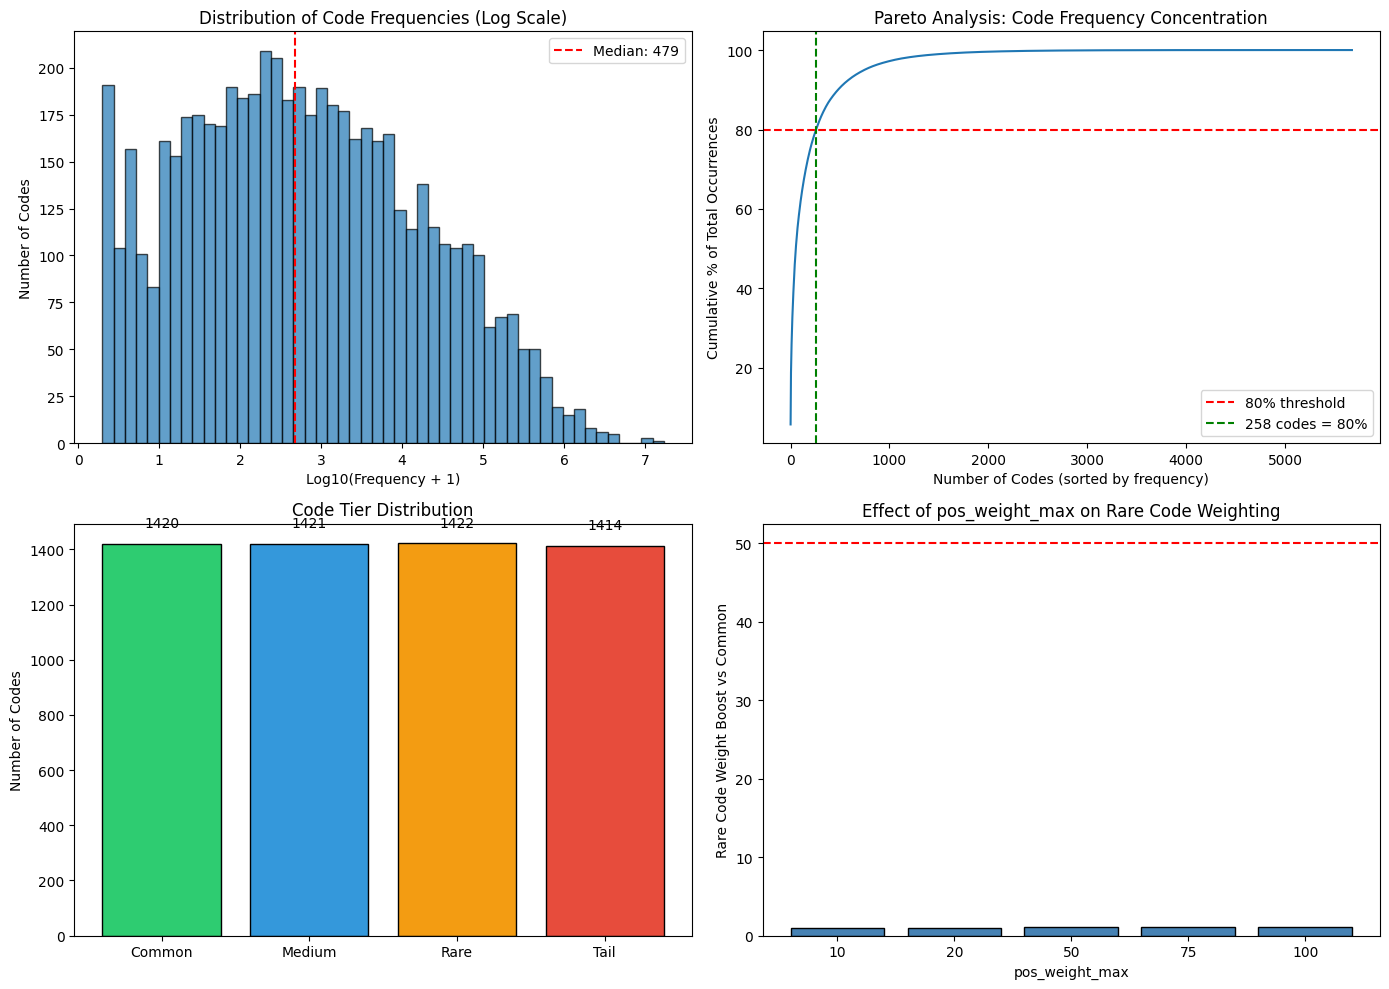

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def analyze_code_frequency_distribution(
    code_frequencies: np.ndarray,
    pos_weight_candidates: list = [10, 20, 50, 75, 100],
    show_plots: bool = True
):
    """
    Comprehensive analysis of code frequency distribution to guide pos_weight selection.
    
    Args:
        code_frequencies: Array from prepare_data_once()
        pos_weight_candidates: List of pos_weight_max values to compare
        show_plots: Whether to display matplotlib plots
    
    Returns:
        dict: Analysis results and recommendations
    """
    
    # ============================================================
    # BASIC STATISTICS
    # ============================================================
    total_codes = len(code_frequencies)
    non_zero_codes = np.sum(code_frequencies > 0)
    zero_codes = total_codes - non_zero_codes
    total_occurrences = code_frequencies.sum()
    
    print("=" * 70)
    print("CODE FREQUENCY DISTRIBUTION ANALYSIS")
    print("=" * 70)
    
    print(f"\n📊 BASIC STATISTICS:")
    print(f"   Total target codes:      {total_codes:,}")
    print(f"   Non-zero codes:          {non_zero_codes:,} ({100*non_zero_codes/total_codes:.1f}%)")
    print(f"   Zero-frequency codes:    {zero_codes:,} ({100*zero_codes/total_codes:.1f}%)")
    print(f"   Total occurrences:       {total_occurrences:,}")
    
    # ============================================================
    # FREQUENCY STATISTICS (non-zero only)
    # ============================================================
    freq_nz = code_frequencies[code_frequencies > 0]
    
    print(f"\n📈 FREQUENCY STATISTICS (non-zero codes only):")
    print(f"   Min frequency:           {freq_nz.min():,}")
    print(f"   Max frequency:           {freq_nz.max():,}")
    print(f"   Mean frequency:          {freq_nz.mean():,.1f}")
    print(f"   Median frequency:        {np.median(freq_nz):,.1f}")
    print(f"   Std deviation:           {freq_nz.std():,.1f}")
    
    # ============================================================
    # IMBALANCE METRICS
    # ============================================================
    # Imbalance ratio = max_freq / min_freq (for non-zero)
    imbalance_ratio = freq_nz.max() / freq_nz.min()
    
    # Gini coefficient (inequality measure)
    sorted_freq = np.sort(freq_nz)
    n = len(sorted_freq)
    cumsum = np.cumsum(sorted_freq)
    gini = (2 * np.sum((np.arange(1, n+1) * sorted_freq))) / (n * sorted_freq.sum()) - (n + 1) / n
    
    print(f"\n⚖️ IMBALANCE METRICS:")
    print(f"   Imbalance ratio (max/min): {imbalance_ratio:,.1f}x")
    print(f"   Gini coefficient:          {gini:.4f} (0=equal, 1=total inequality)")
    
    # ============================================================
    # PERCENTILE ANALYSIS
    # ============================================================
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    pct_values = np.percentile(freq_nz, percentiles)
    
    print(f"\n📏 PERCENTILE DISTRIBUTION:")
    print(f"   {'Percentile':<12} {'Frequency':<15} {'% of Max':<12}")
    print(f"   {'-'*40}")
    for p, v in zip(percentiles, pct_values):
        print(f"   {p:>3}th        {v:>12,.1f}    {100*v/freq_nz.max():>8.2f}%")
    
    # ============================================================
    # TIER ANALYSIS (Common/Medium/Rare/Tail)
    # ============================================================
    # Define tiers based on frequency quartiles
    tier_thresholds = np.percentile(freq_nz, [75, 50, 25])  # Common > 75th, etc.
    
    common_mask = code_frequencies >= tier_thresholds[0]
    medium_mask = (code_frequencies >= tier_thresholds[1]) & (code_frequencies < tier_thresholds[0])
    rare_mask = (code_frequencies >= tier_thresholds[2]) & (code_frequencies < tier_thresholds[1])
    tail_mask = (code_frequencies > 0) & (code_frequencies < tier_thresholds[2])
    
    print(f"\n🏷️ CODE TIER ANALYSIS:")
    print(f"   {'Tier':<10} {'Count':<10} {'% of Codes':<12} {'Freq Range':<20} {'% of Total Occurrences':<20}")
    print(f"   {'-'*75}")
    
    tiers = [
        ('Common', common_mask, f">= {tier_thresholds[0]:.0f}"),
        ('Medium', medium_mask, f"{tier_thresholds[1]:.0f} - {tier_thresholds[0]:.0f}"),
        ('Rare', rare_mask, f"{tier_thresholds[2]:.0f} - {tier_thresholds[1]:.0f}"),
        ('Tail', tail_mask, f"< {tier_thresholds[2]:.0f}"),
    ]
    
    tier_stats = {}
    for tier_name, mask, freq_range in tiers:
        count = mask.sum()
        pct_codes = 100 * count / non_zero_codes
        tier_occurrences = code_frequencies[mask].sum()
        pct_occurrences = 100 * tier_occurrences / total_occurrences if total_occurrences > 0 else 0
        tier_stats[tier_name.lower()] = {
            'count': count,
            'pct_codes': pct_codes,
            'total_occurrences': tier_occurrences,
            'pct_occurrences': pct_occurrences
        }
        print(f"   {tier_name:<10} {count:<10} {pct_codes:>8.1f}%     {freq_range:<20} {pct_occurrences:>10.1f}%")
    
    # ============================================================
    # POS_WEIGHT ANALYSIS
    # ============================================================
    print(f"\n🎯 POS_WEIGHT ANALYSIS:")
    print(f"   Testing different pos_weight_max values...")
    print(f"\n   {'max_weight':<12} {'Mean':<10} {'Median':<10} {'% at Max':<12} {'Effect on Rare':<20}")
    print(f"   {'-'*70}")
    
    freq_smoothed = code_frequencies.astype(np.float32) + 1.0
    max_freq = freq_smoothed.max()
    raw_weights = max_freq / freq_smoothed
    
    weight_analysis = {}
    for max_w in pos_weight_candidates:
        weights = np.clip(raw_weights, 1.0, max_w)
        weights_nz = weights[code_frequencies > 0]
        
        mean_w = weights_nz.mean()
        median_w = np.median(weights_nz)
        pct_at_max = 100 * (weights_nz >= max_w * 0.99).sum() / len(weights_nz)
        
        # Effective weight ratio: how much more do rare codes contribute?
        rare_weight = weights[tail_mask].mean() if tail_mask.sum() > 0 else 0
        common_weight = weights[common_mask].mean() if common_mask.sum() > 0 else 1
        rare_boost = rare_weight / common_weight if common_weight > 0 else 0
        
        weight_analysis[max_w] = {
            'mean': mean_w,
            'median': median_w,
            'pct_at_max': pct_at_max,
            'rare_boost': rare_boost
        }
        
        print(f"   {max_w:<12} {mean_w:<10.2f} {median_w:<10.2f} {pct_at_max:>8.1f}%      Rare codes get {rare_boost:.1f}x weight vs common")
    
    # ============================================================
    # RECOMMENDATIONS
    # ============================================================
    print(f"\n" + "=" * 70)
    print("📋 RECOMMENDATIONS")
    print("=" * 70)
    
    # Determine recommended pos_weight_max
    if imbalance_ratio > 10000:
        recommended_max = 100
        severity = "EXTREME"
    elif imbalance_ratio > 1000:
        recommended_max = 75
        severity = "SEVERE"
    elif imbalance_ratio > 100:
        recommended_max = 50
        severity = "MODERATE"
    else:
        recommended_max = 20
        severity = "MILD"
    
    print(f"\n   1. IMBALANCE SEVERITY: {severity}")
    print(f"      - Your imbalance ratio: {imbalance_ratio:,.0f}x")
    print(f"      - Recommended pos_weight_max: {recommended_max}")
    
    # Focal loss recommendation
    use_focal = imbalance_ratio > 1000 or gini > 0.8
    print(f"\n   2. FOCAL LOSS RECOMMENDATION: {'YES' if use_focal else 'OPTIONAL'}")
    if use_focal:
        print(f"      - Rationale: Imbalance ratio ({imbalance_ratio:,.0f}x) and/or Gini ({gini:.3f}) are very high")
        print(f"      - Suggested gamma: 2.0 (standard) to 3.0 (aggressive)")
    else:
        print(f"      - pos_weight should be sufficient for your imbalance level")
    
    # Combined strategy
    print(f"\n   3. RECOMMENDED CONFIGURATION:")
    print(f"")
    print(f"      optimize_config = OptimizeConfig(")
    print(f"          use_pos_weight=True,")
    print(f"          pos_weight_max={recommended_max:.1f},")
    if use_focal:
        print(f"          # Consider adding FocalLoss with gamma=2.0")
    print(f"      )")
    print(f"      ```")
    
    # ============================================================
    # PLOTS (optional)
    # ============================================================
    if show_plots:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Plot 1: Histogram of frequencies (log scale)
        ax1 = axes[0, 0]
        ax1.hist(np.log10(freq_nz + 1), bins=50, edgecolor='black', alpha=0.7)
        ax1.set_xlabel('Log10(Frequency + 1)')
        ax1.set_ylabel('Number of Codes')
        ax1.set_title('Distribution of Code Frequencies (Log Scale)')
        ax1.axvline(np.log10(np.median(freq_nz) + 1), color='r', linestyle='--', label=f'Median: {np.median(freq_nz):.0f}')
        ax1.legend()
        
        # Plot 2: Cumulative distribution
        ax2 = axes[0, 1]
        sorted_freq = np.sort(freq_nz)[::-1]
        cumsum = np.cumsum(sorted_freq) / sorted_freq.sum() * 100
        ax2.plot(range(len(cumsum)), cumsum)
        ax2.set_xlabel('Number of Codes (sorted by frequency)')
        ax2.set_ylabel('Cumulative % of Total Occurrences')
        ax2.set_title('Pareto Analysis: Code Frequency Concentration')
        ax2.axhline(80, color='r', linestyle='--', label='80% threshold')
        # Find how many codes account for 80%
        codes_for_80 = np.searchsorted(cumsum, 80)
        ax2.axvline(codes_for_80, color='g', linestyle='--', label=f'{codes_for_80} codes = 80%')
        ax2.legend()
        
        # Plot 3: Tier breakdown
        ax3 = axes[1, 0]
        tier_names = ['Common', 'Medium', 'Rare', 'Tail']
        tier_counts = [tier_stats[t.lower()]['count'] for t in tier_names]
        tier_colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
        ax3.bar(tier_names, tier_counts, color=tier_colors, edgecolor='black')
        ax3.set_ylabel('Number of Codes')
        ax3.set_title('Code Tier Distribution')
        for i, (name, count) in enumerate(zip(tier_names, tier_counts)):
            ax3.text(i, count + 50, f'{count}', ha='center', va='bottom')
        
        # Plot 4: pos_weight comparison
        ax4 = axes[1, 1]
        max_weights = list(weight_analysis.keys())
        rare_boosts = [weight_analysis[w]['rare_boost'] for w in max_weights]
        ax4.bar([str(w) for w in max_weights], rare_boosts, color='steelblue', edgecolor='black')
        ax4.set_xlabel('pos_weight_max')
        ax4.set_ylabel('Rare Code Weight Boost vs Common')
        ax4.set_title('Effect of pos_weight_max on Rare Code Weighting')
        ax4.axhline(recommended_max / 2, color='r', linestyle='--', 
                   label=f'Recommended: {recommended_max}')
        
        plt.tight_layout()
        plt.show()
    
    # Return analysis results
    return {
        'basic_stats': {
            'total_codes': total_codes,
            'non_zero_codes': non_zero_codes,
            'zero_codes': zero_codes,
            'total_occurrences': total_occurrences
        },
        'frequency_stats': {
            'min': freq_nz.min(),
            'max': freq_nz.max(),
            'mean': freq_nz.mean(),
            'median': np.median(freq_nz),
            'std': freq_nz.std()
        },
        'imbalance_metrics': {
            'imbalance_ratio': imbalance_ratio,
            'gini_coefficient': gini
        },
        'tier_stats': tier_stats,
        'weight_analysis': weight_analysis,
        'recommendations': {
            'severity': severity,
            'pos_weight_max': recommended_max,
            'use_focal_loss': use_focal
        }
    }
analysis = analyze_code_frequency_distribution(
    code_frequencies=data_prepared.code_frequencies,
    pos_weight_candidates=[10, 20, 50, 75, 100],
    show_plots=True  # Set to False if no matplotlib display
)

##### Run experiment

In [133]:
exp_round5_EXPERIMENTS = [
    # 'exp2_dense_flash',  # Flash + Max-Pool
    # 'exp2b_flash_learned_pool',  # Flash + Learned Pool
    # 'exp3_standard_moe',  # MoE + Max-Pool
    # 'exp3b_moe_swiglu_learned_pool',  # MoE + Learned Pool  
    # 'exp3e_moe_swiglu_learned_pool_layer2_aux001',  # aux_loss=0.001
    # 'exp4_shared_expert',  # Shared expert
    # 'exp5_fine_grained',  # Fine-grained
    # 'exp6b_auxiliary_free_no-share-exp',
    # 'exp6a_auxiliary_free_layer4',
    'exp6_auxiliary_free',  # DeepSeek-style auxiliary loss
    # 'exp6c_auxiliary_free_fine-grained16',
    # 'exp6d_auxiliary_free_fine-grained16_shared2'
    
]


In [124]:
# Create mini PreparedData using the existing function
train_df_mini = train_df.sample(640)
val_df_mini = val_df.sample(64)
data_prepared_mini = prepare_data_once(
    train_data=train_df_mini,
    val_data=val_df_mini,
    config=None,  # Will use defaults
    device=device,
    code_freq_sample_fraction=1.0  # Use all samples since it's already small
)



PREPARING DATA (ONE-TIME OPERATION)

[1/3] Creating training dataset...
Pre-processing 640 samples into tensors (one-time cost)...
Pre-processing complete.

[2/3] Creating validation dataset...
Pre-processing 64 samples into tensors (one-time cost)...
Pre-processing complete.

[3/3] Computing code frequencies...
  Processing 640 samples...
  ✅ Found 1,856 unique codes

✅ Data preparation complete in 1.4s
   Train samples: 640
   Val samples: 64
   Unique codes: 1,856



In [125]:
data_prepared

PreparedData(train_samples=1403720, val_samples=350931, code_frequencies_shape=(6297,))

In [ ]:
cleanup_gpu_memory_hard()
torch.cuda.empty_cache()
# Get predefined experiment configs
all_configs = get_experiment_configs()
EXP_NAME = 'exp6_auxiliary_free'
moe_config, use_learnt_att_pool = all_configs[EXP_NAME]
optimize_config = OptimizeConfig(
    # scheduler_type='onecycle',      # OneCycleLR for faster convergence
    # onecycle_pct_start=0.30,
    warmup_pct=0.15,
    scheduler_type='linear',       # Linear warmup + plateau + decay
    plateau_pct=0.45,             # 45% at peak (total 60% before decay)
    min_lr_ratio=0.2,             # End at 10% of peak (not 1%)
    use_pos_weight=True,            # Enable weighted BCE
    pos_weight_method='log_scaled',     # or 'log_scaled', 'ens', 'inverse'
    pos_weight_max=35,
    use_focal_loss=False,
    focal_gamma=2.5,                # 2.0-3.0 for extreme imbalance
    focal_alpha=0.25,
)
exp6_auxiliary_free_results = run_single_experiment(
    exp_name=EXP_NAME,
    moe_config=moe_config,
    use_learnt_att_pool=use_learnt_att_pool,
    prepared_data = data_prepared,
    train_data=train_df,
    val_data=val_df,
    device=device,
    epochs=EPOCHS,
    experiment_round=EXPERIMENT_ROUND,
    embedding_size=EMBEDDING_SIZE,
    log_dir='logs',
    save_model=True,
    optimize_config=optimize_config
)

09:14:29 - exp6_auxiliary_free - INFO - 
09:14:29 - exp6_auxiliary_free - INFO - EXPERIMENT: exp6_auxiliary_free
09:14:29 - exp6_auxiliary_free - INFO - ================================================================================
✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
09:14:30 - exp6_auxiliary_free - INFO - Model: Flash + MoE Transformer (FP16)
09:14:30 - exp6_auxiliary_free - INFO -   d_model=256, nhid=704, nhead=8
09:14:30 - exp6_auxiliary_free - INFO -   Daily Encoder: Learned Attention Pooling
09:14:30 - exp6_auxiliary_free - INFO -   MoE: 8 experts, top-2
09:14:30 - exp6_auxiliary_free - INFO - Total parameters: 35,417,753
09:14:30 - exp6_auxiliary_free - INFO - ✅ Using pre-prepared data
09:14:30 - exp6_auxiliary_free - INFO - Using BCEWithLogitsLoss
09:14:30 - exp6_auxiliary_free - INFO -   With pos_

In [161]:
cleanup_gpu_memory_hard()
torch.cuda.empty_cache()
# Get predefined experiment configs
all_configs = get_experiment_configs()
EXP_NAME = "exp6b_auxiliary_free_no-share-exp"
moe_config, use_learnt_att_pool = all_configs[EXP_NAME]
optimize_config = OptimizeConfig(
    # scheduler_type='onecycle',      # OneCycleLR for faster convergence
    # onecycle_pct_start=0.30,
    warmup_pct=0.15,
    scheduler_type='linear',       # Linear warmup + plateau + decay
    plateau_pct=0.45,             # 45% at peak (total 60% before decay)
    min_lr_ratio=0.2,             # End at 10% of peak (not 1%)
    use_pos_weight=True,            # Enable weighted BCE
    pos_weight_method='log_scaled',     # or 'log_scaled', 'ens', 'inverse'
    pos_weight_max=50,
    use_focal_loss=False,
    focal_gamma=2.5,                # 2.0-3.0 for extreme imbalance
    focal_alpha=0.25,
)
exp6b_auxiliary_free_no_share_exp_results = run_single_experiment(
    exp_name=EXP_NAME,
    moe_config=moe_config,
    use_learnt_att_pool=use_learnt_att_pool,
    prepared_data = data_prepared,
    train_data=train_df,
    val_data=val_df,
    device=device,
    epochs=EPOCHS,
    experiment_round=EXPERIMENT_ROUND,
    embedding_size=EMBEDDING_SIZE,
    log_dir='logs',
    save_model=True,
    optimize_config=optimize_config
)

11:49:47 - exp6b_auxiliary_free_no-share-exp - INFO - 
11:49:47 - exp6b_auxiliary_free_no-share-exp - INFO - EXPERIMENT: exp6b_auxiliary_free_no-share-exp
11:49:47 - exp6b_auxiliary_free_no-share-exp - INFO - ================================================================================
✅ Aggressive cleanup completed for GPUs: [0, 1, 2, 3]
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
11:49:47 - exp6b_auxiliary_free_no-share-exp - INFO - Model: Flash + MoE Transformer (FP16)
11:49:47 - exp6b_auxiliary_free_no-share-exp - INFO -   d_model=256, nhid=704, nhead=8
11:49:47 - exp6b_auxiliary_free_no-share-exp - INFO -   Daily Encoder: Learned Attention Pooling
11:49:47 - exp6b_auxiliary_free_no-share-exp - INFO -   MoE: 8 experts, top-2
11:49:47 - exp6b_auxiliary_free_no-share-exp - INFO - Total parameters: 35,418,777
11:49:47 - exp6b_auxiliary_free_no-share-exp - INFO - ✅

In [ ]:
exp6_auxiliary_free_results 

In [ ]:
exp_round_5_results_df = run_selected_experiments(
    experiment_names=exp_round5_EXPERIMENTS,
    train_data=train_df,
    val_data=val_df,
    device=device,
    epochs=EPOCHS,
    embedding_size=EMBEDDING_SIZE,
    experiment_round=EXPERIMENT_ROUND,
    save_model=True,
    optimize_config=optimize_config
)

02:49:16 - exp6_auxiliary_free - INFO - 
02:49:16 - exp6_auxiliary_free - INFO - EXPERIMENT: exp6_auxiliary_free
02:49:16 - exp6_auxiliary_free - INFO - ================================================================================

RUNNING 3 SELECTED EXPERIMENTS
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
✓ xFormers available for Flash Attention
02:49:26 - exp6_auxiliary_free - INFO - Model: Flash + MoE Transformer (FP16)
02:49:26 - exp6_auxiliary_free - INFO -   d_model=256, nhid=704, nhead=8
02:49:26 - exp6_auxiliary_free - INFO -   Daily Encoder: Learned Attention Pooling
02:49:26 - exp6_auxiliary_free - INFO -   MoE: 8 experts, top-2
02:49:26 - exp6_auxiliary_free - INFO - Total parameters: 35,417,753
Computing code frequencies from training data...
  Processing 1,403,720 samples...
Pre-processing 1403720 samples into te